# Multilingual Pizza Review Sentiment Analysis with RNNs

**Name**: Agne Rudhresh

---

## 0. Setup and Reproducibility

This notebook develops an RNN-based deep learning workflow for analysing pizza reviews.

The project involves more than simply training a neural network. The notebook must show a complete modelling process: understanding the task, inspecting the dataset, making justified preprocessing decisions, deciding whether the problem should be treated as regression or classification, handling multilingual reviews carefully, improving model performance systematically, and providing concrete analysis of the final predictions.

The main workflow is:

1. Understand the pizza review analysis task.
2. Load and inspect the provided dataset.
3. Clean invalid or noisy records with documented reasons.
4. Use EDA to decide the target framing instead of assuming the number of sentiment classes upfront.
5. Engineer text features and compare language-handling strategies.
6. Build baseline models before RNN models.
7. Improve the selected RNN pipeline through controlled validation experiments.
8. Evaluate the final locked model on the test set once.
9. Analyse review-level successes, failures, and limitations.

A strict train/validation/test discipline will be used throughout the notebook. The training set is used to fit models and tokenisers, the validation set is used for model and preprocessing decisions, and the test set is reserved for final evaluation only after the final model is locked.

This is important because text preprocessing can easily introduce leakage. For example, the tokenizer must be fitted only on training text, and any engineered training-data method such as sentence splitting must be applied only after the train/validation/test split.

The implementation will stay intentionally simple and readable. Helper functions will only be added when they reduce repetition or improve correctness. The goal is not to create an over-engineered codebase, but to produce a clear, reproducible, and defensible deep learning notebook.

In [ ]:
# Core libraries
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simple global plot theme
sns.set_theme(style="whitegrid", palette="muted")

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    GlobalAveragePooling1D,
    Dense,
    Dropout,
    LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
SEED = 88

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print(f"Seed set to: {SEED}")

Libraries imported successfully.
Seed set to: 88


In [4]:
print("Python libraries:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"TensorFlow: {tf.__version__}")

tf.config.list_physical_devices("GPU")

Python libraries:
pandas: 2.2.2
numpy: 2.0.2
TensorFlow: 2.20.0


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
gpus = tf.config.experimental.list_physical_devices('GPU')

for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu, True)

In [6]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == \"notebooks\" else Path.cwd()\nDATA_PATH = PROJECT_ROOT / \"datasets/Pizza reviews.csv\"\nFINAL_WEIGHTS_PATH = PROJECT_ROOT / \"models/final_rnn.weights.h5\"

print("Project paths configured.")
print(f"Data path: {DATA_PATH}")
print(f"Final weights path: {FINAL_WEIGHTS_PATH}")

Project paths configured.
Data path: datasets/Pizza reviews.csv
Final weights path: models/final_rnn.weights.h5


---

## 1. Problem Understanding and Background Research

This section defines the task, reviews why RNNs are appropriate for text sequence modelling, and summarises the background concepts that inform later modelling decisions.

### 1.1 Assignment Task Understanding

The objective of this project is to build an appropriate deep neural network to analyse pizza reviews using the provided dataset. The notebook must not only train a model, but also explain the decision-making process behind the target design, text preprocessing, language handling, model selection, model improvement, and final review analysis.

The main modelling decisions that need to be justified are:

- whether the task should be treated as regression or classification;
- how review text should be cleaned and converted into numerical input;
- whether English and Malay reviews should both be retained;
- how multilingual reviews should be handled;
- which RNN-based model family should be used;
- how the model should be improved using validation-only evidence;
- how the final predictions should be interpreted using review-level examples.

The final target and modelling pipeline will not be assumed immediately. They will be decided after EDA checks score quality, language coverage, duplicate conflicts, review length, and target balance.


### 1.2 Why Pizza Reviews Are Sequence Data

Pizza reviews are text data made up of words in a specific order. This order matters because changing the order of words can change the meaning of a sentence.

For example, “not good” and “good” contain a similar word, but the meaning is very different because of the sequence context. Similarly, a review such as “good crust but bad service” contains mixed sentiment that depends on how words and clauses relate to each other.

This makes pizza review analysis a sequence-based natural language processing task, not just a normal tabular prediction task. The model should therefore be able to work with ordered text input rather than treating each word as completely independent.

### 1.3 Sentiment Analysis Framing

Sentiment analysis is the process of computationally identifying and categorising opinions expressed in text (IBM, n.d.). In this project, pizza reviews express customer opinions about pizza quality, service, price, delivery, or the overall experience.

The dataset contains review text and score values. This means there are several possible target framings:

| Possible Target | Description | Main Risk |
|---|---|---|
| Regression | Predict the exact numeric score | Exact scores may be noisy and inconsistent |
| Binary classification | Predict positive vs negative | Mixed/neutral reviews may be forced into overly simple labels |
| 3-class classification | Predict negative, mixed/neutral, or positive | Some boundary cases may still be ambiguous |
| 5-class classification | Predict more detailed sentiment levels | Some classes may become too small for reliable modelling |

The final target will be selected after EDA. In particular, Section 3 will check score validity, score distribution, duplicate review conflicts, and candidate target distributions before Section 4 locks the final target.

### 1.4 Why RNN-Based Models Are Appropriate

Recurrent Neural Networks (RNNs) are designed to process sequential data by maintaining a hidden state across time steps (Brownlee, 2017). They process input tokens in order and can use earlier information when interpreting later tokens. This makes them suitable for text problems where word order and context affect meaning.

For this project, RNN-based models are appropriate because:

- pizza reviews are ordered word sequences;
- sentiment can depend on context and negation;
- review length can vary;
- the model needs to classify the sentiment of a full review;
- the project focuses on recurrent neural networks for pizza review analysis.

A SimpleRNN is the most basic recurrent model family and is useful as an initial baseline. LSTMs address the vanishing gradient problem through gating mechanisms that control information flow across long sequences (Olah, 2015). GRUs simplify the LSTM architecture with fewer parameters while retaining similar gating behaviour (Olah, 2015).

LSTM and GRU may capture sequence information better, but they are also more complex and may overfit on a small dataset. Therefore, this notebook will first build a simple RNN baseline, then compare RNN model families in a controlled way before improving only the selected family.

### 1.5 Text Preprocessing Concepts

Neural networks cannot directly process raw text strings. The review text must be converted into numerical input.

The key preprocessing concepts used in this notebook are:

| Concept | Meaning | Why It Matters |
|---|---|---|
| Tokenisation | Converts words into integer IDs | Neural networks require numerical input |
| Vocabulary size | Limits how many unique words are represented | Controls model complexity and rare-word noise |
| Padding | Makes all sequences the same length | Allows reviews to be trained in batches |
| Truncation | Cuts reviews longer than the selected length | Prevents very long inputs from dominating |
| Embedding | Learns dense vector representations of words | Allows the model to learn useful word patterns |
| Sequence length | Controls how many tokens each review keeps | Must be chosen using review length evidence |

Word embeddings represent tokens as dense vectors in a continuous space, allowing the model to learn semantic relationships between words (Brownlee, 2017).

To avoid data leakage, tokenisers must be fitted only on the training text. Validation and test text should only be transformed using the training-fitted tokenizer.

### 1.6 Multilingual Review Issue

The dataset contains reviews in more than one language. This creates an important modelling decision: whether to keep only English reviews or retain other usable languages such as Malay.

This decision should not be made by assumption. The EDA will check:

- language distribution;
- score distribution by language;
- sentiment distribution by language;
- review length by language;
- whether each language has enough usable rows;
- whether some language labels are too rare or noisy.

If English and Malay both have enough usable rows, it is more defensible to retain both and compare language-handling strategies instead of discarding non-English reviews immediately.

Possible language strategies include:

| Strategy | Description |
|---|---|
| Bilingual original text | Train one model using English and Malay reviews together |
| Bilingual with language token | Add a language indicator token before each review |
| Two-classifier routing | Train separate English and Malay models |
| Translation to English | Translate Malay reviews to English before modelling |

Section 6 will compare these strategies using validation-only evidence.

### 1.7 Planned Modelling Workflow

The notebook will follow this modelling progression:

| Stage | Purpose |
|---|---|
| Majority-class baseline | Establish the simplest reference point |
| Simple neural text baseline | Check whether a basic learned text model beats majority guessing |
| Language strategy comparison | Decide how to handle English and Malay reviews |
| Initial SimpleRNN baseline | Create the first recurrent baseline using the selected language strategy |
| RNN model family selection | Compare SimpleRNN, LSTM, GRU, Stacked LSTM, and LSTM+GRU fairly |
| Controlled model improvement | Improve only the selected model family |
| Final test evaluation | Evaluate the locked final model once |
| Review-level error analysis | Analyse actual review predictions, not just metrics |

This workflow keeps the notebook controlled and prevents random model searching.

### 1.8 Background Research Summary and Section 1 Takeaways

| Concept | Why It Matters in This Project |
|---|---|
| Sequence data | Pizza reviews are ordered text sequences where word order can affect meaning |
| Sentiment analysis | The task involves analysing opinions expressed in review text |
| Tokenisation | Converts text into integer sequences for neural network input |
| Padding | Makes variable-length reviews usable in fixed-size batches |
| Embedding | Learns dense word representations for text modelling |
| SimpleRNN | Provides a basic recurrent baseline |
| LSTM / GRU | Gated RNN variants that may model sequence context better |
| Multilingual handling | English and Malay reviews may need different modelling strategies |
| Validation-only selection | Prevents test-set leakage during model design and improvement |

Overall, this project is treated as a text sequence modelling problem because pizza reviews are ordered word sequences. Sentiment analysis is an appropriate framing because the reviews express customer opinions, but the exact target design will be confirmed only after EDA.

RNN-based models are appropriate because they are designed for sequential data. However, the notebook will not jump directly to a complex model. It will first inspect the dataset, decide the target using evidence, build simple baselines, compare language strategies, select an RNN family, and then improve the selected model using validation-only experiments.

This ensures that later modelling decisions are connected to data evidence rather than assumptions.

---

## 2. Dataset Loading and Initial Inspection

This section loads the raw pizza review dataset and performs an initial inspection of its structure and obvious data-quality issues.

No cleaning is performed in this section. The goal is to understand the raw file before making any preprocessing, target-engineering, or modelling decisions.

### 2.1 Loading the Raw Dataset

The dataset is loaded from the local `datasets` folder. The first check is the dataset shape, which shows how many rows and columns are available before cleaning.

In [7]:
raw_df = pd.read_csv(DATA_PATH)

print(f"Shape: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")

Shape: 902 rows, 4 columns


### 2.2 Raw Columns, Data Types, and Sample Rows

This subsection checks the raw column names, data types, and example records.

This is useful for identifying which columns are likely to be modelling features, which columns may need type conversion, and whether any columns appear to be metadata or dataset notes rather than useful input variables.

In [8]:
print("Column names:")
for col in raw_df.columns:
    print(f"- {col}")

print("\nData types:")
display(raw_df.dtypes.to_frame("dtype"))

Column names:
- Review
- Score
- Are there ways for you to generate more data? Spliting up sentences, would that help?
- Language

Data types:


,dtype
Review,object
Score,object
"Are there ways for you to generate more data? Spliting up sentences, would that help?",object
Language,object


In [9]:
print("First 5 rows:")
display(raw_df.head())

print("Last 5 rows:")
display(raw_df.tail())

First 5 rows:


,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
0,Disgusting.,1,NaN,English
1,Loved the sambal kick!,10,NaN,English
2,Loved the sambal kick!,0.1,NaN,English
3,Loved the sambal kick!,5,NaN,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7,NaN,English


Last 5 rows:


,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
897,Ni hao,NaN,NaN,Chinese
898,Hen tai fei chang hao,0.001,NaN,Chinese
899,Nani kore,0.997413,NaN,Nippon
900,Diabolic,NaN,NaN,English
901,Jia!,???,NaN,Chinese


### 2.3 Missing Values

This subsection checks missing values in each raw column.

Missing values matter because review text, score labels, and language labels may affect whether a row can be used for supervised modelling.

In [10]:
missing_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_percentage": (raw_df.isna().mean() * 100).round(2)
})

display(missing_summary)

,missing_count,missing_percentage
Review,0,0.00
Score,2,0.22
"Are there ways for you to generate more data? Spliting up sentences, would that help?",900,99.78
Language,0,0.00


### 2.4 Initial Duplicate, Language, and Score Checks

This subsection performs quick checks for duplicate records, duplicate review texts, language-label distribution, and raw score values.

These checks help identify issues that require deeper EDA in the next section.

In [11]:
exact_duplicate_count = raw_df.duplicated().sum()
duplicate_review_count = raw_df["Review"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicate_count}")
print(f"Duplicate review texts: {duplicate_review_count}")

print("\nExample exact duplicate rows:")
display(raw_df[raw_df.duplicated(keep=False)].head(10))

print("\nExample duplicate review texts:")
display(raw_df[raw_df["Review"].duplicated(keep=False)].sort_values("Review").head(10))

Exact duplicate rows: 45
Duplicate review texts: 102

Example exact duplicate rows:


,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
0,Disgusting.,1,NaN,English
9,The sambal slice burned my mouth in the best w...,8,NaN,English
10,Just weird.,2,NaN,English
12,Sambal overwhelmed everything else.,4,NaN,English
13,Satay chicken worked well on pizza. Creative b...,6,NaN,English
14,"Enjoyed every bite, especially the satay one.",8,NaN,English
15,Disgusting.,2,NaN,English
16,Mayonnaise flavor felt out of place. Wouldn’t ...,4,NaN,English
17,The sambal slice burned my mouth in the best w...,8,NaN,English
18,Meh.,5,NaN,English



Example duplicate review texts:


,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
60,Amazing!,10,NaN,English
45,Amazing!,9,NaN,English
38,Creative but not for everyone.,5,NaN,English
72,Creative but not for everyone.,4,NaN,English
30,"Crust was thin and crispy, just right.",6,NaN,English
19,"Crust was thin and crispy, just right.",6,NaN,English
0,Disgusting.,1,NaN,English
26,Disgusting.,2,NaN,English
15,Disgusting.,2,NaN,English
70,Disgusting.,1,NaN,English


In [12]:
print("Language value counts:")
display(raw_df["Language"].value_counts(dropna=False).to_frame("count"))

print("\nRaw Score value counts:")
display(raw_df["Score"].value_counts(dropna=False).sort_index().to_frame("count"))

Language value counts:


,count
Language,
English,492
Malay,402
Chinese,3
Guga,2
Come on ...,1
You cannot be serious ...,1
Nippon,1



Raw Score value counts:


,count
Score,
-0.05,2
-0.1,8
-0.2,2
-0.219,2
-0.3,1
...,...
9.99,6
9.995,6
???,1


### 2.5 Section 2 Summary

The raw dataset contains `902` rows and `4` columns. The main useful columns appear to be `Review`, `Score`, and `Language`.

All columns are initially stored as `object` data types. This is important because the `Score` column should be numeric for either regression or sentiment-class construction, but it is currently read as text. This suggests that score conversion and score-validity checks are required before target engineering.

The dataset has no missing values in `Review` or `Language`, but `Score` has `2` missing values. The long column named `Are there ways for you to generate more data? Spliting up sentences, would that help?` is missing for `900` out of `902` rows, so it is not useful as a modelling feature.

The duplicate checks show `45` exact duplicate rows and `102` duplicate review-text entries. Duplicate review texts require deeper investigation because the same review text may appear with different scores.

The language distribution shows that the dataset is mainly English and Malay, with a very small number of other language labels. Some language values also appear suspicious, suggesting possible corrupted rows.

The raw score values show that the score column contains invalid or unusual values, including missing scores, non-numeric text, negative values, and extreme values. Therefore, detailed score-quality EDA is required before cleaning and modelling.

Overall, Section 2 shows that the dataset is small, multilingual, duplicated in places, and contains noisy score labels. Section 3 will investigate these issues in more detail before cleaning decisions are made.

---

## 3. Detailed Data Quality and Modelling EDA

This section performs decision-oriented EDA before cleaning the dataset.

In particular, this section checks score validity, language usability, sentiment class balance, review length, duplicate review conflicts, and whether sentence or clause splitting is worth testing later as engineered training data.

No rows are removed in this section. Cleaning decisions are applied later in Section 4.

### 3.1 Score Quality and Validity

The `Score` column is the source of the supervised learning target, so it must be checked before deciding whether the task should be framed as regression or classification.

This subsection checks whether scores are missing, non-numeric, outside the expected `0–10` range, or usable for target engineering. It also visualises the valid numeric score distribution with reference lines at `3` and `7`. These are candidate 3-class sentiment boundaries that will be evaluated more formally in Section 3.5, not a final target decision yet.

In [13]:
# Create a Section 3 EDA copy without modifying the raw dataset

score_eda_df = raw_df.copy()

score_eda_df["Score_Numeric"] = pd.to_numeric(
    score_eda_df["Score"],
    errors="coerce"
)

score_eda_df.head()

,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language,Score_Numeric
0,Disgusting.,1,NaN,English,1.0
1,Loved the sambal kick!,10,NaN,English,10.0
2,Loved the sambal kick!,0.1,NaN,English,0.1
3,Loved the sambal kick!,5,NaN,English,5.0
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7,NaN,English,7.0


In [14]:
# Score validity checks

total_rows = len(score_eda_df)

missing_score_rows = score_eda_df["Score"].isna().sum()

non_numeric_score_rows = (
    score_eda_df["Score_Numeric"].isna()
    & score_eda_df["Score"].notna()
).sum()

numeric_score_mask = score_eda_df["Score_Numeric"].notna()

below_zero_rows = (
    numeric_score_mask
    & (score_eda_df["Score_Numeric"] < 0)
).sum()

above_ten_rows = (
    numeric_score_mask
    & (score_eda_df["Score_Numeric"] > 10)
).sum()

valid_score_mask = (
    numeric_score_mask
    & score_eda_df["Score_Numeric"].between(0, 10, inclusive="both")
)

valid_score_rows = valid_score_mask.sum()
invalid_score_rows = total_rows - valid_score_rows

score_eda_df["Score_Is_Valid"] = valid_score_mask

valid_score_df = score_eda_df[score_eda_df["Score_Is_Valid"]].copy()
invalid_score_df = score_eda_df[~score_eda_df["Score_Is_Valid"]].copy()

score_validity_summary = pd.DataFrame({
    "Check": [
        "Total rows",
        "Missing score rows",
        "Non-numeric score rows",
        "Scores below 0",
        "Scores above 10",
        "Valid 0–10 score rows",
        "Invalid / unusable score rows"
    ],
    "Row Count": [
        total_rows,
        missing_score_rows,
        non_numeric_score_rows,
        below_zero_rows,
        above_ten_rows,
        valid_score_rows,
        invalid_score_rows
    ]
})

display(score_validity_summary)

,Check,Row Count
0,Total rows,902
1,Missing score rows,2
2,Non-numeric score rows,3
3,Scores below 0,17
4,Scores above 10,1
5,Valid 0–10 score rows,879
6,Invalid / unusable score rows,23


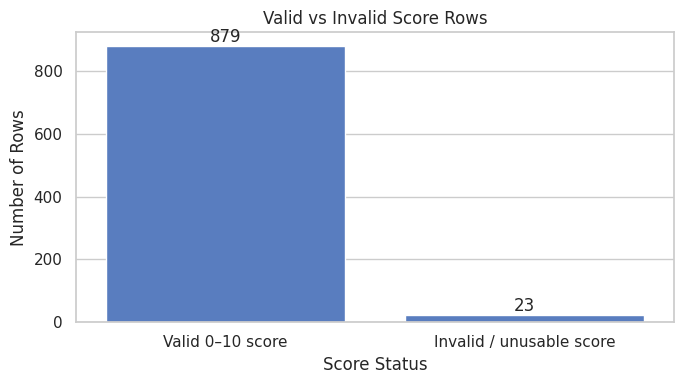

In [15]:
# Valid vs invalid score breakdown

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    x=["Valid 0–10 score", "Invalid / unusable score"],
    y=[valid_score_rows, invalid_score_rows]
)

plt.title("Valid vs Invalid Score Rows")
plt.xlabel("Score Status")
plt.ylabel("Number of Rows")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

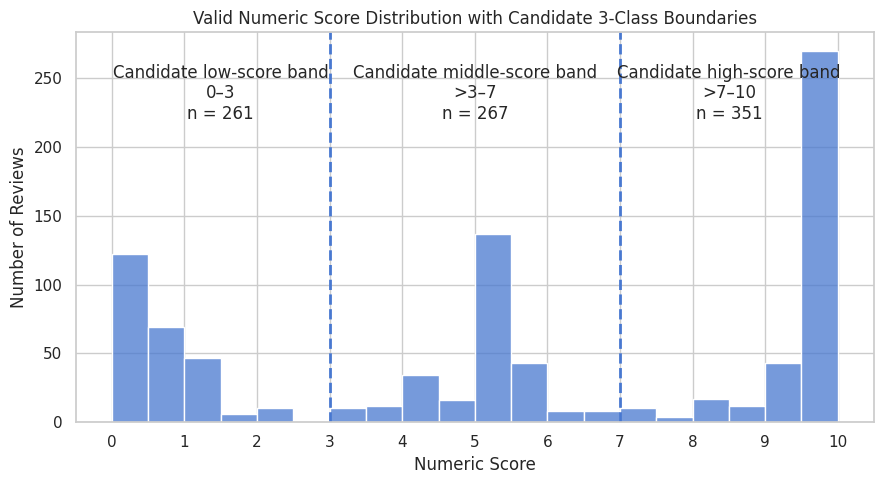

In [16]:
# Valid numeric score distribution with candidate 3-class boundaries

low_band_count = valid_score_df["Score_Numeric"].between(0, 3, inclusive="both").sum()
middle_band_count = ((valid_score_df["Score_Numeric"] > 3) & (valid_score_df["Score_Numeric"] <= 7)).sum()
high_band_count = ((valid_score_df["Score_Numeric"] > 7) & (valid_score_df["Score_Numeric"] <= 10)).sum()

plt.figure(figsize=(9, 5))

ax = sns.histplot(
    data=valid_score_df,
    x="Score_Numeric",
    bins=20
)

plt.axvline(3, linestyle="--", linewidth=2)
plt.axvline(7, linestyle="--", linewidth=2)

y_max = ax.get_ylim()[1]

ax.text(
    1.5,
    y_max * 0.92,
    f"Candidate low-score band\n0–3\nn = {low_band_count}",
    ha="center",
    va="top"
)

ax.text(
    5,
    y_max * 0.92,
    f"Candidate middle-score band\n>3–7\nn = {middle_band_count}",
    ha="center",
    va="top"
)

ax.text(
    8.5,
    y_max * 0.92,
    f"Candidate high-score band\n>7–10\nn = {high_band_count}",
    ha="center",
    va="top"
)

plt.title("Valid Numeric Score Distribution with Candidate 3-Class Boundaries")
plt.xlabel("Numeric Score")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()

In [17]:
# Inspect invalid or unusable score rows

display(
    invalid_score_df[["Review", "Score", "Score_Numeric", "Language"]]
    .sort_values(["Language", "Score"], na_position="last")
)

,Review,Score,Score_Numeric,Language
901,Jia!,???,NaN,Chinese
897,Ni hao,NaN,NaN,Chinese
22,Review,Score,NaN,Come on ...
857,"Pizza tasted stale, couldn't eat it.",-0.05,-0.050,English
848,"Weird flavor, no appetite.",-0.1,-0.100,English
850,This pizza made me feel sick.,-0.219,-0.219,English
900,Diabolic,NaN,NaN,English
896,Oh itz phenomenal!,-42,-42.000,Guga
895,"Ten out of ten, would highly recommend!",1010,1010.000,Guga
827,"Pizza ni rasa basi, tak boleh makan.",-0.05,-0.050,Malay


**Score Quality Interpretation**

The raw dataset contains 902 rows. After converting `Score` to numeric, 879 rows have valid scores within the expected `0–10` range, while 23 rows are invalid or unusable.

The invalid rows include 2 missing scores, 3 non-numeric scores, 17 scores below 0, and 1 score above 10. These rows cannot be used safely for supervised target creation because their labels are either missing, not numeric, or outside the expected rating scale.

The valid-score histogram shows that the ratings are not evenly spread across every exact score value. Many reviews cluster around clear rating regions, especially low scores, middle scores around 5, and high scores around 9–10. The candidate 3-class bands also have usable sample sizes: 261 low-score reviews, 267 middle-score reviews, and 351 high-score reviews.

This supports cleaning invalid scores before target engineering. It also suggests that exact score regression may be fragile because the score labels include decimal values, invalid entries, repeated review texts with different scores, and uneven score clustering. Broader sentiment classification is therefore worth evaluating later, but the final target framing decision is deferred to Section 3.5.

### 3.2 Score Distribution by Language

This subsection compares score quality and score distribution across language labels.

The first check includes all language labels so that English, Malay, Chinese, Guga, Nippon, and corrupted language labels are not ignored prematurely. This is important because the assignment explicitly requires a decision on whether non-English reviews should be considered.

After the all-language score-quality check, the detailed distribution plots focus on English and Malay because they are the only language groups with enough valid-score rows for meaningful visual comparison. Rare or suspicious language labels are inspected more closely in Section 3.3 before any language-removal decision is applied in Section 4.

No language is removed in this section. The purpose is to collect evidence for the later cleaning and language-retention decision.

In [18]:
# Score validity summary by all language labels

language_score_quality = (
    score_eda_df
    .assign(Language_Display=score_eda_df["Language"].fillna("Missing"))
    .groupby("Language_Display")
    .agg(
        total_rows=("Review", "count"),
        valid_score_rows=("Score_Is_Valid", "sum"),
        invalid_score_rows=("Score_Is_Valid", lambda x: (~x).sum())
    )
    .reset_index()
    .sort_values("total_rows", ascending=False)
)

language_score_quality["valid_score_percentage"] = (
    language_score_quality["valid_score_rows"]
    / language_score_quality["total_rows"]
    * 100
).round(2)

display(language_score_quality)

,Language_Display,total_rows,valid_score_rows,invalid_score_rows,valid_score_percentage
2,English,492,488,4,99.19
4,Malay,402,389,13,96.77
0,Chinese,3,1,2,33.33
3,Guga,2,0,2,0.00
1,Come on ...,1,0,1,0.00
5,Nippon,1,1,0,100.00
6,You cannot be serious ...,1,0,1,0.00


In [19]:
# Valid score summary by all language labels

all_language_valid_score_summary = (
    valid_score_df
    .assign(Language_Display=valid_score_df["Language"].fillna("Missing"))
    .groupby("Language_Display")["Score_Numeric"]
    .agg(["count", "min", "median", "mean", "max"])
    .round(2)
    .sort_values("count", ascending=False)
)

display(all_language_valid_score_summary)

,count,min,median,mean,max
Language_Display,,,,,
English,488,0.04,5.4,5.58,10.00
Malay,389,0.00,5.3,5.63,9.99
Chinese,1,0.00,0.0,0.00,0.00
Nippon,1,1.00,1.0,1.00,1.00


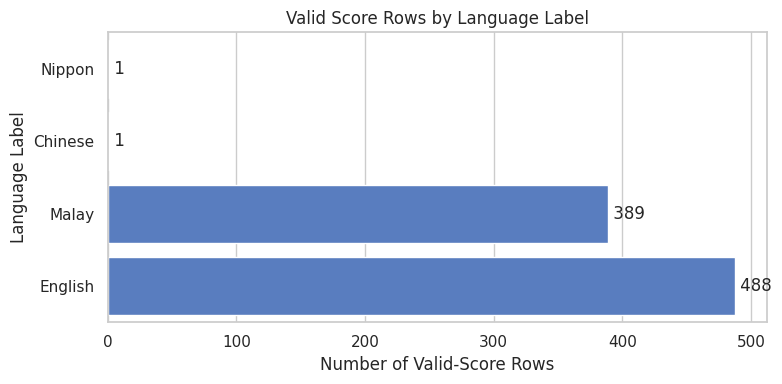

In [20]:
# Valid score row count by language

plt.figure(figsize=(8, 4))

language_valid_counts = (
    valid_score_df["Language"]
    .fillna("Missing")
    .value_counts()
    .sort_values()
)

ax = sns.barplot(
    x=language_valid_counts.values,
    y=language_valid_counts.index
)

plt.title("Valid Score Rows by Language Label")
plt.xlabel("Number of Valid-Score Rows")
plt.ylabel("Language Label")

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

The following plots compare score distributions for English and Malay reviews only.

In [21]:
# Focused comparison for English and Malay only, after all language labels have been checked

main_languages = ["English", "Malay"]

score_language_df = valid_score_df[
    valid_score_df["Language"].isin(main_languages)
].copy()

def assign_candidate_score_band(score):
    if score <= 3:
        return "Low score (0–3)"
    elif score <= 7:
        return "Middle score (>3–7)"
    else:
        return "High score (>7–10)"

score_language_df["Candidate_Score_Band"] = score_language_df["Score_Numeric"].apply(
    assign_candidate_score_band
)

language_score_summary = (
    score_language_df
    .groupby("Language")["Score_Numeric"]
    .agg(["count", "min", "median", "mean", "max"])
    .round(2)
)

display(language_score_summary)

,count,min,median,mean,max
Language,,,,,
English,488,0.04,5.4,5.58,10.00
Malay,389,0.00,5.3,5.63,9.99


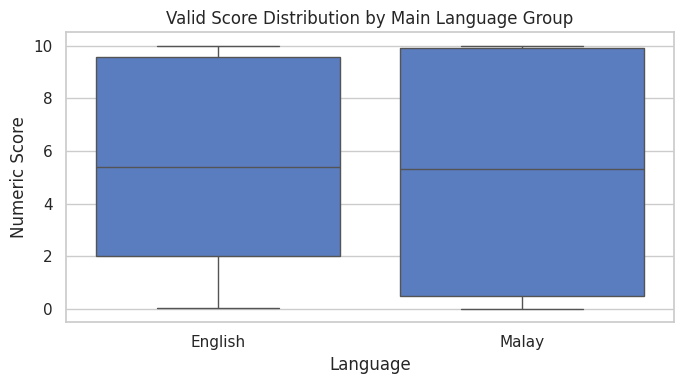

In [22]:
# Score distribution by main language groups

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=score_language_df,
    x="Language",
    y="Score_Numeric"
)

plt.title("Valid Score Distribution by Main Language Group")
plt.xlabel("Language")
plt.ylabel("Numeric Score")
plt.ylim(-0.5, 10.5)
plt.tight_layout()
plt.show()

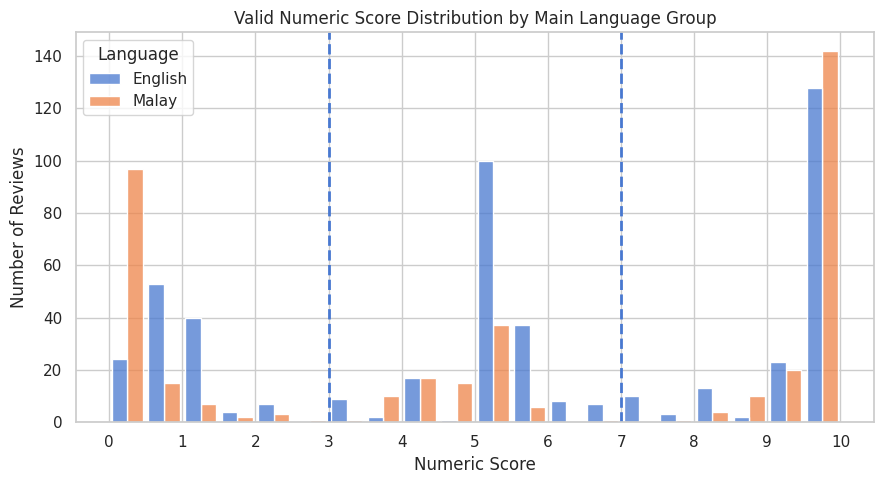

In [23]:
# Valid numeric score histogram by main language group

plt.figure(figsize=(9, 5))

sns.histplot(
    data=score_language_df,
    x="Score_Numeric",
    hue="Language",
    bins=20,
    multiple="dodge",
    shrink=0.85
)

plt.axvline(3, linestyle="--", linewidth=2)
plt.axvline(7, linestyle="--", linewidth=2)

plt.title("Valid Numeric Score Distribution by Main Language Group")
plt.xlabel("Numeric Score")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()

In [24]:
# Candidate score-band percentage distribution by main language group

band_order = [
    "Low score (0–3)",
    "Middle score (>3–7)",
    "High score (>7–10)"
]

score_band_counts = pd.crosstab(
    score_language_df["Language"],
    score_language_df["Candidate_Score_Band"]
)

score_band_counts = score_band_counts.reindex(columns=band_order)

score_band_pct = (
    score_band_counts
    .div(score_band_counts.sum(axis=1), axis=0)
    * 100
).round(2)

print("Score band counts:")
display(score_band_counts)

print("Score band distribution by percentage")
display(
    score_band_pct
    .style
    .format("{:.2f}%")
)

Score band counts:


Candidate_Score_Band,Low score (0–3),Middle score (>3–7),High score (>7–10)
Language,,,
English,134,180,174
Malay,125,87,177


Score band distribution by percentage


Candidate_Score_Band,Low score (0–3),Middle score (>3–7),High score (>7–10)
Language,,,
English,27.46%,36.89%,35.66%
Malay,32.13%,22.37%,45.50%


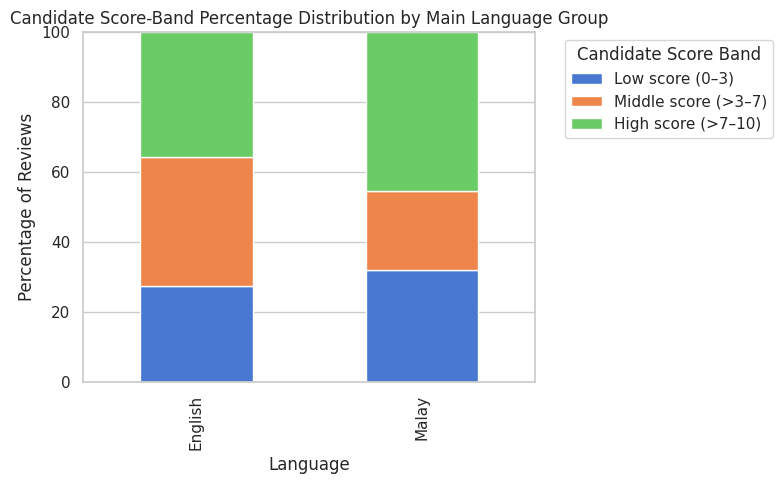

In [25]:
# Percentage stacked bar chart for candidate score bands by language

score_band_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Candidate Score-Band Percentage Distribution by Main Language Group")
plt.xlabel("Language")
plt.ylabel("Percentage of Reviews")
plt.ylim(0, 100)
plt.legend(title="Candidate Score Band", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Score Distribution by Language Interpretation**

The all-language score-quality check shows that English and Malay are the only language groups with enough valid-score rows for meaningful modelling. English has 488 valid-score rows out of 492 total rows, while Malay has 389 valid-score rows out of 402 total rows.

The other language labels are too small to support reliable modelling. Chinese has only 1 valid-score row, Nippon has only 1 valid-score row, and Guga has 0 valid-score rows. The corrupted language labels such as `Come on ...` and `You cannot be serious ...` also have 0 valid-score rows. This means these groups cannot support a meaningful train/validation/test split or language-specific evaluation.

For the two main languages, the score distributions are broadly usable. English has a median score of 5.4 and Malay has a median score of 5.3, so both languages contain a spread of review ratings rather than only one score region. However, the candidate score-band distribution differs by language. English has a larger middle-score proportion at 36.89%, while Malay has a larger high-score proportion at 45.50%.

This supports retaining both English and Malay for modelling instead of using English only. It also justifies a later language strategy comparison because the two languages have different score-band patterns, and the model may behave differently across English and Malay reviews.

### 3.3 Language Distribution and Usability

This subsection checks whether each language label is usable for modelling.

The score-distribution checks in Section 3.2 already showed that English and Malay dominate the valid-score dataset. This subsection goes one step further by inspecting the actual rows from rare or suspicious language labels such as Chinese, Guga, Nippon, and corrupted language values.

No rows are removed here. The purpose is to justify the later Section 4 decision on which languages should be retained for modelling.

In [26]:
# Language usability summary

language_usability_summary = (
    score_eda_df
    .assign(Language_Display=score_eda_df["Language"].fillna("Missing"))
    .groupby("Language_Display")
    .agg(
        raw_rows=("Review", "count"),
        valid_score_rows=("Score_Is_Valid", "sum"),
        invalid_score_rows=("Score_Is_Valid", lambda x: (~x).sum())
    )
    .reset_index()
)

language_usability_summary["valid_score_percentage"] = (
    language_usability_summary["valid_score_rows"]
    / language_usability_summary["raw_rows"]
    * 100
).round(2)

language_usability_summary["likely_modelling_decision"] = np.where(
    language_usability_summary["Language_Display"].isin(["English", "Malay"]),
    "Candidate to keep",
    "Inspect before removal"
)

language_usability_summary = language_usability_summary.sort_values(
    "raw_rows",
    ascending=False
)

display(language_usability_summary)

,Language_Display,raw_rows,valid_score_rows,invalid_score_rows,valid_score_percentage,likely_modelling_decision
2,English,492,488,4,99.19,Candidate to keep
4,Malay,402,389,13,96.77,Candidate to keep
0,Chinese,3,1,2,33.33,Inspect before removal
3,Guga,2,0,2,0.00,Inspect before removal
1,Come on ...,1,0,1,0.00,Inspect before removal
5,Nippon,1,1,0,100.00,Inspect before removal
6,You cannot be serious ...,1,0,1,0.00,Inspect before removal


In [27]:
# Inspect rows from non-English/non-Malay language labels

rare_language_rows = (
    score_eda_df[~score_eda_df["Language"].isin(["English", "Malay"])]
    [["Review", "Score", "Score_Numeric", "Score_Is_Valid", "Language"]]
    .sort_values(["Language", "Score"], na_position="last")
)

display(rare_language_rows)

,Review,Score,Score_Numeric,Score_Is_Valid,Language
898,Hen tai fei chang hao,0.001,0.001000,True,Chinese
901,Jia!,???,NaN,False,Chinese
897,Ni hao,NaN,NaN,False,Chinese
22,Review,Score,NaN,False,Come on ...
896,Oh itz phenomenal!,-42,-42.000000,False,Guga
895,"Ten out of ten, would highly recommend!",1010,1010.000000,False,Guga
899,Nani kore,0.997413,0.997413,True,Nippon
191,Review,Score,NaN,False,You cannot be serious ...


**Language Usability Interpretation**

The language usability check confirms that English and Malay are the only language groups with enough usable rows for modelling. English has 492 raw rows and 488 valid-score rows, while Malay has 402 raw rows and 389 valid-score rows. Both groups have high score-validity rates above 96%.

The remaining language labels are not suitable for modelling. Chinese has only 3 rows, with only 1 valid-score row. Guga has 2 rows and both have invalid scores. Nippon has only 1 row. The labels `Come on ...` and `You cannot be serious ...` are not real language names and appear to be corrupted language-label values.

The row inspection supports this. Some rare-label rows contain invalid or unusable scores such as `???`, missing scores, `1010`, and `-42`. Some rows also appear to contain column-header-like text such as `Review` and `Score`, suggesting corrupted records rather than valid review-language examples.

This supports retaining English and Malay later in Section 4, while removing rare or corrupted language groups. The decision is not based on discarding non-English reviews blindly. Malay is retained because it has substantial usable data, while the other labels are removed because they are too small, invalid, or corrupted for reliable modelling and evaluation.

### 3.4 Review Length and Text Structure

This subsection checks whether the review texts are short or long, and whether review length differs by language or candidate score band.

Review length matters because RNN models require tokenised and padded sequences. If most reviews are short, compact sequence lengths may be enough. If many reviews are long, later models may need longer sequence lengths to avoid truncating useful sentiment information.

This section uses valid-score English and Malay rows as the candidate modelling subset for review-length EDA. No rows are removed here; this only supports later sequence-length and modelling decisions.

In [28]:
# Create review-length fields for valid-score English and Malay rows

review_length_df = valid_score_df[
    valid_score_df["Language"].isin(["English", "Malay"])
].copy()

review_length_df["Review_Text"] = review_length_df["Review"].astype(str).str.strip()

review_length_df["review_word_count"] = (
    review_length_df["Review_Text"]
    .str.split()
    .str.len()
)

review_length_df["review_char_count"] = review_length_df["Review_Text"].str.len()

review_length_df["sentence_like_part_count"] = (
    review_length_df["Review_Text"]
    .str.count(r"[.!?]+")
    .clip(lower=1)
)

review_length_df[[
    "Review",
    "Language",
    "Score_Numeric",
    "review_word_count",
    "review_char_count",
    "sentence_like_part_count"
]].head()

,Review,Language,Score_Numeric,review_word_count,review_char_count,sentence_like_part_count
0,Disgusting.,English,1.0,1,11,1
1,Loved the sambal kick!,English,10.0,4,22,1
2,Loved the sambal kick!,English,0.1,4,22,1
3,Loved the sambal kick!,English,5.0,4,22,1
4,"Satay on pizza? Surprisingly worked. Tasty, un...",English,7.0,10,68,3


In [29]:
# Overall review word-count summary

word_count_summary = (
    review_length_df["review_word_count"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .to_frame(name="review_word_count")
    .round(2)
)

display(word_count_summary)

,review_word_count
count,877.00
mean,8.30
std,5.93
min,1.00
25%,5.00
50%,7.00
75%,10.00
90%,14.00
95%,17.20
max,49.00


In [30]:
# Review word-count summary by language

word_count_by_language = (
    review_length_df
    .groupby("Language")["review_word_count"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .round(2)
)

display(word_count_by_language)

,count,mean,std,min,25%,50%,75%,90%,95%,max
Language,,,,,,,,,,
English,488.0,8.81,6.96,1.0,5.0,8.0,11.0,14.0,17.0,49.0
Malay,389.0,7.66,4.24,1.0,5.0,7.0,9.0,13.0,17.6,24.0


In [31]:
# Candidate score bands for review-length comparison

review_length_df["Candidate_Score_Band"] = review_length_df["Score_Numeric"].apply(
    assign_candidate_score_band
)

word_count_by_band = (
    review_length_df
    .groupby("Candidate_Score_Band")["review_word_count"]
    .describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
    .round(2)
)

display(word_count_by_band)

,count,mean,std,min,25%,50%,75%,90%,95%,max
Candidate_Score_Band,,,,,,,,,,
High score (>7–10),351.0,10.36,5.99,1.0,7.0,10.0,12.0,16.0,18.0,49.0
Low score (0–3),259.0,5.47,3.78,1.0,4.0,5.0,6.0,7.0,9.0,48.0
Middle score (>3–7),267.0,8.34,6.44,1.0,5.0,7.0,9.0,15.4,19.0,49.0


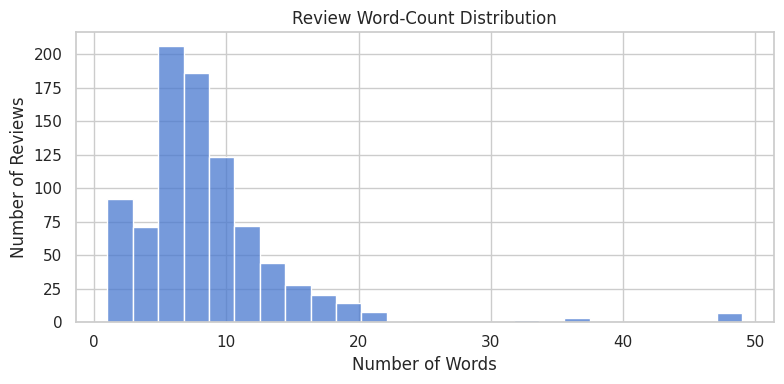

In [32]:
# Review word-count distribution

plt.figure(figsize=(8, 4))

sns.histplot(
    data=review_length_df,
    x="review_word_count",
    bins=25
)

plt.title("Review Word-Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

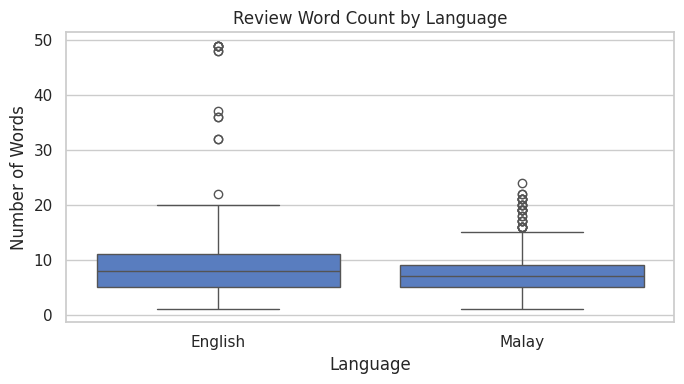

In [33]:
# Review word count by language

plt.figure(figsize=(7, 4))

sns.boxplot(
    data=review_length_df,
    x="Language",
    y="review_word_count"
)

plt.title("Review Word Count by Language")
plt.xlabel("Language")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

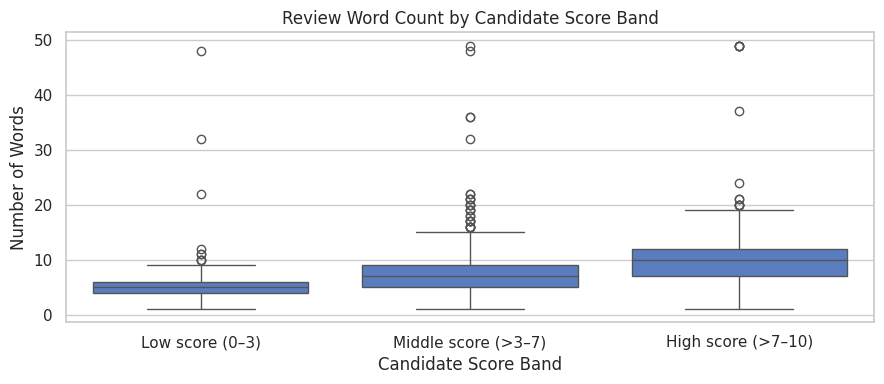

In [34]:
# Review word count by candidate score band

band_order = [
    "Low score (0–3)",
    "Middle score (>3–7)",
    "High score (>7–10)"
]

plt.figure(figsize=(9, 4))

sns.boxplot(
    data=review_length_df,
    x="Candidate_Score_Band",
    y="review_word_count",
    order=band_order
)

plt.title("Review Word Count by Candidate Score Band")
plt.xlabel("Candidate Score Band")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

In [35]:
# Sequence-length coverage for candidate maximum sequence lengths

candidate_sequence_lengths = [15, 25, 40]

sequence_coverage = []

for max_len in candidate_sequence_lengths:
    covered_rows = (review_length_df["review_word_count"] <= max_len).sum()
    total_rows = len(review_length_df)

    sequence_coverage.append({
        "max_sequence_length": max_len,
        "covered_rows": covered_rows,
        "total_rows": total_rows,
        "coverage_percentage": round(covered_rows / total_rows * 100, 2)
    })

sequence_coverage_df = pd.DataFrame(sequence_coverage)

display(sequence_coverage_df)

,max_sequence_length,covered_rows,total_rows,coverage_percentage
0,15,808,877,92.13
1,25,865,877,98.63
2,40,870,877,99.20


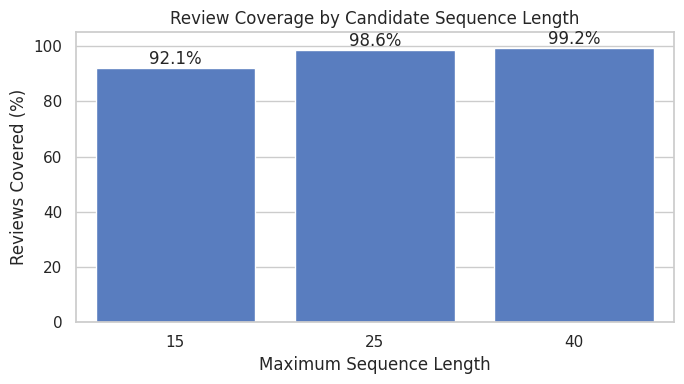

In [36]:
# Sequence-length coverage chart

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=sequence_coverage_df,
    x="max_sequence_length",
    y="coverage_percentage"
)

plt.title("Review Coverage by Candidate Sequence Length")
plt.xlabel("Maximum Sequence Length")
plt.ylabel("Reviews Covered (%)")
plt.ylim(0, 105)

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Review Length and Text Structure Interpretation**

The valid-score English/Malay review set contains 877 rows. The reviews are generally short: the median review length is 7 words, the mean is 8.30 words, and 75% of reviews have 10 words or fewer. Only a small number of reviews are much longer, with the maximum length reaching 49 words.

English reviews are slightly longer than Malay reviews on average. English has a mean length of 8.81 words and a maximum of 49 words, while Malay has a mean length of 7.66 words and a maximum of 24 words. However, both language groups are still short overall, so the model does not need very long input sequences by default.

Review length also differs by candidate score band. Low-score reviews are the shortest, with a median of 5 words. Middle-score reviews have a median of 7 words, while high-score reviews have a median of 10 words. This suggests that some positive or mixed reviews may contain more detailed explanations, while very negative reviews are often short and direct.

The sequence-length coverage results support using compact input lengths. A maximum sequence length of 15 already covers 92.13% of reviews, 25 covers 98.63%, and 40 covers 99.20%. Therefore, `25` is a reasonable default sequence length for baseline models, while `15`, `25`, and `40` are sensible candidates for later controlled sequence-length comparison.

This supports using RNN models with compact padded sequences rather than unnecessarily long text inputs. Review length should also be considered later during error analysis because short, direct reviews and longer mixed reviews may create different prediction difficulties.

### 3.5 Target Framing EDA

This subsection compares different ways to frame the prediction target.

The assignment allows a decision between regression or classification, so the notebook should not assume the target format without evidence. This section compares exact numeric score regression, binary classification, 3-class sentiment classification, and 5-class score-band classification.

The goal is to choose a target that is meaningful, stable enough for the small dataset, and suitable for RNN-based review analysis. No final cleaning is applied here; the formal target engineering step happens later in Section 4.

In [37]:
# Create target-framing EDA dataframe using valid-score English/Malay rows

target_eda_df = valid_score_df[
    valid_score_df["Language"].isin(["English", "Malay"])
].copy()

def assign_binary_sentiment(score):
    if score <= 5:
        return "Negative / Non-positive"
    else:
        return "Positive"

def assign_three_class_sentiment(score):
    if score <= 3:
        return "Negative"
    elif score <= 7:
        return "Mixed/Neutral"
    else:
        return "Positive"

def assign_five_class_sentiment(score):
    if score <= 2:
        return "Very Negative"
    elif score <= 4:
        return "Negative"
    elif score <= 6:
        return "Mixed/Neutral"
    elif score <= 8:
        return "Positive"
    else:
        return "Very Positive"

target_eda_df["Binary_Target"] = target_eda_df["Score_Numeric"].apply(assign_binary_sentiment)
target_eda_df["Three_Class_Target"] = target_eda_df["Score_Numeric"].apply(assign_three_class_sentiment)
target_eda_df["Five_Class_Target"] = target_eda_df["Score_Numeric"].apply(assign_five_class_sentiment)

target_eda_df[[
    "Review",
    "Score_Numeric",
    "Language",
    "Binary_Target",
    "Three_Class_Target",
    "Five_Class_Target"
]].head()

,Review,Score_Numeric,Language,Binary_Target,Three_Class_Target,Five_Class_Target
0,Disgusting.,1.0,English,Negative / Non-positive,Negative,Very Negative
1,Loved the sambal kick!,10.0,English,Positive,Positive,Very Positive
2,Loved the sambal kick!,0.1,English,Negative / Non-positive,Negative,Very Negative
3,Loved the sambal kick!,5.0,English,Negative / Non-positive,Mixed/Neutral,Mixed/Neutral
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7.0,English,Positive,Mixed/Neutral,Positive


In [38]:
# Candidate target distribution tables

binary_counts = target_eda_df["Binary_Target"].value_counts().rename_axis("Binary_Target").reset_index(name="count")
three_class_counts = target_eda_df["Three_Class_Target"].value_counts().rename_axis("Three_Class_Target").reset_index(name="count")
five_class_counts = target_eda_df["Five_Class_Target"].value_counts().rename_axis("Five_Class_Target").reset_index(name="count")

print("Binary target distribution:")
display(binary_counts)

print("3-class target distribution:")
display(three_class_counts)

print("5-class target distribution:")
display(five_class_counts)

Binary target distribution:


,Binary_Target,count
0,Positive,536
1,Negative / Non-positive,341


3-class target distribution:


,Three_Class_Target,count
0,Positive,351
1,Mixed/Neutral,267
2,Negative,259


5-class target distribution:


,Five_Class_Target,count
0,Very Positive,332
1,Very Negative,247
2,Mixed/Neutral,223
3,Negative,42
4,Positive,33


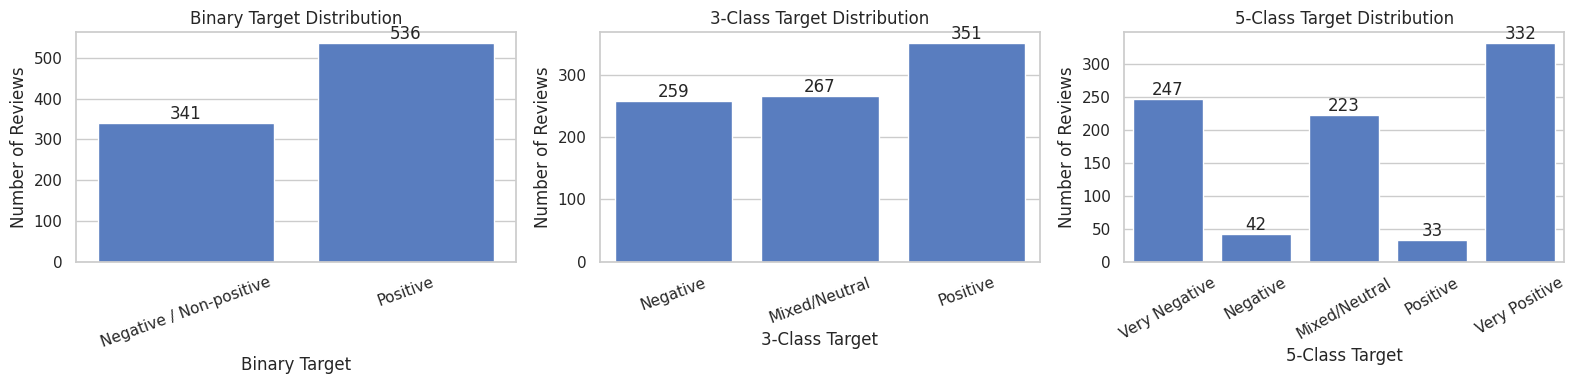

In [39]:
# Candidate target distribution charts

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.countplot(
    data=target_eda_df,
    x="Binary_Target",
    order=["Negative / Non-positive", "Positive"],
    ax=axes[0]
)
axes[0].set_title("Binary Target Distribution")
axes[0].set_xlabel("Binary Target")
axes[0].set_ylabel("Number of Reviews")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(
    data=target_eda_df,
    x="Three_Class_Target",
    order=["Negative", "Mixed/Neutral", "Positive"],
    ax=axes[1]
)
axes[1].set_title("3-Class Target Distribution")
axes[1].set_xlabel("3-Class Target")
axes[1].set_ylabel("Number of Reviews")
axes[1].tick_params(axis="x", rotation=20)

sns.countplot(
    data=target_eda_df,
    x="Five_Class_Target",
    order=["Very Negative", "Negative", "Mixed/Neutral", "Positive", "Very Positive"],
    ax=axes[2]
)
axes[2].set_title("5-Class Target Distribution")
axes[2].set_xlabel("5-Class Target")
axes[2].set_ylabel("Number of Reviews")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

In [40]:
# 3-class sentiment distribution by language

three_class_by_language = pd.crosstab(
    target_eda_df["Language"],
    target_eda_df["Three_Class_Target"]
)

three_class_by_language = three_class_by_language[
    ["Negative", "Mixed/Neutral", "Positive"]
]

three_class_by_language_pct = (
    three_class_by_language
    .div(three_class_by_language.sum(axis=1), axis=0)
    * 100
).round(2)

print("3-class counts by language:")
display(three_class_by_language)

print("3-class percentage distribution by language:")
display(three_class_by_language_pct)

3-class counts by language:


Three_Class_Target,Negative,Mixed/Neutral,Positive
Language,,,
English,134,180,174
Malay,125,87,177


3-class percentage distribution by language:


Three_Class_Target,Negative,Mixed/Neutral,Positive
Language,,,
English,27.46,36.89,35.66
Malay,32.13,22.37,45.50


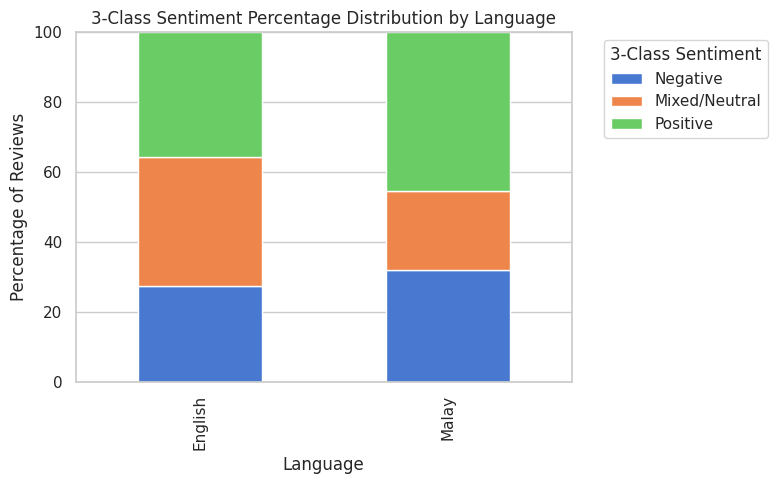

In [41]:
# Percentage stacked bar chart for 3-class sentiment by language

three_class_by_language_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("3-Class Sentiment Percentage Distribution by Language")
plt.xlabel("Language")
plt.ylabel("Percentage of Reviews")
plt.ylim(0, 100)
plt.legend(title="3-Class Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Target Framing Interpretation**

The candidate target comparison supports using 3-class sentiment classification later in Section 4.

Regression is possible in theory because the score column is numeric after conversion, but it is not the most robust framing for this dataset. Earlier score checks showed invalid scores, decimal scores, repeated review texts with different scores, and uneven score clustering. Predicting exact numeric scores would therefore be fragile and harder to interpret for review-level sentiment analysis.

Binary classification is simple, but it loses too much information. It combines low and middle ratings into one broad `Negative / Non-positive` group, even though a review with score 5 or 6 is not the same as a clearly negative review with score 0 or 1.

The 5-class target creates weak small classes. Although `Very Positive`, `Very Negative`, and `Mixed/Neutral` have reasonable counts, the ordinary `Negative` and `Positive` classes have only 42 and 33 rows respectively. These small classes would make train/validation/test splitting and class-level model evaluation less reliable.

The 3-class target gives the best balance between detail and stability. The candidate classes are reasonably sized: 259 Negative, 267 Mixed/Neutral, and 351 Positive reviews. This preserves a meaningful middle sentiment class while avoiding the very small classes created by the 5-class framing.

The language breakdown also shows that both English and Malay contain all three sentiment classes. However, their distributions differ: English has a larger Mixed/Neutral proportion at 36.89%, while Malay has a larger Positive proportion at 45.50%. This supports both retaining English and Malay, and later comparing language-handling strategies.

Based on this EDA, the notebook will proceed with 3-class sentiment classification in Section 4:
`0–3 = Negative`, `>3–7 = Mixed/Neutral`, and `>7–10 = Positive`.

### 3.6 Duplicate Review and Label Conflict EDA

This subsection checks whether the same review text appears multiple times and whether repeated reviews have consistent or conflicting labels.

Duplicate review texts matter because they can cause memorisation and leakage if the same text appears in different splits. They are also important for target reliability because the same review may appear with different numeric scores or different sentiment labels.

No duplicate rows are removed here. This section only measures the duplicate issue so that Section 4 can apply a clear duplicate-handling rule.

In [42]:
# Create duplicate EDA dataframe from valid-score English/Malay target EDA data

duplicate_eda_df = target_eda_df.copy()

duplicate_eda_df["Review_Normalized"] = (
    duplicate_eda_df["Review"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

duplicate_eda_df[[
    "Review",
    "Review_Normalized",
    "Score_Numeric",
    "Three_Class_Target",
    "Language"
]].head()

,Review,Review_Normalized,Score_Numeric,Three_Class_Target,Language
0,Disgusting.,disgusting.,1.0,Negative,English
1,Loved the sambal kick!,loved the sambal kick!,10.0,Positive,English
2,Loved the sambal kick!,loved the sambal kick!,0.1,Negative,English
3,Loved the sambal kick!,loved the sambal kick!,5.0,Mixed/Neutral,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...","satay on pizza? surprisingly worked. tasty, un...",7.0,Mixed/Neutral,English


In [43]:
# Duplicate issue summary

exact_duplicate_rows = duplicate_eda_df.duplicated().sum()

duplicate_review_rows = duplicate_eda_df.duplicated(
    subset=["Review_Normalized"],
    keep=False
).sum()

duplicate_review_groups = (
    duplicate_eda_df
    .groupby("Review_Normalized")
    .size()
    .reset_index(name="group_size")
)

duplicate_review_groups = duplicate_review_groups[
    duplicate_review_groups["group_size"] > 1
]

duplicate_group_details = (
    duplicate_eda_df
    .groupby("Review_Normalized")
    .agg(
        group_size=("Review", "size"),
        unique_scores=("Score_Numeric", "nunique"),
        unique_sentiments=("Three_Class_Target", "nunique")
    )
    .reset_index()
)

duplicate_group_details = duplicate_group_details[
    duplicate_group_details["group_size"] > 1
].copy()

same_score_duplicate_groups = (duplicate_group_details["unique_scores"] == 1).sum()
conflicting_score_duplicate_groups = (duplicate_group_details["unique_scores"] > 1).sum()

same_sentiment_duplicate_groups = (duplicate_group_details["unique_sentiments"] == 1).sum()
conflicting_sentiment_duplicate_groups = (duplicate_group_details["unique_sentiments"] > 1).sum()

duplicate_summary = pd.DataFrame({
    "Duplicate Issue": [
        "Exact duplicate rows",
        "Rows involved in duplicate review texts",
        "Duplicate review-text groups",
        "Same-score duplicate groups",
        "Conflicting-score duplicate groups",
        "Same-sentiment duplicate groups",
        "Conflicting-sentiment duplicate groups"
    ],
    "Count": [
        exact_duplicate_rows,
        duplicate_review_rows,
        len(duplicate_group_details),
        same_score_duplicate_groups,
        conflicting_score_duplicate_groups,
        same_sentiment_duplicate_groups,
        conflicting_sentiment_duplicate_groups
    ]
})

display(duplicate_summary)

,Duplicate Issue,Count
0,Exact duplicate rows,42
1,Rows involved in duplicate review texts,147
2,Duplicate review-text groups,51
3,Same-score duplicate groups,9
4,Conflicting-score duplicate groups,42
5,Same-sentiment duplicate groups,36
6,Conflicting-sentiment duplicate groups,15


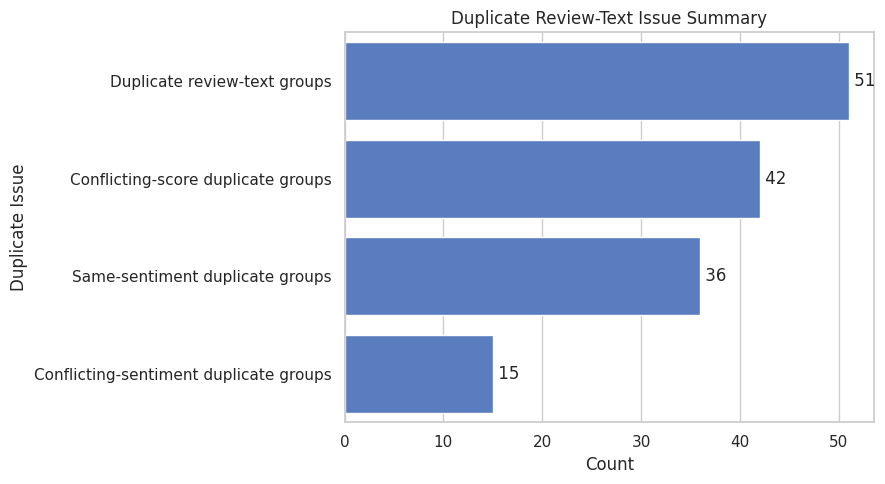

In [44]:
# Duplicate issue chart

plt.figure(figsize=(9, 5))

plot_data = duplicate_summary[
    duplicate_summary["Duplicate Issue"].isin([
        "Duplicate review-text groups",
        "Same-sentiment duplicate groups",
        "Conflicting-sentiment duplicate groups",
        "Conflicting-score duplicate groups"
    ])
].copy()

ax = sns.barplot(
    data=plot_data,
    x="Count",
    y="Duplicate Issue"
)

plt.title("Duplicate Review-Text Issue Summary")
plt.xlabel("Count")
plt.ylabel("Duplicate Issue")

for bar in ax.patches:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [45]:
# Inspect examples where the same review text has conflicting numeric scores

conflicting_score_keys = duplicate_group_details[
    duplicate_group_details["unique_scores"] > 1
]["Review_Normalized"]

conflicting_score_examples = (
    duplicate_eda_df[duplicate_eda_df["Review_Normalized"].isin(conflicting_score_keys)]
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "Review_Normalized"]]
    .sort_values(["Review_Normalized", "Score_Numeric"])
)

display(conflicting_score_examples.head(30))

,Review,Score_Numeric,Three_Class_Target,Language,Review_Normalized
45,Amazing!,9.00,Positive,English,amazing!
60,Amazing!,10.00,Positive,English,amazing!
72,Creative but not for everyone.,4.00,Mixed/Neutral,English,creative but not for everyone.
38,Creative but not for everyone.,5.00,Mixed/Neutral,English,creative but not for everyone.
0,Disgusting.,1.00,Negative,English,disgusting.
70,Disgusting.,1.00,Negative,English,disgusting.
15,Disgusting.,2.00,Negative,English,disgusting.
26,Disgusting.,2.00,Negative,English,disgusting.
86,Divine crust.,3.27,Mixed/Neutral,English,divine crust.
114,Divine crust.,4.22,Mixed/Neutral,English,divine crust.


In [46]:
# Inspect examples where the same review text has conflicting sentiment labels

conflicting_sentiment_keys = duplicate_group_details[
    duplicate_group_details["unique_sentiments"] > 1
]["Review_Normalized"]

conflicting_sentiment_examples = (
    duplicate_eda_df[duplicate_eda_df["Review_Normalized"].isin(conflicting_sentiment_keys)]
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "Review_Normalized"]]
    .sort_values(["Review_Normalized", "Score_Numeric"])
)

display(conflicting_sentiment_examples.head(30))

,Review,Score_Numeric,Three_Class_Target,Language,Review_Normalized
109,Like nasi lemak crashed into an Italian kitche...,5.99,Mixed/Neutral,English,like nasi lemak crashed into an italian kitche...
84,Like nasi lemak crashed into an Italian kitche...,7.16,Positive,English,like nasi lemak crashed into an italian kitche...
96,Love at first bite.,0.04,Negative,English,love at first bite.
106,Love at first bite.,5.72,Mixed/Neutral,English,love at first bite.
82,Love at first bite.,8.49,Positive,English,love at first bite.
115,Love at first bite.,8.79,Positive,English,love at first bite.
2,Loved the sambal kick!,0.10,Negative,English,loved the sambal kick!
3,Loved the sambal kick!,5.00,Mixed/Neutral,English,loved the sambal kick!
1,Loved the sambal kick!,10.00,Positive,English,loved the sambal kick!
92,Meets expectations.,2.19,Negative,English,meets expectations.


In [47]:
# Inspect examples where duplicate review texts keep the same sentiment label

same_sentiment_keys = duplicate_group_details[
    duplicate_group_details["unique_sentiments"] == 1
]["Review_Normalized"]

same_sentiment_examples = (
    duplicate_eda_df[duplicate_eda_df["Review_Normalized"].isin(same_sentiment_keys)]
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "Review_Normalized"]]
    .sort_values(["Review_Normalized", "Score_Numeric"])
)

display(same_sentiment_examples.head(30))

,Review,Score_Numeric,Three_Class_Target,Language,Review_Normalized
45,Amazing!,9.00,Positive,English,amazing!
60,Amazing!,10.00,Positive,English,amazing!
72,Creative but not for everyone.,4.00,Mixed/Neutral,English,creative but not for everyone.
38,Creative but not for everyone.,5.00,Mixed/Neutral,English,creative but not for everyone.
19,"Crust was thin and crispy, just right.",6.00,Mixed/Neutral,English,"crust was thin and crispy, just right."
30,"Crust was thin and crispy, just right.",6.00,Mixed/Neutral,English,"crust was thin and crispy, just right."
0,Disgusting.,1.00,Negative,English,disgusting.
70,Disgusting.,1.00,Negative,English,disgusting.
15,Disgusting.,2.00,Negative,English,disgusting.
26,Disgusting.,2.00,Negative,English,disgusting.


**Duplicate Review and Label Conflict Interpretation**

The duplicate review check shows that duplicate texts are a real data-quality issue. Within the valid-score English/Malay EDA set, there are 42 exact duplicate rows and 147 rows involved in repeated review texts. These repeated rows belong to 51 unique duplicate review-text groups.

The most important issue is that many repeated review texts do not have consistent numeric scores. Out of the 51 duplicate review-text groups, 42 groups have conflicting numeric scores. This means the same review text can appear with different score values, which makes exact score regression unreliable because the model would receive contradictory numeric targets for identical input text.

However, the conflict becomes smaller after converting scores into broader 3-class sentiment labels. There are 36 duplicate groups where the repeated review texts still map to the same sentiment class, and 15 groups where the same review text maps to conflicting sentiment classes. This supports the earlier target-framing decision: 3-class sentiment classification is more stable than exact numeric score prediction, but duplicate conflicts still need to be handled.

Duplicate handling should happen after target engineering because the duplicate decision depends on the final modelling target. Some repeated review texts have different numeric scores but still belong to the same 3-class sentiment label. For example, scores 1 and 2 are both Negative. These rows are inconsistent for exact score regression, but they are not contradictory for 3-class sentiment classification, so keeping one representative row is enough.

Other repeated review texts map to different sentiment classes, such as the same review appearing as Negative, Mixed/Neutral, and Positive depending on the score. These rows provide contradictory supervision for the final classification task, so the full duplicate group should be removed.

Therefore, duplicate handling will be applied after the 3-class target is created, but before the train/validation/test split. Duplicate groups with conflicting sentiment labels should be removed, while duplicate groups with the same sentiment label should be reduced to one representative row. This reduces unreliable supervision, lowers memorisation risk, and prevents identical review text from leaking across train, validation, and test splits.

### 3.7 Score vs Review Length

This subsection checks whether review length is related to score or sentiment class.

This matters because very short reviews may express direct sentiment with few words, while longer reviews may contain mixed or more detailed opinions. If review length affects model difficulty, it should be considered later during model evaluation and review-level error analysis.

No rows are removed here. This section only provides modelling context.

In [48]:
# Prepare score vs review length dataframe

score_length_df = target_eda_df.copy()

score_length_df["Review_Text"] = score_length_df["Review"].astype(str).str.strip()

score_length_df["review_word_count"] = (
    score_length_df["Review_Text"]
    .str.split()
    .str.len()
)

score_length_summary = (
    score_length_df
    .groupby("Three_Class_Target")["review_word_count"]
    .agg(["count", "min", "median", "mean", "max"])
    .round(2)
    .reindex(["Negative", "Mixed/Neutral", "Positive"])
)

display(score_length_summary)

,count,min,median,mean,max
Three_Class_Target,,,,,
Negative,259,1,5.0,5.47,48
Mixed/Neutral,267,1,7.0,8.34,49
Positive,351,1,10.0,10.36,49


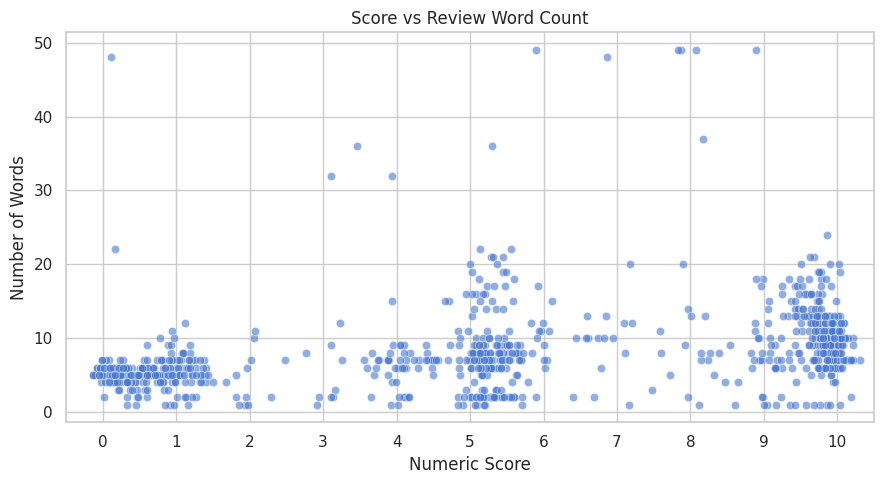

In [49]:
# Score versus review word count
rng = np.random.default_rng(SEED)

score_length_plot_df = score_length_df.copy()
score_length_plot_df["Score_Jittered"] = (
    score_length_plot_df["Score_Numeric"]
    + rng.normal(0, 0.12, size=len(score_length_plot_df))
)

plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=score_length_plot_df,
    x="Score_Jittered",
    y="review_word_count",
    alpha=0.6
)

plt.title("Score vs Review Word Count")
plt.xlabel("Numeric Score")
plt.ylabel("Number of Words")
plt.xlim(-0.5, 10.5)
plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()

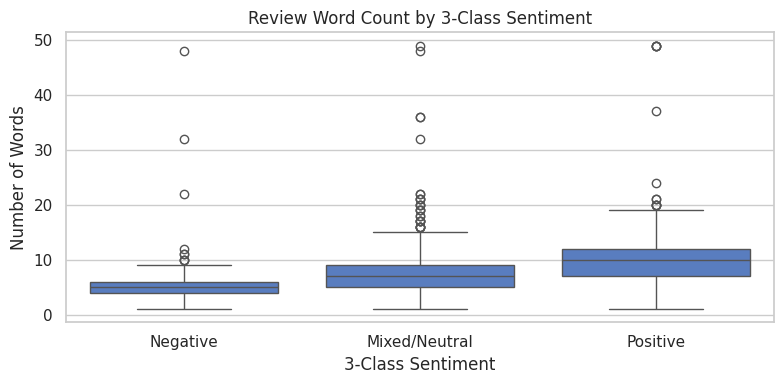

In [50]:
# Review word count by 3-class sentiment

sentiment_order = ["Negative", "Mixed/Neutral", "Positive"]

plt.figure(figsize=(8, 4))

sns.boxplot(
    data=score_length_df,
    x="Three_Class_Target",
    y="review_word_count",
    order=sentiment_order
)

plt.title("Review Word Count by 3-Class Sentiment")
plt.xlabel("3-Class Sentiment")
plt.ylabel("Number of Words")
plt.tight_layout()
plt.show()

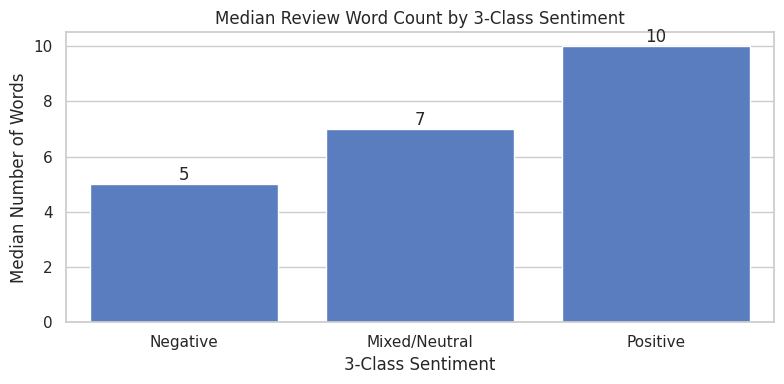

In [51]:
# Median review word count by sentiment

median_length_by_sentiment = (
    score_length_df
    .groupby("Three_Class_Target")["review_word_count"]
    .median()
    .reindex(sentiment_order)
    .reset_index()
)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=median_length_by_sentiment,
    x="Three_Class_Target",
    y="review_word_count",
    order=sentiment_order
)

plt.title("Median Review Word Count by 3-Class Sentiment")
plt.xlabel("3-Class Sentiment")
plt.ylabel("Median Number of Words")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Score vs Review Length Interpretation**

Review length appears to differ by sentiment class. Negative reviews are the shortest, with a median length of 5 words and a mean length of 5.47 words. Mixed/Neutral reviews are longer, with a median of 7 words and a mean of 8.34 words. Positive reviews are the longest overall, with a median of 10 words and a mean of 10.36 words.

The cleaner score-versus-length plot shows that review length is not strongly linear with numeric score. Short reviews appear across many score values, and there are a few long-review outliers across low, middle, and high scores. However, the broader class-level pattern is still clear: low-score reviews are usually shorter and more direct, while Mixed/Neutral and Positive reviews tend to contain more words.

This has modelling implications. Short Negative reviews may be easier for the model because they often contain direct sentiment cues. Mixed/Neutral reviews may be harder because they can include more detail, mixed opinions, or less obvious sentiment. Longer Positive reviews may also contain more descriptive context, making sequence length relevant.

This supports keeping review length in mind during later model evaluation and review-level error analysis. If the final model makes mistakes, Section 10 or 11 should check whether errors are concentrated in very short reviews, longer reviews, or the Mixed/Neutral class.

### 3.8 Sentence/Clause Splitting Feasibility EDA

This subsection checks whether sentence or clause splitting is worth testing later as engineered training data.

The assignment requires considering ways to engineer the given data to produce more training data. One possible method is to split longer reviews into sentence-like or clause-like fragments. This would create additional training samples using only the provided dataset.

This section only checks feasibility. It does not create the final engineered training set yet. The actual experiment happens later after the train/validation/test split, so that only the training set is expanded and the validation/test sets remain untouched.

In [52]:
# Simple sentence/clause splitting helpers for feasibility EDA

def split_review_into_fragments(text, min_words=3):
    text = str(text).strip()

    # Split on sentence punctuation first
    parts = pd.Series([text]).str.split(r"[.!?]+", regex=True).iloc[0]

    fragments = []

    for part in parts:
        part = str(part).strip()

        # Basic clause splitting on common contrast words
        clause_parts = pd.Series([part]).str.split(
            r"\b(?:but|however|tetapi)\b",
            regex=True
        ).iloc[0]

        for fragment in clause_parts:
            fragment = str(fragment).strip(" ,;:-")
            word_count = len(fragment.split())

            if word_count >= min_words:
                fragments.append(fragment)

    return fragments


def is_splittable_review(text, min_words=3):
    fragments = split_review_into_fragments(text, min_words=min_words)
    return len(fragments) >= 2

In [53]:
# Create sentence/clause splitting feasibility fields

splitting_eda_df = target_eda_df.copy()

splitting_eda_df["Review_Text"] = splitting_eda_df["Review"].astype(str).str.strip()

splitting_eda_df["split_fragments"] = splitting_eda_df["Review_Text"].apply(
    split_review_into_fragments
)

splitting_eda_df["estimated_fragment_count"] = splitting_eda_df["split_fragments"].str.len()

splitting_eda_df["is_splittable"] = splitting_eda_df["estimated_fragment_count"] >= 2

splitting_eda_df[[
    "Review",
    "Language",
    "Three_Class_Target",
    "estimated_fragment_count",
    "is_splittable",
    "split_fragments"
]].head(10)

,Review,Language,Three_Class_Target,estimated_fragment_count,is_splittable,split_fragments
0,Disgusting.,English,Negative,0,False,[]
1,Loved the sambal kick!,English,Positive,1,False,[Loved the sambal kick]
2,Loved the sambal kick!,English,Negative,1,False,[Loved the sambal kick]
3,Loved the sambal kick!,English,Mixed/Neutral,1,False,[Loved the sambal kick]
4,"Satay on pizza? Surprisingly worked. Tasty, un...",English,Mixed/Neutral,2,True,"[Satay on pizza, Tasty, unique, would try again]"
5,Mayo was too sweet. Didn't enjoy it at all.,English,Negative,2,True,"[Mayo was too sweet, Didn't enjoy it at all]"
6,"Spicy sambal was overwhelming for me, but the ...",English,Mixed/Neutral,3,True,"[Spicy sambal was overwhelming for me, the sat..."
7,"Crust was soggy, and the satay sauce didn’t he...",English,Mixed/Neutral,2,True,"[Crust was soggy, and the satay sauce didn’t h..."
8,Super creative! Sambal slice was fiery and bol...,English,Mixed/Neutral,3,True,"[Sambal slice was fiery and bold, Satay was ri..."
9,The sambal slice burned my mouth in the best w...,English,Positive,5,True,[The sambal slice burned my mouth in the best ...


In [54]:
# Overall splittable review summary

splittable_summary = pd.DataFrame({
    "Review Type": ["Non-splittable reviews", "Splittable reviews"],
    "Count": [
        (~splitting_eda_df["is_splittable"]).sum(),
        splitting_eda_df["is_splittable"].sum()
    ]
})

splittable_summary["Percentage"] = (
    splittable_summary["Count"] / len(splitting_eda_df) * 100
).round(2)

display(splittable_summary)

,Review Type,Count,Percentage
0,Non-splittable reviews,716,81.64
1,Splittable reviews,161,18.36


In [55]:
# Splittable review count by sentiment and language

splittable_by_sentiment = pd.crosstab(
    splitting_eda_df["Three_Class_Target"],
    splitting_eda_df["is_splittable"]
).rename(columns={False: "Non-splittable", True: "Splittable"})

splittable_by_sentiment = splittable_by_sentiment.reindex(
    ["Negative", "Mixed/Neutral", "Positive"]
)

splittable_by_language = pd.crosstab(
    splitting_eda_df["Language"],
    splitting_eda_df["is_splittable"]
).rename(columns={False: "Non-splittable", True: "Splittable"})

print("Splittable reviews by sentiment:")
display(splittable_by_sentiment)

print("Splittable reviews by language:")
display(splittable_by_language)

Splittable reviews by sentiment:


is_splittable,Non-splittable,Splittable
Three_Class_Target,,
Negative,253,6
Mixed/Neutral,184,83
Positive,279,72


Splittable reviews by language:


is_splittable,Non-splittable,Splittable
Language,,
English,384,104
Malay,332,57


In [56]:
# Estimated fragment count by sentiment

fragment_count_by_sentiment = (
    splitting_eda_df
    .groupby("Three_Class_Target")["estimated_fragment_count"]
    .agg(["count", "sum", "mean", "max"])
    .round(2)
    .reindex(["Negative", "Mixed/Neutral", "Positive"])
)

fragment_count_by_sentiment = fragment_count_by_sentiment.rename(columns={
    "count": "review_count",
    "sum": "estimated_total_fragments",
    "mean": "mean_fragments_per_review",
    "max": "max_fragments_in_review"
})

display(fragment_count_by_sentiment)

,review_count,estimated_total_fragments,mean_fragments_per_review,max_fragments_in_review
Three_Class_Target,,,,
Negative,259,246,0.95,6
Mixed/Neutral,267,348,1.30,7
Positive,351,439,1.25,7


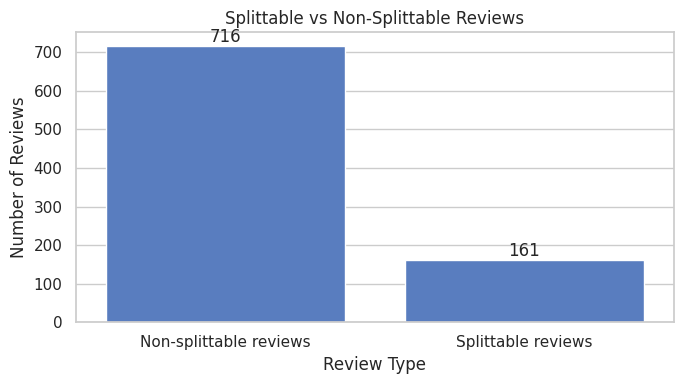

In [57]:
# Splittable vs non-splittable review chart

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=splittable_summary,
    x="Review Type",
    y="Count"
)

plt.title("Splittable vs Non-Splittable Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

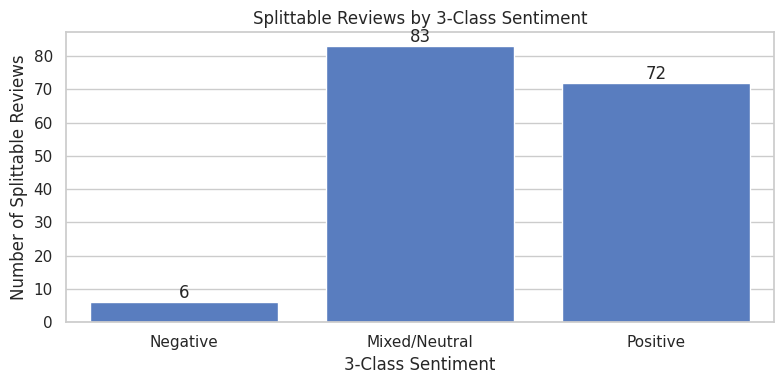

In [58]:
# Splittable reviews by sentiment

splittable_sentiment_plot = (
    splitting_eda_df[splitting_eda_df["is_splittable"]]
    ["Three_Class_Target"]
    .value_counts()
    .reindex(["Negative", "Mixed/Neutral", "Positive"])
    .fillna(0)
    .reset_index()
)

splittable_sentiment_plot.columns = ["Three_Class_Target", "Splittable Review Count"]

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=splittable_sentiment_plot,
    x="Three_Class_Target",
    y="Splittable Review Count"
)

plt.title("Splittable Reviews by 3-Class Sentiment")
plt.xlabel("3-Class Sentiment")
plt.ylabel("Number of Splittable Reviews")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

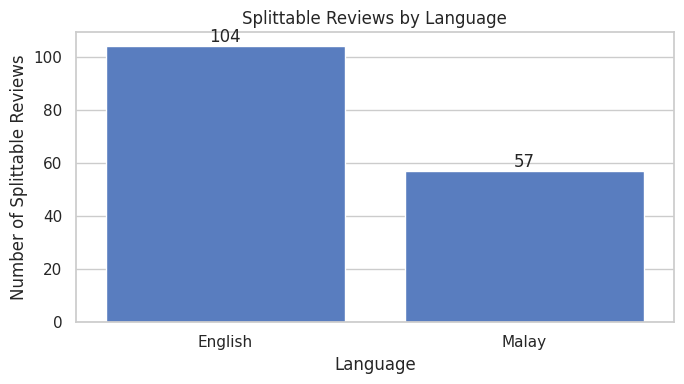

In [59]:
# Splittable reviews by language

splittable_language_plot = (
    splitting_eda_df[splitting_eda_df["is_splittable"]]
    ["Language"]
    .value_counts()
    .reset_index()
)

splittable_language_plot.columns = ["Language", "Splittable Review Count"]

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=splittable_language_plot,
    x="Language",
    y="Splittable Review Count"
)

plt.title("Splittable Reviews by Language")
plt.xlabel("Language")
plt.ylabel("Number of Splittable Reviews")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Sentence/Clause Splitting Feasibility Interpretation**

The sentence/clause splitting feasibility check shows that sentence splitting is possible, but only for a minority of reviews. Out of 877 valid-score English/Malay reviews, 161 reviews are splittable, which is 18.36% of the candidate modelling dataset. Most reviews are not splittable because the dataset mainly contains short review texts.

The splittable reviews are not evenly distributed across sentiment classes. Only 6 Negative reviews are splittable, compared with 83 Mixed/Neutral reviews and 72 Positive reviews. This means sentence/clause splitting would mostly create extra examples from Mixed/Neutral and Positive reviews, while contributing very little new Negative training data.

The language breakdown also shows that both English and Malay have splittable reviews. English has 104 splittable reviews and Malay has 57, so the method is not limited to English only. However, English contributes more splittable examples overall.

The estimated fragment counts also suggest that splitting could create a meaningful number of additional training samples, especially for Mixed/Neutral and Positive reviews. Mixed/Neutral reviews have an estimated 348 fragments and Positive reviews have an estimated 439 fragments. Negative reviews have fewer estimated fragments because they are often short and direct.

This supports testing sentence/clause splitting later as an engineered training-data experiment, but it should not be assumed to improve performance. The method may introduce label noise because fragments inherit the parent review label. This is especially risky for Mixed/Neutral reviews, where one clause may sound positive while another sounds negative. It may also worsen class imbalance unless fragment generation is controlled.

Therefore, sentence/clause splitting is worth testing in the model-improvement section, but only after the train/validation/test split. The validation and test sets should remain as original full reviews, while only the training set should be expanded.

### 3.9 Example Review Inspection

This subsection inspects actual review examples from important cases found during EDA.

The purpose is to check whether the engineered labels and data-quality findings make sense at the review-text level. Metrics and charts are useful, but review analysis also requires qualitative inspection because sentiment labels can be ambiguous, duplicated, or noisy.

No rows are removed here. This section supports later cleaning decisions and motivates review-level error analysis after final model evaluation.

In [60]:
# Short Negative and Positive review examples

short_examples = target_eda_df.copy()

short_examples["review_word_count"] = (
    short_examples["Review"]
    .astype(str)
    .str.split()
    .str.len()
)

short_negative_examples = (
    short_examples[
        (short_examples["Three_Class_Target"] == "Negative")
        & (short_examples["review_word_count"] <= 5)
    ]
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "review_word_count"]]
    .head(8)
)

short_positive_examples = (
    short_examples[
        (short_examples["Three_Class_Target"] == "Positive")
        & (short_examples["review_word_count"] <= 5)
    ]
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "review_word_count"]]
    .head(8)
)

print("Short Negative examples:")
display(short_negative_examples)

print("Short Positive examples:")
display(short_positive_examples)

Short Negative examples:


,Review,Score_Numeric,Three_Class_Target,Language,review_word_count
0,Disgusting.,1.0,Negative,English,1
2,Loved the sambal kick!,0.1,Negative,English,4
10,Just weird.,2.0,Negative,English,2
15,Disgusting.,2.0,Negative,English,1
26,Disgusting.,2.0,Negative,English,1
37,Gross.,2.0,Negative,English,1
40,Just weird.,3.0,Negative,English,2
46,Wouldn’t order again.,3.0,Negative,English,3


Short Positive examples:


,Review,Score_Numeric,Three_Class_Target,Language,review_word_count
1,Loved the sambal kick!,10.00,Positive,English,4
36,So good!,9.00,Positive,English,2
39,Perfect crust.,9.00,Positive,English,2
44,Loved it!,10.00,Positive,English,2
45,Amazing!,9.00,Positive,English,1
60,Amazing!,10.00,Positive,English,1
67,Perfect crust.,9.00,Positive,English,2
74,Revolutionary!,7.05,Positive,English,1


In [61]:
# Mixed/Neutral review examples

mixed_examples = (
    short_examples[short_examples["Three_Class_Target"] == "Mixed/Neutral"]
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "review_word_count"]]
    .sort_values("review_word_count", ascending=False)
    .head(10)
)

display(mixed_examples)

,Review,Score_Numeric,Three_Class_Target,Language,review_word_count
91,The sambal slice burned my mouth in the best w...,5.91,Mixed/Neutral,English,49
85,A punch of Southeast Asia wrapped in a familia...,6.81,Mixed/Neutral,English,48
100,This pizza broke my brain in the best way. Sam...,3.48,Mixed/Neutral,English,36
113,Unexpectedly delightful. Never thought I'd enj...,5.29,Mixed/Neutral,English,36
43,"Not my favorite. The sambal was too spicy, the...",4.00,Mixed/Neutral,English,32
700,Pizza fusion ni tak terlalu sedap tapi tak pul...,5.30,Mixed/Neutral,Malay,22
685,Fusion pizza ini boleh diterima. Rasa sambal t...,5.40,Mixed/Neutral,Malay,22
686,Pizza fusion ini ok tapi tiada apa yang menari...,5.15,Mixed/Neutral,Malay,21
688,Rasa pizza fusion ini agak sederhana. Sambal t...,5.55,Mixed/Neutral,Malay,21
689,"Tidak buruk, tapi tak ada rasa yang buat saya ...",5.20,Mixed/Neutral,Malay,21


In [62]:
# Malay review examples by sentiment

malay_examples = (
    short_examples[short_examples["Language"] == "Malay"]
    .sort_values(["Three_Class_Target", "Score_Numeric"])
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "review_word_count"]]
)

display(malay_examples.groupby("Three_Class_Target").head(5))

,Review,Score_Numeric,Three_Class_Target,Language,review_word_count
475,Roti keras dan topping tidak cukup segar.,3.460,Mixed/Neutral,Malay,7
448,Sambal terlalu kuat sampai rasa lain hilang.,3.578,Mixed/Neutral,Malay,7
521,Roti terlalu keras dan topping kurang.,3.670,Mixed/Neutral,Malay,6
490,"Roti terlalu keras, kurang lembut.",3.735,Mixed/Neutral,Malay,5
479,Rasa yang tidak sesuai dengan jangkaan saya.,3.750,Mixed/Neutral,Malay,7
718,Tak akan cuba lagi.,0.000,Negative,Malay,4
726,"Penuh kekecewaan, tak puas hati.",0.000,Negative,Malay,5
736,Rasa yang tak boleh diterima.,0.000,Negative,Malay,5
743,Saya tak boleh habiskan pizza ni.,0.000,Negative,Malay,6
756,Roti keras dan topping basi.,0.000,Negative,Malay,5


In [63]:
# Long review examples

long_review_examples = (
    short_examples
    .sort_values("review_word_count", ascending=False)
    [["Review", "Score_Numeric", "Three_Class_Target", "Language", "review_word_count"]]
    .head(10)
)

display(long_review_examples)

,Review,Score_Numeric,Three_Class_Target,Language,review_word_count
91,The sambal slice burned my mouth in the best w...,5.91,Mixed/Neutral,English,49
28,The sambal slice burned my mouth in the best w...,8.00,Positive,English,49
17,The sambal slice burned my mouth in the best w...,8.00,Positive,English,49
9,The sambal slice burned my mouth in the best w...,8.00,Positive,English,49
48,The sambal slice burned my mouth in the best w...,9.00,Positive,English,49
81,"The crust was perfect—thin, blistered, slightl...",0.22,Negative,English,48
85,A punch of Southeast Asia wrapped in a familia...,6.81,Mixed/Neutral,English,48
33,What a surprise! Satay on a pizza shouldn’t wo...,8.00,Positive,English,37
100,This pizza broke my brain in the best way. Sam...,3.48,Mixed/Neutral,English,36
113,Unexpectedly delightful. Never thought I'd enj...,5.29,Mixed/Neutral,English,36


In [64]:
# Conflicting duplicate review examples

display(
    conflicting_sentiment_examples[
        ["Review", "Score_Numeric", "Three_Class_Target", "Language", "Review_Normalized"]
    ].head(20)
)

,Review,Score_Numeric,Three_Class_Target,Language,Review_Normalized
109,Like nasi lemak crashed into an Italian kitche...,5.99,Mixed/Neutral,English,like nasi lemak crashed into an italian kitche...
84,Like nasi lemak crashed into an Italian kitche...,7.16,Positive,English,like nasi lemak crashed into an italian kitche...
96,Love at first bite.,0.04,Negative,English,love at first bite.
106,Love at first bite.,5.72,Mixed/Neutral,English,love at first bite.
82,Love at first bite.,8.49,Positive,English,love at first bite.
115,Love at first bite.,8.79,Positive,English,love at first bite.
2,Loved the sambal kick!,0.10,Negative,English,loved the sambal kick!
3,Loved the sambal kick!,5.00,Mixed/Neutral,English,loved the sambal kick!
1,Loved the sambal kick!,10.00,Positive,English,loved the sambal kick!
92,Meets expectations.,2.19,Negative,English,meets expectations.


In [65]:
# Potentially splittable review examples

splittable_examples = (
    splitting_eda_df[splitting_eda_df["is_splittable"]]
    [["Review", "Language", "Three_Class_Target", "estimated_fragment_count", "split_fragments"]]
    .sort_values("estimated_fragment_count", ascending=False)
    .head(10)
)

display(splittable_examples)

,Review,Language,Three_Class_Target,estimated_fragment_count,split_fragments
33,What a surprise! Satay on a pizza shouldn’t wo...,English,Positive,7,"[What a surprise, Satay on a pizza shouldn’t w..."
113,Unexpectedly delightful. Never thought I'd enj...,English,Mixed/Neutral,7,"[Never thought I'd enjoy chili paste on pizza,..."
81,"The crust was perfect—thin, blistered, slightl...",English,Negative,6,"[The crust was perfect—thin, blistered, slight..."
48,The sambal slice burned my mouth in the best w...,English,Positive,5,[The sambal slice burned my mouth in the best ...
9,The sambal slice burned my mouth in the best w...,English,Positive,5,[The sambal slice burned my mouth in the best ...
85,A punch of Southeast Asia wrapped in a familia...,English,Mixed/Neutral,5,[A punch of Southeast Asia wrapped in a famili...
91,The sambal slice burned my mouth in the best w...,English,Mixed/Neutral,5,[The sambal slice burned my mouth in the best ...
17,The sambal slice burned my mouth in the best w...,English,Positive,5,[The sambal slice burned my mouth in the best ...
28,The sambal slice burned my mouth in the best w...,English,Positive,5,[The sambal slice burned my mouth in the best ...
64,"Not my favorite. The sambal was too spicy, the...",English,Negative,4,"[Not my favorite, The sambal was too spicy, th..."


**Example Review Inspection Interpretation**

The example review inspection supports the earlier EDA findings.

Short Negative reviews are often direct, such as `Disgusting.`, `Just weird.`, `Gross.`, and `Wouldn’t order again.` Short Positive reviews are similarly direct, such as `Amazing!`, `Loved it!`, `Perfect crust.`, and `So good!`. This supports the idea that many sentiment cues are short and explicit, so the model should not need very long input sequences for most reviews.

The Mixed/Neutral examples are more nuanced. Many contain longer descriptions, partial praise, criticism, or less direct sentiment. This supports the earlier finding that Mixed/Neutral reviews tend to be longer than Negative reviews and may be harder for the model to classify.

The Malay examples show that Malay reviews contain usable sentiment information across all three classes. Examples include clear Negative reviews, Mixed/Neutral reviews with moderate scores, and Positive reviews. This supports retaining Malay rather than restricting the dataset to English only.

The long review examples confirm that a small number of reviews are much longer than the typical review. These should not dominate the sequence-length decision, but they justify testing longer sequence lengths later instead of assuming the shortest input length is always enough.

The conflicting duplicate examples show a serious label-quality issue. Some identical review texts appear with different sentiment labels, such as the same review being labelled Negative, Mixed/Neutral, and Positive. These examples support removing conflicting-sentiment duplicate groups after target engineering.

The splittable review examples show that some longer reviews can be broken into sentence-like or clause-like fragments. However, the examples also show why this is risky: fragments may not carry the same sentiment as the full parent review. This supports testing sentence/clause splitting later as an engineered training-data experiment, but only on the training set and only with validation-based checking.

Overall, the examples confirm that the dataset is usable for 3-class sentiment classification, but it contains noisy labels, duplicate conflicts, short direct reviews, longer ambiguous reviews, and possible fragment-label noise. This is why later evaluation should include review-level error analysis, not only aggregate metrics.

### 3.10 Section 3 Modelling Implications Summary

This subsection summarises the main EDA findings and links each one to a later cleaning or modelling decision.

The purpose is to make Section 3 explicitly decision-oriented. Each finding should connect to a later notebook action instead of remaining as a standalone chart or table.

In [66]:
# Section 3 EDA implications summary

section3_implications = pd.DataFrame({
    "EDA Finding": [
        "Invalid, missing, non-numeric, and out-of-range scores exist",
        "Exact numeric scores are noisy and unevenly distributed",
        "3-class sentiment gives stable class sizes",
        "5-class sentiment creates very small classes",
        "English and Malay are the only usable language groups",
        "Rare/corrupted language labels are not suitable for modelling",
        "English and Malay have different score-band distributions",
        "Reviews are generally short",
        "Sequence lengths 15, 25, and 40 cover useful ranges",
        "Review length differs by sentiment class",
        "Duplicate review texts exist",
        "Some duplicate reviews have conflicting sentiment labels",
        "Some same-text duplicates have different scores but same sentiment",
        "Some reviews can be split into sentence/clause fragments",
        "Splittable reviews are unevenly distributed by sentiment",
        "Example inspection shows short direct reviews and longer ambiguous reviews",
        "Malay examples contain usable sentiment information",
        "Review-level examples show label noise and ambiguity"
    ],
    "Evidence / Plot Used": [
        "Score validity table and valid/invalid score chart",
        "Valid numeric score histogram and invalid score examples",
        "Binary vs 3-class vs 5-class target distributions",
        "5-class target distribution chart",
        "Language score-quality table and valid-score language counts",
        "Rare/suspicious language row inspection",
        "Percentage stacked score-band chart by language",
        "Review word-count summary and histogram",
        "Sequence-length coverage table and chart",
        "Review word count by sentiment boxplot and median chart",
        "Duplicate issue summary table and chart",
        "Conflicting sentiment duplicate examples",
        "Duplicate score/sentiment comparison summary",
        "Sentence/clause splitting feasibility table",
        "Splittable reviews by sentiment chart",
        "Short, Mixed/Neutral, long, and splittable review examples",
        "Malay review examples by sentiment",
        "Conflicting duplicate and ambiguous review examples"
    ],
    "Cleaning or Modelling Implication": [
        "Remove invalid scores before target engineering",
        "Prefer sentiment classification over exact score regression",
        "Use 3-class sentiment classification as the final target framing",
        "Reject 5-class classification because small classes weaken evaluation",
        "Retain English and Malay for modelling",
        "Remove tiny or corrupted language groups during cleaning",
        "Compare language-handling strategies later",
        "Use compact padded sequences for baseline text models",
        "Use 25 as the baseline sequence length and test 15, 25, and 40 later",
        "Include review length in later error analysis",
        "Handle duplicate review texts before train/validation/test splitting",
        "Remove duplicate groups with conflicting sentiment labels",
        "Collapse same-sentiment duplicate groups to one representative row",
        "Test sentence/clause splitting as engineered training data later",
        "Use controlled or balanced fragment expansion if sentence splitting is tested",
        "Use review-level examples in final model analysis",
        "Do not discard Malay; evaluate English/Malay behaviour separately",
        "Use qualitative error analysis after final test evaluation"
    ],
    "Later Section Affected": [
        "Section 4",
        "Sections 4 and 5",
        "Section 4",
        "Section 4",
        "Sections 4 and 6",
        "Section 4",
        "Sections 6, 10, and 11",
        "Sections 5, 7, and 9",
        "Sections 5 and 9",
        "Sections 10 and 11",
        "Section 4",
        "Section 4",
        "Section 4",
        "Section 9",
        "Section 9",
        "Sections 10 and 11",
        "Sections 6, 10, and 11",
        "Sections 10 and 11"
    ]
})

display(section3_implications)

,EDA Finding,Evidence / Plot Used,Cleaning or Modelling Implication,Later Section Affected
0,"Invalid, missing, non-numeric, and out-of-rang...",Score validity table and valid/invalid score c...,Remove invalid scores before target engineering,Section 4
1,Exact numeric scores are noisy and unevenly di...,Valid numeric score histogram and invalid scor...,Prefer sentiment classification over exact sco...,Sections 4 and 5
2,3-class sentiment gives stable class sizes,Binary vs 3-class vs 5-class target distributions,Use 3-class sentiment classification as the fi...,Section 4
3,5-class sentiment creates very small classes,5-class target distribution chart,Reject 5-class classification because small cl...,Section 4
4,English and Malay are the only usable language...,Language score-quality table and valid-score l...,Retain English and Malay for modelling,Sections 4 and 6
5,Rare/corrupted language labels are not suitabl...,Rare/suspicious language row inspection,Remove tiny or corrupted language groups durin...,Section 4
6,English and Malay have different score-band di...,Percentage stacked score-band chart by language,Compare language-handling strategies later,"Sections 6, 10, and 11"
7,Reviews are generally short,Review word-count summary and histogram,Use compact padded sequences for baseline text...,"Sections 5, 7, and 9"
8,"Sequence lengths 15, 25, and 40 cover useful r...",Sequence-length coverage table and chart,Use 25 as the baseline sequence length and tes...,Sections 5 and 9
9,Review length differs by sentiment class,Review word count by sentiment boxplot and med...,Include review length in later error analysis,Sections 10 and 11


**Section 3 Summary**

Section 3 showed that the dataset is usable for pizza review sentiment modelling, but it requires careful cleaning before training.

The main decisions from EDA are to remove invalid scores, retain English and Malay, remove tiny or corrupted language groups, use 3-class sentiment classification instead of regression or 5-class classification, handle duplicate review texts before splitting, and use compact sequence lengths for baseline modelling.

The EDA also showed that sentence/clause splitting may be worth testing later as engineered training data, but only as a controlled training-set-only experiment because fragments may introduce label noise.

These findings are applied formally in Section 4 through cleaning, target engineering, duplicate handling, and train/validation/test splitting.

---

## 4. Cleaning, Target Engineering, and Split Strategy

Section 4 applies the decisions justified by the Section 3 EDA.

The goal is to create a clean modelling dataset, engineer the final 3-class sentiment target, handle duplicate review texts safely, and create a leakage-safe train/validation/test split.

Cleaning is performed from `raw_df` again so that Section 4 is reproducible and not dependent on temporary EDA-only dataframes.

### 4.1 Final Target Framing Decision

Based on Section 3, this notebook frames pizza review analysis as a 3-class sentiment classification task instead of exact score regression, binary classification, or 5-class classification.

The final sentiment mapping is:

| Score Range | Sentiment Label | Encoded Label |
|---|---:|---:|
| `0–3` | Negative | 0 |
| `>3–7` | Mixed/Neutral | 1 |
| `>7–10` | Positive | 2 |

Regression is rejected because exact numeric scores are noisy and less stable. Section 3 showed invalid scores, decimal scores, repeated review texts with conflicting numeric scores, and uneven score clustering. Predicting exact scores would require the model to learn precise rating values from short review text, which is fragile for this dataset.

Binary classification is rejected because it removes useful middle sentiment information. Reviews with moderate scores are not the same as clearly negative reviews, so collapsing them into a broad negative/non-positive class would lose meaningful review analysis.

5-class classification is rejected because it creates small classes that are not stable enough for reliable train/validation/test evaluation. Section 3 showed that the 5-class setup produces very small ordinary Negative and Positive classes.

3-class classification is selected because it is the best compromise between interpretability and data stability. It preserves a meaningful Mixed/Neutral class while keeping all three target classes large enough for modelling and evaluation.

### 4.2 Base Cleaning: Score, Language, and Unused Columns

This subsection applies the basic cleaning decisions from Section 3.

The cleaning steps are:

1. Convert `Score` into a numeric column.
2. Remove rows with missing, non-numeric, or out-of-range scores.
3. Keep only English and Malay reviews.
4. Remove the mostly missing sentence-splitting note column.
5. Standardise the review text field for later modelling.

A cleaning log is maintained so that every row removal or structural change is documented.

In [67]:
# Start formal cleaning from raw_df

clean_df = raw_df.copy()
cleaning_log = []

initial_rows = len(clean_df)

print(f"Initial rows: {initial_rows}")
display(clean_df.head())

Initial rows: 902


,Review,Score,"Are there ways for you to generate more data? Spliting up sentences, would that help?",Language
0,Disgusting.,1,NaN,English
1,Loved the sambal kick!,10,NaN,English
2,Loved the sambal kick!,0.1,NaN,English
3,Loved the sambal kick!,5,NaN,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7,NaN,English


In [68]:
# Cleaning log helper

def log_cleaning_step(step, rows_before, rows_after, reason):
    cleaning_log.append({
        "Cleaning Step": step,
        "Rows Before": rows_before,
        "Rows After": rows_after,
        "Rows Removed": rows_before - rows_after,
        "Reason": reason
    })

In [69]:
# Convert Score to numeric and remove invalid scores

rows_before = len(clean_df)

clean_df["Score_Numeric"] = pd.to_numeric(
    clean_df["Score"],
    errors="coerce"
)

valid_score_mask = (
    clean_df["Score_Numeric"].notna()
    & clean_df["Score_Numeric"].between(0, 10, inclusive="both")
)

clean_df = clean_df[valid_score_mask].copy()

rows_after = len(clean_df)

log_cleaning_step(
    step="Remove invalid scores",
    rows_before=rows_before,
    rows_after=rows_after,
    reason="Removed missing, non-numeric, below-0, and above-10 scores because target labels must be based on valid 0–10 ratings."
)

print(f"Rows before score cleaning: {rows_before}")
print(f"Rows after score cleaning: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before score cleaning: 902
Rows after score cleaning: 879
Rows removed: 23


In [70]:
# Keep only English and Malay reviews

rows_before = len(clean_df)

clean_df = clean_df[
    clean_df["Language"].isin(["English", "Malay"])
].copy()

rows_after = len(clean_df)

log_cleaning_step(
    step="Keep English and Malay only",
    rows_before=rows_before,
    rows_after=rows_after,
    reason="Section 3 showed English and Malay are the only language groups with enough valid rows for reliable modelling; rare/corrupted labels are too small or invalid."
)

print(f"Rows before language filtering: {rows_before}")
print(f"Rows after language filtering: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before language filtering: 879
Rows after language filtering: 877
Rows removed: 2


In [71]:
# Drop unused mostly-missing note column and standardise review text

rows_before = len(clean_df)

note_column = "Are there ways for you to generate more data? Spliting up sentences, would that help?"

if note_column in clean_df.columns:
    clean_df = clean_df.drop(columns=[note_column])

clean_df["Review_Text"] = clean_df["Review"].astype(str).str.strip()

# Remove rows with empty review text, if any
clean_df = clean_df[clean_df["Review_Text"] != ""].copy()

rows_after = len(clean_df)

log_cleaning_step(
    step="Drop unused note column and standardise review text",
    rows_before=rows_before,
    rows_after=rows_after,
    reason="Removed mostly missing note column and created a clean review text field for modelling."
)

print(f"Rows before text standardisation: {rows_before}")
print(f"Rows after text standardisation: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")
print(f"Remaining columns: {list(clean_df.columns)}")

Rows before text standardisation: 877
Rows after text standardisation: 877
Rows removed: 0
Remaining columns: ['Review', 'Score', 'Language', 'Score_Numeric', 'Review_Text']


In [72]:
# Cleaning log so far

cleaning_log_df = pd.DataFrame(cleaning_log)

display(cleaning_log_df)

,Cleaning Step,Rows Before,Rows After,Rows Removed,Reason
0,Remove invalid scores,902,879,23,"Removed missing, non-numeric, below-0, and abo..."
1,Keep English and Malay only,879,877,2,Section 3 showed English and Malay are the onl...
2,Drop unused note column and standardise review...,877,877,0,Removed mostly missing note column and created...


**Base Cleaning Interpretation**

Base cleaning reduced the dataset from 902 rows to 877 rows.

The first cleaning step removed 23 rows with invalid score values. These included missing, non-numeric, below-0, and above-10 scores, which cannot be used safely for target engineering.

The second cleaning step kept only English and Malay reviews. This removed 2 remaining valid-score rows from rare language labels. Section 3 showed that English and Malay are the only language groups with enough usable rows for reliable modelling, while the other labels are too small or corrupted.

The mostly missing sentence-splitting note column was removed because it is not a useful modelling feature. A cleaned `Review_Text` column was created from the original `Review` field for later text preparation.

At this stage, the cleaned dataset still contains duplicate review texts. These are handled after target engineering because duplicate conflict must be judged using the final 3-class sentiment target.

### 4.3 Target Engineering: 3-Class Sentiment Labels

This subsection creates the final supervised learning target.

Based on Section 3, the final task is 3-class sentiment classification:

- `0–3` → `Negative`
- `>3–7` → `Mixed/Neutral`
- `>7–10` → `Positive`

The sentiment labels are also encoded as integers for TensorFlow/Keras modelling:

- `Negative` → `0`
- `Mixed/Neutral` → `1`
- `Positive` → `2`

In [73]:
# Create final 3-class sentiment target

def assign_final_sentiment(score):
    if score <= 3:
        return "Negative"
    elif score <= 7:
        return "Mixed/Neutral"
    else:
        return "Positive"


sentiment_label_map = {
    "Negative": 0,
    "Mixed/Neutral": 1,
    "Positive": 2
}

clean_df["Sentiment"] = clean_df["Score_Numeric"].apply(assign_final_sentiment)
clean_df["Sentiment_Encoded"] = clean_df["Sentiment"].map(sentiment_label_map)

display(clean_df[["Review_Text", "Score_Numeric", "Sentiment", "Sentiment_Encoded", "Language"]].head())

,Review_Text,Score_Numeric,Sentiment,Sentiment_Encoded,Language
0,Disgusting.,1.0,Negative,0,English
1,Loved the sambal kick!,10.0,Positive,2,English
2,Loved the sambal kick!,0.1,Negative,0,English
3,Loved the sambal kick!,5.0,Mixed/Neutral,1,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...",7.0,Mixed/Neutral,1,English


In [74]:
# Final target distribution before duplicate handling

target_distribution = (
    clean_df["Sentiment"]
    .value_counts()
    .reindex(["Negative", "Mixed/Neutral", "Positive"])
    .reset_index()
)

target_distribution.columns = ["Sentiment", "Row Count"]

display(target_distribution)

,Sentiment,Row Count
0,Negative,259
1,Mixed/Neutral,267
2,Positive,351


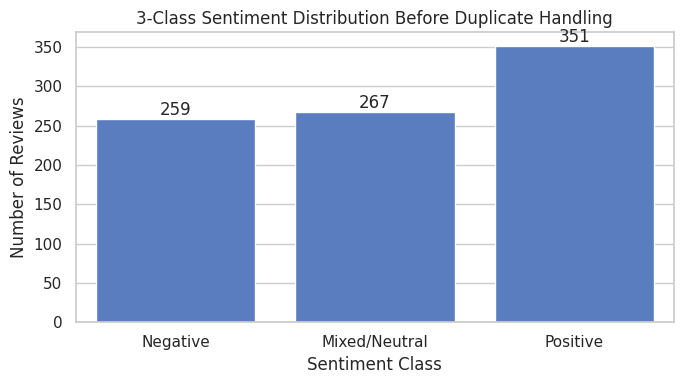

In [75]:
# Final target distribution before duplicate handling

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=target_distribution,
    x="Sentiment",
    y="Row Count",
    order=["Negative", "Mixed/Neutral", "Positive"]
)

plt.title("3-Class Sentiment Distribution Before Duplicate Handling")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [76]:
# Sentiment distribution by language before duplicate handling

sentiment_by_language = pd.crosstab(
    clean_df["Language"],
    clean_df["Sentiment"]
).reindex(columns=["Negative", "Mixed/Neutral", "Positive"])

sentiment_by_language_pct = (
    sentiment_by_language
    .div(sentiment_by_language.sum(axis=1), axis=0)
    * 100
).round(2)

print("Sentiment counts by language:")
display(sentiment_by_language)

print("Sentiment percentage distribution by language:")
display(sentiment_by_language_pct.applymap(lambda x: f"{x}%"))

Sentiment counts by language:


Sentiment,Negative,Mixed/Neutral,Positive
Language,,,
English,134,180,174
Malay,125,87,177


Sentiment percentage distribution by language:


/tmp/ipykernel_1688/1299028598.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(sentiment_by_language_pct.applymap(lambda x: f"{x}%"))


Sentiment,Negative,Mixed/Neutral,Positive
Language,,,
English,27.46%,36.89%,35.66%
Malay,32.13%,22.37%,45.5%


**Target Engineering Interpretation**

The final 3-class sentiment target was created successfully from the cleaned numeric score column.

Before duplicate handling, the dataset contains 259 Negative reviews, 267 Mixed/Neutral reviews, and 351 Positive reviews. The classes are not perfectly equal, but all three classes have enough rows for modelling and evaluation. Positive is the largest class, so later evaluation should use macro F1 in addition to accuracy.

The language breakdown shows that both English and Malay contain all three sentiment classes. English has 134 Negative, 180 Mixed/Neutral, and 174 Positive reviews. Malay has 125 Negative, 87 Mixed/Neutral, and 177 Positive reviews.

The language distributions are different. English has a larger Mixed/Neutral proportion, while Malay has a larger Positive proportion. This confirms that Malay should not be discarded and also supports the later language strategy comparison.

The encoded labels are now ready for Keras modelling: Negative is encoded as 0, Mixed/Neutral as 1, and Positive as 2.

### 4.4 Duplicate Review Handling

This subsection handles duplicate review texts before splitting the dataset.

Duplicate handling is applied after target engineering because the duplicate decision depends on the final modelling target. Some repeated review texts have different numeric scores but still belong to the same 3-class sentiment label. These are not contradictory for the final classification task, so one representative row can be kept.

However, if the same review text maps to different sentiment classes, the duplicate group provides contradictory supervision. These conflicting-sentiment groups are removed.

This step must happen before the train/validation/test split to prevent identical review text from appearing across different splits.

In [77]:
# Create normalised review text key for duplicate handling

clean_df["Review_Normalized"] = (
    clean_df["Review_Text"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

display(clean_df[["Review_Text", "Review_Normalized", "Score_Numeric", "Sentiment", "Language"]].head())

,Review_Text,Review_Normalized,Score_Numeric,Sentiment,Language
0,Disgusting.,disgusting.,1.0,Negative,English
1,Loved the sambal kick!,loved the sambal kick!,10.0,Positive,English
2,Loved the sambal kick!,loved the sambal kick!,0.1,Negative,English
3,Loved the sambal kick!,loved the sambal kick!,5.0,Mixed/Neutral,English
4,"Satay on pizza? Surprisingly worked. Tasty, un...","satay on pizza? surprisingly worked. tasty, un...",7.0,Mixed/Neutral,English


In [78]:
# Identify duplicate review-text groups and sentiment conflicts

duplicate_group_summary = (
    clean_df
    .groupby("Review_Normalized")
    .agg(
        group_size=("Review_Text", "size"),
        unique_scores=("Score_Numeric", "nunique"),
        unique_sentiments=("Sentiment", "nunique")
    )
    .reset_index()
)

duplicate_group_summary = duplicate_group_summary[
    duplicate_group_summary["group_size"] > 1
].copy()

conflicting_sentiment_review_keys = duplicate_group_summary[
    duplicate_group_summary["unique_sentiments"] > 1
]["Review_Normalized"]

same_sentiment_duplicate_keys = duplicate_group_summary[
    duplicate_group_summary["unique_sentiments"] == 1
]["Review_Normalized"]

duplicate_handling_summary = pd.DataFrame({
    "Duplicate Category": [
        "Duplicate review-text groups",
        "Groups with conflicting sentiment labels",
        "Groups with same sentiment label"
    ],
    "Group Count": [
        len(duplicate_group_summary),
        len(conflicting_sentiment_review_keys),
        len(same_sentiment_duplicate_keys)
    ]
})

display(duplicate_handling_summary)

,Duplicate Category,Group Count
0,Duplicate review-text groups,51
1,Groups with conflicting sentiment labels,15
2,Groups with same sentiment label,36


In [79]:
# Inspect duplicate groups with conflicting sentiment labels before removal

conflicting_duplicate_rows = (
    clean_df[clean_df["Review_Normalized"].isin(conflicting_sentiment_review_keys)]
    [["Review_Text", "Score_Numeric", "Sentiment", "Sentiment_Encoded", "Language", "Review_Normalized"]]
    .sort_values(["Review_Normalized", "Score_Numeric"])
)

display(conflicting_duplicate_rows.head(30))

,Review_Text,Score_Numeric,Sentiment,Sentiment_Encoded,Language,Review_Normalized
109,Like nasi lemak crashed into an Italian kitche...,5.99,Mixed/Neutral,1,English,like nasi lemak crashed into an italian kitche...
84,Like nasi lemak crashed into an Italian kitche...,7.16,Positive,2,English,like nasi lemak crashed into an italian kitche...
96,Love at first bite.,0.04,Negative,0,English,love at first bite.
106,Love at first bite.,5.72,Mixed/Neutral,1,English,love at first bite.
82,Love at first bite.,8.49,Positive,2,English,love at first bite.
115,Love at first bite.,8.79,Positive,2,English,love at first bite.
2,Loved the sambal kick!,0.10,Negative,0,English,loved the sambal kick!
3,Loved the sambal kick!,5.00,Mixed/Neutral,1,English,loved the sambal kick!
1,Loved the sambal kick!,10.00,Positive,2,English,loved the sambal kick!
92,Meets expectations.,2.19,Negative,0,English,meets expectations.


In [80]:
# Remove duplicate groups with conflicting sentiment labels

rows_before = len(clean_df)

clean_df = clean_df[
    ~clean_df["Review_Normalized"].isin(conflicting_sentiment_review_keys)
].copy()

rows_after = len(clean_df)

log_cleaning_step(
    step="Remove conflicting-sentiment duplicate groups",
    rows_before=rows_before,
    rows_after=rows_after,
    reason="Removed repeated review texts that mapped to different sentiment labels because they provide contradictory supervision."
)

print(f"Rows before removing conflicting duplicates: {rows_before}")
print(f"Rows after removing conflicting duplicates: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before removing conflicting duplicates: 877
Rows after removing conflicting duplicates: 837
Rows removed: 40


In [81]:
# Collapse remaining same-sentiment duplicate review texts to one representative row

rows_before = len(clean_df)

clean_df = (
    clean_df
    .sort_values(["Review_Normalized", "Score_Numeric"])
    .drop_duplicates(subset=["Review_Normalized"], keep="first")
    .copy()
)

rows_after = len(clean_df)

log_cleaning_step(
    step="Collapse same-sentiment duplicate review texts",
    rows_before=rows_before,
    rows_after=rows_after,
    reason="Kept one representative row per remaining review text to reduce memorisation risk and prevent duplicate text leakage across splits."
)

print(f"Rows before collapsing same-sentiment duplicates: {rows_before}")
print(f"Rows after collapsing same-sentiment duplicates: {rows_after}")
print(f"Rows removed: {rows_before - rows_after}")

Rows before collapsing same-sentiment duplicates: 837
Rows after collapsing same-sentiment duplicates: 766
Rows removed: 71


In [82]:
# Verify duplicate handling result

remaining_duplicate_text_rows = clean_df.duplicated(
    subset=["Review_Normalized"],
    keep=False
).sum()

final_duplicate_check = pd.DataFrame({
    "Check": [
        "Rows after duplicate handling",
        "Remaining rows involved in duplicate review texts",
        "Final unique review texts"
    ],
    "Value": [
        len(clean_df),
        remaining_duplicate_text_rows,
        clean_df["Review_Normalized"].nunique()
    ]
})

display(final_duplicate_check)

,Check,Value
0,Rows after duplicate handling,766
1,Remaining rows involved in duplicate review texts,0
2,Final unique review texts,766


,Sentiment,Row Count
0,Negative,200
1,Mixed/Neutral,235
2,Positive,331


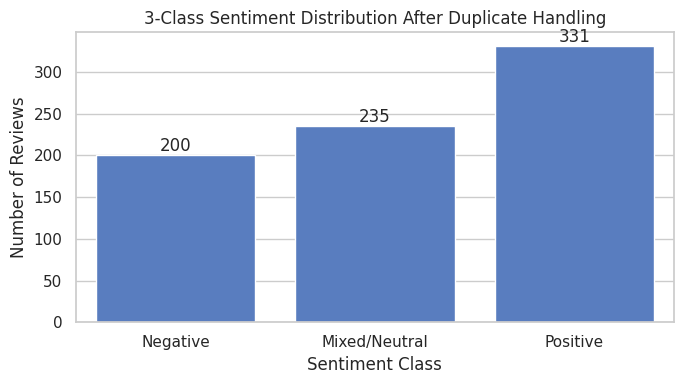

In [83]:
# Final class distribution after duplicate handling

final_target_distribution = (
    clean_df["Sentiment"]
    .value_counts()
    .reindex(["Negative", "Mixed/Neutral", "Positive"])
    .reset_index()
)

final_target_distribution.columns = ["Sentiment", "Row Count"]

display(final_target_distribution)

plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=final_target_distribution,
    x="Sentiment",
    y="Row Count",
    order=["Negative", "Mixed/Neutral", "Positive"]
)

plt.title("3-Class Sentiment Distribution After Duplicate Handling")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

**Duplicate Handling Interpretation**

Duplicate handling reduced the dataset from 877 rows to 766 rows overall.

The first step removed duplicate review-text groups with conflicting sentiment labels. This removed 40 rows, reducing the dataset from 877 rows to 837 rows. These rows were removed because the same review text mapped to different 3-class sentiment labels, which would give the model contradictory supervision.

The second step collapsed the remaining same-sentiment duplicate review texts to one representative row. This removed 71 repeated rows, reducing the dataset from 837 rows to 766 rows. These rows were not contradictory after target engineering, but keeping repeated copies would increase memorisation risk and could cause identical review text to appear across train, validation, and test splits.

After duplicate handling, the dataset contains 766 rows and 766 unique normalised review texts. There are no remaining duplicate review texts.

The final sentiment distribution after duplicate handling is 200 Negative reviews, 235 Mixed/Neutral reviews, and 331 Positive reviews. The Positive class remains the largest class, so later evaluation should use macro F1 in addition to accuracy. However, all three classes still have enough samples for stratified splitting and model evaluation.

### 4.5 Train, Validation, and Test Split

This subsection creates the final train, validation, and test sets.

The split uses a 70/15/15 ratio:

- Training set: used to fit tokenisers and train models
- Validation set: used for model selection and improvement decisions
- Test set: kept untouched until final evaluation

The split is stratified by both `Language` and `Sentiment` so that English/Malay and sentiment-class proportions are preserved as much as possible across all sets.

The split is created only after duplicate handling. This prevents identical review text from appearing across train, validation, and test sets.

In [84]:
# Create combined stratification label

clean_df["Stratify_Label"] = (
    clean_df["Language"].astype(str)
    + "_"
    + clean_df["Sentiment"].astype(str)
)

stratify_counts = (
    clean_df["Stratify_Label"]
    .value_counts()
    .sort_index()
    .reset_index()
)

stratify_counts.columns = ["Stratify_Label", "Row Count"]

display(stratify_counts)

,Stratify_Label,Row Count
0,English_Mixed/Neutral,149
1,English_Negative,116
2,English_Positive,155
3,Malay_Mixed/Neutral,86
4,Malay_Negative,84
5,Malay_Positive,176


In [85]:
# Train / validation / test split: 70% / 15% / 15%

train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    random_state=SEED,
    stratify=clean_df["Stratify_Label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["Stratify_Label"]
)

print(f"Train rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Total rows after split: {len(train_df) + len(val_df) + len(test_df)}")

Train rows: 536
Validation rows: 115
Test rows: 115
Total rows after split: 766


In [86]:
# Create target arrays for modelling

y_train = train_df["Sentiment_Encoded"].values
y_val = val_df["Sentiment_Encoded"].values
y_test = test_df["Sentiment_Encoded"].values

print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

y_train shape: (536,)
y_val shape: (115,)
y_test shape: (115,)


In [87]:
# Check sentiment distribution across splits

split_distribution = pd.concat([
    train_df.assign(Split="Train"),
    val_df.assign(Split="Validation"),
    test_df.assign(Split="Test")
])

sentiment_split_counts = pd.crosstab(
    split_distribution["Split"],
    split_distribution["Sentiment"]
).reindex(index=["Train", "Validation", "Test"])

sentiment_split_counts = sentiment_split_counts[
    ["Negative", "Mixed/Neutral", "Positive"]
]

sentiment_split_pct = (
    sentiment_split_counts
    .div(sentiment_split_counts.sum(axis=1), axis=0)
    * 100
).round(2)

print("Sentiment counts by split:")
display(sentiment_split_counts)

print("Sentiment percentage distribution by split:")
display(sentiment_split_pct.applymap(lambda x: f"{x}%"))

Sentiment counts by split:


Sentiment,Negative,Mixed/Neutral,Positive
Split,,,
Train,140,164,232
Validation,31,35,49
Test,29,36,50


Sentiment percentage distribution by split:


/tmp/ipykernel_1688/1171498206.py:28: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(sentiment_split_pct.applymap(lambda x: f"{x}%"))


Sentiment,Negative,Mixed/Neutral,Positive
Split,,,
Train,26.12%,30.6%,43.28%
Validation,26.96%,30.43%,42.61%
Test,25.22%,31.3%,43.48%


In [88]:
# Check language distribution across splits

language_split_counts = pd.crosstab(
    split_distribution["Split"],
    split_distribution["Language"]
).reindex(index=["Train", "Validation", "Test"])

language_split_pct = (
    language_split_counts
    .div(language_split_counts.sum(axis=1), axis=0)
    * 100
).round(2)

print("Language counts by split:")
display(language_split_counts)

print("Language percentage distribution by split:")
display(language_split_pct.applymap(lambda x: f"{x}%"))

Language counts by split:


Language,English,Malay
Split,,
Train,294,242
Validation,63,52
Test,63,52


Language percentage distribution by split:


/tmp/ipykernel_1688/1524209806.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(language_split_pct.applymap(lambda x: f"{x}%"))


Language,English,Malay
Split,,
Train,54.85%,45.15%
Validation,54.78%,45.22%
Test,54.78%,45.22%


In [89]:
# Check combined language-sentiment distribution across splits

stratify_split_counts = pd.crosstab(
    split_distribution["Split"],
    split_distribution["Stratify_Label"]
).reindex(index=["Train", "Validation", "Test"])

display(stratify_split_counts)

Stratify_Label,English_Mixed/Neutral,English_Negative,English_Positive,Malay_Mixed/Neutral,Malay_Negative,Malay_Positive
Split,,,,,,
Train,104,81,109,60,59,123
Validation,22,18,23,13,13,26
Test,23,17,23,13,12,27


In [90]:
# Check for review-text overlap across train, validation, and test sets

train_reviews = set(train_df["Review_Normalized"])
val_reviews = set(val_df["Review_Normalized"])
test_reviews = set(test_df["Review_Normalized"])

train_val_overlap = train_reviews.intersection(val_reviews)
train_test_overlap = train_reviews.intersection(test_reviews)
val_test_overlap = val_reviews.intersection(test_reviews)

leakage_check = pd.DataFrame({
    "Overlap Check": [
        "Train vs Validation",
        "Train vs Test",
        "Validation vs Test"
    ],
    "Overlapping Review Texts": [
        len(train_val_overlap),
        len(train_test_overlap),
        len(val_test_overlap)
    ]
})

display(leakage_check)

,Overlap Check,Overlapping Review Texts
0,Train vs Validation,0
1,Train vs Test,0
2,Validation vs Test,0


In [91]:
# Add split creation note to cleaning log

cleaning_log.append({
    "Cleaning Step": "Create train/validation/test split",
    "Rows Before": len(clean_df),
    "Rows After": len(clean_df),
    "Rows Removed": 0,
    "Reason": "Created leakage-safe 70/15/15 split stratified by language and sentiment after duplicate handling."
})

cleaning_log_df = pd.DataFrame(cleaning_log)

display(cleaning_log_df)

,Cleaning Step,Rows Before,Rows After,Rows Removed,Reason
0,Remove invalid scores,902,879,23,"Removed missing, non-numeric, below-0, and abo..."
1,Keep English and Malay only,879,877,2,Section 3 showed English and Malay are the onl...
2,Drop unused note column and standardise review...,877,877,0,Removed mostly missing note column and created...
3,Remove conflicting-sentiment duplicate groups,877,837,40,Removed repeated review texts that mapped to d...
4,Collapse same-sentiment duplicate review texts,837,766,71,Kept one representative row per remaining revi...
5,Create train/validation/test split,766,766,0,Created leakage-safe 70/15/15 split stratified...


**Train/Validation/Test Split Interpretation**

The final cleaned dataset contains 766 unique review texts after invalid-score filtering, language filtering, target engineering, and duplicate handling.

The dataset was split into 536 training rows, 115 validation rows, and 115 test rows, matching the intended 70/15/15 split. The training set will be used to fit tokenisers and train models, the validation set will be used for model selection, and the test set will remain untouched until final evaluation.

The sentiment distribution is well preserved across the three splits. The training set contains 140 Negative, 164 Mixed/Neutral, and 232 Positive reviews. The validation and test sets also preserve similar proportions, with Positive remaining the largest class and the other two classes still represented.

The language distribution is also well preserved. Each split contains about 55% English and 45% Malay reviews. This is important because later modelling should evaluate whether the model performs consistently across both language groups.

The combined language-sentiment stratification check confirms that every split contains examples from all six language-sentiment groups. This supports fairer validation and test evaluation across both English/Malay and the three sentiment classes.

The leakage check shows zero overlapping normalised review texts between train, validation, and test sets. This confirms that duplicate handling before splitting successfully prevented identical review text from appearing across different splits.

At this point, the data split is suitable for leakage-safe modelling. Future text tokenisers and sequence padding must be fitted using the training set only, then applied to validation and test sets.

### 4.6 Section 4 Summary

This subsection summarises the final cleaned modelling dataset and the key cleaning decisions applied in Section 4.

In [92]:
# Final cleaned dataset summary

section4_final_summary = pd.DataFrame({
    "Item": [
        "Initial raw rows",
        "Final cleaned rows",
        "Training rows",
        "Validation rows",
        "Test rows",
        "Unique normalised review texts",
        "Remaining duplicate review-text rows",
        "Languages retained",
        "Target classes"
    ],
    "Value": [
        len(raw_df),
        len(clean_df),
        len(train_df),
        len(val_df),
        len(test_df),
        clean_df["Review_Normalized"].nunique(),
        clean_df.duplicated(subset=["Review_Normalized"], keep=False).sum(),
        ", ".join(sorted(clean_df["Language"].unique())),
        ", ".join(["Negative", "Mixed/Neutral", "Positive"])
    ]
})

display(section4_final_summary)

,Item,Value
0,Initial raw rows,902
1,Final cleaned rows,766
2,Training rows,536
3,Validation rows,115
4,Test rows,115
5,Unique normalised review texts,766
6,Remaining duplicate review-text rows,0
7,Languages retained,"English, Malay"
8,Target classes,"Negative, Mixed/Neutral, Positive"


In [93]:
# Final cleaning log

cleaning_log_df = pd.DataFrame(cleaning_log)

display(cleaning_log_df)

,Cleaning Step,Rows Before,Rows After,Rows Removed,Reason
0,Remove invalid scores,902,879,23,"Removed missing, non-numeric, below-0, and abo..."
1,Keep English and Malay only,879,877,2,Section 3 showed English and Malay are the onl...
2,Drop unused note column and standardise review...,877,877,0,Removed mostly missing note column and created...
3,Remove conflicting-sentiment duplicate groups,877,837,40,Removed repeated review texts that mapped to d...
4,Collapse same-sentiment duplicate review texts,837,766,71,Kept one representative row per remaining revi...
5,Create train/validation/test split,766,766,0,Created leakage-safe 70/15/15 split stratified...


In [94]:
# Final split overview

final_split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Rows": [len(train_df), len(val_df), len(test_df)],
    "Percentage": [
        len(train_df) / len(clean_df) * 100,
        len(val_df) / len(clean_df) * 100,
        len(test_df) / len(clean_df) * 100
    ]
})

final_split_summary["Percentage"] = final_split_summary["Percentage"].round(2)

display(final_split_summary)

,Split,Rows,Percentage
0,Train,536,69.97
1,Validation,115,15.01
2,Test,115,15.01


In [95]:
# Confirm key modelling variables exist for Section 5

section4_variable_check = pd.DataFrame({
    "Variable": [
        "clean_df",
        "train_df",
        "val_df",
        "test_df",
        "y_train",
        "y_val",
        "y_test"
    ],
    "Expected Role": [
        "Final cleaned dataset before splitting",
        "Training dataframe",
        "Validation dataframe",
        "Test dataframe",
        "Training labels",
        "Validation labels",
        "Test labels"
    ],
    "Shape / Rows": [
        clean_df.shape,
        train_df.shape,
        val_df.shape,
        test_df.shape,
        y_train.shape,
        y_val.shape,
        y_test.shape
    ]
})

display(section4_variable_check)

,Variable,Expected Role,Shape / Rows
0,clean_df,Final cleaned dataset before splitting,"(766, 9)"
1,train_df,Training dataframe,"(536, 9)"
2,val_df,Validation dataframe,"(115, 9)"
3,test_df,Test dataframe,"(115, 9)"
4,y_train,Training labels,"(536,)"
5,y_val,Validation labels,"(115,)"
6,y_test,Test labels,"(115,)"


**Section 4 Summary**

Section 4 created the final cleaned modelling dataset for pizza review sentiment classification.

The workflow started from the original `raw_df` with 902 rows. After removing invalid scores, filtering to English and Malay reviews, engineering the 3-class sentiment target, and handling duplicate review texts, the final cleaned dataset contains 766 rows.

The cleaning log shows that 23 rows were removed because their scores were missing, non-numeric, below 0, or above 10. Another 2 rows were removed when filtering to English and Malay, based on the Section 3 finding that other language labels were too small or corrupted for reliable modelling.

Duplicate handling was applied before splitting. Conflicting-sentiment duplicate review groups removed 40 rows, reducing the dataset from 877 to 837 rows. Remaining same-sentiment duplicate texts were then collapsed to one representative row, removing another 71 rows and reducing the dataset from 837 to 766 rows.

The final dataset has 766 unique normalised review texts and 0 remaining duplicate review-text rows. This means the later split is protected from identical review-text leakage across train, validation, and test sets.

The final dataset was split into 536 training rows, 115 validation rows, and 115 test rows. This corresponds to approximately 69.97%, 15.01%, and 15.01% of the cleaned dataset, matching the intended 70/15/15 split.

The key modelling variables are ready for Section 5: `clean_df`, `train_df`, `val_df`, `test_df`, `y_train`, `y_val`, and `y_test`. From this point onward, all tokenisers and text-preparation objects must be fitted using the training set only, then applied to the validation and test sets.

---

## 5. Text Preparation and Baseline Models

Section 5 prepares the cleaned review text for modelling and builds simple baselines before moving to RNN models.

The key leakage rule is that the tokenizer must be fitted on the training text only. 

This section uses two baselines:

1. Majority-class baseline
2. Simple neural text baseline using `Embedding → GlobalAveragePooling1D → Dense`

These baselines give a minimum performance reference before building RNN models.

### 5.1 Text Fields and Modelling Inputs

This subsection confirms the text and target columns that will be used for modelling.

The modelling input is `Review_Text`, and the target is `Sentiment_Encoded`.

At this stage, the text is kept simple. More advanced language-handling strategies are tested later in Section 6.

In [96]:
# Confirm modelling columns

required_columns = [
    "Review_Text",
    "Sentiment",
    "Sentiment_Encoded",
    "Language",
    "Score_Numeric"
]

column_check = pd.DataFrame({
    "Column": required_columns,
    "Exists in train_df": [col in train_df.columns for col in required_columns],
    "Exists in val_df": [col in val_df.columns for col in required_columns],
    "Exists in test_df": [col in test_df.columns for col in required_columns]
})

display(column_check)

,Column,Exists in train_df,Exists in val_df,Exists in test_df
0,Review_Text,True,True,True
1,Sentiment,True,True,True
2,Sentiment_Encoded,True,True,True
3,Language,True,True,True
4,Score_Numeric,True,True,True


In [97]:
# Create text input variables

X_train_text = train_df["Review_Text"].astype(str).values
X_val_text = val_df["Review_Text"].astype(str).values
X_test_text = test_df["Review_Text"].astype(str).values

print(f"Training text examples: {len(X_train_text)}")
print(f"Validation text examples: {len(X_val_text)}")
print(f"Test text examples: {len(X_test_text)}")

print("\nExample training reviews:")
for review in X_train_text[:5]:
    print("-", review)

Training text examples: 536
Validation text examples: 115
Test text examples: 115

Example training reviews:
- Roti keras macam batu.
- Hebat dan sedap. Roti garing dan topping kaya rasa. Saya sangat puas hati.
- Pizza was greasy and unpleasant.
- Pizza ni rasa basi dan tak sedap.
- Gabungan rasa yang sempurna dan lazat.


In [98]:
# Confirm target arrays

print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTraining label distribution:")
display(
    train_df["Sentiment"]
    .value_counts()
    .reindex(["Negative", "Mixed/Neutral", "Positive"])
    .reset_index()
    .rename(columns={"index": "Sentiment", "Sentiment": "Count"})
)

y_train shape: (536,)
y_val shape: (115,)
y_test shape: (115,)

Training label distribution:


,Count,count
0,Negative,140
1,Mixed/Neutral,164
2,Positive,232


**Text Fields and Modelling Inputs Interpretation**

The required modelling columns are present in the training, validation, and test dataframes. The input text column is `Review_Text`, while the target columns are `Sentiment` and `Sentiment_Encoded`.

The final split contains 536 training reviews, 115 validation reviews, and 115 test reviews. The target arrays also match these split sizes: `y_train` has 536 labels, `y_val` has 115 labels, and `y_test` has 115 labels.

The example training reviews include both English and Malay text, confirming that Section 5 starts from the bilingual cleaned dataset. The training label distribution is also consistent with the earlier split checks: 140 Negative reviews, 164 Mixed/Neutral reviews, and 232 Positive reviews.

At this point, the modelling inputs are ready. The next step is tokenisation, where the tokenizer must be fitted on `X_train_text` only and then applied to validation and test text.

### 5.2 Tokenisation, Vocabulary, and Sequence Length Evidence

This subsection converts review text into integer sequences for neural network modelling and checks whether the baseline vocabulary size and sequence length are reasonable.

To avoid data leakage, the tokenizer is fitted on `X_train_text` only. Validation and test reviews are not used to build the vocabulary. They are only transformed using the tokenizer learned from the training set.

The baseline vocabulary size is set to `1000`, and the baseline maximum sequence length is set to `25`. These are treated as simple baseline settings, not final optimal choices. Sequence length will be tested again later in the controlled model-improvement section.

In [99]:
# Text preparation constants for Section 5 baselines

VOCAB_SIZE = 1000
MAX_SEQUENCE_LENGTH = 25
EMBEDDING_DIM = 32

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Maximum sequence length: {MAX_SEQUENCE_LENGTH}")
print(f"Embedding dimension: {EMBEDDING_DIM}")

Vocabulary size: 1000
Maximum sequence length: 25
Embedding dimension: 32


In [100]:
# Fit tokenizer on training text only

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

word_index = tokenizer.word_index

print(f"Total unique tokens in training text: {len(word_index)}")
print(f"Vocabulary limit used for baseline models: {VOCAB_SIZE}")

print("\nFirst 20 tokens in tokenizer word index:")
for word, index in list(word_index.items())[:20]:
    print(f"{word}: {index}")

Total unique tokens in training text: 720
Vocabulary limit used for baseline models: 1000

First 20 tokens in tokenizer word index:
<OOV>: 1
pizza: 2
the: 3
dan: 4
rasa: 5
and: 6
sambal: 7
fusion: 8
was: 9
mayo: 10
sangat: 11
yang: 12
a: 13
tak: 14
satay: 15
but: 16
saya: 17
sedap: 18
topping: 19
ni: 20


**Embedding dimension justification:**
`EMBEDDING_DIM = 32` was chosen based on dataset size and vocabulary size.
The training set contains 536 samples and the fitted vocabulary contains approximately 720 unique tokens. A 32-dimensional embedding space provides sufficient representational capacity for a vocabulary of this size without overcrowding the parameter space relative to the available training data. Larger embedding dimensions such as 64 or 128 would add parameters without enough training samples to learn meaningful representations, increasing overfitting risk. Smaller dimensions such as 8 or 16 may underrepresent the vocabulary. 32 is a reasonable and commonly used default for small-vocabulary, small-dataset text classification tasks.

**Text preprocessing note:**
The Keras `Tokenizer` is initialised with default `filters` which automatically
strips the following characters before tokenisation:
`!"#$%&()*+,-./:;<=>?@[\]^_{|}~` and newline characters.
This means punctuation such as full stops, commas, and exclamation marks are removed
by default, so `"pizza."` and `"pizza"` are treated as the same token.
The tokenizer also converts all text to lowercase by default (`lower=True`),
so `"Good"` and `"good"` are treated as the same token.
These default behaviours handle the main text normalisation requirements for this
dataset without requiring explicit preprocessing steps on `Review_Text`.

In [101]:
# Convert text to integer sequences using the train-fitted tokenizer

X_train_sequences = tokenizer.texts_to_sequences(X_train_text)
X_val_sequences = tokenizer.texts_to_sequences(X_val_text)
X_test_sequences = tokenizer.texts_to_sequences(X_test_text)

print("Example training text:")
print(X_train_text[0])

print("\nExample token sequence:")
print(X_train_sequences[0])

Example training text:
Roti keras macam batu.

Example token sequence:
[28, 74, 277, 414]


In [102]:
# Sequence length check based on training sequences only

train_sequence_lengths = np.array([len(seq) for seq in X_train_sequences])

train_sequence_length_summary = pd.Series(train_sequence_lengths).describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
).to_frame(name="training_sequence_length")

display(train_sequence_length_summary.round(2))

,training_sequence_length
count,536.00
mean,8.49
std,5.06
min,1.00
25%,6.00
50%,7.00
75%,11.00
90%,14.00
95%,17.00
max,48.00


In [103]:
# Training sequence coverage for selected max length

train_covered_rows = (train_sequence_lengths <= MAX_SEQUENCE_LENGTH).sum()
train_total_rows = len(train_sequence_lengths)

print(f"Training rows covered by max length {MAX_SEQUENCE_LENGTH}: {train_covered_rows} / {train_total_rows}")
print(f"Coverage: {train_covered_rows / train_total_rows * 100:.2f}%")

Training rows covered by max length 25: 532 / 536
Coverage: 99.25%


**Tokenisation Setup Interpretation**

The tokenizer was fitted only on the training reviews, which avoids vocabulary leakage from the validation and test sets. Validation and test reviews will only be transformed using this training-fitted tokenizer.

The training text contains 720 unique tokens. Since the baseline vocabulary size is set to 1000, the vocabulary limit is sufficient to cover all tokens seen in the training set. This means the Section 5 baseline does not lose training vocabulary because of the vocabulary cap.

The tokenizer reserves index 1 for the `<OOV>` token, which means out-of-vocabulary token. This token is used for words that appear in validation or test reviews but were not seen when fitting the tokenizer on the training reviews. This allows unseen words to be handled without refitting the tokenizer on validation or test data.

The example review `Roti keras macam batu.` was converted into the token sequence `[28, 74, 277, 414]`, showing that the text has been successfully transformed into integer sequences.

The training sequence-length summary supports using a compact baseline maximum sequence length. The median training sequence length is 7 tokens, the 75th percentile is 11 tokens, and the 95th percentile is 17 tokens. A maximum sequence length of 25 covers 532 out of 536 training reviews, or 99.25%.

This means only 4 training reviews are longer than 25 tokens and will be truncated. This is acceptable for a simple baseline because almost all reviews are short, and using a compact sequence length avoids adding unnecessary padding and computation.

However, `MAX_SEQUENCE_LENGTH = 25` is not treated as the final best choice. It is only the baseline setting. Later in the model improvement section, sequence lengths such as 15, 25, and 40 will be compared using validation macro F1, validation loss, and overfitting behaviour. This ensures that the final sequence length is selected using validation evidence rather than assumed from EDA alone.

### 5.3 Padding and Final Input Arrays

This subsection pads the tokenised sequences into fixed-length arrays.

Neural network models require inputs with consistent shape, so shorter reviews are padded and longer reviews are truncated to `MAX_SEQUENCE_LENGTH = 25`.

The tokenizer has already been fitted using training text only. The same tokenizer and padding rule are now applied to the training, validation, and test sequences.

In [104]:
# Pad token sequences to fixed length

X_train_padded = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_padded = pad_sequences(
    X_val_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print(f"X_train_padded shape: {X_train_padded.shape}")
print(f"X_val_padded shape: {X_val_padded.shape}")
print(f"X_test_padded shape: {X_test_padded.shape}")

X_train_padded shape: (536, 25)
X_val_padded shape: (115, 25)
X_test_padded shape: (115, 25)


In [105]:
# Inspect one padded training example

example_index = 0

print("Original review:")
print(X_train_text[example_index])

print("\nOriginal sequence:")
print(X_train_sequences[example_index])

print("\nPadded sequence:")
print(X_train_padded[example_index])

Original review:
Roti keras macam batu.

Original sequence:
[28, 74, 277, 414]

Padded sequence:
[ 28  74 277 414   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0]


In [106]:
# Check how many sequences are longer than the selected max length
# Sequence truncation check for training and validation only
# Test sequences are prepared but not inspected for modelling decisions

train_truncated_count = sum(len(seq) > MAX_SEQUENCE_LENGTH for seq in X_train_sequences)
val_truncated_count = sum(len(seq) > MAX_SEQUENCE_LENGTH for seq in X_val_sequences)

truncation_summary = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Total Rows": [len(X_train_sequences), len(X_val_sequences)],
    "Rows Longer Than Max Sequence Length": [train_truncated_count, val_truncated_count],
    "Percentage Truncated": [
        train_truncated_count / len(X_train_sequences) * 100,
        val_truncated_count / len(X_val_sequences) * 100
    ]
})

display(truncation_summary)

,Split,Total Rows,Rows Longer Than Max Sequence Length,Percentage Truncated
0,Train,536,4,0.746269
1,Validation,115,1,0.869565


In [107]:
# Confirm final input and target shapes for Section 5 models

section5_array_shapes = pd.DataFrame({
    "Array": [
        "X_train_padded",
        "X_val_padded",
        "X_test_padded",
        "y_train",
        "y_val",
        "y_test"
    ],
    "Shape": [
        X_train_padded.shape,
        X_val_padded.shape,
        X_test_padded.shape,
        y_train.shape,
        y_val.shape,
        y_test.shape
    ]
})

display(section5_array_shapes)

,Array,Shape
0,X_train_padded,"(536, 25)"
1,X_val_padded,"(115, 25)"
2,X_test_padded,"(115, 25)"
3,y_train,"(536,)"
4,y_val,"(115,)"
5,y_test,"(115,)"


**Padding and Final Input Arrays Interpretation**

The token sequences were padded successfully into fixed-length arrays using `MAX_SEQUENCE_LENGTH = 25`.

The final Section 5 input shapes are correct: `X_train_padded` has shape `(536, 25)`, `X_val_padded` has shape `(115, 25)`, and `X_test_padded` has shape `(115, 25)`. These match the train, validation, and test split sizes.

The padded example shows how shorter reviews are handled. The review `Roti keras macam batu.` is converted into four token IDs, then padded with zeros until the sequence reaches length 25. These zero values are padding tokens, not real words.

Only a small number of reviews are longer than the selected maximum length. In the training set, 4 out of 536 reviews are longer than 25 tokens. In the validation set, 1 out of 115 reviews is longer than 25 tokens. In the test set, no reviews are longer than 25 tokens.

The test sequences were prepared using the training-fitted tokenizer for later final evaluation, but test-set truncation statistics are not used for modelling decisions. Model selection remains based only on training and validation evidence.

This confirms that `MAX_SEQUENCE_LENGTH = 25` is suitable for the Section 5 baseline because it covers almost all reviews while keeping the input representation compact. However, as mentioned earlier, this remains a baseline choice rather than the final sequence-length decision. Later model improvement will compare different sequence lengths using validation performance.

### 5.4 Majority-Class Baseline

This subsection builds a simple majority-class baseline.

The majority-class baseline always predicts the most common class in the training set. It does not use review text, so it represents the minimum performance that a useful model should beat.

This baseline is important because accuracy alone can be misleading when the classes are not perfectly balanced. Macro F1 is also reported because it treats Negative, Mixed/Neutral, and Positive performance equally.

In [108]:
# Identify majority class from training labels only

majority_class_encoded = train_df["Sentiment_Encoded"].mode()[0]

encoded_to_sentiment = {
    0: "Negative",
    1: "Mixed/Neutral",
    2: "Positive"
}

majority_class_label = encoded_to_sentiment[majority_class_encoded]

print(f"Majority class encoded label: {majority_class_encoded}")
print(f"Majority class sentiment: {majority_class_label}")

Majority class encoded label: 2
Majority class sentiment: Positive


In [109]:
# Generate majority-class predictions for validation set

majority_val_preds = np.full(
    shape=len(y_val),
    fill_value=majority_class_encoded
)

print(f"Number of validation predictions: {len(majority_val_preds)}")
print(f"Unique predicted labels: {np.unique(majority_val_preds)}")

Number of validation predictions: 115
Unique predicted labels: [2]


In [110]:
# Evaluate majority-class baseline on validation set

majority_val_accuracy = accuracy_score(y_val, majority_val_preds)
majority_val_macro_f1 = f1_score(y_val, majority_val_preds, average="macro")
majority_val_weighted_f1 = f1_score(y_val, majority_val_preds, average="weighted")

majority_baseline_results = pd.DataFrame({
    "Model": ["Majority-class baseline"],
    "Validation Accuracy": [majority_val_accuracy],
    "Validation Macro F1": [majority_val_macro_f1],
    "Validation Weighted F1": [majority_val_weighted_f1]
})

display(majority_baseline_results.round(4))

,Model,Validation Accuracy,Validation Macro F1,Validation Weighted F1
0,Majority-class baseline,0.4261,0.1992,0.2546


In [111]:
# Majority-class baseline classification report

print(classification_report(
    y_val,
    majority_val_preds,
    target_names=["Negative", "Mixed/Neutral", "Positive"],
    zero_division=0
))

               precision    recall  f1-score   support

     Negative       0.00      0.00      0.00        31
Mixed/Neutral       0.00      0.00      0.00        35
     Positive       0.43      1.00      0.60        49

     accuracy                           0.43       115
    macro avg       0.14      0.33      0.20       115
 weighted avg       0.18      0.43      0.25       115



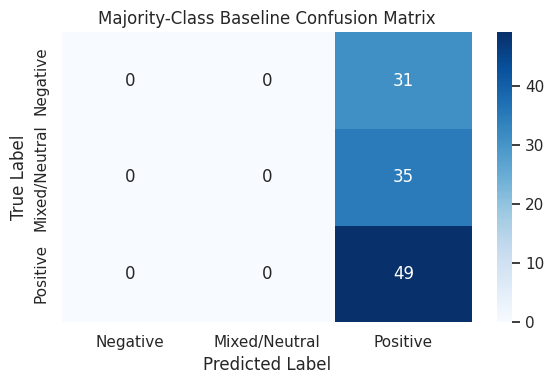

In [112]:
# Majority-class baseline confusion matrix

majority_cm = confusion_matrix(y_val, majority_val_preds)

plt.figure(figsize=(6, 4))

sns.heatmap(
    majority_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Mixed/Neutral", "Positive"],
    yticklabels=["Negative", "Mixed/Neutral", "Positive"]
)

plt.title("Majority-Class Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

**Majority-Class Baseline Interpretation**

The majority-class baseline always predicts the most common training class, which is `Positive`.

On the validation set, this baseline achieves 0.4261 validation accuracy, 0.1992 validation macro F1, and 0.2546 validation weighted F1. The accuracy is around 42.6% because 49 out of 115 validation reviews are Positive.

The classification report and confusion matrix show the weakness of this baseline clearly. It predicts every validation review as Positive, so it gets all Positive reviews correct but fails completely on Negative and Mixed/Neutral reviews. Both Negative and Mixed/Neutral have 0 recall and 0 F1.

This confirms why accuracy alone is not enough for this task. A model can achieve moderate accuracy by exploiting the largest class while ignoring the other sentiment classes. Therefore, validation macro F1 is important because it penalises poor performance on Negative and Mixed/Neutral reviews.

Any useful neural text model should clearly beat this baseline, especially in validation macro F1.

### 5.5 Simple Neural Text Baseline

This subsection trains a simple neural text baseline before using recurrent models.

The model uses:

`Embedding → GlobalAveragePooling1D → Dense(3, softmax)`

This baseline uses tokenised review text, but it does not model word order strongly like an RNN. It provides a stronger reference point than the majority-class baseline and helps show whether the text itself contains useful predictive signal.

The tokenizer and padded arrays used here were created only from the training-fitted tokenizer, so validation and test text are not used to build the vocabulary.

In [113]:
# Build simple neural text baseline

simple_baseline_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=False
    ),
    GlobalAveragePooling1D(),
    Dense(3, activation="softmax")
])

simple_baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 25, 32)         │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,099 (125.39 KB)

 Trainable params: 32,099 (125.39 KB)

 Non-trainable params: 0 (0.00 B)

In [114]:
# Train simple neural text baseline

simple_baseline_history = simple_baseline_model.fit(
    X_train_padded,
    y_train,
    validation_data=(X_val_padded, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 0.4086 - loss: 1.0910 - val_accuracy: 0.4261 - val_loss: 1.0838
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4328 - loss: 1.0728 - val_accuracy: 0.4261 - val_loss: 1.0729
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4328 - loss: 1.0582 - val_accuracy: 0.4261 - val_loss: 1.0598
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4328 - loss: 1.0423 - val_accuracy: 0.4261 - val_loss: 1.0449
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4422 - loss: 1.0239 - val_accuracy: 0.4348 - val_loss: 1.0279
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4496 - loss: 1.0027 - val_accuracy: 0.4522 - val_loss: 1.0086
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4944 - loss: 0.9787 - val_accuracy: 0.5130 - val_loss: 0.9873
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5877 - loss: 0.9522 - val_accuracy: 0.5652 - val_los

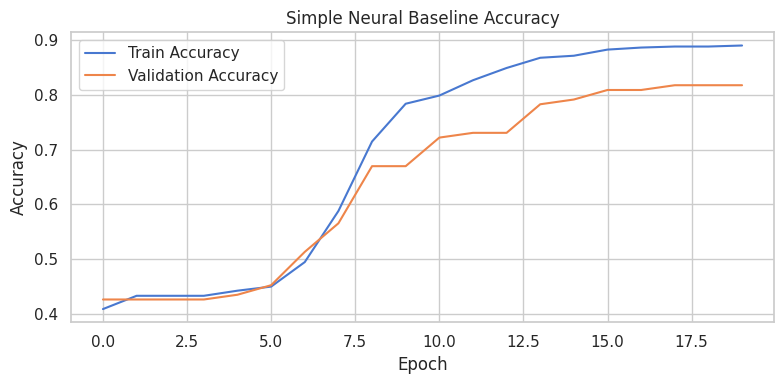

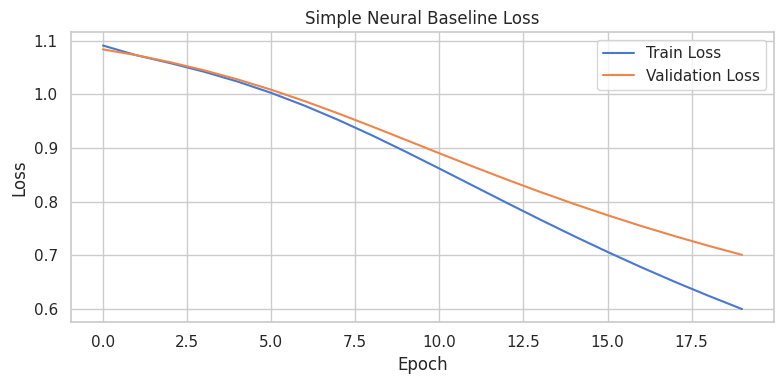

In [115]:
# Plot simple neural baseline learning curves

history_df = pd.DataFrame(simple_baseline_history.history)

plt.figure(figsize=(8, 4))
plt.plot(history_df["accuracy"], label="Train Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Simple Neural Baseline Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history_df["loss"], label="Train Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Simple Neural Baseline Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
# Generate validation predictions

simple_val_probs = simple_baseline_model.predict(X_val_padded)
simple_val_preds = np.argmax(simple_val_probs, axis=1)

print(f"Validation prediction shape: {simple_val_preds.shape}")
print(f"Predicted class labels: {np.unique(simple_val_preds)}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Validation prediction shape: (115,)
Predicted class labels: [0 1 2]


In [117]:
# Evaluate simple neural text baseline on validation set

simple_val_accuracy = accuracy_score(y_val, simple_val_preds)
simple_val_macro_f1 = f1_score(y_val, simple_val_preds, average="macro")
simple_val_weighted_f1 = f1_score(y_val, simple_val_preds, average="weighted")

simple_baseline_results = pd.DataFrame({
    "Model": ["Simple neural text baseline"],
    "Validation Accuracy": [simple_val_accuracy],
    "Validation Macro F1": [simple_val_macro_f1],
    "Validation Weighted F1": [simple_val_weighted_f1]
})

display(simple_baseline_results.round(4))

,Model,Validation Accuracy,Validation Macro F1,Validation Weighted F1
0,Simple neural text baseline,0.8174,0.8077,0.8175


In [118]:
# Simple neural baseline classification report

print(classification_report(
    y_val,
    simple_val_preds,
    target_names=["Negative", "Mixed/Neutral", "Positive"],
    zero_division=0
))

               precision    recall  f1-score   support

     Negative       0.69      0.87      0.77        31
Mixed/Neutral       0.89      0.69      0.77        35
     Positive       0.88      0.88      0.88        49

     accuracy                           0.82       115
    macro avg       0.82      0.81      0.81       115
 weighted avg       0.83      0.82      0.82       115



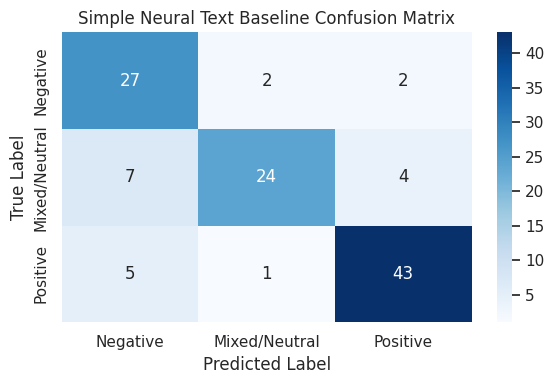

In [119]:
# Simple neural baseline confusion matrix

simple_cm = confusion_matrix(y_val, simple_val_preds)

plt.figure(figsize=(6, 4))

sns.heatmap(
    simple_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Mixed/Neutral", "Positive"],
    yticklabels=["Negative", "Mixed/Neutral", "Positive"]
)

plt.title("Simple Neural Text Baseline Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [120]:
# Compare Section 5 baselines

section5_baseline_comparison = pd.concat(
    [
        majority_baseline_results,
        simple_baseline_results
    ],
    ignore_index=True
)

display(section5_baseline_comparison.round(4))

,Model,Validation Accuracy,Validation Macro F1,Validation Weighted F1
0,Majority-class baseline,0.4261,0.1992,0.2546
1,Simple neural text baseline,0.8174,0.8077,0.8175


**Simple Neural Text Baseline Interpretation**

The simple neural text baseline uses an `Embedding → GlobalAveragePooling1D → Dense` architecture with 32,099 trainable parameters. Unlike the majority-class baseline, this model uses the tokenised review text as input.

The model achieved 0.8174 validation accuracy, 0.8077 validation macro F1, and 0.8175 validation weighted F1. This is a large improvement over the majority-class baseline, which achieved 0.4261 validation accuracy and 0.1992 validation macro F1.

The learning curves show steady improvement across training. Training accuracy reached 0.8899 by epoch 20, while validation accuracy reached 0.8174. Validation accuracy peaked at 0.8174 from epochs 18 to 20, so the final epoch is also one of the best validation-accuracy epochs. Training and validation loss both continued decreasing, with final validation loss at 0.7007, suggesting the model was still learning useful text patterns rather than clearly overfitting.

The confusion matrix and classification report show that the model predicts all three classes, unlike the majority baseline. It performs best on Positive reviews, with an F1-score of 0.88. Negative reviews are also handled reasonably well, with an F1-score of 0.77. Mixed/Neutral reviews have an F1-score of 0.77, but the recall of 0.69 shows that some mixed reviews are still misclassified as Negative or Positive. This is expected because Mixed/Neutral reviews can contain less direct or more blended sentiment.

This baseline confirms that the cleaned review text contains useful signal for sentiment classification. However, the model averages word embeddings and does not explicitly model word order. Section 6 and later RNN sections will test whether sequence-aware models and language-handling strategies can improve beyond this baseline.

### 5.6 Section 5 Summary

This subsection summarises the text-preparation workflow and baseline results from Section 5.

In [121]:
# Final Section 5 baseline comparison

display(section5_baseline_comparison.round(4))

,Model,Validation Accuracy,Validation Macro F1,Validation Weighted F1
0,Majority-class baseline,0.4261,0.1992,0.2546
1,Simple neural text baseline,0.8174,0.8077,0.8175


In [122]:
# Section 5 modelling setup summary

section5_setup_summary = pd.DataFrame({
    "Item": [
        "Training rows",
        "Validation rows",
        "Test rows",
        "Tokenizer fitted on",
        "Total unique training tokens",
        "Vocabulary size used",
        "Maximum sequence length",
        "Embedding dimension",
        "Training rows longer than max sequence length",
        "Validation rows longer than max sequence length",
        "Test rows longer than max sequence length"
    ],
    "Value": [
        len(train_df),
        len(val_df),
        len(test_df),
        "Training text only",
        len(word_index),
        VOCAB_SIZE,
        MAX_SEQUENCE_LENGTH,
        EMBEDDING_DIM,
        sum(len(seq) > MAX_SEQUENCE_LENGTH for seq in X_train_sequences),
        sum(len(seq) > MAX_SEQUENCE_LENGTH for seq in X_val_sequences),
        sum(len(seq) > MAX_SEQUENCE_LENGTH for seq in X_test_sequences)
    ]
})

display(section5_setup_summary)

,Item,Value
0,Training rows,536
1,Validation rows,115
2,Test rows,115
3,Tokenizer fitted on,Training text only
4,Total unique training tokens,720
5,Vocabulary size used,1000
6,Maximum sequence length,25
7,Embedding dimension,32
8,Training rows longer than max sequence length,4
9,Validation rows longer than max sequence length,1


**Section 5 Summary**

Section 5 prepared the cleaned review text for baseline neural network modelling.

The tokenizer was fitted only on the training text, then applied to the validation and test reviews. This avoids vocabulary leakage from validation or test data. The training set contains 720 unique tokens, while the baseline vocabulary size is 1000, so the full training vocabulary is covered.

The padded input arrays use a fixed maximum sequence length of 25. The final input shapes are `(536, 25)` for training, `(115, 25)` for validation, and `(115, 25)` for testing. Only 4 training reviews, 1 validation review, and 0 test reviews are longer than 25 tokens, so this is a reasonable compact baseline sequence length. However, sequence length is still a modelling choice and will be tested later during controlled model improvement.

The majority-class baseline always predicted the largest training class, Positive. It achieved 0.4261 validation accuracy, 0.1992 validation macro F1, and 0.2546 validation weighted F1. This baseline performed poorly because it ignored Negative and Mixed/Neutral reviews entirely.

The simple neural text baseline performed much better, achieving 0.8174 validation accuracy, 0.8077 validation macro F1, and 0.8175 validation weighted F1. This confirms that the cleaned review text contains useful signal for sentiment classification.

However, the simple neural baseline uses average-pooled embeddings and does not explicitly model word order. This is a limitation for sentiment analysis because contrast words, negation, and review flow can affect meaning. The next sections therefore compare language-handling strategies and RNN-based sequence models to test whether sequence-aware modelling can improve performance.

---

## 6. Language Strategy Comparison

Section 6 compares different ways of handling English and Malay pizza reviews before building the main RNN models.

This section does not assume which language strategy is best. Each strategy will be tested using the same cleaned dataset, same train/validation/test split, same target labels, same reference SimpleRNN architecture, and same fixed training settings.

Language strategy selection is based on validation-set evidence only; the test set remains untouched.

### 6.1 Language Strategy Experiment Setup

This subsection sets up the fixed settings for the language strategy comparison.

The strategies to compare are:

1. Bilingual original text
2. Bilingual text with a language token
3. Two-classifier routing by language
4. Translation-to-English, only if it is reproducible and cleanly cached

Each strategy must fit its tokenizer only on its own training text representation. Validation and test text must only be transformed after the tokenizer has been fitted on training text.

The fixed reference RNN is:

`Embedding → SimpleRNN(32) → Dropout(0.3) → Dense(3, softmax)`

No LSTM, GRU, bidirectionality, class weights, engineered training data, recurrent dropout, or learning-rate scheduling is used in Section 6. Those belong to later controlled experiments.

In [124]:
# Section 6 setup

SECTION6_CHECKPOINT_DIR = "checkpoints/section6"
os.makedirs(SECTION6_CHECKPOINT_DIR, exist_ok=True)

SECTION6_RNN_UNITS = 32
SECTION6_DROPOUT = 0.3
SECTION6_EPOCHS = 20
SECTION6_BATCH_SIZE = 32
SECTION6_LEARNING_RATE = 0.001

SENTIMENT_CLASSES = ["Negative", "Mixed/Neutral", "Positive"]

required_objects = [
    "train_df", "val_df",
    "X_train_text", "X_val_text",
    "y_train", "y_val",
    "VOCAB_SIZE", "MAX_SEQUENCE_LENGTH", "EMBEDDING_DIM",
    "SEED"
]

missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required objects from Sections 0-5: {missing_objects}")

language_col_candidates = ["Language", "language"]
LANGUAGE_COL = next((col for col in language_col_candidates if col in train_df.columns), None)

if LANGUAGE_COL is None:
    raise ValueError("No language column found. Expected one of: Language, language")

section6_train_text = np.asarray(X_train_text).astype(str)
section6_val_text = np.asarray(X_val_text).astype(str)

section6_y_train = np.asarray(y_train)
section6_y_val = np.asarray(y_val)

section6_train_language = train_df[LANGUAGE_COL].to_numpy()
section6_val_language = val_df[LANGUAGE_COL].to_numpy()

print("Section 6 setup complete.")
print(f"Checkpoint folder: {SECTION6_CHECKPOINT_DIR}")
print(f"Language column: {LANGUAGE_COL}")
print(f"Train text shape: {section6_train_text.shape}")
print(f"Validation text shape: {section6_val_text.shape}")
print(f"Target classes: {SENTIMENT_CLASSES}")

Section 6 setup complete.
Checkpoint folder: checkpoints/section6
Language column: Language
Train text shape: (536,)
Validation text shape: (115,)
Target classes: ['Negative', 'Mixed/Neutral', 'Positive']


In [125]:
# Check language distribution by train and validation split before language strategy experiments

split_language_summary = pd.concat(
    [
        train_df[LANGUAGE_COL].value_counts().rename("Train"),
        val_df[LANGUAGE_COL].value_counts().rename("Validation")
    ],
    axis=1
).fillna(0).astype(int)

display(split_language_summary)

,Train,Validation
Language,,
English,294,63
Malay,242,52


**Section 6.1 Setup Interpretation**

Section 6 uses the existing cleaned train and validation splits from Sections 0-5.

Both retained languages are represented in the modelling splits. English has 294 training reviews and 63 validation reviews, while Malay has 242 training reviews and 52 validation reviews. This means both languages have enough examples to justify comparing language-handling strategies instead of automatically discarding Malay reviews.

However, the validation subsets by language are still small, so language-specific macro F1 will be used as supporting evidence rather than the only selection criterion. The main Section 6 decision will prioritise overall validation macro F1, validation loss, class-level performance, language-level performance, and simplicity.

### 6.2 Shared Training and Evaluation Helpers

This subsection defines simple shared helpers for Section 6.

The helpers enforce the main leakage rule: each language strategy fits its tokenizer only on its own training text representation. Validation text is transformed using the fitted training tokenizer only.

Every trainable Section 6 model uses `ModelCheckpoint` with validation loss monitoring. After training, the best validation-loss weights are reloaded before computing validation metrics.

In [128]:
# Shared helpers for Section 6 single-model language strategies

def prepare_text_sequences(train_text, val_text, vocab_size=VOCAB_SIZE, max_length=MAX_SEQUENCE_LENGTH):
    """
    Fit tokenizer on training text only, then transform training and validation text.
    """
    strategy_tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
    strategy_tokenizer.fit_on_texts(train_text)

    train_sequences = strategy_tokenizer.texts_to_sequences(train_text)
    val_sequences = strategy_tokenizer.texts_to_sequences(val_text)

    X_train_seq = pad_sequences(
        train_sequences,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    X_val_seq = pad_sequences(
        val_sequences,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    return strategy_tokenizer, X_train_seq, X_val_seq


def build_section6_reference_rnn():
    """
    Fixed reference RNN for Section 6 language strategy comparison.
    """
    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True),
        SimpleRNN(SECTION6_RNN_UNITS),
        Dropout(SECTION6_DROPOUT),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=SECTION6_LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def evaluate_section6_predictions(y_true, y_pred, val_language):
    """
    Compute overall validation metrics and language-specific macro F1.
    """
    report = classification_report(
        y_true,
        y_pred,
        target_names=SENTIMENT_CLASSES,
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "val_accuracy": accuracy_score(y_true, y_pred),
        "val_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "val_weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "negative_f1": report["Negative"]["f1-score"],
        "mixed_neutral_f1": report["Mixed/Neutral"]["f1-score"],
        "positive_f1": report["Positive"]["f1-score"]
    }

    for language in ["English", "Malay"]:
        language_mask = val_language == language

        if language_mask.sum() > 0:
            metrics[f"{language.lower()}_macro_f1"] = f1_score(
                y_true[language_mask],
                y_pred[language_mask],
                labels=[0, 1, 2],
                average="macro",
                zero_division=0
            )
        else:
            metrics[f"{language.lower()}_macro_f1"] = np.nan

    return metrics


def run_section6_single_model_strategy(strategy_key, strategy_name, train_text, val_text):
    """
    Train and evaluate one single-model language strategy.
    """
    tf.random.set_seed(SEED)

    strategy_tokenizer, X_train_strategy, X_val_strategy = prepare_text_sequences(
        train_text=train_text,
        val_text=val_text
    )

    model = build_section6_reference_rnn()

    checkpoint_path = os.path.join(
        SECTION6_CHECKPOINT_DIR,
        f"{strategy_key}_best.weights.h5"
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    history = model.fit(
        X_train_strategy,
        section6_y_train,
        validation_data=(X_val_strategy, section6_y_val),
        epochs=SECTION6_EPOCHS,
        batch_size=SECTION6_BATCH_SIZE,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        X_train_strategy,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        X_val_strategy,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(X_train_strategy, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(X_val_strategy, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "strategy_key": strategy_key,
        "strategy_name": strategy_name,
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "strategy_key": strategy_key,
        "strategy_name": strategy_name,
        "tokenizer": strategy_tokenizer,
        "X_train": X_train_strategy,
        "X_val": X_val_strategy,
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

### 6.3 Strategy A: Bilingual Original Text

Strategy A uses the original cleaned English and Malay review text together in one bilingual model.

This is the simplest language strategy. It keeps both languages, does not add language markers, and does not route reviews into separate models. The tokenizer is fitted only on the original training reviews, then applied to the validation reviews.

This strategy acts as the main reference point for later language-strategy comparisons.

In [129]:
# Strategy A: bilingual original text

section6_strategy_outputs = {}

strategy_a_output = run_section6_single_model_strategy(
    strategy_key="strategy_a_bilingual_original",
    strategy_name="A. Bilingual original text",
    train_text=section6_train_text,
    val_text=section6_val_text
)

section6_strategy_outputs["strategy_a_bilingual_original"] = strategy_a_output

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 228ms/step - accuracy: 0.3955 - loss: 1.0679 - val_accuracy: 0.5391 - val_loss: 0.9915
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5243 - loss: 0.9246 - val_accuracy: 0.5304 - val_loss: 0.8913
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7108 - loss: 0.7546 - val_accuracy: 0.7304 - val_loss: 0.8054
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8619 - loss: 0.5594 - val_accuracy: 0.7826 - val_loss: 0.6605
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9104 - loss: 0.3760 - val_accuracy: 0.8522 - val_loss: 0.5173
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9571 - loss: 0.2695 - val_accuracy: 0.8348 - val_loss: 0.5085
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9664 - loss: 0.1866 - val_accuracy: 0.8348 - val_loss: 0.4924
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9795 - loss: 0.1413 - val_accuracy: 0.8522 - 

In [130]:
# Display Strategy A validation results

strategy_a_results = pd.DataFrame([strategy_a_output["result_row"]])

display(
    strategy_a_results[
        [
            "strategy_name",
            "best_epoch",
            "train_loss",
            "val_loss",
            "train_accuracy",
            "val_accuracy",
            "train_macro_f1",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

,strategy_name,best_epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,A. Bilingual original text,11,0.0626,0.4269,0.9944,0.8522,0.9934,0.8421,0.1513,0.8538,0.8,0.8,0.9263,0.8215,0.8702


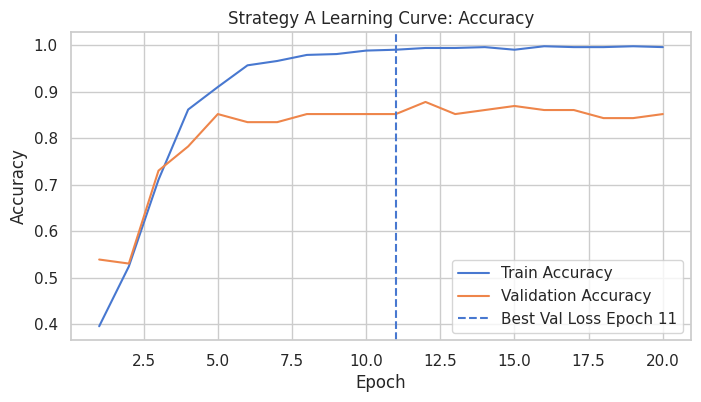

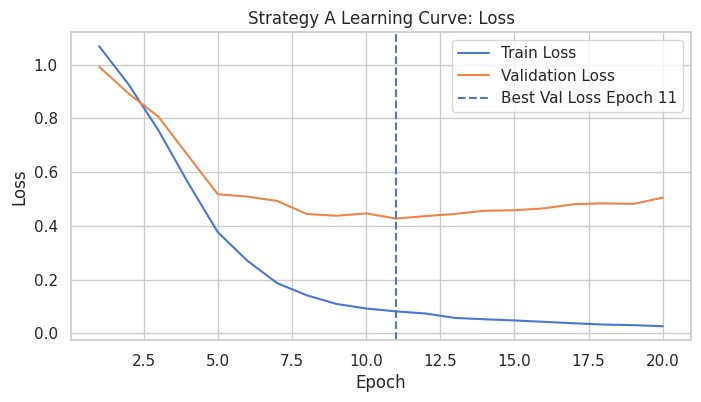

In [131]:
# Plot Strategy A learning curves

strategy_a_history = strategy_a_output["history"].history
strategy_a_best_epoch = strategy_a_output["result_row"]["best_epoch"]

epochs = range(1, len(strategy_a_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, strategy_a_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, strategy_a_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(strategy_a_best_epoch, linestyle="--", label=f"Best Val Loss Epoch {strategy_a_best_epoch}")
plt.title("Strategy A Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, strategy_a_history["loss"], label="Train Loss")
plt.plot(epochs, strategy_a_history["val_loss"], label="Validation Loss")
plt.axvline(strategy_a_best_epoch, linestyle="--", label=f"Best Val Loss Epoch {strategy_a_best_epoch}")
plt.title("Strategy A Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Strategy A Initial Interpretation**

Strategy A trains one bilingual SimpleRNN using the original cleaned English and Malay reviews.

The model achieved 0.8421 validation macro F1 and 0.8522 validation accuracy after reloading the best validation-loss checkpoint from epoch 11. This is slightly stronger than the Section 5 simple neural text baseline, which achieved 0.8077 validation macro F1 and 0.8174 validation accuracy.

The model fits the training data very strongly, with 0.9934 training macro F1 compared with 0.8421 validation macro F1. This gap suggests clear overfitting, which is expected because the dataset is small and SimpleRNN can memorise short training reviews. However, validation performance is still useful, so Strategy A remains a strong reference for the later language strategy comparisons.

Malay macro F1 is 0.8702 and English macro F1 is 0.8215. Since the validation language subsets are small, this should be treated as supporting evidence only, not as the sole basis for choosing the final language strategy.

### 6.4 Strategy B: Bilingual Text with Language Token

Strategy B keeps English and Malay reviews in one bilingual model, but adds a simple language token at the start of each review.

This gives the model explicit information about whether the review is English or Malay. This may help because the same sentiment class can be expressed using different words across languages.

The tokenizer is fitted only on the language-token training reviews, then applied to the language-token validation reviews. This isolates the effect of adding language information while keeping the same reference SimpleRNN architecture and training settings.

In [132]:
# Prepare Strategy B language-token text

def add_language_token(text_array, language_array):
    tokenised_text = []

    for text, language in zip(text_array, language_array):
        if language == "English":
            language_token = "lang_english"
        elif language == "Malay":
            language_token = "lang_malay"
        else:
            language_token = "lang_unknown"

        tokenised_text.append(f"{language_token} {text}")

    return np.asarray(tokenised_text).astype(str)


strategy_b_train_text = add_language_token(
    section6_train_text,
    section6_train_language
)

strategy_b_val_text = add_language_token(
    section6_val_text,
    section6_val_language
)

print("Strategy B language-token text prepared.")
print("Sample original training review:")
print(section6_train_text[0])
print("\nSample language-token training review:")
print(strategy_b_train_text[0])

Strategy B language-token text prepared.
Sample original training review:
Roti keras macam batu.

Sample language-token training review:
lang_malay Roti keras macam batu.


In [133]:
# Strategy B: bilingual text with language token

strategy_b_output = run_section6_single_model_strategy(
    strategy_key="strategy_b_language_token",
    strategy_name="B. Bilingual text with language token",
    train_text=strategy_b_train_text,
    val_text=strategy_b_val_text
)

section6_strategy_outputs["strategy_b_language_token"] = strategy_b_output

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.4235 - loss: 1.0603 - val_accuracy: 0.5391 - val_loss: 0.9998
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6418 - loss: 0.8841 - val_accuracy: 0.7130 - val_loss: 0.8513
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8284 - loss: 0.6546 - val_accuracy: 0.7739 - val_loss: 0.6517
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8918 - loss: 0.4246 - val_accuracy: 0.8174 - val_loss: 0.5316
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9478 - loss: 0.2780 - val_accuracy: 0.8696 - val_loss: 0.4162
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9552 - loss: 0.1991 - val_accuracy: 0.8609 - val_loss: 0.3996
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9608 - loss: 0.1586 - val_accuracy: 0.8174 - val_loss: 0.3989
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9664 - loss: 0.1256 - val_accuracy: 0.8609 - 

In [134]:
# Display Strategy B validation results

strategy_b_results = pd.DataFrame([strategy_b_output["result_row"]])

display(
    strategy_b_results[
        [
            "strategy_name",
            "best_epoch",
            "train_loss",
            "val_loss",
            "train_accuracy",
            "val_accuracy",
            "train_macro_f1",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

,strategy_name,best_epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,B. Bilingual text with language token,11,0.0583,0.3489,0.9907,0.887,0.9896,0.8829,0.1067,0.8876,0.8525,0.8831,0.913,0.9197,0.8406


In [135]:
# Compare completed Section 6 language strategies so far

section6_results_so_far = pd.DataFrame([
    strategy_a_output["result_row"],
    strategy_b_output["result_row"]
])

comparison_columns = [
    "strategy_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section6_results_so_far[comparison_columns].round(4))

,strategy_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,A. Bilingual original text,11,0.4269,0.8522,0.8421,0.1513,0.8538,0.8000,0.8000,0.9263,0.8215,0.8702
1,B. Bilingual text with language token,11,0.3489,0.8870,0.8829,0.1067,0.8876,0.8525,0.8831,0.9130,0.9197,0.8406


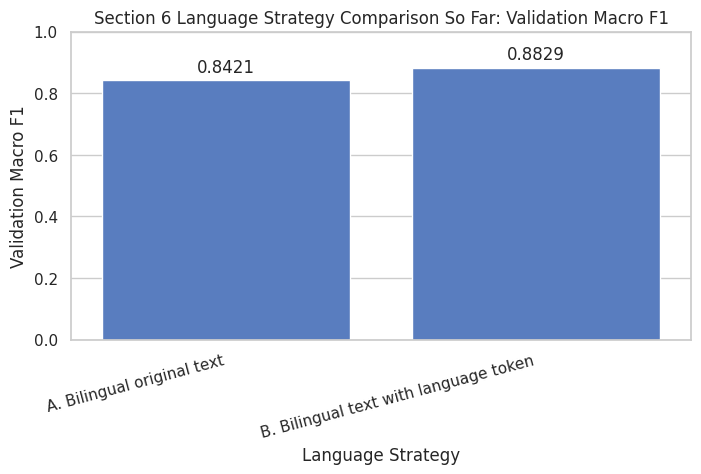

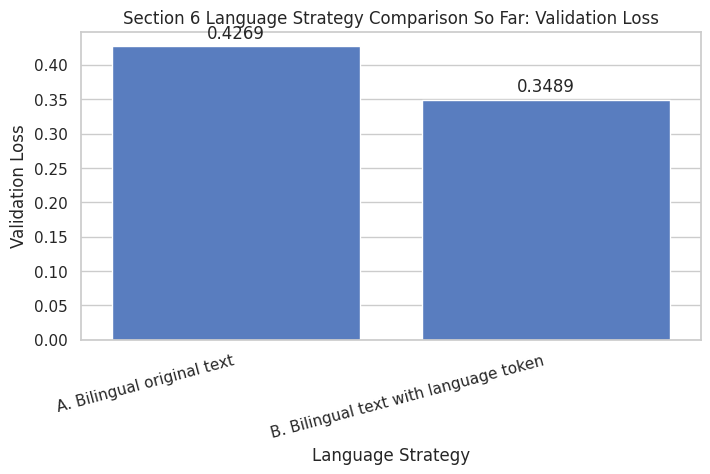

In [137]:
# Plot A vs B comparison on key validation metrics with value labels

plot_df = section6_results_so_far.copy()

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=plot_df,
    x="strategy_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 6 Language Strategy Comparison So Far: Validation Macro F1")
plt.xlabel("Language Strategy")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.show()


plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=plot_df,
    x="strategy_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 6 Language Strategy Comparison So Far: Validation Loss")
plt.xlabel("Language Strategy")
plt.ylabel("Validation Loss")
plt.xticks(rotation=15, ha="right")
plt.show()

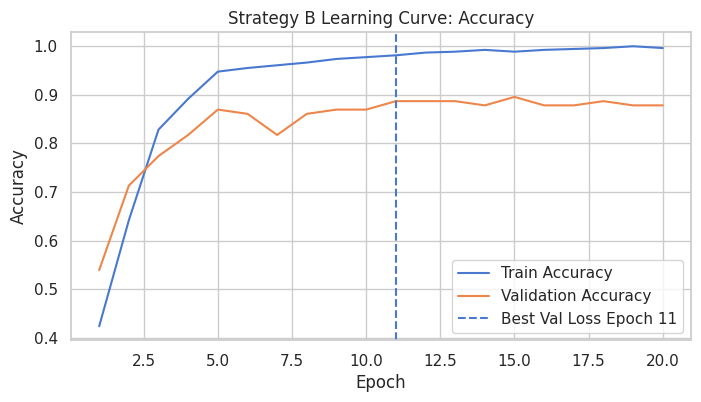

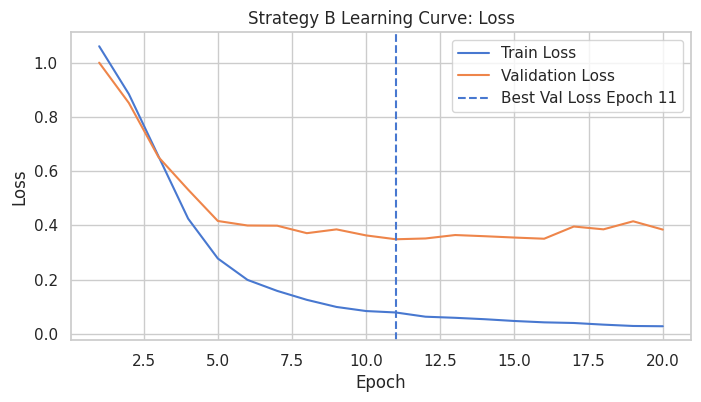

In [138]:
# Plot Strategy B learning curves

strategy_b_history = strategy_b_output["history"].history
strategy_b_best_epoch = strategy_b_output["result_row"]["best_epoch"]

epochs = range(1, len(strategy_b_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, strategy_b_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, strategy_b_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    strategy_b_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {strategy_b_best_epoch}"
)
plt.title("Strategy B Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, strategy_b_history["loss"], label="Train Loss")
plt.plot(epochs, strategy_b_history["val_loss"], label="Validation Loss")
plt.axvline(
    strategy_b_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {strategy_b_best_epoch}"
)
plt.title("Strategy B Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

**Strategy B Interpretation**

Strategy B adds a language token to each review before tokenisation, while still fitting the tokenizer only on the language-token training reviews. This keeps the experiment leakage-safe because the validation reviews are transformed using the training-fitted tokenizer only.

Strategy B achieved 0.8829 validation macro F1 and 0.8870 validation accuracy using the best validation-loss checkpoint from epoch 11. This improves over Strategy A, which achieved 0.8421 validation macro F1 and 0.8522 validation accuracy.

The A vs B comparison plots show that Strategy B is stronger on both main validation criteria. It has higher validation macro F1 and lower validation loss, meaning the language token improved both balanced class performance and validation confidence.

The Strategy B learning curves show fast early learning. Validation accuracy rises sharply in the first few epochs, then mostly plateaus around the high 0.80s. Training accuracy continues moving close to 1.0, while validation accuracy does not improve at the same rate, showing some overfitting.

The loss curve gives the clearest checkpoint signal. Training loss keeps decreasing throughout training, but validation loss reaches its lowest point at epoch 11 before fluctuating and rising slightly later. This supports the checkpoint rule of reloading the best validation-loss weights instead of using the final epoch weights.

Compared with Strategy A, the train-validation macro F1 gap is smaller, decreasing from 0.1513 to 0.1067. This suggests that adding the language token improved generalisation, not just training memorisation.

Class-level results are also strong. Strategy B performs best on Positive reviews with an F1-score of 0.9130, while Negative and Mixed/Neutral reviews both improve to above 0.85. This is useful because Mixed/Neutral was one of the harder classes in the earlier simple neural baseline.

The main trade-off is language-level performance. English macro F1 improves sharply from 0.8215 to 0.9197, while Malay macro F1 decreases from 0.8702 to 0.8406. Since the validation language subsets are small, this should be treated as supporting evidence rather than final proof.

Overall, Strategy B is the strongest language strategy so far. It should remain the leading candidate, but it should not be locked until the two-classifier routing strategy is tested.

### 6.5 Strategy C: Two-Classifier Routing by Language

Strategy C trains separate SimpleRNN classifiers for English and Malay reviews.

This tests whether each language benefits from its own tokenizer and model instead of sharing one bilingual representation. The English tokenizer is fitted only on English training reviews, and the Malay tokenizer is fitted only on Malay training reviews. Validation reviews are routed to the matching language-specific model.

This strategy may improve language-specific modelling, but it is also more complex and gives each model fewer training examples. Therefore, it should only be selected if it gives a meaningful validation improvement over the simpler bilingual strategies.

In [139]:
# Check training class distribution by language for routing strategy

label_id_to_name = {
    0: "Negative",
    1: "Mixed/Neutral",
    2: "Positive"
}

routing_train_check_df = pd.DataFrame({
    "Language": section6_train_language,
    "Sentiment": pd.Series(section6_y_train).map(label_id_to_name)
})

routing_train_summary = pd.crosstab(
    routing_train_check_df["Language"],
    routing_train_check_df["Sentiment"]
).reindex(columns=SENTIMENT_CLASSES, fill_value=0)

print("Training class distribution by language:")
display(routing_train_summary)

Training class distribution by language:


Sentiment,Negative,Mixed/Neutral,Positive
Language,,,
English,81,104,109
Malay,59,60,123


**Routing Feasibility Interpretation**

The training class distribution shows that both English and Malay subsets contain all three sentiment classes. This means a two-classifier routing strategy is technically feasible because neither language-specific model would be missing a class during training.

However, routing reduces the amount of data available to each model. The English model trains on 294 reviews, while the Malay model trains on 242 reviews. The Malay subset is also more skewed toward Positive reviews, with fewer Negative and Mixed/Neutral examples. Therefore, routing may improve language-specific modelling, but it also has a higher overfitting risk than the single bilingual models.

For this reason, Strategy C should only be selected if it gives a clear validation improvement over the simpler bilingual strategies.

In [140]:
# Strategy C: two-classifier routing by language
# Train separate SimpleRNN models for English and Malay reviews.
# Each language gets its own tokenizer fitted only on that language's training text.
# Validation predictions are routed by language and combined in the original validation order.

def run_section6_routing_strategy():
    tf.random.set_seed(SEED)

    routing_outputs = {}
    combined_train_preds = np.full(len(section6_y_train), fill_value=-1)
    combined_val_preds = np.full(len(section6_y_val), fill_value=-1)

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    best_epochs = []

    for language in ["English", "Malay"]:
        language_key = language.lower()

        train_mask = section6_train_language == language
        val_mask = section6_val_language == language

        if train_mask.sum() == 0:
            raise ValueError(f"No training rows found for {language}.")

        if val_mask.sum() == 0:
            raise ValueError(f"No validation rows found for {language}.")

        X_train_lang_text = section6_train_text[train_mask]
        y_train_lang = section6_y_train[train_mask]

        X_val_lang_text = section6_val_text[val_mask]
        y_val_lang = section6_y_val[val_mask]

        lang_tokenizer, X_train_lang, X_val_lang = prepare_text_sequences(
            train_text=X_train_lang_text,
            val_text=X_val_lang_text
        )

        model = build_section6_reference_rnn()

        checkpoint_path = os.path.join(
            SECTION6_CHECKPOINT_DIR,
            f"strategy_c_routing_{language_key}_best.weights.h5"
        )

        checkpoint = ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=0
        )

        history = model.fit(
            X_train_lang,
            y_train_lang,
            validation_data=(X_val_lang, y_val_lang),
            epochs=SECTION6_EPOCHS,
            batch_size=SECTION6_BATCH_SIZE,
            callbacks=[checkpoint],
            verbose=1
        )

        model.load_weights(checkpoint_path)

        train_loss, train_accuracy = model.evaluate(
            X_train_lang,
            y_train_lang,
            verbose=0
        )

        val_loss, val_accuracy = model.evaluate(
            X_val_lang,
            y_val_lang,
            verbose=0
        )

        train_preds_lang = np.argmax(
            model.predict(X_train_lang, verbose=0),
            axis=1
        )

        val_preds_lang = np.argmax(
            model.predict(X_val_lang, verbose=0),
            axis=1
        )

        combined_train_preds[train_mask] = train_preds_lang
        combined_val_preds[val_mask] = val_preds_lang

        train_losses.append(train_loss * train_mask.sum())
        val_losses.append(val_loss * val_mask.sum())
        train_accuracies.append(train_accuracy * train_mask.sum())
        val_accuracies.append(val_accuracy * val_mask.sum())

        best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
        best_epochs.append(f"{language}: {best_epoch}")

        routing_outputs[language_key] = {
            "language": language,
            "tokenizer": lang_tokenizer,
            "X_train": X_train_lang,
            "X_val": X_val_lang,
            "model": model,
            "history": history,
            "train_mask": train_mask,
            "val_mask": val_mask,
            "checkpoint_path": checkpoint_path,
            "best_epoch": best_epoch
        }

    if (combined_train_preds == -1).any() or (combined_val_preds == -1).any():
        raise ValueError("Some routed predictions were not assigned. Check language labels.")

    train_loss = sum(train_losses) / len(section6_y_train)
    val_loss = sum(val_losses) / len(section6_y_val)
    train_accuracy = sum(train_accuracies) / len(section6_y_train)
    val_accuracy = sum(val_accuracies) / len(section6_y_val)

    train_macro_f1 = f1_score(
        section6_y_train,
        combined_train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=combined_val_preds,
        val_language=section6_val_language
    )

    result_row = {
        "strategy_key": "strategy_c_routing",
        "strategy_name": "C. Two-classifier routing",
        "best_epoch": "; ".join(best_epochs),
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": "English and Malay routing checkpoints"
    }

    return {
        "strategy_key": "strategy_c_routing",
        "strategy_name": "C. Two-classifier routing",
        "routing_outputs": routing_outputs,
        "val_preds": combined_val_preds,
        "result_row": result_row
    }


strategy_c_output = run_section6_routing_strategy()
section6_strategy_outputs["strategy_c_routing"] = strategy_c_output

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 670ms/step - accuracy: 0.3844 - loss: 1.0821 - val_accuracy: 0.4127 - val_loss: 1.0395
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5748 - loss: 0.9537 - val_accuracy: 0.5238 - val_loss: 0.9481
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6259 - loss: 0.8653 - val_accuracy: 0.5556 - val_loss: 0.8738
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7959 - loss: 0.7267 - val_accuracy: 0.6825 - val_loss: 0.8015
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8707 - loss: 0.5812 - val_accuracy: 0.7460 - val_loss: 0.7139
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9218 - loss: 0.4337 - val_accuracy: 0.7937 - val_loss: 0.6268
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9626 - loss: 0.3116 - val_accuracy: 0.8095 - val_loss: 0.5734
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9762 - loss: 0.2416 - val_accuracy: 0.8254 -

In [141]:
# Display Strategy C validation results

strategy_c_results = pd.DataFrame([strategy_c_output["result_row"]])

display(
    strategy_c_results[
        [
            "strategy_name",
            "best_epoch",
            "train_loss",
            "val_loss",
            "train_accuracy",
            "val_accuracy",
            "train_macro_f1",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

,strategy_name,best_epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,C. Two-classifier routing,English: 13; Malay: 20,0.0647,0.423,0.9925,0.8696,0.9918,0.8602,0.1317,0.8713,0.8065,0.8378,0.9362,0.8219,0.9122


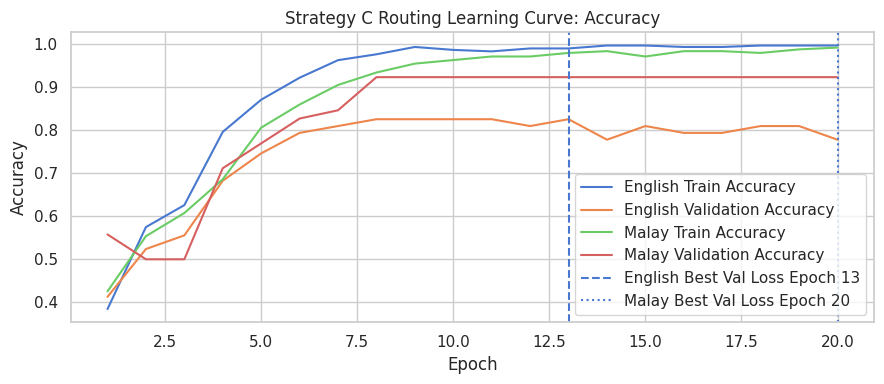

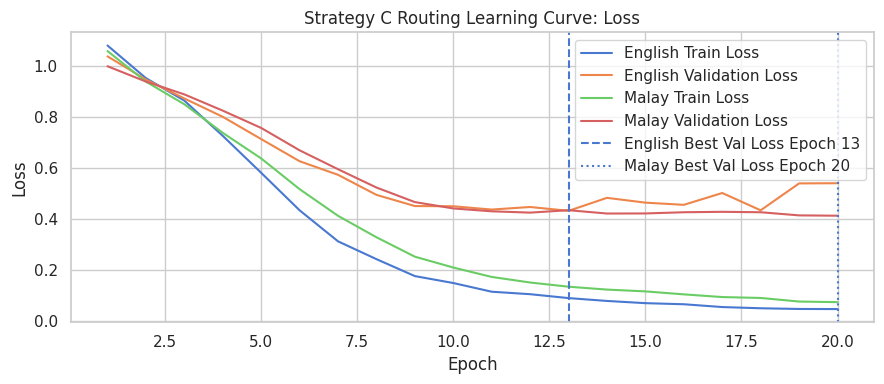

In [142]:
# Plot Strategy C routing learning curves

english_history = strategy_c_output["routing_outputs"]["english"]["history"].history
malay_history = strategy_c_output["routing_outputs"]["malay"]["history"].history

english_best_epoch = strategy_c_output["routing_outputs"]["english"]["best_epoch"]
malay_best_epoch = strategy_c_output["routing_outputs"]["malay"]["best_epoch"]

epochs = range(1, SECTION6_EPOCHS + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, english_history["accuracy"], label="English Train Accuracy")
plt.plot(epochs, english_history["val_accuracy"], label="English Validation Accuracy")
plt.plot(epochs, malay_history["accuracy"], label="Malay Train Accuracy")
plt.plot(epochs, malay_history["val_accuracy"], label="Malay Validation Accuracy")
plt.axvline(english_best_epoch, linestyle="--", label=f"English Best Val Loss Epoch {english_best_epoch}")
plt.axvline(malay_best_epoch, linestyle=":", label=f"Malay Best Val Loss Epoch {malay_best_epoch}")
plt.title("Strategy C Routing Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(epochs, english_history["loss"], label="English Train Loss")
plt.plot(epochs, english_history["val_loss"], label="English Validation Loss")
plt.plot(epochs, malay_history["loss"], label="Malay Train Loss")
plt.plot(epochs, malay_history["val_loss"], label="Malay Validation Loss")
plt.axvline(english_best_epoch, linestyle="--", label=f"English Best Val Loss Epoch {english_best_epoch}")
plt.axvline(malay_best_epoch, linestyle=":", label=f"Malay Best Val Loss Epoch {malay_best_epoch}")
plt.title("Strategy C Routing Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [143]:
# Compare all completed Section 6 language strategies

section6_results = pd.DataFrame([
    strategy_a_output["result_row"],
    strategy_b_output["result_row"],
    strategy_c_output["result_row"]
])

comparison_columns = [
    "strategy_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section6_results[comparison_columns].round(4))

,strategy_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,A. Bilingual original text,11,0.4269,0.8522,0.8421,0.1513,0.8538,0.8000,0.8000,0.9263,0.8215,0.8702
1,B. Bilingual text with language token,11,0.3489,0.8870,0.8829,0.1067,0.8876,0.8525,0.8831,0.9130,0.9197,0.8406
2,C. Two-classifier routing,English: 13; Malay: 20,0.4230,0.8696,0.8602,0.1317,0.8713,0.8065,0.8378,0.9362,0.8219,0.9122


**Strategy C Interpretation**

Strategy C trains separate SimpleRNN models for English and Malay reviews. Each model uses its own tokenizer fitted only on that language's training reviews, so the strategy remains leakage-safe.

The routing strategy achieved 0.8602 validation macro F1 and 0.8696 validation accuracy. This is stronger than Strategy A, but weaker than Strategy B, which achieved 0.8829 validation macro F1 and 0.8870 validation accuracy.

The validation loss also shows the same pattern. Strategy C achieved 0.4230 validation loss, which is close to Strategy A but worse than Strategy B's 0.3489. Since Section 6 uses validation macro F1 as the primary metric and validation loss as a secondary check, Strategy C is not the leading strategy overall.

The main benefit of routing is Malay performance. Malay macro F1 improved to 0.9122, which is higher than both Strategy A and Strategy B. However, English macro F1 dropped to 0.8219, and the overall validation macro F1 was lower than Strategy B. This suggests that routing may help the Malay subset but does not improve the full validation set.

The routing strategy also has a higher train-validation macro F1 gap than Strategy B, increasing from 0.1067 to 0.1317. This is expected because each language-specific model trains on fewer examples than the bilingual model.

Overall, Strategy C is useful evidence, but it is not strong enough to select. The current leading strategy remains Strategy B: bilingual text with a language token.

### 6.6 Strategy D: Translation-to-English with Cached Translations

Strategy D tests whether translating Malay reviews into English improves the RNN's sentiment classification performance.

This strategy keeps English reviews unchanged and translates Malay reviews into English. The goal is to reduce multilingual vocabulary fragmentation by allowing the model to learn from one mostly English text representation.

Because live translation services may change over time or fail during reruns, this notebook uses a cached translation workflow. Translations are generated once and saved to a CSV file. Future reruns load the cached translations instead of calling the translation service again.

The tokenizer for Strategy D will be fitted only on the translated training text. Validation reviews will be transformed using the training-fitted tokenizer only.

In [145]:
# Strategy D: prepare cached translation source data

SECTION6_TRANSLATION_CACHE_PATH = "checkpoints/section6/strategy_d_translation_cache.csv"

translation_source_df = pd.concat(
    [
        pd.DataFrame({
            "split": "train",
            "row_position": np.arange(len(section6_train_text)),
            "language": section6_train_language,
            "original_text": section6_train_text
        }),
        pd.DataFrame({
            "split": "validation",
            "row_position": np.arange(len(section6_val_text)),
            "language": section6_val_language,
            "original_text": section6_val_text
        })
    ],
    ignore_index=True
)

display(
    translation_source_df
    .groupby(["split", "language"])
    .size()
    .reset_index(name="row_count")
)

,split,language,row_count
0,train,English,294
1,train,Malay,242
2,validation,English,63
3,validation,Malay,52


In [146]:
!pip install -q deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 4.1 MB/s eta 0:00:00


In [147]:
# Strategy D: load existing translation cache or generate it once
# Train and validation translations are kept separate using the split column.

if os.path.exists(SECTION6_TRANSLATION_CACHE_PATH):
    translation_cache_df = pd.read_csv(SECTION6_TRANSLATION_CACHE_PATH)

    required_columns = [
        "split",
        "row_position",
        "language",
        "original_text",
        "translated_text"
    ]

    missing_columns = [
        col for col in required_columns
        if col not in translation_cache_df.columns
    ]

    if missing_columns:
        raise ValueError(f"Translation cache is missing columns: {missing_columns}")

    expected_rows = len(section6_train_text) + len(section6_val_text)

    if len(translation_cache_df) != expected_rows:
        raise ValueError("Translation cache row count does not match current train/validation data.")

    print("Loaded existing Strategy D translation cache.")

else:
    try:
        from deep_translator import GoogleTranslator
    except ImportError as error:
        raise ImportError(
            "Install deep-translator first using: !pip install -q deep-translator"
        ) from error

    translator = GoogleTranslator(source="auto", target="en")

    train_translation_df = pd.DataFrame({
        "split": "train",
        "row_position": np.arange(len(section6_train_text)),
        "language": section6_train_language,
        "original_text": section6_train_text
    })

    val_translation_df = pd.DataFrame({
        "split": "validation",
        "row_position": np.arange(len(section6_val_text)),
        "language": section6_val_language,
        "original_text": section6_val_text
    })

    def translate_malay_only(row):
        if row["language"] == "Malay":
            return translator.translate(str(row["original_text"]))
        return str(row["original_text"])

    train_translation_df["translated_text"] = train_translation_df.apply(
        translate_malay_only,
        axis=1
    )

    val_translation_df["translated_text"] = val_translation_df.apply(
        translate_malay_only,
        axis=1
    )

    translation_cache_df = pd.concat(
        [train_translation_df, val_translation_df],
        ignore_index=True
    )

    translation_cache_df.to_csv(
        SECTION6_TRANSLATION_CACHE_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("Generated and saved Strategy D translation cache.")

print(f"Translation cache path: {SECTION6_TRANSLATION_CACHE_PATH}")
print(f"Cached rows: {len(translation_cache_df)}")

display(
    translation_cache_df
    .groupby(["split", "language"])
    .size()
    .reset_index(name="row_count")
)

display(translation_cache_df.head())

Generated and saved Strategy D translation cache.
Translation cache path: checkpoints/section6/strategy_d_translation_cache.csv
Cached rows: 651


,split,language,row_count
0,train,English,294
1,train,Malay,242
2,validation,English,63
3,validation,Malay,52


,split,row_position,language,original_text,translated_text
0,train,0,Malay,Roti keras macam batu.,The bread is hard as a rock.
1,train,1,Malay,Hebat dan sedap. Roti garing dan topping kaya ...,Great and delicious. Crispy bread and rich top...
2,train,2,English,Pizza was greasy and unpleasant.,Pizza was greasy and unpleasant.
3,train,3,Malay,Pizza ni rasa basi dan tak sedap.,This pizza tastes stale and not tasty.
4,train,4,Malay,Gabungan rasa yang sempurna dan lazat.,A perfect and delicious combination of flavors.


**Strategy D Translation Cache Interpretation**

The translation cache contains 651 rows, matching the 536 training reviews and 115 validation reviews used in Section 6. Train and validation rows are stored with separate split labels, so the translation workflow does not mix the two modelling splits.

English reviews are kept unchanged, while Malay reviews are translated into English. The sample translations show that the main sentiment meaning is generally preserved. For example, “Roti keras macam batu” is translated as “The bread is hard as a rock”, which still clearly expresses negative sentiment.

This translation strategy is not used to create new labels or new training examples. It only changes the text representation before tokenisation. The Strategy D tokenizer will still be fitted only on the translated training text, then applied to the translated validation text.

In [148]:
# Prepare Strategy D translated train and validation text

strategy_d_train_df = (
    translation_cache_df[translation_cache_df["split"] == "train"]
    .sort_values("row_position")
    .reset_index(drop=True)
)

strategy_d_val_df = (
    translation_cache_df[translation_cache_df["split"] == "validation"]
    .sort_values("row_position")
    .reset_index(drop=True)
)

if len(strategy_d_train_df) != len(section6_train_text):
    raise ValueError("Translated training row count does not match Section 6 training text.")

if len(strategy_d_val_df) != len(section6_val_text):
    raise ValueError("Translated validation row count does not match Section 6 validation text.")

if not np.array_equal(
    strategy_d_train_df["row_position"].to_numpy(),
    np.arange(len(section6_train_text))
):
    raise ValueError("Translated training rows are not in the expected order.")

if not np.array_equal(
    strategy_d_val_df["row_position"].to_numpy(),
    np.arange(len(section6_val_text))
):
    raise ValueError("Translated validation rows are not in the expected order.")

if not np.array_equal(
    strategy_d_train_df["original_text"].astype(str).to_numpy(),
    section6_train_text.astype(str)
):
    raise ValueError("Translated training original_text does not match current training text.")

if not np.array_equal(
    strategy_d_val_df["original_text"].astype(str).to_numpy(),
    section6_val_text.astype(str)
):
    raise ValueError("Translated validation original_text does not match current validation text.")

strategy_d_train_text = (
    strategy_d_train_df["translated_text"]
    .fillna("")
    .astype(str)
    .to_numpy()
)

strategy_d_val_text = (
    strategy_d_val_df["translated_text"]
    .fillna("")
    .astype(str)
    .to_numpy()
)

print("Strategy D translated text prepared.")
print(f"Translated train text shape: {strategy_d_train_text.shape}")
print(f"Translated validation text shape: {strategy_d_val_text.shape}")

display(
    strategy_d_train_df[strategy_d_train_df["language"] == "Malay"][
        ["original_text", "translated_text"]
    ].head()
)

Strategy D translated text prepared.
Translated train text shape: (536,)
Translated validation text shape: (115,)


,original_text,translated_text
0,Roti keras macam batu.,The bread is hard as a rock.
1,Hebat dan sedap. Roti garing dan topping kaya ...,Great and delicious. Crispy bread and rich top...
3,Pizza ni rasa basi dan tak sedap.,This pizza tastes stale and not tasty.
4,Gabungan rasa yang sempurna dan lazat.,A perfect and delicious combination of flavors.
5,Pizza fusion ni tak terlalu sedap tapi tak pul...,This fusion pizza is not very tasty but not ba...


In [149]:
# Strategy D: translation-to-English

strategy_d_output = run_section6_single_model_strategy(
    strategy_key="strategy_d_translation_english",
    strategy_name="D. Translation-to-English",
    train_text=strategy_d_train_text,
    val_text=strategy_d_val_text
)

section6_strategy_outputs["strategy_d_translation_english"] = strategy_d_output

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.3806 - loss: 1.0684 - val_accuracy: 0.4696 - val_loss: 0.9920
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4963 - loss: 0.9389 - val_accuracy: 0.5826 - val_loss: 0.9228
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7239 - loss: 0.8105 - val_accuracy: 0.6696 - val_loss: 0.8367
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7761 - loss: 0.6729 - val_accuracy: 0.6609 - val_loss: 0.7874
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8228 - loss: 0.5504 - val_accuracy: 0.7130 - val_loss: 0.7073
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9049 - loss: 0.4410 - val_accuracy: 0.7391 - val_loss: 0.6617
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9328 - loss: 0.3500 - val_accuracy: 0.7478 - val_loss: 0.6212
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9552 - loss: 0.2655 - val_accuracy: 0.7478 - 

In [150]:
# Display Strategy D validation results

strategy_d_results = pd.DataFrame([strategy_d_output["result_row"]])

display(
    strategy_d_results[
        [
            "strategy_name",
            "best_epoch",
            "train_loss",
            "val_loss",
            "train_accuracy",
            "val_accuracy",
            "train_macro_f1",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

,strategy_name,best_epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,D. Translation-to-English,11,0.1104,0.5744,0.9832,0.7739,0.9814,0.763,0.2184,0.7768,0.75,0.6667,0.8723,0.7952,0.7131


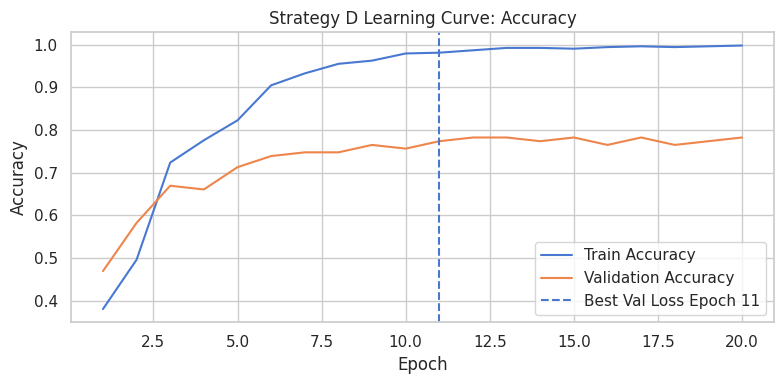

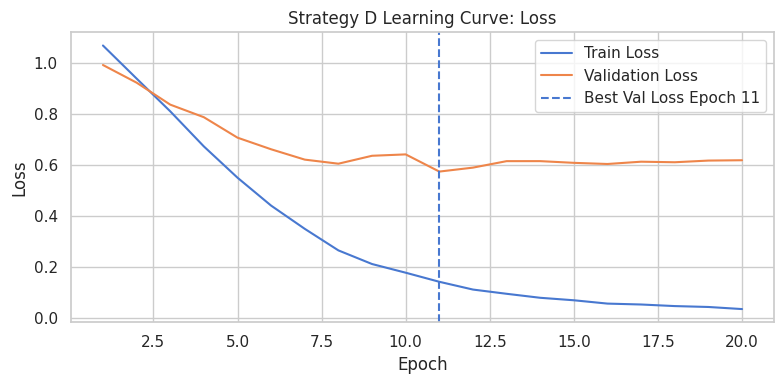

In [151]:
# Plot Strategy D learning curves

strategy_d_history = strategy_d_output["history"].history
strategy_d_best_epoch = strategy_d_output["result_row"]["best_epoch"]

epochs = range(1, len(strategy_d_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, strategy_d_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, strategy_d_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    strategy_d_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {strategy_d_best_epoch}"
)
plt.title("Strategy D Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, strategy_d_history["loss"], label="Train Loss")
plt.plot(epochs, strategy_d_history["val_loss"], label="Validation Loss")
plt.axvline(
    strategy_d_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {strategy_d_best_epoch}"
)
plt.title("Strategy D Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

**Strategy D Interpretation**

Strategy D translates Malay reviews into English while keeping English reviews unchanged. The translation cache is generated separately for training and validation rows, then reused for reproducibility. The tokenizer is still fitted only on translated training text, so the validation set remains leakage-safe.

Strategy D achieved 0.7630 validation macro F1 and 0.7739 validation accuracy using the best validation-loss checkpoint from epoch 11. This is weaker than all three previous language strategies, especially Strategy B, which achieved 0.8829 validation macro F1 and 0.8870 validation accuracy.

The validation loss also worsened to 0.5744, compared with 0.3489 for Strategy B. The train-validation macro F1 gap increased to 0.2184, showing stronger overfitting and weaker generalisation.

The language-level results show that translation did not improve either group. English macro F1 was 0.7952 and Malay macro F1 was 0.7131, both lower than the leading language-token strategy. This suggests that translating Malay reviews into English may have changed phrasing or reduced useful language-specific sentiment cues.

Overall, Strategy D is not selected. However, it is still useful evidence because it tests a plausible teacher-recommended preprocessing strategy in a reproducible way and shows that translation is not beneficial for this dataset and model setup.

In [152]:
# Final Section 6 language strategy comparison table

section6_results = pd.DataFrame([
    strategy_a_output["result_row"],
    strategy_b_output["result_row"],
    strategy_c_output["result_row"],
    strategy_d_output["result_row"]
])

comparison_columns = [
    "strategy_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section6_results[comparison_columns].round(4))

,strategy_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,A. Bilingual original text,11,0.4269,0.8522,0.8421,0.1513,0.8538,0.8000,0.8000,0.9263,0.8215,0.8702
1,B. Bilingual text with language token,11,0.3489,0.8870,0.8829,0.1067,0.8876,0.8525,0.8831,0.9130,0.9197,0.8406
2,C. Two-classifier routing,English: 13; Malay: 20,0.4230,0.8696,0.8602,0.1317,0.8713,0.8065,0.8378,0.9362,0.8219,0.9122
3,D. Translation-to-English,11,0.5744,0.7739,0.7630,0.2184,0.7768,0.7500,0.6667,0.8723,0.7952,0.7131


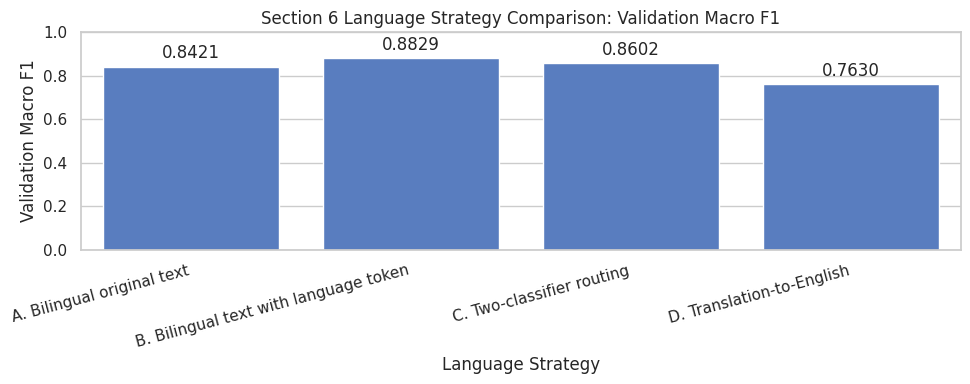

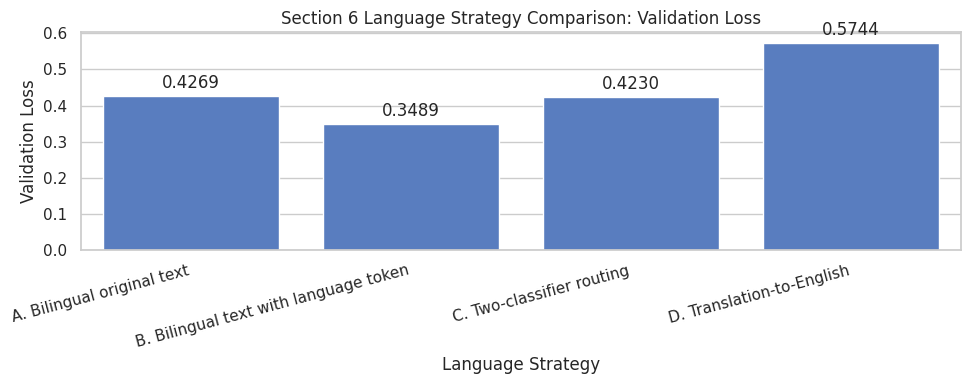

In [153]:
# Plot final Section 6 strategies on validation macro F1 and validation loss

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section6_results,
    x="strategy_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 6 Language Strategy Comparison: Validation Macro F1")
plt.xlabel("Language Strategy")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section6_results,
    x="strategy_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 6 Language Strategy Comparison: Validation Loss")
plt.xlabel("Language Strategy")
plt.ylabel("Validation Loss")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

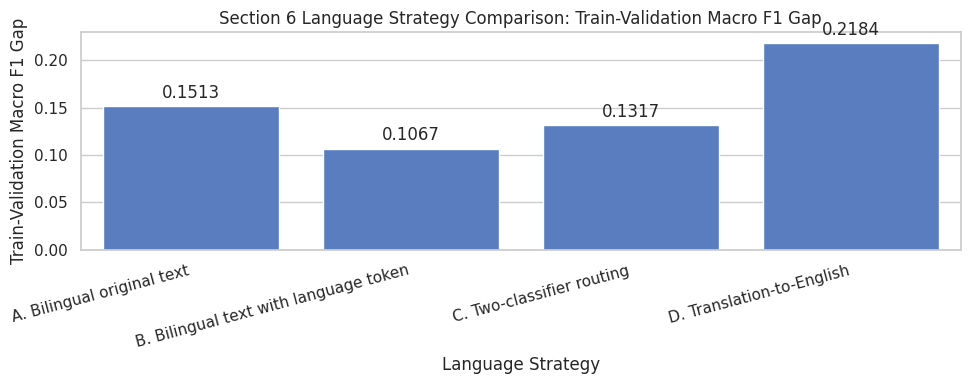

In [154]:
# Plot final Section 6 train-validation macro F1 gap

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section6_results,
    x="strategy_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 6 Language Strategy Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Language Strategy")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

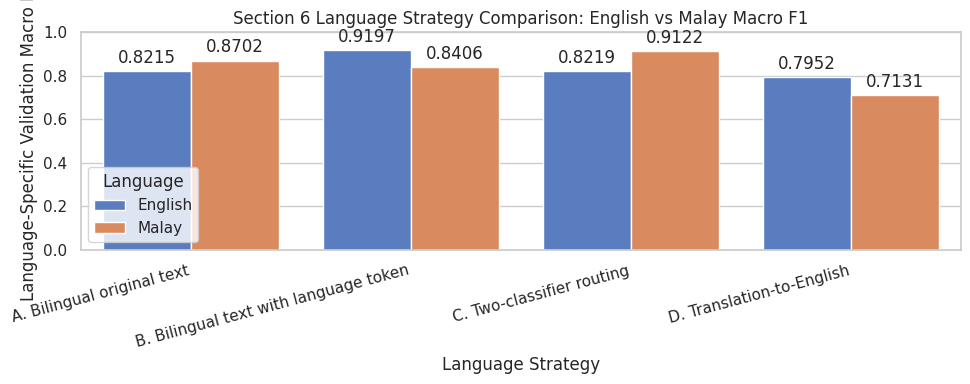

In [155]:
# Plot final English vs Malay macro F1 by language strategy

language_f1_plot_df = section6_results[
    ["strategy_name", "english_macro_f1", "malay_macro_f1"]
].melt(
    id_vars="strategy_name",
    value_vars=["english_macro_f1", "malay_macro_f1"],
    var_name="language_metric",
    value_name="macro_f1"
)

language_f1_plot_df["Language"] = language_f1_plot_df["language_metric"].map({
    "english_macro_f1": "English",
    "malay_macro_f1": "Malay"
})

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=language_f1_plot_df,
    x="strategy_name",
    y="macro_f1",
    hue="Language"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 6 Language Strategy Comparison: English vs Malay Macro F1")
plt.xlabel("Language Strategy")
plt.ylabel("Language-Specific Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

### 6.7 Section 6 Decision and Selected Language Strategy

This subsection selects the language strategy to carry forward into Sections 7-9.

The selected strategy must perform well on validation macro F1, validation loss, class-level F1, language-level macro F1, overfitting behaviour, and simplicity. A more complex strategy is only selected if it gives a meaningful improvement over a simpler one.

In [156]:
# Lock selected Section 6 language strategy

selected_language_strategy_key = "strategy_b_language_token"
selected_language_strategy_name = "B. Bilingual text with language token"

selected_strategy_output = section6_strategy_outputs[selected_language_strategy_key]

selected_train_text = strategy_b_train_text
selected_val_text = strategy_b_val_text

selected_X_train = selected_strategy_output["X_train"]
selected_X_val = selected_strategy_output["X_val"]

selected_tokenizer = selected_strategy_output["tokenizer"]
selected_val_preds = selected_strategy_output["val_preds"]
selected_language_strategy_result = selected_strategy_output["result_row"]

print("Selected language strategy locked.")
print(f"Strategy key: {selected_language_strategy_key}")
print(f"Strategy name: {selected_language_strategy_name}")
print(f"Selected X_train shape: {selected_X_train.shape}")
print(f"Selected X_val shape: {selected_X_val.shape}")

display(
    pd.DataFrame([selected_language_strategy_result])[
        [
            "strategy_name",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected language strategy locked.
Strategy key: strategy_b_language_token
Strategy name: B. Bilingual text with language token
Selected X_train shape: (536, 25)
Selected X_val shape: (115, 25)


,strategy_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,B. Bilingual text with language token,11,0.3489,0.887,0.8829,0.1067,0.8876,0.8525,0.8831,0.913,0.9197,0.8406


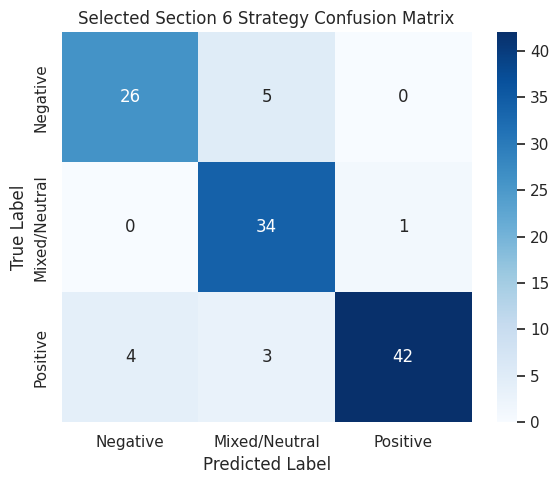

Classification report for selected Section 6 strategy:
               precision    recall  f1-score   support

     Negative       0.87      0.84      0.85        31
Mixed/Neutral       0.81      0.97      0.88        35
     Positive       0.98      0.86      0.91        49

     accuracy                           0.89       115
    macro avg       0.88      0.89      0.88       115
 weighted avg       0.90      0.89      0.89       115



In [157]:
# Confusion matrix for selected Section 6 strategy

selected_cm = confusion_matrix(
    section6_y_val,
    selected_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Selected Section 6 Strategy Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected Section 6 strategy:")
print(
    classification_report(
        section6_y_val,
        selected_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 6 Final Interpretation**

Section 6 compared four language-handling strategies using the same fixed SimpleRNN reference model. The aim was to decide how English and Malay reviews should be represented before continuing into later RNN modelling.

Strategy B, bilingual text with a language token, is selected for Sections 7-9. It achieved the strongest overall validation performance, with 0.8829 validation macro F1, 0.8870 validation accuracy, and the lowest validation loss of 0.3489. It also had the smallest train-validation macro F1 gap at 0.1067, suggesting better generalisation than the other strategies.

Strategy A, bilingual original text, was simpler but weaker. It achieved 0.8421 validation macro F1 and 0.4269 validation loss. This shows that keeping English and Malay together is viable, but the model benefits from explicit language information.

Strategy C, two-classifier routing, improved Malay macro F1 to 0.9122, but it did not perform best overall. Its validation macro F1 was 0.8602 and validation loss was 0.4230, both weaker than Strategy B. Routing also requires two tokenizers and two models, making it more complex. Since the overall gain was not better than Strategy B, routing is not selected.

Strategy D, translation-to-English, tested a plausible teacher-recommended preprocessing idea using a reproducible cached translation workflow. However, it performed worst overall, with 0.7630 validation macro F1 and 0.5744 validation loss. This suggests that translation introduced noise or removed useful language-specific sentiment cues in this dataset.

The selected confusion matrix for Strategy B shows strong performance across all three classes. Mixed/Neutral reviews were handled especially well, with 34 out of 35 correctly classified. Most remaining errors came from Negative reviews predicted as Mixed/Neutral and Positive reviews predicted as Negative or Mixed/Neutral. This is reasonable because short review text can contain ambiguous or blended sentiment.

Overall, Strategy B provides the best trade-off. It keeps both English and Malay reviews, avoids discarding useful data, avoids translation noise, remains simpler than routing, and gives the strongest validation results. The selected tokenizer and selected padded train/validation arrays are now locked for Sections 7-9. The test set remains untouched and will only be transformed once during final evaluation.



---



## 7. Initial SimpleRNN Baseline

Section 7 formalises the selected language strategy from Section 6 as the initial RNN baseline.

The selected input representation is bilingual text with a language token. This section compares the initial SimpleRNN baseline against the earlier simple neural text baseline from Section 5.

No new model tuning is done here. The purpose is to establish whether a sequence-aware RNN baseline improves over the average-pooled embedding baseline.

In [158]:
# Section 7: compare Section 5 simple neural baseline with selected SimpleRNN baseline

section7_baseline_comparison = pd.DataFrame([
    {
        "model": "Section 5 simple neural text baseline",
        "input_representation": "Original bilingual text",
        "architecture": "Embedding + GlobalAveragePooling1D + Dense",
        "val_loss": 0.7007,
        "val_accuracy": 0.8174,
        "val_macro_f1": 0.8077,
        "val_weighted_f1": 0.8175
    },
    {
        "model": "Section 7 initial SimpleRNN baseline",
        "input_representation": selected_language_strategy_name,
        "architecture": "Embedding + SimpleRNN(32) + Dropout(0.3) + Dense",
        "val_loss": selected_language_strategy_result["val_loss"],
        "val_accuracy": selected_language_strategy_result["val_accuracy"],
        "val_macro_f1": selected_language_strategy_result["val_macro_f1"],
        "val_weighted_f1": selected_language_strategy_result["val_weighted_f1"]
    }
])

display(section7_baseline_comparison.round(4))

,model,input_representation,architecture,val_loss,val_accuracy,val_macro_f1,val_weighted_f1
0,Section 5 simple neural text baseline,Original bilingual text,Embedding + GlobalAveragePooling1D + Dense,0.7007,0.8174,0.8077,0.8175
1,Section 7 initial SimpleRNN baseline,B. Bilingual text with language token,Embedding + SimpleRNN(32) + Dropout(0.3) + Dense,0.3489,0.8870,0.8829,0.8876


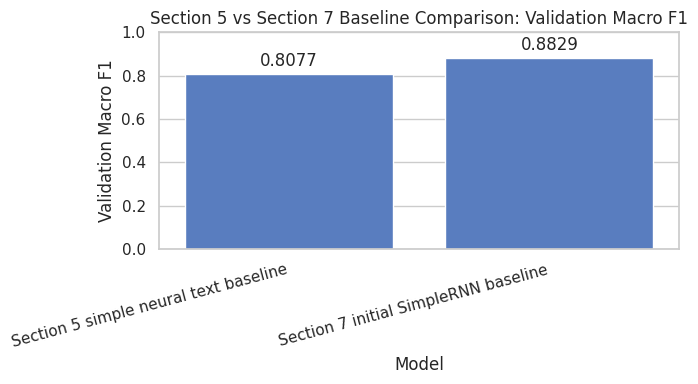

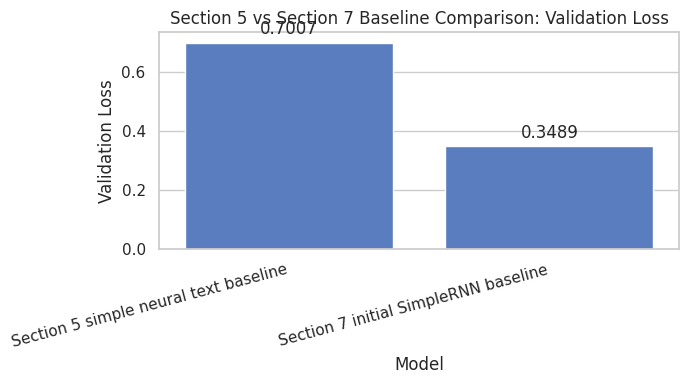

In [159]:
# Plot Section 5 baseline vs Section 7 initial SimpleRNN baseline

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section7_baseline_comparison,
    x="model",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 5 vs Section 7 Baseline Comparison: Validation Macro F1")
plt.xlabel("Model")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section7_baseline_comparison,
    x="model",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 5 vs Section 7 Baseline Comparison: Validation Loss")
plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

**Section 7 Interpretation**

Section 7 formalises the selected Section 6 language strategy as the initial SimpleRNN baseline.

Compared with the Section 5 simple neural text baseline, the initial SimpleRNN baseline performs better on all main validation metrics. Validation macro F1 improves from 0.8077 to 0.8829, validation accuracy improves from 0.8174 to 0.8870, and validation loss decreases from 0.7007 to 0.3489.

This shows that the sequence-aware SimpleRNN model is more effective than average-pooled embeddings for this task. The improvement is meaningful because sentiment in reviews can depend on word order, contrast phrases, and sentence flow, which GlobalAveragePooling1D does not explicitly model.

The lower validation loss is especially important because it suggests the SimpleRNN is not only making more correct predictions, but is also producing more confident validation predictions. This supports using the selected language-token SimpleRNN as the proper RNN baseline for the rest of the notebook.

However, this does not mean SimpleRNN is the final model family. SimpleRNN is a basic recurrent architecture and may struggle with longer dependencies compared with LSTM or GRU. Section 8 therefore compares multiple RNN model families using the same selected language-token input representation.

## 8. RNN Model Family Selection

Section 8 compares different RNN model families using the selected language-token representation from Section 6.

The selected input representation is fixed as bilingual text with a language token. The tokenizer, padded training data, and padded validation data are already locked from Section 6.

This section compares model families only. Other improvement ideas such as engineered training data, sequence length, capacity, bidirectionality, regularisation, class weights, and learning-rate strategy are deferred to Section 9.

### 8.1 Model Family Comparison Setup

This subsection sets up the fixed decision rule and training settings for model family comparison.

The model families compared are:

1. SimpleRNN(32)
2. LSTM(32)
3. GRU(32)
4. Stacked LSTM(32, 32)
5. LSTM + GRU(32, 32)

All models use the same selected language-token train and validation arrays, same vocabulary size, same sequence length, same embedding dimension, same optimiser, same batch size, and same epoch budget.

The test set is not used. Model family selection is based only on validation performance.

In [166]:
# Section 8 setup

SECTION8_CHECKPOINT_DIR = "checkpoints/section8"
os.makedirs(SECTION8_CHECKPOINT_DIR, exist_ok=True)

SECTION8_UNITS = 32
SECTION8_DROPOUT = 0.3
SECTION8_EPOCHS = 20
SECTION8_BATCH_SIZE = 32
SECTION8_LEARNING_RATE = 0.001

required_section8_objects = [
    "selected_language_strategy_key",
    "selected_language_strategy_name",
    "selected_X_train",
    "selected_X_val",
    "selected_tokenizer",
    "section6_y_train",
    "section6_y_val",
    "section6_val_language",
    "VOCAB_SIZE",
    "MAX_SEQUENCE_LENGTH",
    "EMBEDDING_DIM",
    "SEED"
]

missing_section8_objects = [
    name for name in required_section8_objects
    if name not in globals()
]

if missing_section8_objects:
    raise NameError(f"Missing required Section 8 objects: {missing_section8_objects}")

print("Section 8 setup complete.")
print(f"Selected language strategy: {selected_language_strategy_name}")
print(f"Selected X_train shape: {selected_X_train.shape}")
print(f"Selected X_val shape: {selected_X_val.shape}")
print(f"Checkpoint folder: {SECTION8_CHECKPOINT_DIR}")

Section 8 setup complete.
Selected language strategy: B. Bilingual text with language token
Selected X_train shape: (536, 25)
Selected X_val shape: (115, 25)
Checkpoint folder: checkpoints/section8


In [167]:
# Section 8 model family helpers

# Build one RNN-family model using fixed Section 8 settings.
def build_section8_model(model_key):
    model = Sequential()
    model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))
    model.add(Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ))

    if model_key == "simple_rnn":
        model.add(SimpleRNN(SECTION8_UNITS))

    elif model_key == "lstm":
        model.add(LSTM(SECTION8_UNITS))

    elif model_key == "gru":
        model.add(GRU(SECTION8_UNITS))

    elif model_key == "stacked_lstm":
        model.add(LSTM(SECTION8_UNITS, return_sequences=True))
        model.add(LSTM(SECTION8_UNITS))

    elif model_key == "lstm_gru":
        model.add(LSTM(SECTION8_UNITS, return_sequences=True))
        model.add(GRU(SECTION8_UNITS))

    else:
        raise ValueError(f"Unknown model_key: {model_key}")

    model.add(Dropout(SECTION8_DROPOUT))
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=SECTION8_LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Train and evaluate one RNN model family using validation only.
def run_section8_model_family(model_key, model_name):
    tf.random.set_seed(SEED)

    model = build_section8_model(model_key)

    checkpoint_path = os.path.join(
        SECTION8_CHECKPOINT_DIR,
        f"{model_key}_best.weights.h5"
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    history = model.fit(
        selected_X_train,
        section6_y_train,
        validation_data=(selected_X_val, section6_y_val),
        epochs=SECTION8_EPOCHS,
        batch_size=SECTION8_BATCH_SIZE,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        selected_X_train,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        selected_X_val,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(selected_X_train, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(selected_X_val, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "model_key": model_key,
        "model_name": model_name,
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "model_key": model_key,
        "model_name": model_name,
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

### 8.2 Controlled RNN Model Family Comparison

This subsection compares five RNN model families using the same selected language-token input representation.

The only controlled change is the recurrent model family:

1. SimpleRNN(32)
2. LSTM(32)
3. GRU(32)
4. Stacked LSTM(32, 32)
5. LSTM + GRU(32, 32)

All other settings are fixed. This makes the comparison focused on architecture choice rather than mixing architecture changes with preprocessing, sequence length, capacity, class weights, or learning-rate changes.

In [168]:
# Train Section 8 RNN model family candidates

section8_model_configs = [
    ("simple_rnn", "SimpleRNN(32)"),
    ("lstm", "LSTM(32)"),
    ("gru", "GRU(32)"),
    ("stacked_lstm", "Stacked LSTM(32, 32)"),
    ("lstm_gru", "LSTM + GRU(32, 32)")
]

section8_model_outputs = {}

for model_key, model_name in section8_model_configs:
    print("=" * 80)
    print(f"Training Section 8 model family: {model_name}")
    print("=" * 80)

    section8_model_outputs[model_key] = run_section8_model_family(
        model_key=model_key,
        model_name=model_name
    )

Training Section 8 model family: SimpleRNN(32)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - accuracy: 0.4347 - loss: 1.0623 - val_accuracy: 0.6174 - val_loss: 0.9833
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6493 - loss: 0.8669 - val_accuracy: 0.6348 - val_loss: 0.8579
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7612 - loss: 0.7140 - val_accuracy: 0.7130 - val_loss: 0.7728
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8284 - loss: 0.5514 - val_accuracy: 0.7826 - val_loss: 0.6339
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9011 - loss: 0.3950 - val_accuracy: 0.8087 - val_loss: 0.5167
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9440 - loss: 0.2758 - val_accuracy: 0.8087 - val_loss: 0.4728
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9459 - loss: 0.2286 - val_accuracy: 0.8261 - val_loss: 0.4500
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy:

In [169]:
# Display Section 8 model family comparison table

section8_results = pd.DataFrame([
    output["result_row"]
    for output in section8_model_outputs.values()
])

section8_comparison_columns = [
    "model_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section8_results[section8_comparison_columns].round(4))

,model_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,SimpleRNN(32),19,0.3598,0.8870,0.8799,0.1182,0.8882,0.8387,0.8649,0.9362,0.8873,0.8685
1,LSTM(32),15,0.4034,0.8522,0.8482,0.1339,0.8555,0.7826,0.8732,0.8889,0.8541,0.8525
2,GRU(32),16,0.4060,0.8609,0.8570,0.1370,0.8630,0.8116,0.8657,0.8936,0.8212,0.9108
3,"Stacked LSTM(32, 32)",11,0.4354,0.8261,0.8209,0.1411,0.8315,0.7429,0.8333,0.8864,0.8241,0.8276
4,"LSTM + GRU(32, 32)",10,0.4220,0.8435,0.8382,0.1414,0.8470,0.7647,0.8611,0.8889,0.8541,0.8276


**Section 8.2 Model Family Comparison Interpretation**

The model family comparison shows that SimpleRNN(32) is the strongest overall model family under the fixed Section 8 settings.

SimpleRNN(32) achieved the highest validation macro F1 of 0.8799, the lowest validation loss of 0.3598, and the joint-highest validation accuracy of 0.8870. It also had the smallest train-validation macro F1 gap of 0.1182, suggesting better generalisation than the LSTM, GRU, and stacked variants in this controlled comparison.

The LSTM and GRU models performed reasonably well, but neither improved over SimpleRNN overall. GRU achieved stronger Malay macro F1, but this came with weaker English macro F1 and lower overall validation macro F1. Since model selection is based on overall validation performance first, GRU is not selected.

The stacked LSTM and LSTM + GRU models did not improve performance. Their lower validation macro F1 and higher validation loss suggest that adding depth increased complexity without giving useful gains for this small, short-review dataset.

Overall, SimpleRNN(32) is selected as the model family for Section 9 improvement. This is also the simplest recurrent option, so it is preferred unless a more complex model clearly outperforms it.

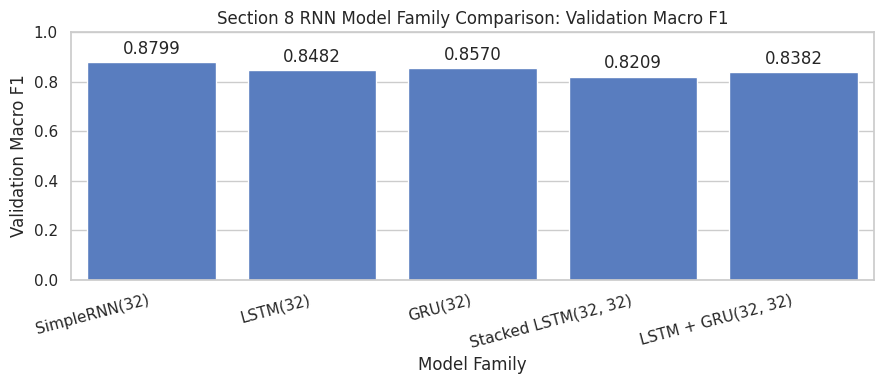

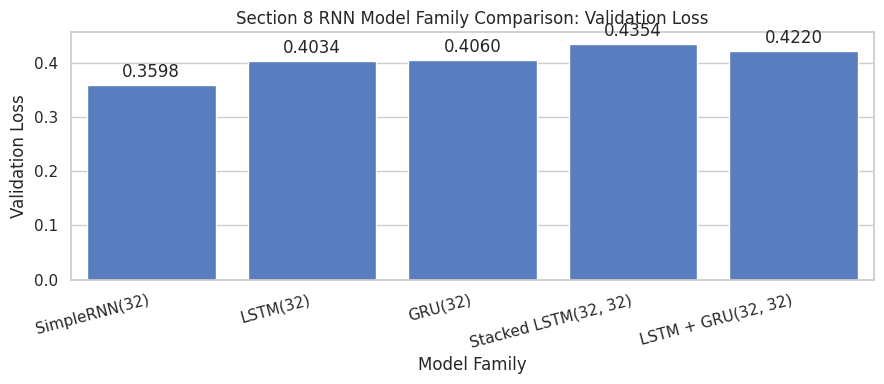

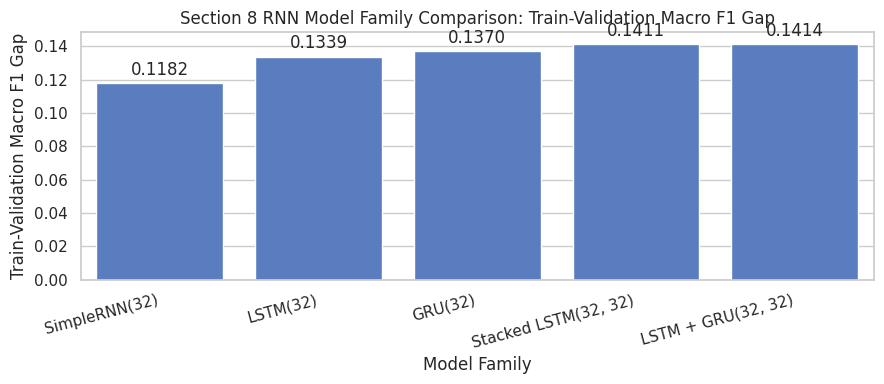

In [170]:
# Plot Section 8 model family comparison

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section8_results,
    x="model_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 8 RNN Model Family Comparison: Validation Macro F1")
plt.xlabel("Model Family")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section8_results,
    x="model_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 8 RNN Model Family Comparison: Validation Loss")
plt.xlabel("Model Family")
plt.ylabel("Validation Loss")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section8_results,
    x="model_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 8 RNN Model Family Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Model Family")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

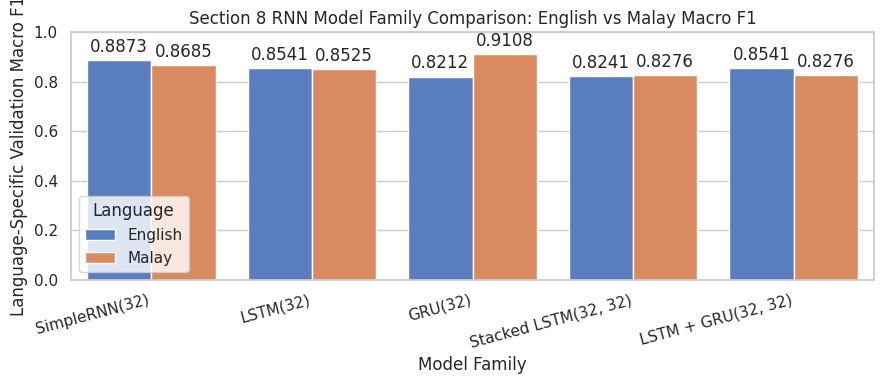

In [171]:
# Plot English vs Malay macro F1 by model family

section8_language_f1_plot_df = section8_results[
    ["model_name", "english_macro_f1", "malay_macro_f1"]
].melt(
    id_vars="model_name",
    value_vars=["english_macro_f1", "malay_macro_f1"],
    var_name="language_metric",
    value_name="macro_f1"
)

section8_language_f1_plot_df["Language"] = section8_language_f1_plot_df["language_metric"].map({
    "english_macro_f1": "English",
    "malay_macro_f1": "Malay"
})

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section8_language_f1_plot_df,
    x="model_name",
    y="macro_f1",
    hue="Language"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 8 RNN Model Family Comparison: English vs Malay Macro F1")
plt.xlabel("Model Family")
plt.ylabel("Language-Specific Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.legend(title="Language")
plt.tight_layout()
plt.show()

### 8.3 Section 8 Decision and Selected Model Family

This subsection locks the selected RNN model family for Section 9.

Section 9 will improve only the selected model family. This avoids mixing model-family selection with later improvement choices such as epoch budget, engineered training data, sequence length, capacity, bidirectionality, regularisation, class weights, and learning-rate strategy.

In [172]:
# Lock selected Section 8 model family

selected_model_family_key = "simple_rnn"
selected_model_family_name = "SimpleRNN(32)"

selected_model_family_output = section8_model_outputs[selected_model_family_key]
selected_model_family_result = selected_model_family_output["result_row"]
selected_model_family_val_preds = selected_model_family_output["val_preds"]

print("Selected model family locked.")
print(f"Model family key: {selected_model_family_key}")
print(f"Model family name: {selected_model_family_name}")

display(
    pd.DataFrame([selected_model_family_result])[
        [
            "model_name",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected model family locked.
Model family key: simple_rnn
Model family name: SimpleRNN(32)


,model_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,SimpleRNN(32),19,0.3598,0.887,0.8799,0.1182,0.8882,0.8387,0.8649,0.9362,0.8873,0.8685


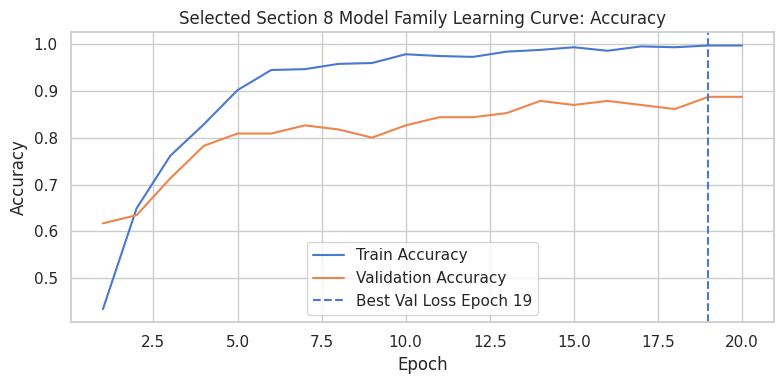

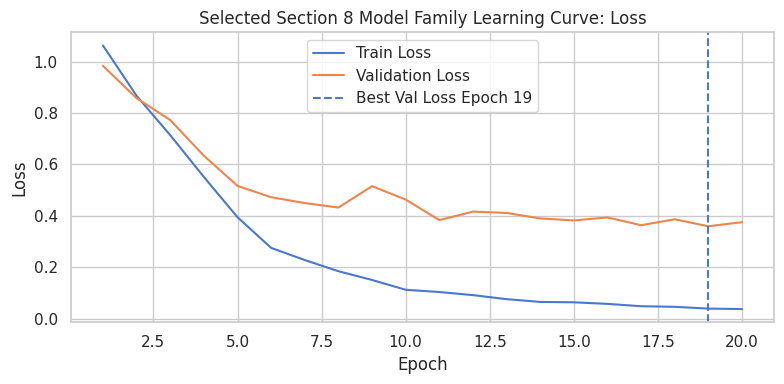

In [174]:
# Plot learning curves for selected Section 8 model family

section8_selected_history = selected_model_family_output["history"].history
section8_selected_best_epoch = selected_model_family_result["best_epoch"]

epochs = range(1, len(section8_selected_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, section8_selected_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, section8_selected_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    section8_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section8_selected_best_epoch}"
)
plt.title("Selected Section 8 Model Family Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, section8_selected_history["loss"], label="Train Loss")
plt.plot(epochs, section8_selected_history["val_loss"], label="Validation Loss")
plt.axvline(
    section8_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section8_selected_best_epoch}"
)
plt.title("Selected Section 8 Model Family Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

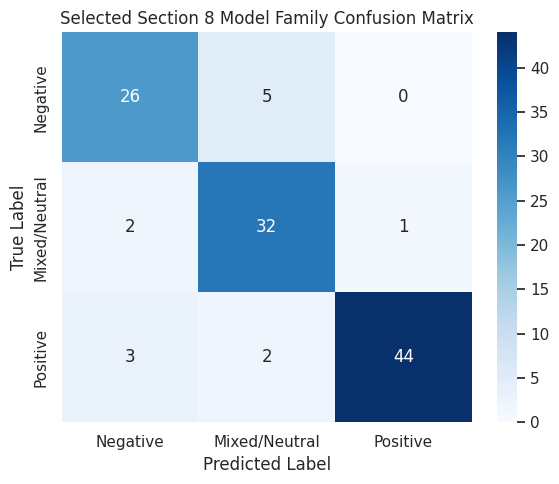

Classification report for selected Section 8 model family:
               precision    recall  f1-score   support

     Negative       0.84      0.84      0.84        31
Mixed/Neutral       0.82      0.91      0.86        35
     Positive       0.98      0.90      0.94        49

     accuracy                           0.89       115
    macro avg       0.88      0.88      0.88       115
 weighted avg       0.89      0.89      0.89       115



In [173]:
# Confusion matrix for selected Section 8 model family

section8_selected_cm = confusion_matrix(
    section6_y_val,
    selected_model_family_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    section8_selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Selected Section 8 Model Family Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected Section 8 model family:")
print(
    classification_report(
        section6_y_val,
        selected_model_family_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 8 Final Interpretation**

Section 8 compared five RNN model families using the locked Strategy B language-token representation from Section 6. All models used the same selected tokenizer, padded train/validation arrays, vocabulary size, sequence length, embedding dimension, optimiser, batch size, and epoch budget. This keeps the comparison focused on model family choice only.

SimpleRNN(32) is selected as the model family for Section 9. It achieved the strongest overall validation performance, with 0.8799 validation macro F1, 0.8870 validation accuracy, and the lowest validation loss of 0.3598. It also had the smallest train-validation macro F1 gap of 0.1182, suggesting better generalisation than the LSTM, GRU, and stacked variants in this controlled comparison.

The LSTM and GRU models performed reasonably well, but neither improved over SimpleRNN overall. GRU achieved the highest Malay macro F1 at 0.9108, but its English macro F1 was weaker and its overall validation macro F1 was lower than SimpleRNN. Since the model-family decision prioritises overall validation macro F1 and validation loss, GRU is not selected.

The deeper models, Stacked LSTM(32, 32) and LSTM + GRU(32, 32), did not improve validation performance. Their lower validation macro F1 and higher validation loss suggest that added recurrent depth increased complexity without producing useful gains for this small, short-review dataset.

The selected SimpleRNN learning curves show strong learning with some overfitting. Training accuracy rises close to 1.0, while validation accuracy improves more slowly and eventually plateaus. Training loss continues decreasing, while validation loss fluctuates after the model has learned the main patterns. This supports the use of `ModelCheckpoint` with validation loss, where the best checkpoint occurs at epoch 19.

The selected SimpleRNN result here is slightly different from the Section 6 Strategy B SimpleRNN result, even though both use the same language-token representation and same model type. Section 6 Strategy B achieved 0.8829 validation macro F1, while the Section 8 SimpleRNN rerun achieved 0.8799. This small difference is acceptable because neural network training can vary slightly across reruns due to random initialisation and nondeterministic training behaviour. The important point is that the result is consistent: SimpleRNN with the language-token representation remains strong.

Overall, SimpleRNN(32) is the best model family to carry forward. It is simple, performs best on the main validation criteria, generalises better than the more complex alternatives, and provides a strong controlled baseline for Section 9 model improvement.

## 9. Controlled Model Improvement

Section 9 improves the selected SimpleRNN model family from Section 8 using controlled validation-set experiments.

The selected setup entering this section is:

- Language strategy: bilingual text with language token
- Tokenizer: selected Strategy B tokenizer fitted on training text only
- Model family: SimpleRNN
- Primary metric: validation macro F1
- Checkpoint rule: reload best validation-loss weights before evaluation

The test set remains untouched throughout Section 9.

### 9.1 Setup and Decision Rule

This subsection defines the Section 9 experiment setup and selection rule.

Each experiment changes one main factor at a time while keeping the selected language-token representation and SimpleRNN model family fixed.

The decision rule is:

1. Prioritise validation macro F1.
2. Use validation loss as the main secondary check.
3. Check validation accuracy and weighted F1.
4. Inspect class-level F1, especially Negative and Mixed/Neutral.
5. Check English and Malay macro F1.
6. Check train-validation macro F1 gap for overfitting.
7. Prefer the simpler setting when differences are small.

A more complex setting should not be selected for a tiny validation improvement alone because the validation set is small.

In [176]:
# Section 9 setup

SECTION9_CHECKPOINT_DIR = "checkpoints/section9"
os.makedirs(SECTION9_CHECKPOINT_DIR, exist_ok=True)

SECTION9_DEFAULT_UNITS = 32
SECTION9_DEFAULT_DROPOUT = 0.3
SECTION9_DEFAULT_BATCH_SIZE = 32
SECTION9_DEFAULT_EPOCHS = 20
SECTION9_DEFAULT_LEARNING_RATE = 0.001

section9_experiment_results = []
section9_experiment_outputs = {}

required_section9_objects = [
    "selected_X_train",
    "selected_X_val",
    "selected_tokenizer",
    "section6_y_train",
    "section6_y_val",
    "section6_val_language",
    "selected_language_strategy_name",
    "selected_model_family_name",
    "VOCAB_SIZE",
    "MAX_SEQUENCE_LENGTH",
    "EMBEDDING_DIM",
    "SEED"
]

missing_section9_objects = [
    name for name in required_section9_objects
    if name not in globals()
]

if missing_section9_objects:
    raise NameError(f"Missing required Section 9 objects: {missing_section9_objects}")

print("Section 9 setup complete.")
print(f"Selected language strategy: {selected_language_strategy_name}")
print(f"Selected model family: {selected_model_family_name}")
print(f"Selected X_train shape: {selected_X_train.shape}")
print(f"Selected X_val shape: {selected_X_val.shape}")
print(f"Checkpoint folder: {SECTION9_CHECKPOINT_DIR}")

Section 9 setup complete.
Selected language strategy: B. Bilingual text with language token
Selected model family: SimpleRNN(32)
Selected X_train shape: (536, 25)
Selected X_val shape: (115, 25)
Checkpoint folder: checkpoints/section9


In [177]:
# Section 9 helper functions

# Build the selected SimpleRNN model family with adjustable core settings.
# More specialised changes will be added only when needed in later subsections.
def build_section9_simple_rnn_model(
    units=SECTION9_DEFAULT_UNITS,
    dropout=SECTION9_DEFAULT_DROPOUT,
    learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
    vocab_size=VOCAB_SIZE,
    max_length=MAX_SEQUENCE_LENGTH,
    embedding_dim=EMBEDDING_DIM
):
    model = Sequential([
        Input(shape=(max_length,)),
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True
        ),
        SimpleRNN(units),
        Dropout(dropout),
        Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Train and evaluate one Section 9 SimpleRNN experiment.
# Metrics are computed after reloading best validation-loss checkpoint weights.
def run_section9_experiment(
    experiment_group,
    experiment_name,
    hypothesis,
    controlled_change,
    fixed_settings,
    X_train_data,
    y_train_data,
    X_val_data,
    y_val_data,
    max_epochs=SECTION9_DEFAULT_EPOCHS,
    batch_size=SECTION9_DEFAULT_BATCH_SIZE,
    units=SECTION9_DEFAULT_UNITS,
    dropout=SECTION9_DEFAULT_DROPOUT,
    learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
    checkpoint_suffix=None
):
    tf.random.set_seed(SEED)

    if checkpoint_suffix is None:
        checkpoint_suffix = experiment_name.lower().replace(" ", "_").replace("/", "_")

    checkpoint_path = os.path.join(
        SECTION9_CHECKPOINT_DIR,
        f"{checkpoint_suffix}_best.weights.h5"
    )

    model = build_section9_simple_rnn_model(
        units=units,
        dropout=dropout,
        learning_rate=learning_rate,
        max_length=X_train_data.shape[1]
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    history = model.fit(
        X_train_data,
        y_train_data,
        validation_data=(X_val_data, y_val_data),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        X_train_data,
        y_train_data,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        X_val_data,
        y_val_data,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(X_train_data, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(X_val_data, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        y_train_data,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=y_val_data,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "experiment_group": experiment_group,
        "experiment_name": experiment_name,
        "hypothesis": hypothesis,
        "controlled_change": controlled_change,
        "fixed_settings": fixed_settings,
        "max_epochs": max_epochs,
        "batch_size": batch_size,
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

### 9.2 Epoch Number Comparison

This experiment checks whether the selected SimpleRNN model benefits from being trained for more epochs.

The controlled change is the maximum number of epochs:

1. 20 epochs
2. 30 epochs
3. 40 epochs

All other settings are fixed:

- Language-token representation
- Strategy B tokenizer
- SimpleRNN(32)
- Dropout 0.3
- Batch size 32
- Adam learning rate 0.001
- Validation-loss checkpointing

The purpose is not to use the final epoch blindly. Each model is trained up to the specified epoch number, then the best validation-loss checkpoint is reloaded before evaluation.

In [180]:
# Remove old Section 9.2 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Epoch Number"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("epoch_number__"):
        del section9_experiment_outputs[key]

epoch_number_configs = [
    (20, "20 epochs"),
    (30, "30 epochs"),
    (40, "40 epochs")
]

for max_epochs, experiment_name in epoch_number_configs:
    output_key = f"epoch_number__{max_epochs}_epochs"

    print("=" * 80)
    print(f"Training Section 9.2 experiment: {experiment_name}")
    print("=" * 80)

    output = run_section9_experiment(
        experiment_group="Epoch Number",
        experiment_name=experiment_name,
        hypothesis=(
            "More epochs may improve validation performance if the model needs "
            "more training time to learn useful sequential patterns."
        ),
        controlled_change=f"Maximum training epochs set to {max_epochs}",
        fixed_settings=(
            "Language-token input, Strategy B tokenizer, SimpleRNN(32), "
            "dropout 0.3, batch size 32, Adam learning rate 0.001"
        ),
        X_train_data=selected_X_train,
        y_train_data=section6_y_train,
        X_val_data=selected_X_val,
        y_val_data=section6_y_val,
        max_epochs=max_epochs,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        units=SECTION9_DEFAULT_UNITS,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.2 experiment: 20 epochs
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.4160 - loss: 1.0514 - val_accuracy: 0.4609 - val_loss: 0.9528
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6063 - loss: 0.8774 - val_accuracy: 0.7391 - val_loss: 0.8303
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8060 - loss: 0.6846 - val_accuracy: 0.7391 - val_loss: 0.7016
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8209 - loss: 0.5359 - val_accuracy: 0.7826 - val_loss: 0.5994
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8731 - loss: 0.4488 - val_accuracy: 0.7826 - val_loss: 0.5171
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9030 - loss: 0.3606 - val_accuracy: 0.8000 - val_loss: 0.4903
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9310 - loss: 0.2764 - val_accuracy: 0.8087 - val_loss: 0.4644
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.96

In [181]:
# Display Section 9.2 epoch number comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_epoch_results = section9_results_df[
    section9_results_df["experiment_group"] == "Epoch Number"
].copy()

section9_epoch_columns = [
    "experiment_name",
    "max_epochs",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_epoch_results[section9_epoch_columns].round(4))

,experiment_name,max_epochs,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,20 epochs,20,20,0.4561,0.8348,0.8306,0.1650,0.8375,0.8438,0.7568,0.8913,0.8757,0.7604
1,30 epochs,30,12,0.4433,0.8261,0.8188,0.1653,0.8269,0.7812,0.8000,0.8750,0.8374,0.7997
2,40 epochs,40,8,0.5354,0.7913,0.7805,0.1697,0.7931,0.7812,0.6761,0.8842,0.7926,0.7604


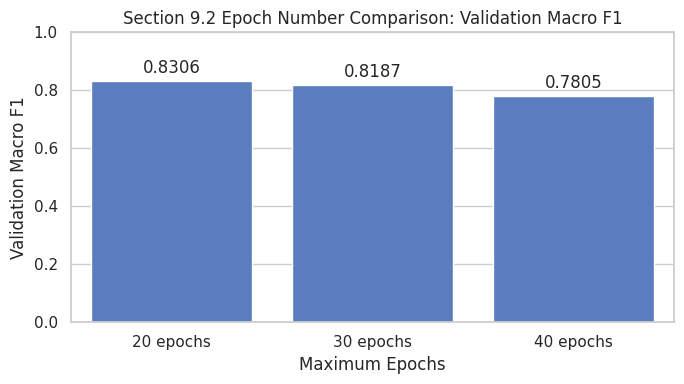

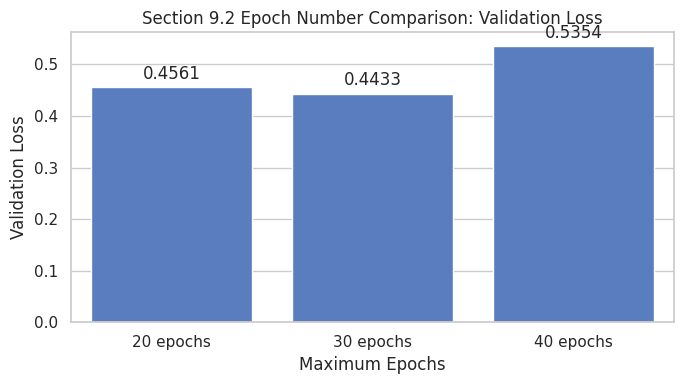

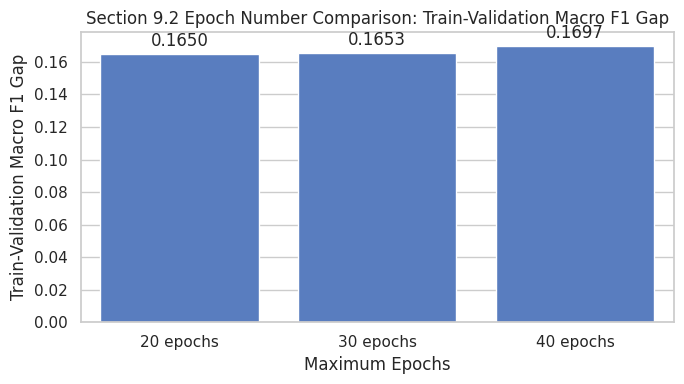

In [182]:
# Plot Section 9.2 epoch number comparison

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_epoch_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.2 Epoch Number Comparison: Validation Macro F1")
plt.xlabel("Maximum Epochs")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_epoch_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.2 Epoch Number Comparison: Validation Loss")
plt.xlabel("Maximum Epochs")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_epoch_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.2 Epoch Number Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Maximum Epochs")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.tight_layout()
plt.show()

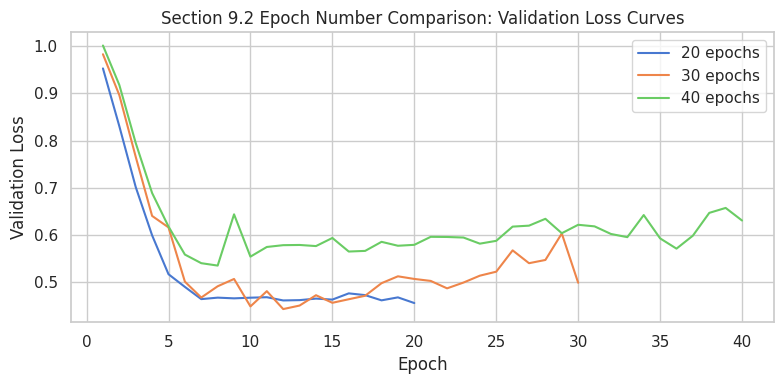

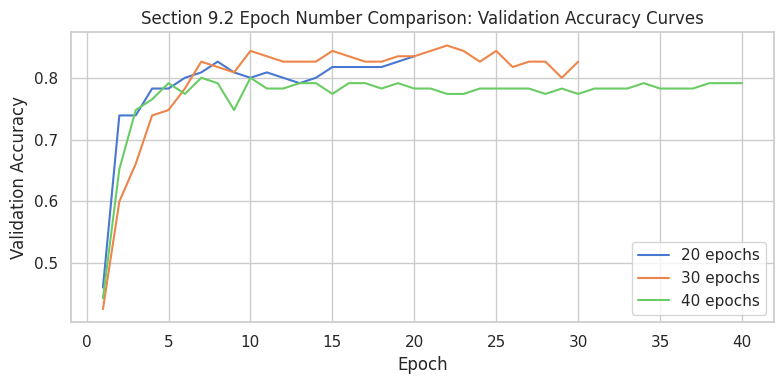

In [183]:
# Section 9.2: validation learning curves by epoch number

epoch_number_output_keys = [
    ("epoch_number__20_epochs", "20 epochs"),
    ("epoch_number__30_epochs", "30 epochs"),
    ("epoch_number__40_epochs", "40 epochs")
]

plt.figure(figsize=(8, 4))

for output_key, label in epoch_number_output_keys:
    history = section9_experiment_outputs[output_key]["history"].history
    epochs = range(1, len(history["val_loss"]) + 1)

    plt.plot(
        epochs,
        history["val_loss"],
        label=label
    )

plt.title("Section 9.2 Epoch Number Comparison: Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))

for output_key, label in epoch_number_output_keys:
    history = section9_experiment_outputs[output_key]["history"].history
    epochs = range(1, len(history["val_accuracy"]) + 1)

    plt.plot(
        epochs,
        history["val_accuracy"],
        label=label
    )

plt.title("Section 9.2 Epoch Number Comparison: Validation Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

**Section 9.2 Epoch Number Comparison Interpretation**

The epoch number comparison does not show a reliable benefit from training the selected SimpleRNN for more than 20 epochs.

The 20-epoch setting achieved the highest validation macro F1 at 0.8306. The 30-epoch setting achieved a slightly lower validation macro F1 of 0.8188, although it had the lowest validation loss at 0.4433. The 40-epoch setting performed worst, with validation macro F1 dropping to 0.7805 and validation loss increasing to 0.5354.

The learning curves support this decision. The validation loss curves show that all three settings improve early, but the longer runs do not continue improving reliably after the early epochs. The 30-epoch run fluctuates after its best point, while the 40-epoch run has noticeably higher validation loss and weaker validation accuracy stability. This suggests that simply allowing more epochs increases overfitting risk rather than improving generalisation.

The 20-epoch result in this subsection is lower than the selected Section 8 SimpleRNN result, even though both use the same language-token representation and SimpleRNN model family. This is because Section 9.2 retrains the model from scratch for each epoch setting instead of reusing the exact saved Section 8 checkpoint. With a small dataset and only 115 validation samples, small run-to-run training differences can noticeably affect validation macro F1.

Overall, increasing the maximum epoch number does not provide a clear validation improvement. The default maximum epoch number remains 20 because it gives the best validation macro F1 in this comparison, avoids unnecessary extra training, and reduces the risk of overfitting.

### 9.3 Engineered Training Data: Sentence Fragment Augmentation

Section 3.8 investigated whether pizza reviews could be split into shorter sentence or clause fragments. That investigation showed that some reviews contain multiple sentiment-bearing parts, especially when punctuation or contrast words such as `but`, `however`, or `tetapi` are present.

This subsection turns that earlier EDA idea into a controlled training-data engineering experiment.

The controlled change is the training data used:

1. Original training reviews only
2. Sentence fragments only
3. Original training reviews plus sentence fragments

Only the training set is modified. The validation set remains as the original full reviews so that validation performance is still measured on realistic review-level inputs.

The selected Strategy B tokenizer is reused and not refitted. This prevents the engineered data from changing the vocabulary-building process and keeps the comparison focused on whether the extra engineered training examples help the selected SimpleRNN model.

In [184]:
# This applies the sentence/clause splitting approach investigated earlier in Section 3.8.
# Only training reviews are split. Validation reviews remain unchanged.

fragment_rows = []

for row_position, text in enumerate(section6_train_text):
    fragments = split_review_into_fragments(text)

    # Keep only reviews that actually split into multiple fragments.
    # This prevents unsplittable reviews from being duplicated as "fragments".
    if len(fragments) < 2:
        continue

    for fragment in fragments:
        fragment_rows.append({
            "source_row_position": row_position,
            "language": section6_train_language[row_position],
            "original_text": text,
            "fragment_text": fragment,
            "label": section6_y_train[row_position]
        })

section9_fragment_df = pd.DataFrame(fragment_rows)

if section9_fragment_df.empty:
    raise ValueError("No sentence fragments were generated from the training set.")

section9_fragment_df["label_name"] = section9_fragment_df["label"].map({
    0: "Negative",
    1: "Mixed/Neutral",
    2: "Positive"
})

section9_fragment_df["fragment_text_with_language_token"] = add_language_token(
    section9_fragment_df["fragment_text"].to_numpy(),
    section9_fragment_df["language"].to_numpy()
)

print(f"Original training reviews: {len(section6_train_text)}")
print(f"Generated sentence fragments: {len(section9_fragment_df)}")
print(f"Unique source reviews used for fragments: {section9_fragment_df['source_row_position'].nunique()}")
print(f"Validation reviews changed: No")

display(
    section9_fragment_df
    .groupby(["language", "label_name"])
    .size()
    .reset_index(name="fragment_count")
)

display(section9_fragment_df.head())

Original training reviews: 536
Generated sentence fragments: 238
Unique source reviews used for fragments: 96
Validation reviews changed: No


,language,label_name,fragment_count
0,English,Mixed/Neutral,67
1,English,Negative,12
2,English,Positive,56
3,Malay,Mixed/Neutral,60
4,Malay,Positive,43


,source_row_position,language,original_text,fragment_text,label,label_name,fragment_text_with_language_token
0,1,Malay,Hebat dan sedap. Roti garing dan topping kaya ...,Hebat dan sedap,2,Positive,lang_malay Hebat dan sedap
1,1,Malay,Hebat dan sedap. Roti garing dan topping kaya ...,Roti garing dan topping kaya rasa,2,Positive,lang_malay Roti garing dan topping kaya rasa
2,1,Malay,Hebat dan sedap. Roti garing dan topping kaya ...,Saya sangat puas hati,2,Positive,lang_malay Saya sangat puas hati
3,5,Malay,Pizza fusion ni tak terlalu sedap tapi tak pul...,Pizza fusion ni tak terlalu sedap tapi tak pul...,1,Mixed/Neutral,lang_malay Pizza fusion ni tak terlalu sedap t...
4,5,Malay,Pizza fusion ni tak terlalu sedap tapi tak pul...,Rasa sambal dan mayo agak sederhana,1,Mixed/Neutral,lang_malay Rasa sambal dan mayo agak sederhana


In [185]:
# The selected Strategy B tokenizer is reused and not refitted.

fragment_train_text = section9_fragment_df["fragment_text_with_language_token"].to_numpy()
fragment_y_train = section9_fragment_df["label"].to_numpy()

fragment_X_train = pad_sequences(
    selected_tokenizer.texts_to_sequences(fragment_train_text),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

combined_X_train = np.vstack([
    selected_X_train,
    fragment_X_train
])

combined_y_train = np.concatenate([
    section6_y_train,
    fragment_y_train
])

print("Training-data setting shapes:")
print(f"Original only X_train: {selected_X_train.shape}")
print(f"Fragments only X_train: {fragment_X_train.shape}")
print(f"Original + fragments X_train: {combined_X_train.shape}")
print(f"Validation X_val unchanged: {selected_X_val.shape}")

print("\nTraining label counts:")
display(pd.Series(section6_y_train).map({0: "Negative", 1: "Mixed/Neutral", 2: "Positive"}).value_counts())

print("\nFragment label counts:")
display(pd.Series(fragment_y_train).map({0: "Negative", 1: "Mixed/Neutral", 2: "Positive"}).value_counts())

print("\nCombined label counts:")
display(pd.Series(combined_y_train).map({0: "Negative", 1: "Mixed/Neutral", 2: "Positive"}).value_counts())

Training-data setting shapes:
Original only X_train: (536, 25)
Fragments only X_train: (238, 25)
Original + fragments X_train: (774, 25)
Validation X_val unchanged: (115, 25)

Training label counts:


,count
Positive,232
Mixed/Neutral,164
Negative,140



Fragment label counts:


,count
Mixed/Neutral,127
Positive,99
Negative,12



Combined label counts:


,count
Positive,331
Mixed/Neutral,291
Negative,152


In [186]:
# Remove old Section 9.3 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Engineered Training Data"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("engineered_data__"):
        del section9_experiment_outputs[key]

engineered_data_configs = [
    (
        "original_only",
        "Original reviews only",
        selected_X_train,
        section6_y_train,
        "Original training reviews only"
    ),
    (
        "fragments_only",
        "Sentence fragments only",
        fragment_X_train,
        fragment_y_train,
        "Only sentence/clause fragments generated from training reviews"
    ),
    (
        "original_plus_fragments",
        "Original reviews + sentence fragments",
        combined_X_train,
        combined_y_train,
        "Original training reviews combined with generated sentence/clause fragments"
    )
]

for setting_key, experiment_name, X_train_setting, y_train_setting, controlled_change in engineered_data_configs:
    output_key = f"engineered_data__{setting_key}"

    print("=" * 80)
    print(f"Training Section 9.3 experiment: {experiment_name}")
    print("=" * 80)

    output = run_section9_experiment(
        experiment_group="Engineered Training Data",
        experiment_name=experiment_name,
        hypothesis=(
            "Sentence/clause fragments may help the model learn shorter sentiment-bearing "
            "patterns from the original training reviews."
        ),
        controlled_change=controlled_change,
        fixed_settings=(
            "Language-token input, Strategy B tokenizer reused without refitting, "
            "SimpleRNN(32), dropout 0.3, batch size 32, 20 epochs, Adam learning rate 0.001"
        ),
        X_train_data=X_train_setting,
        y_train_data=y_train_setting,
        X_val_data=selected_X_val,
        y_val_data=section6_y_val,
        max_epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        units=SECTION9_DEFAULT_UNITS,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.3 experiment: Original reviews only
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 664ms/step - accuracy: 0.4571 - loss: 1.0598 - val_accuracy: 0.5652 - val_loss: 0.9739
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.6250 - loss: 0.8706 - val_accuracy: 0.6609 - val_loss: 0.8382
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7425 - loss: 0.7024 - val_accuracy: 0.7130 - val_loss: 0.7174
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8004 - loss: 0.5562 - val_accuracy: 0.7739 - val_loss: 0.6231
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8470 - loss: 0.4272 - val_accuracy: 0.8435 - val_loss: 0.5613
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8825 - loss: 0.3652 - val_accuracy: 0.8348 - val_loss: 0.5457
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9235 - loss: 0.3069 - val_accuracy: 0.8348 - val_loss: 0.5247
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - a

In [187]:
# Display Section 9.3 engineered training-data comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_engineered_data_results = section9_results_df[
    section9_results_df["experiment_group"] == "Engineered Training Data"
].copy()

section9_engineered_data_columns = [
    "experiment_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_engineered_data_results[section9_engineered_data_columns].round(4))

,experiment_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
3,Original reviews only,20,0.3749,0.8696,0.8626,0.1330,0.8712,0.8364,0.8250,0.9263,0.8580,0.8660
4,Sentence fragments only,1,1.1048,0.3217,0.2475,0.2193,0.2657,0.0000,0.4158,0.3265,0.2475,0.2474
5,Original reviews + sentence fragments,6,0.5032,0.7826,0.7539,0.2114,0.7773,0.6122,0.7442,0.9053,0.7253,0.7859


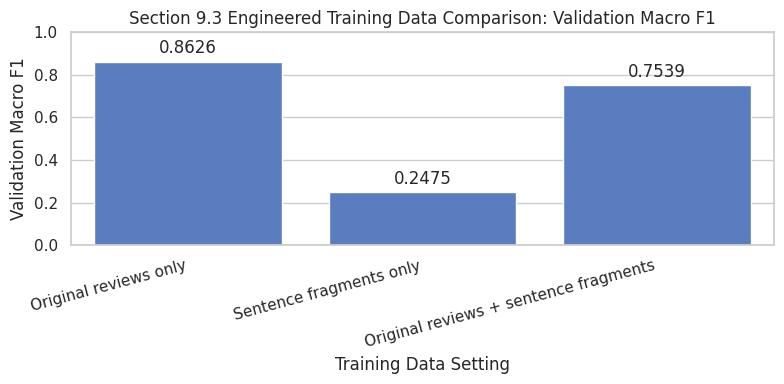

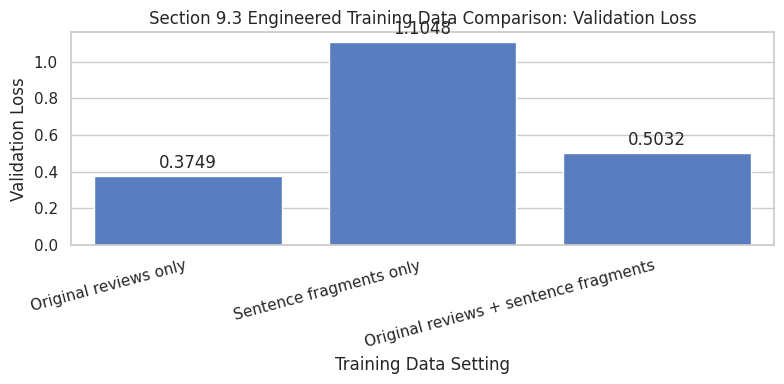

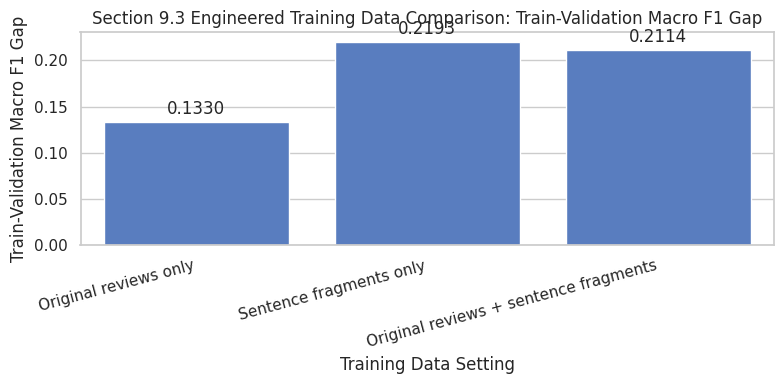

In [188]:
# Plot Section 9.3 engineered training-data comparison

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=section9_engineered_data_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.3 Engineered Training Data Comparison: Validation Macro F1")
plt.xlabel("Training Data Setting")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=section9_engineered_data_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.3 Engineered Training Data Comparison: Validation Loss")
plt.xlabel("Training Data Setting")
plt.ylabel("Validation Loss")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=section9_engineered_data_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.3 Engineered Training Data Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Training Data Setting")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [189]:
# additional check: create class-balanced sentence-fragment training data
# This uses the fragments already generated from training reviews only.
# The selected Strategy B tokenizer is reused and not refitted.

fragment_class_counts = section9_fragment_df["label"].value_counts().sort_index()
min_fragment_class_count = fragment_class_counts.min()

print("Original fragment class counts:")
display(
    fragment_class_counts
    .rename(index={0: "Negative", 1: "Mixed/Neutral", 2: "Positive"})
    .to_frame(name="fragment_count")
)

print(f"Balanced fragment count per class: {min_fragment_class_count}")

section9_balanced_fragment_df = (
    section9_fragment_df
    .groupby("label", group_keys=False)
    .apply(lambda group: group.sample(n=min_fragment_class_count, random_state=SEED))
    .reset_index(drop=True)
)

section9_balanced_fragment_df = section9_balanced_fragment_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("\nBalanced fragment class counts:")
display(
    section9_balanced_fragment_df["label_name"]
    .value_counts()
    .to_frame(name="balanced_fragment_count")
)

display(section9_balanced_fragment_df.head())

Original fragment class counts:


,fragment_count
label,
Negative,12
Mixed/Neutral,127
Positive,99


Balanced fragment count per class: 12

Balanced fragment class counts:


/tmp/ipykernel_1688/2377729399.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_fragment_class_count, random_state=SEED))


,balanced_fragment_count
label_name,
Negative,12
Mixed/Neutral,12
Positive,12


,source_row_position,language,original_text,fragment_text,label,label_name,fragment_text_with_language_token
0,40,English,"The crust was perfect—thin, blistered, slightl...","Then came the sambal: fiery, unapologetic, and...",0,Negative,"lang_english Then came the sambal: fiery, unap..."
1,380,English,Super creative! Sambal slice was fiery and bol...,Mayo one felt unnecessary,1,Mixed/Neutral,lang_english Mayo one felt unnecessary
2,413,Malay,Sedap! Fusion pizza yang sangat memuaskan. Top...,Topping segar dan perisa mantap,2,Positive,lang_malay Topping segar dan perisa mantap
3,266,Malay,Pizza fusion ini ok tapi tiada apa yang menari...,Pizza fusion ini ok tapi tiada apa yang menarik,1,Mixed/Neutral,lang_malay Pizza fusion ini ok tapi tiada apa ...
4,188,English,An absolute flavor bomb! The satay topping was...,An absolute flavor bomb,2,Positive,lang_english An absolute flavor bomb


In [190]:
# Section 9.3: prepare balanced fragment training arrays
# Reuse selected_tokenizer only. Do not refit.

balanced_fragment_train_text = section9_balanced_fragment_df[
    "fragment_text_with_language_token"
].to_numpy()

balanced_fragment_y_train = section9_balanced_fragment_df["label"].to_numpy()

balanced_fragment_X_train = pad_sequences(
    selected_tokenizer.texts_to_sequences(balanced_fragment_train_text),
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

combined_balanced_X_train = np.vstack([
    selected_X_train,
    balanced_fragment_X_train
])

combined_balanced_y_train = np.concatenate([
    section6_y_train,
    balanced_fragment_y_train
])

print("Balanced fragment setting shapes:")
print(f"Balanced fragments only X_train: {balanced_fragment_X_train.shape}")
print(f"Original + balanced fragments X_train: {combined_balanced_X_train.shape}")
print(f"Validation X_val unchanged: {selected_X_val.shape}")

print("\nBalanced fragment label counts:")
display(
    pd.Series(balanced_fragment_y_train)
    .map({0: "Negative", 1: "Mixed/Neutral", 2: "Positive"})
    .value_counts()
)

print("\nOriginal + balanced fragment label counts:")
display(
    pd.Series(combined_balanced_y_train)
    .map({0: "Negative", 1: "Mixed/Neutral", 2: "Positive"})
    .value_counts()
)

Balanced fragment setting shapes:
Balanced fragments only X_train: (36, 25)
Original + balanced fragments X_train: (572, 25)
Validation X_val unchanged: (115, 25)

Balanced fragment label counts:


,count
Negative,12
Mixed/Neutral,12
Positive,12



Original + balanced fragment label counts:


,count
Positive,244
Mixed/Neutral,176
Negative,152


In [191]:
# Section 9.3: train additional balanced fragment settings

balanced_experiment_names = [
    "Balanced sentence fragments only",
    "Original reviews + balanced sentence fragments"
]

# Remove old balanced-fragment results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_name") not in balanced_experiment_names
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("engineered_data_balanced__"):
        del section9_experiment_outputs[key]

balanced_engineered_data_configs = [
    (
        "balanced_fragments_only",
        "Balanced sentence fragments only",
        balanced_fragment_X_train,
        balanced_fragment_y_train,
        "Only class-balanced sentence/clause fragments generated from training reviews"
    ),
    (
        "original_plus_balanced_fragments",
        "Original reviews + balanced sentence fragments",
        combined_balanced_X_train,
        combined_balanced_y_train,
        "Original training reviews combined with class-balanced generated sentence/clause fragments"
    )
]

for setting_key, experiment_name, X_train_setting, y_train_setting, controlled_change in balanced_engineered_data_configs:
    output_key = f"engineered_data_balanced__{setting_key}"

    print("=" * 80)
    print(f"Training Section 9.3 additional experiment: {experiment_name}")
    print("=" * 80)

    output = run_section9_experiment(
        experiment_group="Engineered Training Data",
        experiment_name=experiment_name,
        hypothesis=(
            "Balancing generated fragments by sentiment class may reduce fragment-label "
            "imbalance and improve validation macro F1."
        ),
        controlled_change=controlled_change,
        fixed_settings=(
            "Language-token input, Strategy B tokenizer reused without refitting, "
            "SimpleRNN(32), dropout 0.3, batch size 32, 20 epochs, Adam learning rate 0.001"
        ),
        X_train_data=X_train_setting,
        y_train_data=y_train_setting,
        X_val_data=selected_X_val,
        y_val_data=section6_y_val,
        max_epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        units=SECTION9_DEFAULT_UNITS,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.3 additional experiment: Balanced sentence fragments only
Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step - accuracy: 0.5000 - loss: 1.0733 - val_accuracy: 0.3652 - val_loss: 1.0915
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.5278 - loss: 1.0640 - val_accuracy: 0.3391 - val_loss: 1.0984
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6389 - loss: 0.9936 - val_accuracy: 0.3391 - val_loss: 1.1074
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7778 - loss: 0.9560 - val_accuracy: 0.3391 - val_loss: 1.1188
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.7778 - loss: 0.9398 - val_accuracy: 0.2957 - val_loss: 1.1321
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.8333 - loss: 0.9288 - val_accuracy: 0.2870 - val_loss: 1.1463
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8056 - loss: 0.8926 - val_accuracy: 0.2957 - val_loss: 1.1584
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122m

In [192]:
# Display updated Section 9.3 engineered training-data comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_engineered_data_results = section9_results_df[
    section9_results_df["experiment_group"] == "Engineered Training Data"
].copy()

engineered_data_order = [
    "Original reviews only",
    "Sentence fragments only",
    "Original reviews + sentence fragments",
    "Balanced sentence fragments only",
    "Original reviews + balanced sentence fragments"
]

section9_engineered_data_results["experiment_name"] = pd.Categorical(
    section9_engineered_data_results["experiment_name"],
    categories=engineered_data_order,
    ordered=True
)

section9_engineered_data_results = section9_engineered_data_results.sort_values(
    "experiment_name"
)

section9_engineered_data_columns = [
    "experiment_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_engineered_data_results[section9_engineered_data_columns].round(4))

,experiment_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
3,Original reviews only,20,0.3749,0.8696,0.8626,0.1330,0.8712,0.8364,0.8250,0.9263,0.8580,0.8660
4,Sentence fragments only,1,1.1048,0.3217,0.2475,0.2193,0.2657,0.0000,0.4158,0.3265,0.2475,0.2474
5,Original reviews + sentence fragments,6,0.5032,0.7826,0.7539,0.2114,0.7773,0.6122,0.7442,0.9053,0.7253,0.7859
6,Balanced sentence fragments only,1,1.0915,0.3652,0.3578,0.2742,0.3489,0.4706,0.2857,0.3171,0.4064,0.2884
7,Original reviews + balanced sentence fragments,12,0.4401,0.8348,0.8203,0.1677,0.8364,0.7667,0.7568,0.9375,0.8056,0.8383


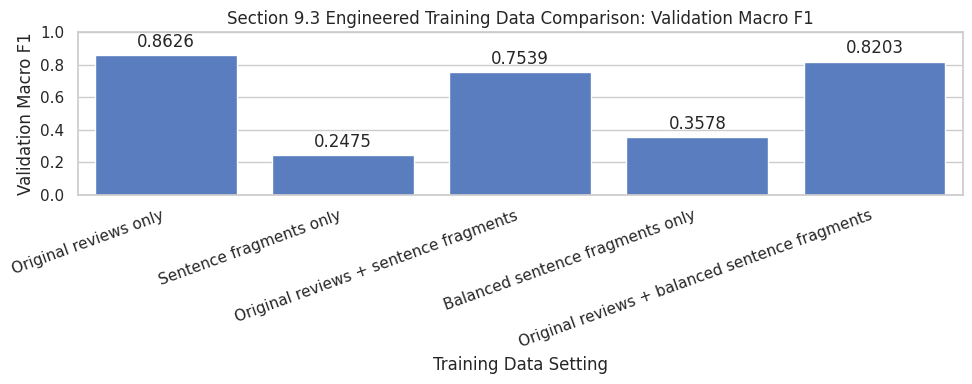

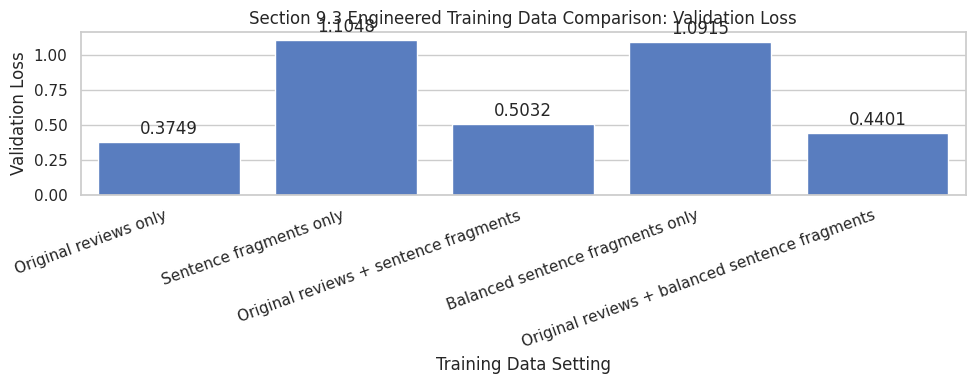

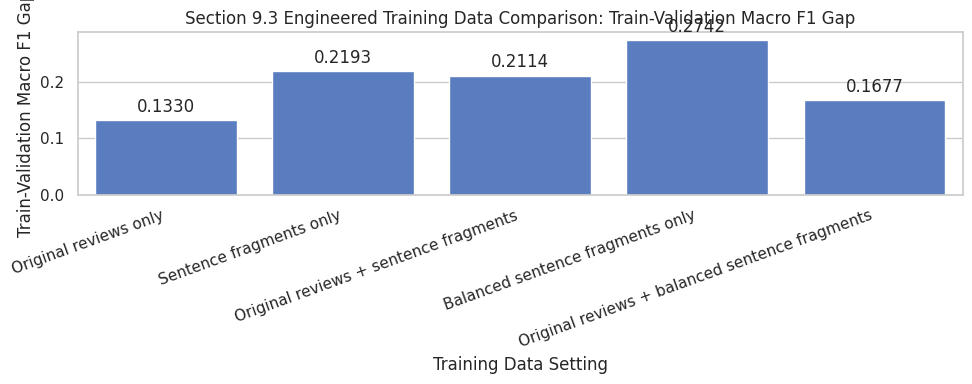

In [193]:
# Plot updated engineered training-data comparison

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_engineered_data_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.3 Engineered Training Data Comparison: Validation Macro F1")
plt.xlabel("Training Data Setting")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_engineered_data_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.3 Engineered Training Data Comparison: Validation Loss")
plt.xlabel("Training Data Setting")
plt.ylabel("Validation Loss")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_engineered_data_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.3 Engineered Training Data Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Training Data Setting")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

**Section 9.3 Engineered Training Data Interpretation**

Section 9.3 tested the sentence/clause splitting idea first investigated in Section 3.8. The aim was to check whether engineered sentence fragments could provide useful extra training data for the selected SimpleRNN model.

The engineered data was created only from the training set. Validation reviews were kept as full original reviews, and the selected Strategy B tokenizer was reused without refitting. This keeps the experiment leakage-safe and ensures that validation performance still reflects realistic review-level prediction.

The sentence fragment data was limited and imbalanced. From 536 original training reviews, only 238 fragments were generated from 96 source reviews. The fragment labels were also highly imbalanced, with only 12 Negative fragments compared with 127 Mixed/Neutral and 99 Positive fragments. This is a major limitation because the model may learn a distorted version of the original class distribution.

The original reviews only setting performed best, with validation macro F1 of 0.8626 and validation loss of 0.3749. Sentence fragments only performed very poorly, with validation macro F1 of 0.2475 and validation loss of 1.1048. This shows that fragments alone do not preserve enough review-level context for the classification task.

Adding all sentence fragments to the original reviews also reduced performance, with validation macro F1 falling to 0.7539. This suggests that the extra fragment examples introduced noise rather than useful generalisation. A likely reason is that each fragment inherits the full parent review label, even though individual fragments may not express the same sentiment as the full review.

The balanced fragment variants did not solve the issue. Balanced fragments only used just 36 examples, which is too small to train a useful model. Original reviews plus balanced fragments improved over the unbalanced combined setting, reaching validation macro F1 of 0.8203, but it still underperformed the original reviews only setting.

Overall, sentence-fragment augmentation is not selected for the final model. Although it addresses the project consideration of engineered training data, the validation evidence shows that this engineered data does not improve generalisation for this dataset. The final modelling path should continue using the original training reviews only.

### 9.4 Sequence Length Comparison

This experiment checks whether changing the padded sequence length improves the selected SimpleRNN model.

Section 5 showed that most reviews are short and only a few exceed 25 tokens. Shorter sequences may reduce padding and noise, while longer sequences may preserve more review context.

The controlled change is the maximum sequence length:

1. 15 tokens
2. 25 tokens
3. 40 tokens

All other settings are fixed:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- SimpleRNN(32)
- Dropout 0.3
- Batch size 32
- 20 epochs
- Adam learning rate 0.001
- Validation-loss checkpointing

The test set remains untouched.

In [202]:
# Reuse selected Strategy B tokenizer only. Do not refit.
# Coverage is reported on training reviews only to avoid using validation distribution for setup justification.

required_sequence_length_objects = [
    "selected_train_text",
    "selected_val_text",
    "selected_tokenizer"
]

missing_sequence_length_objects = [
    name for name in required_sequence_length_objects
    if name not in globals()
]

if missing_sequence_length_objects:
    raise NameError(f"Missing required objects for Section 9.4: {missing_sequence_length_objects}")

sequence_length_configs = [15, 25, 40]

selected_train_sequences_for_length = selected_tokenizer.texts_to_sequences(selected_train_text)
train_token_lengths = np.array([len(seq) for seq in selected_train_sequences_for_length])

sequence_length_coverage_rows = []

for max_length in sequence_length_configs:
    train_truncated_count = int((train_token_lengths > max_length).sum())

    sequence_length_coverage_rows.append({
        "max_sequence_length": max_length,
        "train_reviews_covered": int((train_token_lengths <= max_length).sum()),
        "train_reviews_truncated": train_truncated_count,
        "train_coverage_percent": (train_token_lengths <= max_length).mean() * 100
    })

section9_sequence_coverage_df = pd.DataFrame(sequence_length_coverage_rows)

display(section9_sequence_coverage_df.round(2))

,max_sequence_length,train_reviews_covered,train_reviews_truncated,train_coverage_percent
0,15,475,61,88.62
1,25,532,4,99.25
2,40,534,2,99.63


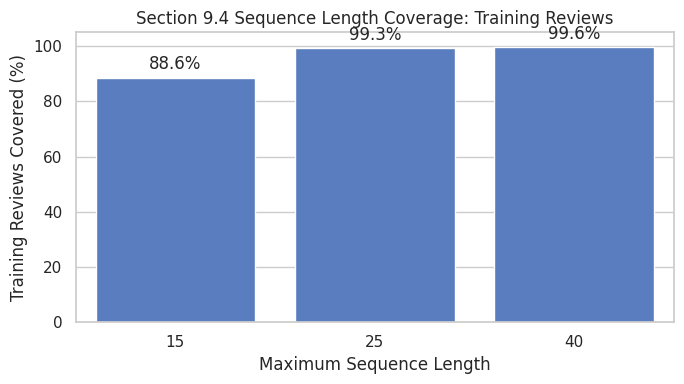

In [198]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_sequence_coverage_df,
    x="max_sequence_length",
    y="train_coverage_percent"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Section 9.4 Sequence Length Coverage: Training Reviews")
plt.xlabel("Maximum Sequence Length")
plt.ylabel("Training Reviews Covered (%)")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

In [199]:
# Remove old Section 9.4 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Sequence Length"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("sequence_length__"):
        del section9_experiment_outputs[key]

for max_length in sequence_length_configs:
    output_key = f"sequence_length__{max_length}"

    X_train_length = pad_sequences(
        selected_tokenizer.texts_to_sequences(selected_train_text),
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    X_val_length = pad_sequences(
        selected_tokenizer.texts_to_sequences(selected_val_text),
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    print("=" * 80)
    print(f"Training Section 9.4 experiment: sequence length {max_length}")
    print("=" * 80)

    output = run_section9_experiment(
        experiment_group="Sequence Length",
        experiment_name=f"Sequence length {max_length}",
        hypothesis=(
            "Shorter sequences may reduce padding and noise, while longer sequences "
            "may preserve more review context."
        ),
        controlled_change=f"Maximum sequence length set to {max_length}",
        fixed_settings=(
            "Original training reviews only, language-token input, Strategy B tokenizer reused "
            "without refitting, SimpleRNN(32), dropout 0.3, batch size 32, 20 epochs, "
            "Adam learning rate 0.001"
        ),
        X_train_data=X_train_length,
        y_train_data=section6_y_train,
        X_val_data=X_val_length,
        y_val_data=section6_y_val,
        max_epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        units=SECTION9_DEFAULT_UNITS,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.4 experiment: sequence length 15
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 13s 402ms/step - accuracy: 0.4160 - loss: 1.0729 - val_accuracy: 0.4696 - val_loss: 1.0115
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5690 - loss: 0.9246 - val_accuracy: 0.5826 - val_loss: 0.9119
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7519 - loss: 0.7565 - val_accuracy: 0.7130 - val_loss: 0.7700
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8507 - loss: 0.5471 - val_accuracy: 0.8000 - val_loss: 0.6356
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9104 - loss: 0.3765 - val_accuracy: 0.8261 - val_loss: 0.5412
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9366 - loss: 0.2788 - val_accuracy: 0.8609 - val_loss: 0.5130
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9515 - loss: 0.2277 - val_accuracy: 0.8435 - val_loss: 0.4889
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accur

In [200]:
section9_results_df = pd.DataFrame(section9_experiment_results)

section9_sequence_results = section9_results_df[
    section9_results_df["experiment_group"] == "Sequence Length"
].copy()

section9_sequence_columns = [
    "experiment_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_sequence_results[section9_sequence_columns].round(4))

,experiment_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
8,Sequence length 15,10,0.4597,0.8870,0.8843,0.1076,0.8881,0.8750,0.8649,0.9130,0.8882,0.8785
9,Sequence length 25,14,0.5019,0.8000,0.7843,0.2074,0.7960,0.7119,0.7812,0.8598,0.7891,0.7677
10,Sequence length 40,15,0.4200,0.8783,0.8702,0.1210,0.8785,0.8333,0.8493,0.9278,0.8403,0.9103


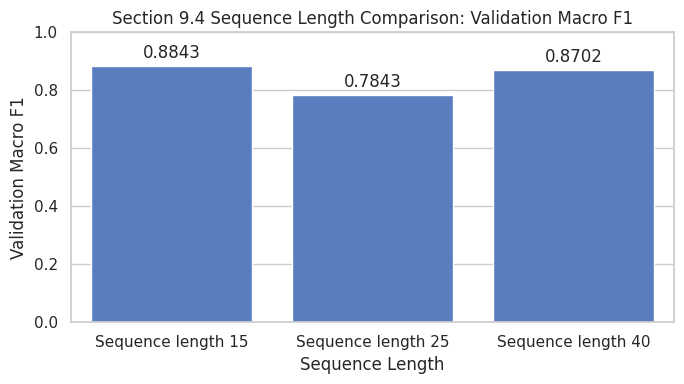

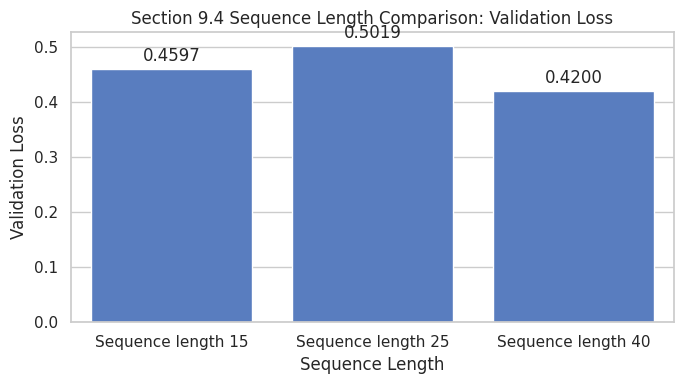

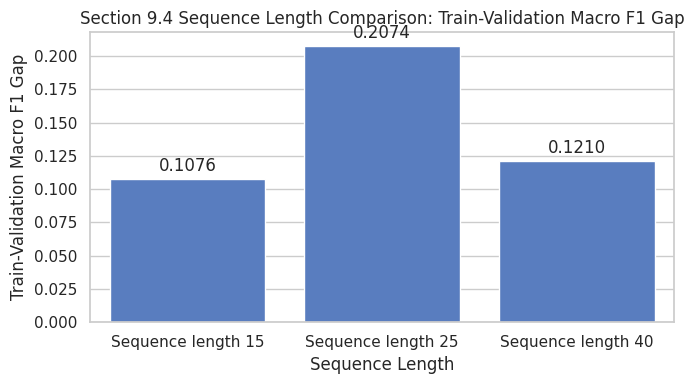

In [201]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_sequence_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.4 Sequence Length Comparison: Validation Macro F1")
plt.xlabel("Sequence Length")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_sequence_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.4 Sequence Length Comparison: Validation Loss")
plt.xlabel("Sequence Length")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_sequence_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.4 Sequence Length Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Sequence Length")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.tight_layout()
plt.show()

In [203]:
# Section 9.4: lock selected sequence length candidate

selected_sequence_length_key = "sequence_length__15"
selected_sequence_length = 15

selected_sequence_length_output = section9_experiment_outputs[selected_sequence_length_key]
selected_sequence_length_result = selected_sequence_length_output["result_row"]
selected_sequence_length_val_preds = selected_sequence_length_output["val_preds"]

print("Selected sequence length locked.")
print(f"Selected sequence length: {selected_sequence_length}")

display(
    pd.DataFrame([selected_sequence_length_result])[
        [
            "experiment_name",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected sequence length locked.
Selected sequence length: 15


,experiment_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,Sequence length 15,10,0.4597,0.887,0.8843,0.1076,0.8881,0.875,0.8649,0.913,0.8882,0.8785


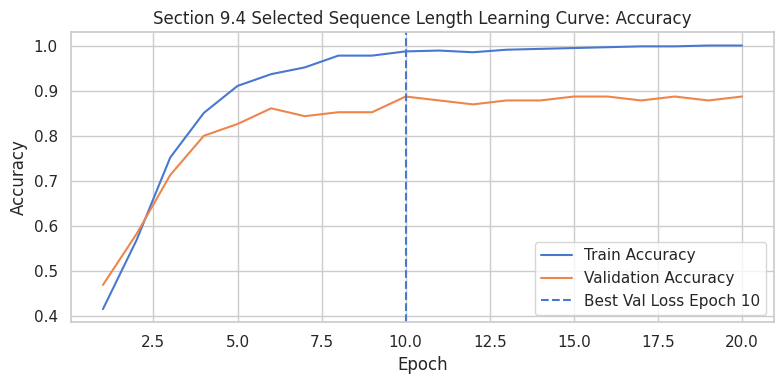

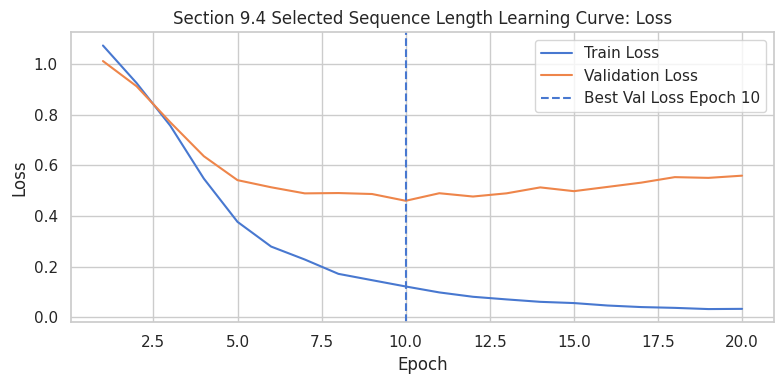

In [204]:
# Section 9.4: learning curves for selected sequence length

section9_sequence_selected_history = selected_sequence_length_output["history"].history
section9_sequence_selected_best_epoch = selected_sequence_length_result["best_epoch"]

epochs = range(1, len(section9_sequence_selected_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_sequence_selected_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, section9_sequence_selected_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    section9_sequence_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_sequence_selected_best_epoch}"
)
plt.title("Section 9.4 Selected Sequence Length Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_sequence_selected_history["loss"], label="Train Loss")
plt.plot(epochs, section9_sequence_selected_history["val_loss"], label="Validation Loss")
plt.axvline(
    section9_sequence_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_sequence_selected_best_epoch}"
)
plt.title("Section 9.4 Selected Sequence Length Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

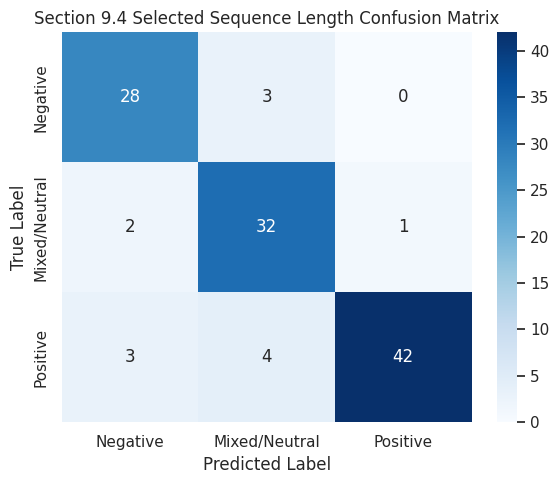

Classification report for selected sequence length:
               precision    recall  f1-score   support

     Negative       0.85      0.90      0.88        31
Mixed/Neutral       0.82      0.91      0.86        35
     Positive       0.98      0.86      0.91        49

     accuracy                           0.89       115
    macro avg       0.88      0.89      0.88       115
 weighted avg       0.89      0.89      0.89       115



In [205]:
# Section 9.4: confusion matrix for selected sequence length

section9_sequence_selected_cm = confusion_matrix(
    section6_y_val,
    selected_sequence_length_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    section9_sequence_selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 9.4 Selected Sequence Length Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected sequence length:")
print(
    classification_report(
        section6_y_val,
        selected_sequence_length_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 9.4 Sequence Length Comparison Interpretation**

The sequence length comparison shows that sequence length 15 is the strongest setting for the selected SimpleRNN model.

Sequence length 15 achieved the highest validation macro F1 of 0.8843 and the highest validation accuracy of 0.8870. It also had the smallest train-validation macro F1 gap of 0.1076, suggesting better generalisation than the longer sequence settings.

Sequence length 40 achieved the lowest validation loss of 0.4200 and the strongest Malay macro F1 of 0.9103. However, its overall validation macro F1 of 0.8702 was lower than sequence length 15. Since validation macro F1 is the primary model-selection metric, sequence length 40 is not selected.

Sequence length 25 performed weakest, with validation macro F1 of 0.7843 and the largest train-validation macro F1 gap of 0.2074. This suggests that the previous default sequence length was not the best fit for this SimpleRNN configuration.

The training coverage check showed that sequence length 15 still preserves most training reviews while using a shorter input. This supports the idea that many pizza reviews express their main sentiment early, and that a shorter sequence can reduce unnecessary padding or noisy later tokens.

The learning curves for sequence length 15 show strong early learning. Validation loss reaches its best point at epoch 10, while training loss continues decreasing afterwards. This indicates some overfitting after the best checkpoint and supports using `ModelCheckpoint` to reload the best validation-loss weights instead of using the final epoch.

The confusion matrix also supports the selection. The model correctly predicts 28 out of 31 Negative reviews, 32 out of 35 Mixed/Neutral reviews, and 42 out of 49 Positive reviews. The class-level F1 scores are balanced, with Negative F1 at 0.88, Mixed/Neutral F1 at 0.86, and Positive F1 at 0.91. This shows that the improvement is not coming from only one class.

Overall, sequence length 15 is selected for the next Section 9 experiments. It gives the best validation macro F1, strong class-level performance, the smallest generalisation gap, and a simpler shorter input representation.

### 9.5 Capacity Comparison

This experiment checks whether changing the number of SimpleRNN units improves validation performance.

The controlled change is model capacity:

1. 16 units
2. 32 units
3. 64 units
4. 128 units

All other settings are fixed:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- Sequence length 15
- SimpleRNN model family
- Dropout 0.3
- Batch size 32
- 20 epochs
- Adam learning rate 0.001
- Validation-loss checkpointing

A smaller model may reduce overfitting. A larger model may learn richer text patterns. Capacity should only increase if validation evidence supports it.

The test set remains untouched.

In [207]:
# prepare fixed sequence length 15 arrays
# Reuse selected Strategy B tokenizer only

SECTION9_SELECTED_SEQUENCE_LENGTH = 15

section9_selected_X_train = pad_sequences(
    selected_tokenizer.texts_to_sequences(selected_train_text),
    maxlen=SECTION9_SELECTED_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

section9_selected_X_val = pad_sequences(
    selected_tokenizer.texts_to_sequences(selected_val_text),
    maxlen=SECTION9_SELECTED_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Section 9.5 fixed input shapes:")
print(f"section9_selected_X_train: {section9_selected_X_train.shape}")
print(f"section9_selected_X_val: {section9_selected_X_val.shape}")

Section 9.5 fixed input shapes:
section9_selected_X_train: (536, 15)
section9_selected_X_val: (115, 15)


In [208]:
# parameter count by capacity

capacity_configs = [16, 32, 64, 128]

capacity_parameter_rows = []

for units in capacity_configs:
    temp_model = build_section9_simple_rnn_model(
        units=units,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
    )

    capacity_parameter_rows.append({
        "rnn_units": units,
        "parameter_count": temp_model.count_params()
    })

section9_capacity_params_df = pd.DataFrame(capacity_parameter_rows)

display(section9_capacity_params_df)

,rnn_units,parameter_count
0,16,32835
1,32,34179
2,64,38403
3,128,52995


In [209]:
# capacity comparison

# Remove old Section 9.5 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Capacity"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("capacity__"):
        del section9_experiment_outputs[key]

for units in capacity_configs:
    output_key = f"capacity__{units}_units"

    print("=" * 80)
    print(f"Training Section 9.5 experiment: SimpleRNN({units})")
    print("=" * 80)

    output = run_section9_experiment(
        experiment_group="Capacity",
        experiment_name=f"SimpleRNN({units})",
        hypothesis=(
            "A smaller model may reduce overfitting, while a larger model may "
            "learn richer text patterns if validation evidence supports it."
        ),
        controlled_change=f"SimpleRNN units set to {units}",
        fixed_settings=(
            "Original training reviews only, language-token input, Strategy B tokenizer reused "
            "without refitting, sequence length 15, dropout 0.3, batch size 32, "
            "20 epochs, Adam learning rate 0.001"
        ),
        X_train_data=section9_selected_X_train,
        y_train_data=section6_y_train,
        X_val_data=section9_selected_X_val,
        y_val_data=section6_y_val,
        max_epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        units=units,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        checkpoint_suffix=output_key
    )

    output["result_row"]["rnn_units"] = units
    output["result_row"]["parameter_count"] = output["model"].count_params()

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.5 experiment: SimpleRNN(16)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 366ms/step - accuracy: 0.4142 - loss: 1.0717 - val_accuracy: 0.5043 - val_loss: 1.0520
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6455 - loss: 0.9551 - val_accuracy: 0.5391 - val_loss: 0.9864
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7239 - loss: 0.8142 - val_accuracy: 0.5913 - val_loss: 0.9045
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7948 - loss: 0.6801 - val_accuracy: 0.6609 - val_loss: 0.8131
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8358 - loss: 0.5604 - val_accuracy: 0.7217 - val_loss: 0.7285
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8694 - loss: 0.4786 - val_accuracy: 0.7565 - val_loss: 0.6680
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9160 - loss: 0.4079 - val_accuracy: 0.7217 - val_loss: 0.6943
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy:

In [210]:
# Display capacity comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_capacity_results = section9_results_df[
    section9_results_df["experiment_group"] == "Capacity"
].copy()

section9_capacity_results = section9_capacity_results.sort_values("rnn_units")

section9_capacity_columns = [
    "experiment_name",
    "rnn_units",
    "parameter_count",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_capacity_results[section9_capacity_columns].round(4))

,experiment_name,rnn_units,parameter_count,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
11,SimpleRNN(16),16.0,32835.0,15,0.5786,0.8174,0.8103,0.1800,0.8179,0.7857,0.7792,0.8660,0.8009,0.8241
12,SimpleRNN(32),32.0,34179.0,8,0.4386,0.8174,0.8107,0.1520,0.8199,0.7937,0.7568,0.8817,0.8416,0.7724
13,SimpleRNN(64),64.0,38403.0,17,0.3389,0.8870,0.8795,0.1142,0.8878,0.8438,0.8571,0.9375,0.8708,0.8878
14,SimpleRNN(128),128.0,52995.0,6,0.4551,0.8696,0.8580,0.0973,0.8701,0.8254,0.8000,0.9485,0.8689,0.8385


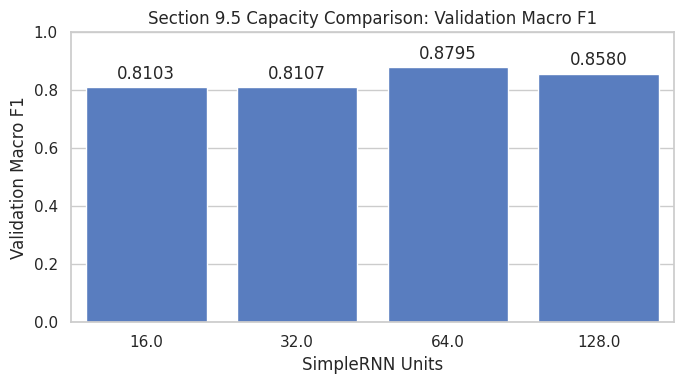

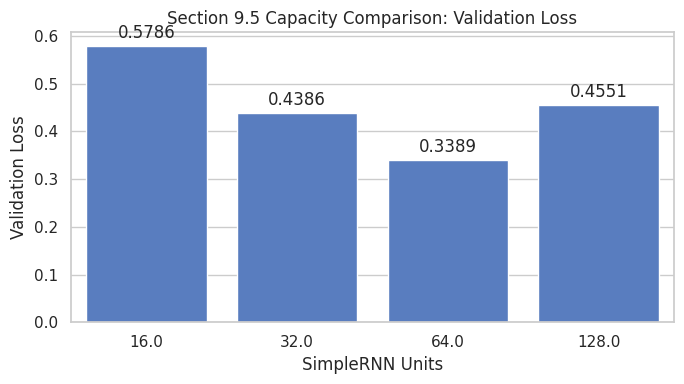

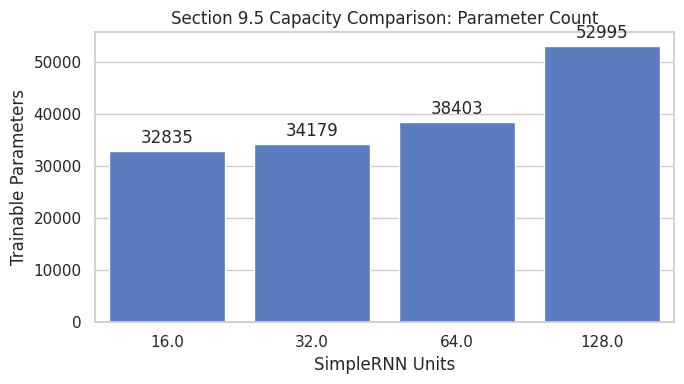

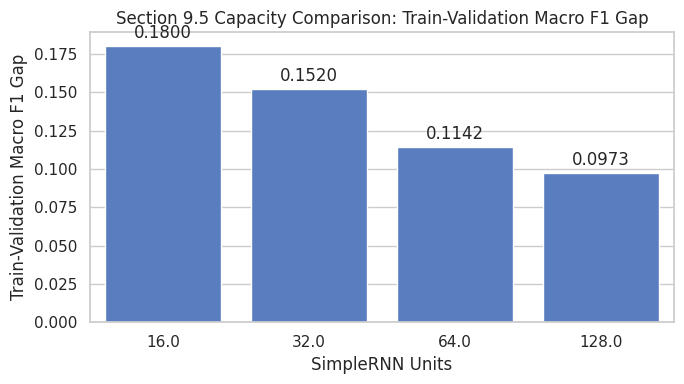

In [211]:
# Plot capacity comparison

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_capacity_results,
    x="rnn_units",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.5 Capacity Comparison: Validation Macro F1")
plt.xlabel("SimpleRNN Units")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_capacity_results,
    x="rnn_units",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.5 Capacity Comparison: Validation Loss")
plt.xlabel("SimpleRNN Units")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_capacity_results,
    x="rnn_units",
    y="parameter_count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Section 9.5 Capacity Comparison: Parameter Count")
plt.xlabel("SimpleRNN Units")
plt.ylabel("Trainable Parameters")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_capacity_results,
    x="rnn_units",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.5 Capacity Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("SimpleRNN Units")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.tight_layout()
plt.show()

In [212]:
# lock selected capacity

selected_capacity_key = "capacity__64_units"
selected_rnn_units = 64

selected_capacity_output = section9_experiment_outputs[selected_capacity_key]
selected_capacity_result = selected_capacity_output["result_row"]
selected_capacity_val_preds = selected_capacity_output["val_preds"]

print("Selected capacity locked.")
print(f"Selected SimpleRNN units: {selected_rnn_units}")

display(
    pd.DataFrame([selected_capacity_result])[
        [
            "experiment_name",
            "rnn_units",
            "parameter_count",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected capacity locked.
Selected SimpleRNN units: 64


,experiment_name,rnn_units,parameter_count,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,SimpleRNN(64),64,38403,17,0.3389,0.887,0.8795,0.1142,0.8878,0.8438,0.8571,0.9375,0.8708,0.8878


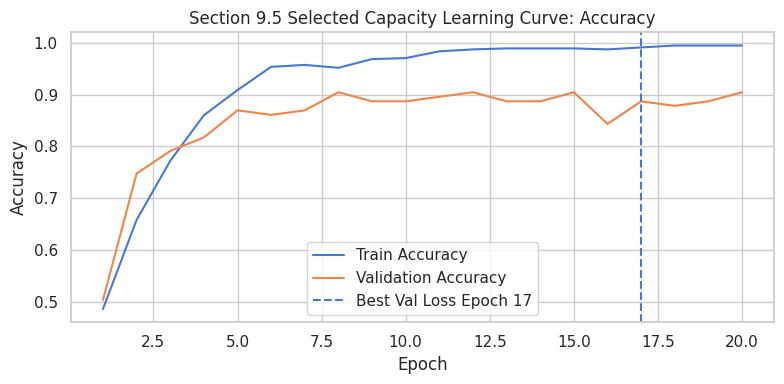

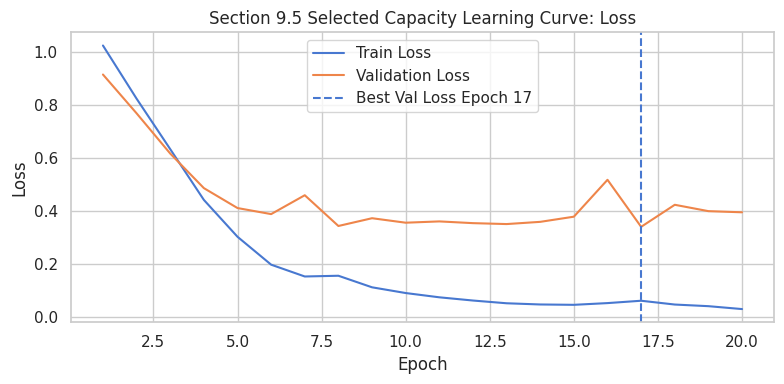

In [213]:
# learning curves for selected capacity

section9_capacity_selected_history = selected_capacity_output["history"].history
section9_capacity_selected_best_epoch = selected_capacity_result["best_epoch"]

epochs = range(1, len(section9_capacity_selected_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_capacity_selected_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, section9_capacity_selected_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    section9_capacity_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_capacity_selected_best_epoch}"
)
plt.title("Section 9.5 Selected Capacity Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_capacity_selected_history["loss"], label="Train Loss")
plt.plot(epochs, section9_capacity_selected_history["val_loss"], label="Validation Loss")
plt.axvline(
    section9_capacity_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_capacity_selected_best_epoch}"
)
plt.title("Section 9.5 Selected Capacity Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

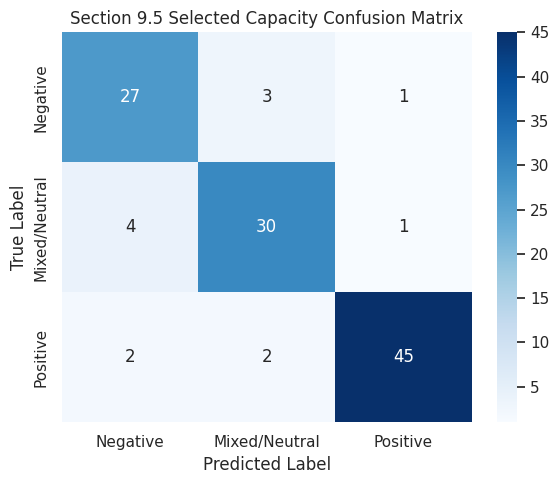

Classification report for selected capacity:
               precision    recall  f1-score   support

     Negative       0.82      0.87      0.84        31
Mixed/Neutral       0.86      0.86      0.86        35
     Positive       0.96      0.92      0.94        49

     accuracy                           0.89       115
    macro avg       0.88      0.88      0.88       115
 weighted avg       0.89      0.89      0.89       115



In [214]:
# confusion matrix for selected capacity

section9_capacity_selected_cm = confusion_matrix(
    section6_y_val,
    selected_capacity_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    section9_capacity_selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 9.5 Selected Capacity Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected capacity:")
print(
    classification_report(
        section6_y_val,
        selected_capacity_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 9.5 Capacity Comparison Interpretation**

The capacity comparison shows that SimpleRNN(64) is the strongest capacity setting for the selected model pipeline.

SimpleRNN(64) achieved the best overall validation performance, with the highest validation macro F1 of 0.8795, the lowest validation loss of 0.3389, and the joint-highest validation accuracy of 0.8870. It also improved class-level performance compared with the smaller 16-unit and 32-unit models.

The 16-unit and 32-unit models underperformed, with validation macro F1 scores of 0.8103 and 0.8107 respectively. This suggests that these smaller models did not have enough capacity to learn the sentiment patterns effectively, even though they used fewer parameters.

SimpleRNN(128) had the smallest train-validation macro F1 gap of 0.0973, but it did not achieve the best validation macro F1 or validation loss. It also used substantially more parameters than the 64-unit model. Since larger capacity should only be selected when validation evidence clearly supports it, SimpleRNN(128) is not selected.

The parameter count plot shows that increasing from 64 to 128 units increases the model size noticeably, from 38,403 to 52,995 parameters. However, this extra complexity did not improve the main validation metric. This supports selecting the simpler 64-unit model over the larger 128-unit model.

The learning curves for SimpleRNN(64) show strong learning with some overfitting after the best checkpoint. Training accuracy continues increasing, while validation accuracy fluctuates around a high level. Validation loss reaches its best point at epoch 17, which supports using the validation-loss checkpoint instead of the final epoch weights.

The confusion matrix also supports the selection. The model correctly predicts 27 out of 31 Negative reviews, 30 out of 35 Mixed/Neutral reviews, and 45 out of 49 Positive reviews. The class-level F1 scores are balanced, with Negative F1 at 0.84, Mixed/Neutral F1 at 0.86, and Positive F1 at 0.94.

Overall, SimpleRNN(64) is selected for the next Section 9 experiments. It gives the best validation macro F1, lowest validation loss, strong class-level performance, and a reasonable parameter count.

### 9.6 Bidirectional RNN Comparison

This experiment checks whether adding bidirectional sequence reading improves the selected SimpleRNN model.

The controlled change is directionality:

1. Unidirectional SimpleRNN(64)
2. Bidirectional SimpleRNN(64)

All other settings are fixed:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- Sequence length 15
- 64 SimpleRNN units
- Dropout 0.3
- Batch size 32
- 20 epochs
- Adam learning rate 0.001
- Validation-loss checkpointing

A bidirectional RNN may capture context from both earlier and later words, but it also increases model complexity. It should only be selected if validation evidence supports the added complexity.

The test set remains untouched.

In [216]:
# Section 9.6: bidirectional comparison helpers

def build_section9_directional_simple_rnn_model(
    bidirectional=False,
    units=64,
    dropout=SECTION9_DEFAULT_DROPOUT,
    learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
    max_length=SECTION9_SELECTED_SEQUENCE_LENGTH,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM
):
    model = Sequential()
    model.add(Input(shape=(max_length,)))
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ))

    if bidirectional:
        model.add(Bidirectional(SimpleRNN(units)))
    else:
        model.add(SimpleRNN(units))

    model.add(Dropout(dropout))
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def run_section9_bidirectional_experiment(
    experiment_name,
    bidirectional,
    checkpoint_suffix
):
    tf.random.set_seed(SEED)

    checkpoint_path = os.path.join(
        SECTION9_CHECKPOINT_DIR,
        f"{checkpoint_suffix}_best.weights.h5"
    )

    model = build_section9_directional_simple_rnn_model(
        bidirectional=bidirectional,
        units=selected_rnn_units,
        dropout=SECTION9_DEFAULT_DROPOUT,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    history = model.fit(
        section9_selected_X_train,
        section6_y_train,
        validation_data=(section9_selected_X_val, section6_y_val),
        epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        section9_selected_X_train,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        section9_selected_X_val,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(section9_selected_X_train, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(section9_selected_X_val, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "experiment_group": "Bidirectional RNN",
        "experiment_name": experiment_name,
        "hypothesis": (
            "Bidirectional sequence reading may capture context from both earlier "
            "and later words, but should only be selected if validation evidence "
            "supports the added complexity."
        ),
        "controlled_change": "Bidirectional wrapper used" if bidirectional else "Unidirectional SimpleRNN used",
        "fixed_settings": (
            "Original training reviews only, language-token input, Strategy B tokenizer reused "
            "without refitting, sequence length 15, SimpleRNN(64), dropout 0.3, "
            "batch size 32, 20 epochs, Adam learning rate 0.001"
        ),
        "bidirectional": bidirectional,
        "rnn_units": selected_rnn_units,
        "parameter_count": model.count_params(),
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

In [217]:
# bidirectional RNN comparison

# Remove old Section 9.6 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Bidirectional RNN"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("bidirectional_rnn__"):
        del section9_experiment_outputs[key]

bidirectional_configs = [
    ("unidirectional", "Unidirectional SimpleRNN(64)", False),
    ("bidirectional", "Bidirectional SimpleRNN(64)", True)
]

for setting_key, experiment_name, bidirectional in bidirectional_configs:
    output_key = f"bidirectional_rnn__{setting_key}"

    print("=" * 80)
    print(f"Training Section 9.6 experiment: {experiment_name}")
    print("=" * 80)

    output = run_section9_bidirectional_experiment(
        experiment_name=experiment_name,
        bidirectional=bidirectional,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.6 experiment: Unidirectional SimpleRNN(64)
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step - accuracy: 0.4608 - loss: 1.0222 - val_accuracy: 0.4783 - val_loss: 0.9150
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6828 - loss: 0.7969 - val_accuracy: 0.6957 - val_loss: 0.7468
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7854 - loss: 0.5908 - val_accuracy: 0.7565 - val_loss: 0.6032
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8825 - loss: 0.3706 - val_accuracy: 0.8261 - val_loss: 0.5565
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9366 - loss: 0.2383 - val_accuracy: 0.8348 - val_loss: 0.4716
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9571 - loss: 0.1790 - val_accuracy: 0.8435 - val_loss: 0.4950
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9720 - loss: 0.1360 - val_accuracy: 0.8609 - val_loss: 0.4621
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/s

In [218]:
# Display bidirectional comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_bidirectional_results = section9_results_df[
    section9_results_df["experiment_group"] == "Bidirectional RNN"
].copy()

section9_bidirectional_columns = [
    "experiment_name",
    "bidirectional",
    "rnn_units",
    "parameter_count",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_bidirectional_results[section9_bidirectional_columns].round(4))

,experiment_name,bidirectional,rnn_units,parameter_count,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
15,Unidirectional SimpleRNN(64),False,64.0,38403.0,14,0.4302,0.8609,0.8575,0.1340,0.8617,0.8710,0.8056,0.8958,0.8280,0.8938
16,Bidirectional SimpleRNN(64),True,64.0,44803.0,8,0.3184,0.8957,0.8893,0.1028,0.8961,0.8621,0.8684,0.9375,0.8749,0.9078


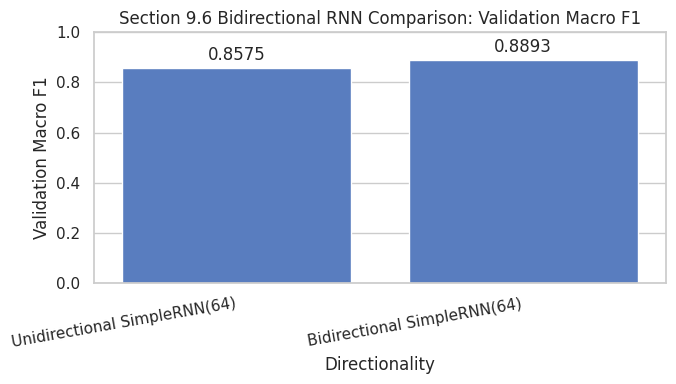

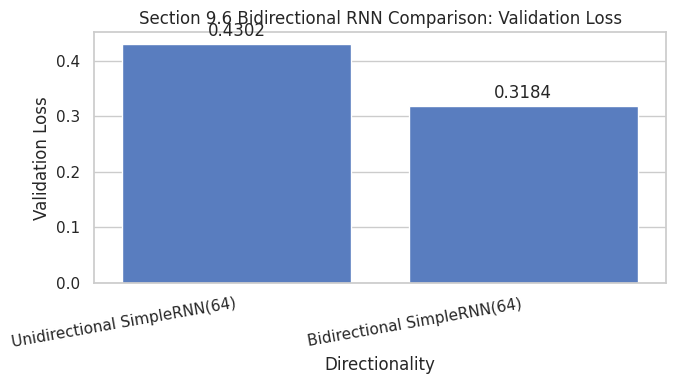

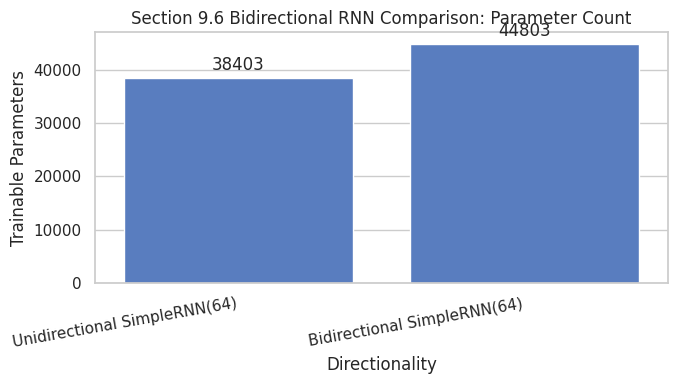

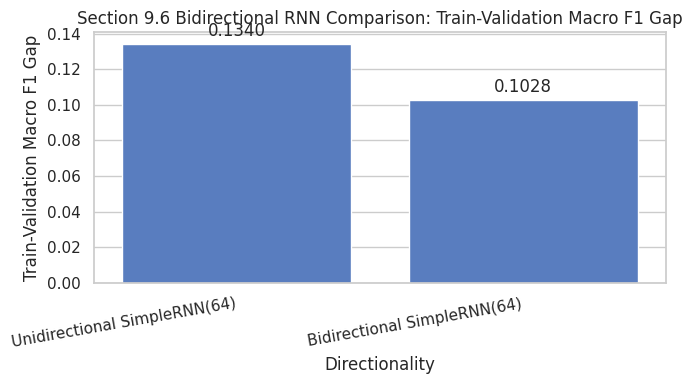

In [219]:
# Plot Section 9.6 bidirectional comparison

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_bidirectional_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.6 Bidirectional RNN Comparison: Validation Macro F1")
plt.xlabel("Directionality")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=10, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_bidirectional_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.6 Bidirectional RNN Comparison: Validation Loss")
plt.xlabel("Directionality")
plt.ylabel("Validation Loss")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_bidirectional_results,
    x="experiment_name",
    y="parameter_count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Section 9.6 Bidirectional RNN Comparison: Parameter Count")
plt.xlabel("Directionality")
plt.ylabel("Trainable Parameters")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=section9_bidirectional_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.6 Bidirectional RNN Comparison: Train-Validation Macro F1 Gap")
plt.xlabel("Directionality")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=10, ha="right")
plt.tight_layout()
plt.show()

In [220]:
# lock selected directionality

selected_directionality_key = "bidirectional_rnn__bidirectional"
selected_bidirectional = True

selected_directionality_output = section9_experiment_outputs[selected_directionality_key]
selected_directionality_result = selected_directionality_output["result_row"]
selected_directionality_val_preds = selected_directionality_output["val_preds"]

print("Selected directionality locked.")
print("Selected model: Bidirectional SimpleRNN(64)")

display(
    pd.DataFrame([selected_directionality_result])[
        [
            "experiment_name",
            "bidirectional",
            "rnn_units",
            "parameter_count",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected directionality locked.
Selected model: Bidirectional SimpleRNN(64)


,experiment_name,bidirectional,rnn_units,parameter_count,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,Bidirectional SimpleRNN(64),True,64,44803,8,0.3184,0.8957,0.8893,0.1028,0.8961,0.8621,0.8684,0.9375,0.8749,0.9078


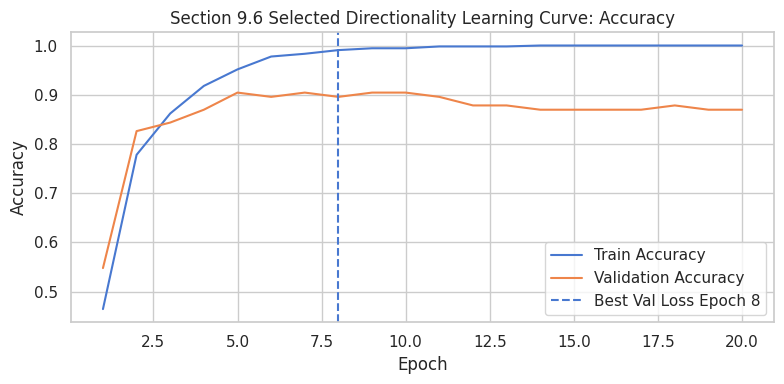

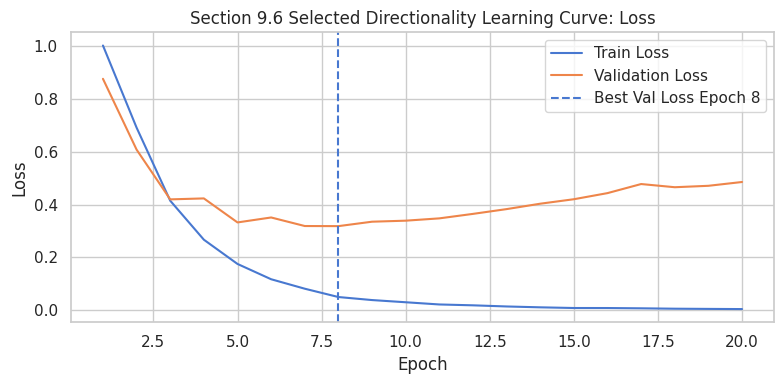

In [221]:
# learning curves for selected directionality

section9_directionality_selected_history = selected_directionality_output["history"].history
section9_directionality_selected_best_epoch = selected_directionality_result["best_epoch"]

epochs = range(1, len(section9_directionality_selected_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_directionality_selected_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, section9_directionality_selected_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    section9_directionality_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_directionality_selected_best_epoch}"
)
plt.title("Section 9.6 Selected Directionality Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_directionality_selected_history["loss"], label="Train Loss")
plt.plot(epochs, section9_directionality_selected_history["val_loss"], label="Validation Loss")
plt.axvline(
    section9_directionality_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_directionality_selected_best_epoch}"
)
plt.title("Section 9.6 Selected Directionality Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

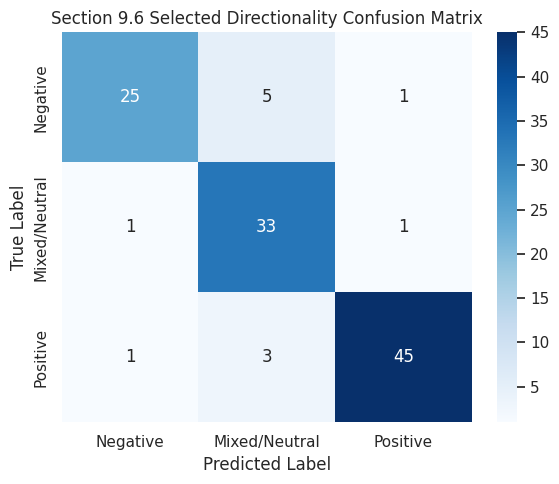

Classification report for selected directionality:
               precision    recall  f1-score   support

     Negative       0.93      0.81      0.86        31
Mixed/Neutral       0.80      0.94      0.87        35
     Positive       0.96      0.92      0.94        49

     accuracy                           0.90       115
    macro avg       0.90      0.89      0.89       115
 weighted avg       0.90      0.90      0.90       115



In [222]:
# Section 9.6: confusion matrix for selected directionality

section9_directionality_selected_cm = confusion_matrix(
    section6_y_val,
    selected_directionality_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    section9_directionality_selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 9.6 Selected Directionality Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected directionality:")
print(
    classification_report(
        section6_y_val,
        selected_directionality_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 9.6 Bidirectional RNN Comparison Interpretation**

The bidirectional comparison shows that Bidirectional SimpleRNN(64) is stronger than the unidirectional SimpleRNN(64).

Bidirectional SimpleRNN(64) achieved the better overall validation performance, with validation macro F1 improving from 0.8575 to 0.8893. Validation accuracy also improved from 0.8609 to 0.8957, while validation loss decreased from 0.4302 to 0.3184. This is a clear improvement across the main selection metrics.

The bidirectional model also reduced the train-validation macro F1 gap from 0.1340 to 0.1028. This suggests that the added bidirectional structure did not simply overfit more, despite increasing the parameter count from 38,403 to 44,803.

The learning curves show that the bidirectional model learns very quickly. Validation loss reaches its best point at epoch 8, after which training loss continues decreasing while validation loss starts rising. This shows clear overfitting after the best checkpoint, so using `ModelCheckpoint` with validation loss is important.

The confusion matrix supports the selection. The model correctly predicts 25 out of 31 Negative reviews, 33 out of 35 Mixed/Neutral reviews, and 45 out of 49 Positive reviews. The class-level F1 scores are also strong, with Negative F1 at 0.86, Mixed/Neutral F1 at 0.87, and Positive F1 at 0.94.

The main tradeoff is that the bidirectional model adds complexity. However, the validation gains are large enough to justify the added parameters because it improves macro F1, validation loss, accuracy, weighted F1, English macro F1, Malay macro F1, and the train-validation gap.

Overall, Bidirectional SimpleRNN(64) is selected for the next Section 9 experiments.

### 9.7 Regularisation and Normalisation

This experiment checks whether regularisation or normalisation improves the selected Bidirectional SimpleRNN(64) model.

The selected model currently uses:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- Sequence length 15
- Bidirectional SimpleRNN(64)
- Dropout 0.3
- Batch size 32
- 20 epochs
- Adam learning rate 0.001
- Validation-loss checkpointing

Stage 1 tests regularisation settings one at a time:

1. Baseline dropout 0.3
2. Dropout 0.5
3. Recurrent dropout 0.1
4. Recurrent dropout 0.2
5. L2 0.00001
6. L2 0.0001
7. L2 0.001

The hypothesis is that the selected RNN may overfit on a small dataset. Dropout, recurrent dropout, L2 regularisation, and LayerNorm are tested as controlled ways to improve generalisation.

The risk is that too much regularisation may underfit and hurt class-level F1.

LayerNorm will be tested separately as a binary no-LayerNorm versus with-LayerNorm check after Stage 1. Conditional regularisation combinations will only be tested if Stage 1 gives a clear reason.

The test set remains untouched.

In [225]:
# regularised Bidirectional SimpleRNN helper

def build_section9_regularised_bidirectional_rnn_model(
    post_rnn_dropout=0.3,
    recurrent_dropout=0.0,
    l2_strength=None,
    use_layer_norm=False,
    units=64,
    learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
    max_length=SECTION9_SELECTED_SEQUENCE_LENGTH,
    vocab_size=VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM
):
    if l2_strength is None:
        rnn_regularizer = None
    else:
        rnn_regularizer = tf.keras.regularizers.l2(l2_strength)

    model = Sequential()
    model.add(Input(shape=(max_length,)))
    model.add(Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    ))

    model.add(Bidirectional(
        SimpleRNN(
            units,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=rnn_regularizer,
            recurrent_regularizer=rnn_regularizer
        )
    ))

    if use_layer_norm:
        model.add(LayerNormalization())

    model.add(Dropout(post_rnn_dropout))
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [226]:
# regularisation experiment runner

def run_section9_regularisation_experiment(
    experiment_name,
    controlled_change,
    post_rnn_dropout=0.3,
    recurrent_dropout=0.0,
    l2_strength=None,
    use_layer_norm=False,
    checkpoint_suffix=None
):
    tf.random.set_seed(SEED)

    if checkpoint_suffix is None:
        checkpoint_suffix = experiment_name.lower().replace(" ", "_").replace("/", "_")

    checkpoint_path = os.path.join(
        SECTION9_CHECKPOINT_DIR,
        f"{checkpoint_suffix}_best.weights.h5"
    )

    model = build_section9_regularised_bidirectional_rnn_model(
        post_rnn_dropout=post_rnn_dropout,
        recurrent_dropout=recurrent_dropout,
        l2_strength=l2_strength,
        use_layer_norm=use_layer_norm,
        units=selected_rnn_units,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    history = model.fit(
        section9_selected_X_train,
        section6_y_train,
        validation_data=(section9_selected_X_val, section6_y_val),
        epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        callbacks=[checkpoint],
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        section9_selected_X_train,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        section9_selected_X_val,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(section9_selected_X_train, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(section9_selected_X_val, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "experiment_group": "Regularisation Stage 1",
        "experiment_name": experiment_name,
        "hypothesis": (
            "The selected RNN may overfit on a small dataset, so controlled "
            "regularisation may improve validation generalisation."
        ),
        "controlled_change": controlled_change,
        "fixed_settings": (
            "Original training reviews only, language-token input, Strategy B tokenizer reused "
            "without refitting, sequence length 15, Bidirectional SimpleRNN(64), "
            "batch size 32, 20 epochs, Adam learning rate 0.001"
        ),
        "post_rnn_dropout": post_rnn_dropout,
        "recurrent_dropout": recurrent_dropout,
        "l2_strength": l2_strength,
        "use_layer_norm": use_layer_norm,
        "parameter_count": model.count_params(),
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

In [227]:
# Stage 1: regularisation comparison

# Remove old Section 9.7 Stage 1 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Regularisation Stage 1"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("regularisation_stage1__"):
        del section9_experiment_outputs[key]

regularisation_stage1_configs = [
    {
        "setting_key": "baseline_dropout_03",
        "experiment_name": "Baseline dropout 0.3",
        "controlled_change": "Post-RNN dropout kept at 0.3",
        "post_rnn_dropout": 0.3,
        "recurrent_dropout": 0.0,
        "l2_strength": None
    },
    {
        "setting_key": "dropout_05",
        "experiment_name": "Dropout 0.5",
        "controlled_change": "Post-RNN dropout increased from 0.3 to 0.5",
        "post_rnn_dropout": 0.5,
        "recurrent_dropout": 0.0,
        "l2_strength": None
    },
    {
        "setting_key": "recurrent_dropout_01",
        "experiment_name": "Recurrent dropout 0.1",
        "controlled_change": "Recurrent dropout set to 0.1",
        "post_rnn_dropout": 0.3,
        "recurrent_dropout": 0.1,
        "l2_strength": None
    },
    {
        "setting_key": "recurrent_dropout_02",
        "experiment_name": "Recurrent dropout 0.2",
        "controlled_change": "Recurrent dropout set to 0.2",
        "post_rnn_dropout": 0.3,
        "recurrent_dropout": 0.2,
        "l2_strength": None
    },
    {
        "setting_key": "l2_000001",
        "experiment_name": "L2 0.00001",
        "controlled_change": "L2 regularisation strength set to 0.00001",
        "post_rnn_dropout": 0.3,
        "recurrent_dropout": 0.0,
        "l2_strength": 0.00001
    },
    {
        "setting_key": "l2_00001",
        "experiment_name": "L2 0.0001",
        "controlled_change": "L2 regularisation strength set to 0.0001",
        "post_rnn_dropout": 0.3,
        "recurrent_dropout": 0.0,
        "l2_strength": 0.0001
    },
    {
        "setting_key": "l2_0001",
        "experiment_name": "L2 0.001",
        "controlled_change": "L2 regularisation strength set to 0.001",
        "post_rnn_dropout": 0.3,
        "recurrent_dropout": 0.0,
        "l2_strength": 0.001
    }
]

for config in regularisation_stage1_configs:
    output_key = f"regularisation_stage1__{config['setting_key']}"

    print("=" * 80)
    print(f"Training Section 9.7 Stage 1 experiment: {config['experiment_name']}")
    print("=" * 80)

    output = run_section9_regularisation_experiment(
        experiment_name=config["experiment_name"],
        controlled_change=config["controlled_change"],
        post_rnn_dropout=config["post_rnn_dropout"],
        recurrent_dropout=config["recurrent_dropout"],
        l2_strength=config["l2_strength"],
        use_layer_norm=False,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.7 Stage 1 experiment: Baseline dropout 0.3
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 14s 402ms/step - accuracy: 0.4384 - loss: 1.0245 - val_accuracy: 0.5739 - val_loss: 0.8983
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7276 - loss: 0.7614 - val_accuracy: 0.7304 - val_loss: 0.6857
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8358 - loss: 0.4790 - val_accuracy: 0.8000 - val_loss: 0.5080
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9104 - loss: 0.2625 - val_accuracy: 0.8261 - val_loss: 0.4883
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9664 - loss: 0.1408 - val_accuracy: 0.8696 - val_loss: 0.4920
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9832 - loss: 0.0869 - val_accuracy: 0.8522 - val_loss: 0.5158
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9795 - loss: 0.0625 - val_accuracy: 0.8522 - val_loss: 0.5457
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/s

In [228]:
# Display Section 9.7 Stage 1 regularisation comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_regularisation_stage1_results = section9_results_df[
    section9_results_df["experiment_group"] == "Regularisation Stage 1"
].copy()

regularisation_stage1_order = [
    "Baseline dropout 0.3",
    "Dropout 0.5",
    "Recurrent dropout 0.1",
    "Recurrent dropout 0.2",
    "L2 0.00001",
    "L2 0.0001",
    "L2 0.001"
]

section9_regularisation_stage1_results["experiment_name"] = pd.Categorical(
    section9_regularisation_stage1_results["experiment_name"],
    categories=regularisation_stage1_order,
    ordered=True
)

section9_regularisation_stage1_results = section9_regularisation_stage1_results.sort_values(
    "experiment_name"
)

section9_regularisation_stage1_columns = [
    "experiment_name",
    "post_rnn_dropout",
    "recurrent_dropout",
    "l2_strength",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_regularisation_stage1_results[section9_regularisation_stage1_columns].round(4))

,experiment_name,post_rnn_dropout,recurrent_dropout,l2_strength,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
17,Baseline dropout 0.3,0.3,0.0,NaN,4,0.4883,0.8261,0.8211,0.1354,0.8268,0.8136,0.7838,0.8660,0.8373,0.8056
18,Dropout 0.5,0.5,0.0,NaN,8,0.3748,0.8783,0.8737,0.1160,0.8792,0.8667,0.8378,0.9167,0.8422,0.9122
19,Recurrent dropout 0.1,0.3,0.1,NaN,8,0.3830,0.8609,0.8523,0.1318,0.8612,0.8276,0.8108,0.9184,0.8403,0.8638
20,Recurrent dropout 0.2,0.3,0.2,NaN,19,0.2874,0.9217,0.9191,0.0809,0.9221,0.9355,0.8732,0.9485,0.9059,0.9312
21,L2 0.00001,0.3,0.0,0.0000,10,0.3787,0.8609,0.8472,0.1528,0.8599,0.8070,0.7945,0.9400,0.8200,0.8840
22,L2 0.0001,0.3,0.0,0.0001,4,0.5217,0.8696,0.8602,0.1151,0.8681,0.8475,0.8116,0.9216,0.8374,0.8899
23,L2 0.001,0.3,0.0,0.0010,5,0.6650,0.8609,0.8570,0.1097,0.8611,0.8333,0.8533,0.8842,0.8621,0.8502


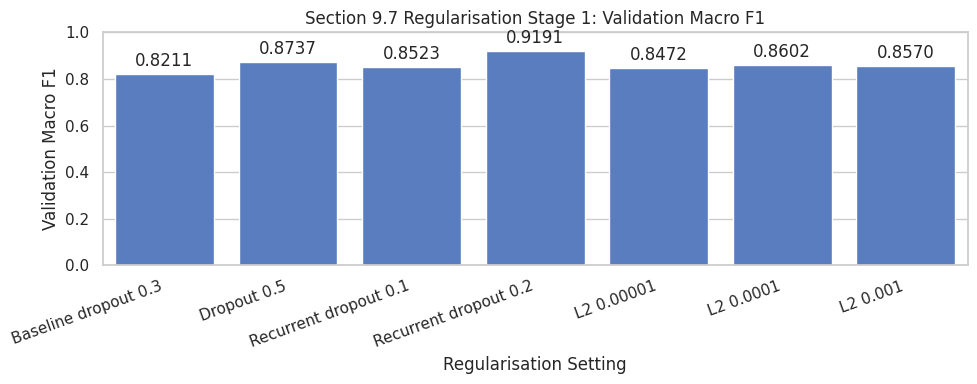

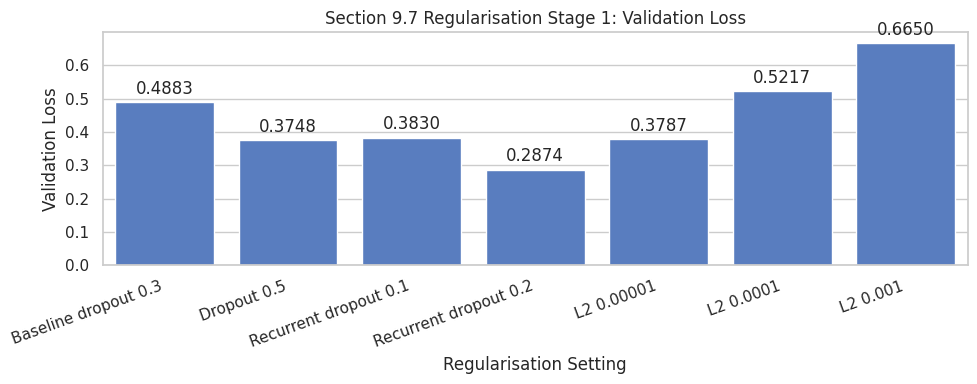

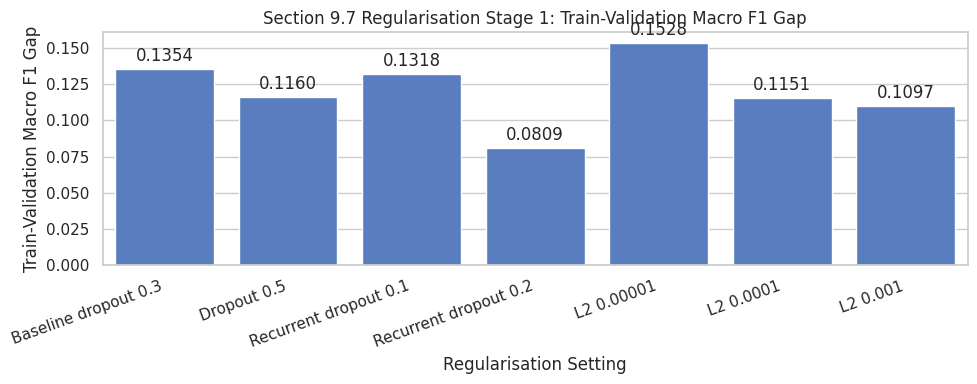

In [229]:
# Plot Section 9.7 Stage 1 regularisation comparison

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_regularisation_stage1_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.7 Regularisation Stage 1: Validation Macro F1")
plt.xlabel("Regularisation Setting")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_regularisation_stage1_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.7 Regularisation Stage 1: Validation Loss")
plt.xlabel("Regularisation Setting")
plt.ylabel("Validation Loss")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_regularisation_stage1_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.7 Regularisation Stage 1: Train-Validation Macro F1 Gap")
plt.xlabel("Regularisation Setting")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [231]:
# LayerNorm binary check
# Compare no LayerNorm vs with LayerNorm using the best Stage 1 regularisation setting.

# Remove old LayerNorm check results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "LayerNorm Check"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("layernorm_check__"):
        del section9_experiment_outputs[key]

layernorm_configs = [
    {
        "setting_key": "no_layernorm",
        "experiment_name": "No LayerNorm",
        "use_layer_norm": False
    },
    {
        "setting_key": "with_layernorm",
        "experiment_name": "With LayerNorm",
        "use_layer_norm": True
    }
]

for config in layernorm_configs:
    output_key = f"layernorm_check__{config['setting_key']}"

    print("=" * 80)
    print(f"Training Section 9.7 LayerNorm check: {config['experiment_name']}")
    print("=" * 80)

    output = run_section9_regularisation_experiment(
        experiment_name=config["experiment_name"],
        controlled_change=(
            "LayerNormalization added after Bidirectional SimpleRNN output"
            if config["use_layer_norm"]
            else "No LayerNormalization layer used"
        ),
        post_rnn_dropout=0.3,
        recurrent_dropout=0.2,
        l2_strength=None,
        use_layer_norm=config["use_layer_norm"],
        checkpoint_suffix=output_key
    )

    output["result_row"]["experiment_group"] = "LayerNorm Check"
    output["result_row"]["use_layer_norm"] = config["use_layer_norm"]

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.7 LayerNorm check: No LayerNorm
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 405ms/step - accuracy: 0.3638 - loss: 1.0797 - val_accuracy: 0.4696 - val_loss: 0.9913
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5354 - loss: 0.9534 - val_accuracy: 0.7130 - val_loss: 0.8572
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6996 - loss: 0.8069 - val_accuracy: 0.8000 - val_loss: 0.7085
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7556 - loss: 0.6683 - val_accuracy: 0.8087 - val_loss: 0.6384
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8377 - loss: 0.5194 - val_accuracy: 0.8783 - val_loss: 0.5027
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8582 - loss: 0.4393 - val_accuracy: 0.8957 - val_loss: 0.4359
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9123 - loss: 0.3607 - val_accuracy: 0.8870 - val_loss: 0.4467
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accur

In [232]:
# Display LayerNorm check results

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_layernorm_results = section9_results_df[
    section9_results_df["experiment_group"] == "LayerNorm Check"
].copy()

section9_layernorm_columns = [
    "experiment_name",
    "use_layer_norm",
    "post_rnn_dropout",
    "recurrent_dropout",
    "l2_strength",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_layernorm_results[section9_layernorm_columns].round(4))

,experiment_name,use_layer_norm,post_rnn_dropout,recurrent_dropout,l2_strength,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
24,No LayerNorm,False,0.3,0.2,NaN,11,0.4212,0.8696,0.8597,0.1250,0.8706,0.8197,0.8219,0.9375,0.8397,0.8855
25,With LayerNorm,True,0.3,0.2,NaN,18,0.4861,0.8870,0.8821,0.1179,0.8878,0.8750,0.8451,0.9263,0.8897,0.8702


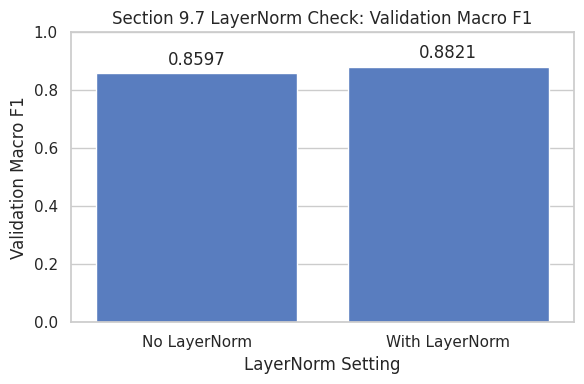

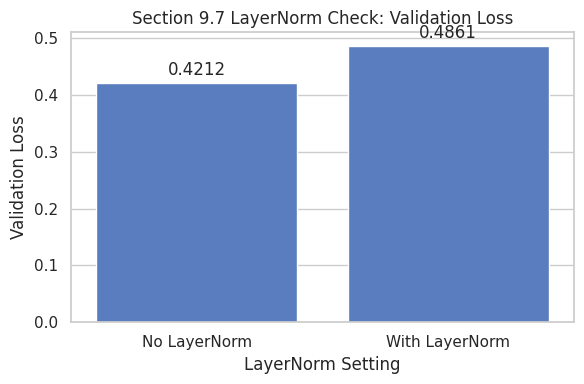

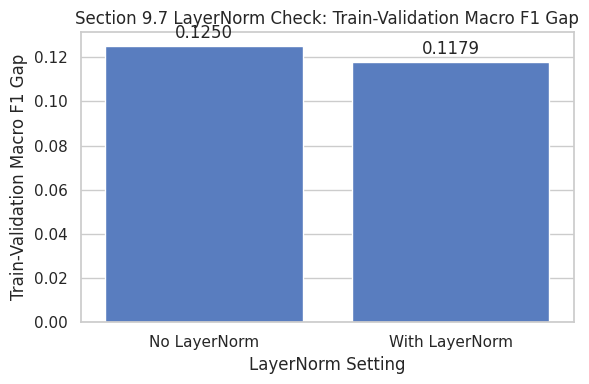

In [233]:
# Plot LayerNorm check

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_layernorm_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.7 LayerNorm Check: Validation Macro F1")
plt.xlabel("LayerNorm Setting")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_layernorm_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.7 LayerNorm Check: Validation Loss")
plt.xlabel("LayerNorm Setting")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_layernorm_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.7 LayerNorm Check: Train-Validation Macro F1 Gap")
plt.xlabel("LayerNorm Setting")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.tight_layout()
plt.show()

In [234]:
# Section 9.7: lock selected regularisation setting

selected_regularisation_key = "regularisation_stage1__recurrent_dropout_02"

selected_post_rnn_dropout = 0.3
selected_recurrent_dropout = 0.2
selected_l2_strength = None
selected_use_layer_norm = False

selected_regularisation_output = section9_experiment_outputs[selected_regularisation_key]
selected_regularisation_result = selected_regularisation_output["result_row"]
selected_regularisation_val_preds = selected_regularisation_output["val_preds"]

print("Selected regularisation setting locked.")
print(f"Post-RNN dropout: {selected_post_rnn_dropout}")
print(f"Recurrent dropout: {selected_recurrent_dropout}")
print(f"L2 strength: {selected_l2_strength}")
print(f"LayerNorm: {selected_use_layer_norm}")

display(
    pd.DataFrame([selected_regularisation_result])[
        [
            "experiment_name",
            "post_rnn_dropout",
            "recurrent_dropout",
            "l2_strength",
            "use_layer_norm",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected regularisation setting locked.
Post-RNN dropout: 0.3
Recurrent dropout: 0.2
L2 strength: None
LayerNorm: False


,experiment_name,post_rnn_dropout,recurrent_dropout,l2_strength,use_layer_norm,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,Recurrent dropout 0.2,0.3,0.2,None,False,19,0.2874,0.9217,0.9191,0.0809,0.9221,0.9355,0.8732,0.9485,0.9059,0.9312


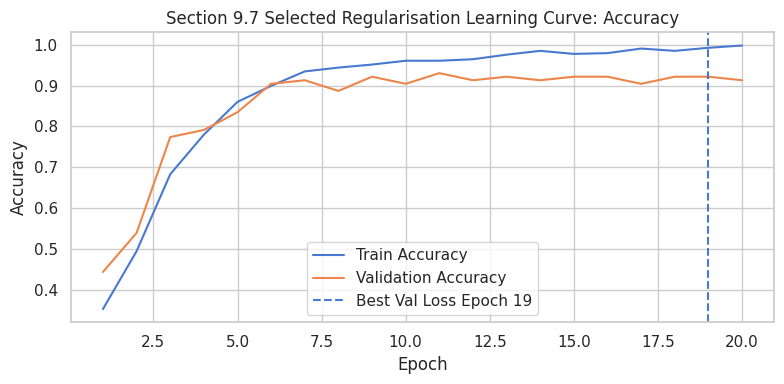

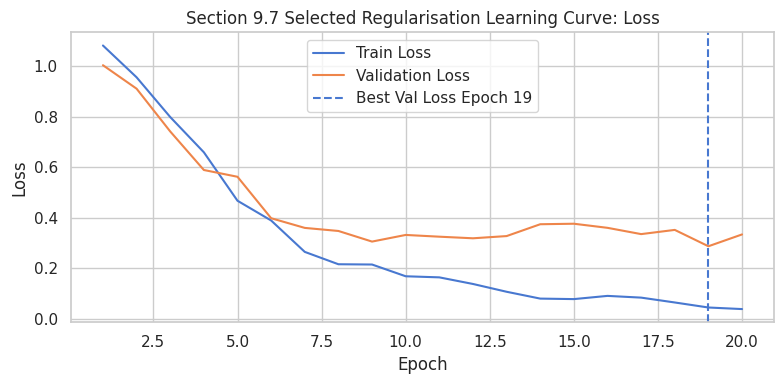

In [235]:
# Section 9.7: learning curves for selected regularisation setting

section9_regularisation_selected_history = selected_regularisation_output["history"].history
section9_regularisation_selected_best_epoch = selected_regularisation_result["best_epoch"]

epochs = range(1, len(section9_regularisation_selected_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_regularisation_selected_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, section9_regularisation_selected_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    section9_regularisation_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_regularisation_selected_best_epoch}"
)
plt.title("Section 9.7 Selected Regularisation Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_regularisation_selected_history["loss"], label="Train Loss")
plt.plot(epochs, section9_regularisation_selected_history["val_loss"], label="Validation Loss")
plt.axvline(
    section9_regularisation_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_regularisation_selected_best_epoch}"
)
plt.title("Section 9.7 Selected Regularisation Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

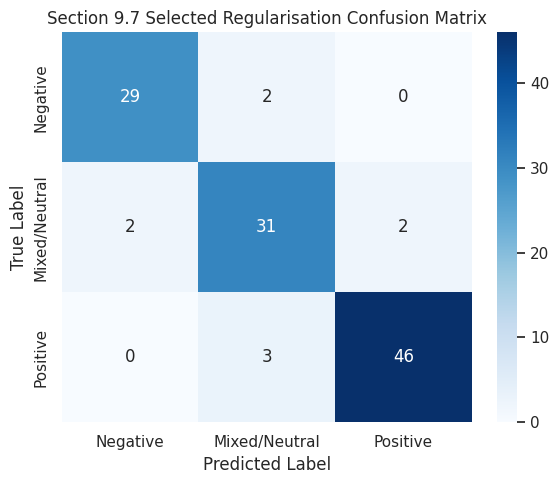

Classification report for selected regularisation setting:
               precision    recall  f1-score   support

     Negative       0.94      0.94      0.94        31
Mixed/Neutral       0.86      0.89      0.87        35
     Positive       0.96      0.94      0.95        49

     accuracy                           0.92       115
    macro avg       0.92      0.92      0.92       115
 weighted avg       0.92      0.92      0.92       115



In [236]:
# Section 9.7: confusion matrix for selected regularisation setting

section9_regularisation_selected_cm = confusion_matrix(
    section6_y_val,
    selected_regularisation_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    section9_regularisation_selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 9.7 Selected Regularisation Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected regularisation setting:")
print(
    classification_report(
        section6_y_val,
        selected_regularisation_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 9.7 Regularisation and Normalisation Interpretation**

Section 9.7 tested whether regularisation and normalisation could improve the selected Bidirectional SimpleRNN(64) model.

Stage 1 showed that recurrent dropout 0.2 was the strongest regularisation setting. It achieved the best validation macro F1 of 0.9191, the best validation accuracy of 0.9217, the lowest validation loss of 0.2874, and the smallest train-validation macro F1 gap of 0.0809. It also performed strongly across both language subsets, with English macro F1 of 0.9059 and Malay macro F1 of 0.9312.

This result suggests that recurrent dropout helped reduce overfitting inside the recurrent layer. This is appropriate for the selected RNN because earlier learning curves showed that the model could fit the small training set quickly while validation performance later fluctuated.

The other regularisation settings did not perform as well. Increasing post-RNN dropout to 0.5 improved over the baseline dropout 0.3 run, but it did not match recurrent dropout 0.2. L2 regularisation also did not provide a clear improvement. Stronger L2 increased validation loss, suggesting that it constrained the model too much.

The LayerNorm check did not provide enough evidence to add LayerNorm. Although the LayerNorm model improved over the fresh no-LayerNorm rerun in macro F1, it had worse validation loss and did not outperform the best Stage 1 recurrent dropout 0.2 result. Since LayerNorm adds complexity without clear validation improvement, it is not selected.

The selected recurrent dropout 0.2 learning curves show better generalisation than the earlier models. Validation accuracy remains high and stable, while the validation loss reaches its best point at epoch 19. The train-validation macro F1 gap is also relatively small at 0.0809, supporting the regularisation choice.

The confusion matrix supports the selection. The model correctly predicts 29 out of 31 Negative reviews, 31 out of 35 Mixed/Neutral reviews, and 46 out of 49 Positive reviews. Class-level F1 is strong across all classes, with Negative F1 at 0.94, Mixed/Neutral F1 at 0.87, and Positive F1 at 0.95.

Overall, the selected regularisation setting is recurrent dropout 0.2 with post-RNN dropout 0.3, no L2 regularisation, and no LayerNorm. This setting gives the strongest validation evidence so far and will be carried forward to the next Section 9 experiments.

### 9.8 Class Weight Strategy Check

This experiment checks whether class weighting improves the selected model.

The selected training set is not perfectly balanced. Positive reviews are the largest class, while Negative and Mixed/Neutral reviews have fewer examples and are harder to classify consistently. Because macro F1 gives equal importance to all classes, improving the smaller or harder classes may improve the final model.

The controlled change is the class weight strategy:

1. No class weights
2. Balanced class weights calculated from the training labels only

All other settings are fixed:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- Sequence length 15
- Bidirectional SimpleRNN(64)
- Post-RNN dropout 0.3
- Recurrent dropout 0.2
- No L2 regularisation
- No LayerNorm
- Batch size 32
- 20 epochs
- Adam learning rate 0.001
- Validation-loss checkpointing

The hypothesis is that balanced class weights may improve validation macro F1 by giving more training importance to the smaller Negative and Mixed/Neutral classes. This may help the model avoid favouring the larger Positive class.

The risk is that class weights may over-correct the class distribution. If the model becomes too biased toward minority classes, validation loss or overall class-level F1 may worsen.

Class weights are calculated from the training labels only. The validation set is used only for evaluation and model selection. The test set remains untouched.

In [237]:
# calculate balanced class weights from training labels only

class_names_map = {
    0: "Negative",
    1: "Mixed/Neutral",
    2: "Positive"
}

train_class_counts = pd.Series(section6_y_train).value_counts().sort_index()
num_train_samples = len(section6_y_train)
num_classes = len(train_class_counts)

balanced_class_weights = {
    int(class_label): num_train_samples / (num_classes * count)
    for class_label, count in train_class_counts.items()
}

class_weight_df = pd.DataFrame({
    "class_label": train_class_counts.index,
    "class_name": train_class_counts.index.map(class_names_map),
    "train_count": train_class_counts.values,
    "balanced_class_weight": [
        balanced_class_weights[int(class_label)]
        for class_label in train_class_counts.index
    ]
})

display(class_weight_df.round(4))

print("Balanced class weights:")
print(balanced_class_weights)

,class_label,class_name,train_count,balanced_class_weight
0,0,Negative,140,1.2762
1,1,Mixed/Neutral,164,1.0894
2,2,Positive,232,0.7701


Balanced class weights:
{0: 1.276190476190476, 1: 1.089430894308943, 2: 0.7701149425287356}


In [238]:
# class weight experiment runner

def run_section9_class_weight_experiment(
    experiment_name,
    controlled_change,
    class_weight,
    checkpoint_suffix
):
    tf.random.set_seed(SEED)

    checkpoint_path = os.path.join(
        SECTION9_CHECKPOINT_DIR,
        f"{checkpoint_suffix}_best.weights.h5"
    )

    model = build_section9_regularised_bidirectional_rnn_model(
        post_rnn_dropout=selected_post_rnn_dropout,
        recurrent_dropout=selected_recurrent_dropout,
        l2_strength=selected_l2_strength,
        use_layer_norm=selected_use_layer_norm,
        units=selected_rnn_units,
        learning_rate=SECTION9_DEFAULT_LEARNING_RATE,
        max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    history = model.fit(
        section9_selected_X_train,
        section6_y_train,
        validation_data=(section9_selected_X_val, section6_y_val),
        epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        callbacks=[checkpoint],
        class_weight=class_weight,
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        section9_selected_X_train,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        section9_selected_X_val,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(section9_selected_X_train, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(section9_selected_X_val, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "experiment_group": "Class Weight Strategy",
        "experiment_name": experiment_name,
        "hypothesis": (
            "Balanced class weights may improve minority-class performance, "
            "but may also overcorrect the training distribution."
        ),
        "controlled_change": controlled_change,
        "fixed_settings": (
            "Original training reviews only, language-token input, Strategy B tokenizer reused "
            "without refitting, sequence length 15, Bidirectional SimpleRNN(64), "
            "post-RNN dropout 0.3, recurrent dropout 0.2, no L2, no LayerNorm, "
            "batch size 32, 20 epochs, Adam learning rate 0.001"
        ),
        "class_weight_strategy": experiment_name,
        "class_weight": class_weight,
        "parameter_count": model.count_params(),
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

In [239]:
# class weight strategy comparison

# Remove old Section 9.8 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Class Weight Strategy"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("class_weight__"):
        del section9_experiment_outputs[key]

class_weight_configs = [
    {
        "setting_key": "none",
        "experiment_name": "No class weights",
        "controlled_change": "No class weights applied during training",
        "class_weight": None
    },
    {
        "setting_key": "balanced",
        "experiment_name": "Balanced class weights",
        "controlled_change": "Balanced class weights calculated from training labels only",
        "class_weight": balanced_class_weights
    }
]

for config in class_weight_configs:
    output_key = f"class_weight__{config['setting_key']}"

    print("=" * 80)
    print(f"Training Section 9.8 experiment: {config['experiment_name']}")
    print("=" * 80)

    output = run_section9_class_weight_experiment(
        experiment_name=config["experiment_name"],
        controlled_change=config["controlled_change"],
        class_weight=config["class_weight"],
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.8 experiment: No class weights
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 494ms/step - accuracy: 0.3526 - loss: 1.0884 - val_accuracy: 0.4435 - val_loss: 0.9778
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.5224 - loss: 0.9573 - val_accuracy: 0.6261 - val_loss: 0.8778
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6884 - loss: 0.8047 - val_accuracy: 0.7304 - val_loss: 0.7463
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7724 - loss: 0.6206 - val_accuracy: 0.7652 - val_loss: 0.6655
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8396 - loss: 0.4706 - val_accuracy: 0.8087 - val_loss: 0.6419
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8955 - loss: 0.3753 - val_accuracy: 0.8174 - val_loss: 0.5649
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9030 - loss: 0.3326 - val_accuracy: 0.8522 - val_loss: 0.5329
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accura

In [240]:
# Display class weight strategy comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_class_weight_results = section9_results_df[
    section9_results_df["experiment_group"] == "Class Weight Strategy"
].copy()

class_weight_order = [
    "No class weights",
    "Balanced class weights"
]

section9_class_weight_results["experiment_name"] = pd.Categorical(
    section9_class_weight_results["experiment_name"],
    categories=class_weight_order,
    ordered=True
)

section9_class_weight_results = section9_class_weight_results.sort_values(
    "experiment_name"
)

section9_class_weight_columns = [
    "experiment_name",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_class_weight_results[section9_class_weight_columns].round(4))

,experiment_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
26,No class weights,7,0.5329,0.8522,0.8502,0.1149,0.8564,0.8571,0.7901,0.9032,0.8010,0.9055
27,Balanced class weights,13,0.4458,0.8435,0.8370,0.1482,0.8449,0.8065,0.8108,0.8936,0.8242,0.8586


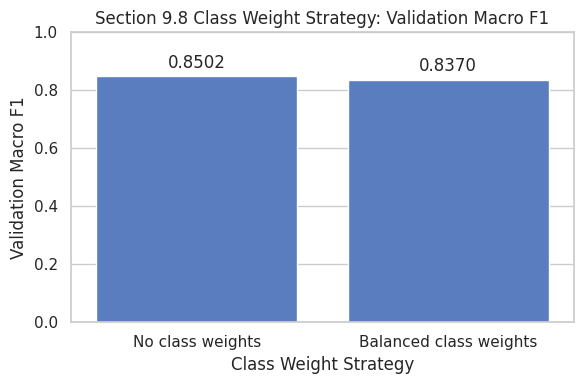

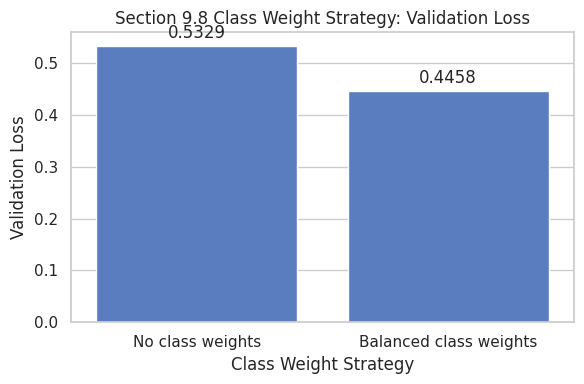

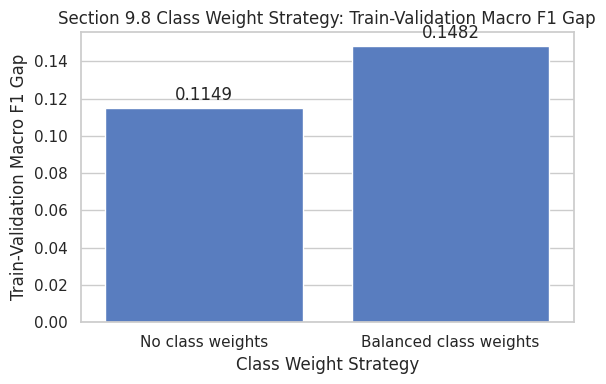

In [241]:
# Plot Section 9.8 class weight strategy comparison

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_class_weight_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.8 Class Weight Strategy: Validation Macro F1")
plt.xlabel("Class Weight Strategy")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_class_weight_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.8 Class Weight Strategy: Validation Loss")
plt.xlabel("Class Weight Strategy")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_class_weight_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.8 Class Weight Strategy: Train-Validation Macro F1 Gap")
plt.xlabel("Class Weight Strategy")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.tight_layout()
plt.show()

In [242]:
# Section 9.8: lock selected class weight strategy

selected_class_weight_strategy = "No class weights"
selected_class_weight = None

selected_class_weight_key = "class_weight__none"
selected_class_weight_output = section9_experiment_outputs[selected_class_weight_key]
selected_class_weight_result = selected_class_weight_output["result_row"]

print("Selected class weight strategy locked.")
print(f"Selected class weight strategy: {selected_class_weight_strategy}")
print(f"Class weight: {selected_class_weight}")

display(
    pd.DataFrame([selected_class_weight_result])[
        [
            "experiment_name",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected class weight strategy locked.
Selected class weight strategy: No class weights
Class weight: None


,experiment_name,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,No class weights,7,0.5329,0.8522,0.8502,0.1149,0.8564,0.8571,0.7901,0.9032,0.801,0.9055


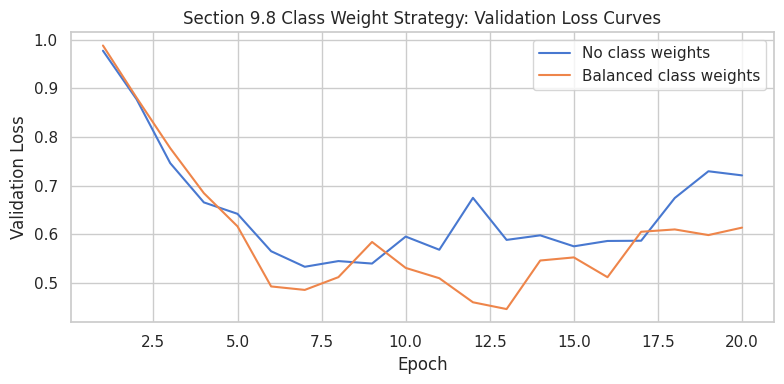

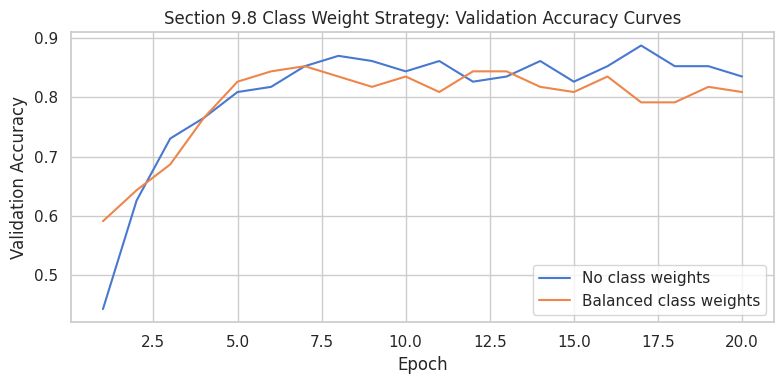

In [243]:
# Section 9.8: learning curves for class weight strategy comparison

class_weight_curve_keys = [
    ("class_weight__none", "No class weights"),
    ("class_weight__balanced", "Balanced class weights")
]

plt.figure(figsize=(8, 4))

for output_key, label in class_weight_curve_keys:
    history = section9_experiment_outputs[output_key]["history"].history
    epochs = range(1, len(history["val_loss"]) + 1)

    plt.plot(
        epochs,
        history["val_loss"],
        label=label
    )

plt.title("Section 9.8 Class Weight Strategy: Validation Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))

for output_key, label in class_weight_curve_keys:
    history = section9_experiment_outputs[output_key]["history"].history
    epochs = range(1, len(history["val_accuracy"]) + 1)

    plt.plot(
        epochs,
        history["val_accuracy"],
        label=label
    )

plt.title("Section 9.8 Class Weight Strategy: Validation Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

**Section 9.8 Class Weight Strategy Interpretation**

Section 9.8 tested whether balanced class weights improve the selected model.

The class weights were calculated from the training labels only. Negative and Mixed/Neutral received higher weights because they had fewer training examples than Positive. This keeps the experiment leakage-safe because validation and test labels were not used when calculating class weights.

The no-class-weight setting achieved the higher validation macro F1 of 0.8502, compared with 0.8370 for balanced class weights. Since validation macro F1 is the primary selection metric, balanced class weights are not selected.

Balanced class weights reduced validation loss from 0.5329 to 0.4458, but this did not translate into better classification performance. Balanced class weights also increased the train-validation macro F1 gap from 0.1149 to 0.1482, suggesting weaker generalisation.

Class-level F1 does not justify selecting balanced class weights. Balanced class weights slightly improved Mixed/Neutral F1 from 0.7901 to 0.8108, but Negative F1 decreased from 0.8571 to 0.8065 and Positive F1 decreased from 0.9032 to 0.8936. This suggests that class weighting over-corrected the training distribution instead of improving the model overall.

The learning curves support this decision. Balanced class weights gave a lower best validation loss, but the validation accuracy curve did not show a stronger overall classification outcome. Since macro F1 and class-level F1 are more important for this class-balanced evaluation goal, no class weights are selected.

The no-class-weight result in this subsection is lower than the best Section 9.7 selected model result because this subsection retrained the model from scratch for a fair two-setting comparison. The decision here is still valid because both class-weight settings were compared under the same conditions.

Overall, no class weights are selected for the next experiments. The model will continue using the selected recurrent dropout regularisation without class weighting.

### 9.9 Learning-Rate Strategy

This experiment checks whether changing the learning-rate strategy improves the selected model.

The selected model currently uses:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- Sequence length 15
- Bidirectional SimpleRNN(64)
- Post-RNN dropout 0.3
- Recurrent dropout 0.2
- No L2 regularisation
- No LayerNorm
- No class weights
- Batch size 32
- 20 epochs
- Validation-loss checkpointing

Stage 1 compares two fixed Adam learning rates:

1. Adam learning rate 0.001
2. Adam learning rate 0.0005

The hypothesis is that a smaller fixed learning rate may improve convergence stability and validation generalisation. The risk is that a learning rate that is too small may learn too slowly within the 20-epoch training budget.

Stage 2 will test ReduceLROnPlateau using the better fixed learning rate from Stage 1.

The test set remains untouched.

In [245]:
# learning-rate experiment runner

def run_section9_learning_rate_experiment(
    experiment_group,
    experiment_name,
    controlled_change,
    learning_rate,
    callbacks_extra=None,
    reduce_lr_patience=None,
    checkpoint_suffix=None
):
    tf.random.set_seed(SEED)

    if callbacks_extra is None:
        callbacks_extra = []

    if checkpoint_suffix is None:
        checkpoint_suffix = experiment_name.lower().replace(" ", "_").replace("/", "_")

    checkpoint_path = os.path.join(
        SECTION9_CHECKPOINT_DIR,
        f"{checkpoint_suffix}_best.weights.h5"
    )

    model = build_section9_regularised_bidirectional_rnn_model(
        post_rnn_dropout=selected_post_rnn_dropout,
        recurrent_dropout=selected_recurrent_dropout,
        l2_strength=selected_l2_strength,
        use_layer_norm=selected_use_layer_norm,
        units=selected_rnn_units,
        learning_rate=learning_rate,
        max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
    )

    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=0
    )

    callbacks = [checkpoint] + callbacks_extra

    history = model.fit(
        section9_selected_X_train,
        section6_y_train,
        validation_data=(section9_selected_X_val, section6_y_val),
        epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        callbacks=callbacks,
        class_weight=selected_class_weight,
        verbose=1
    )

    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        section9_selected_X_train,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        section9_selected_X_val,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(section9_selected_X_train, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(section9_selected_X_val, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result_row = {
        "experiment_group": experiment_group,
        "experiment_name": experiment_name,
        "hypothesis": (
            "A smaller fixed learning rate or adaptive learning-rate reduction may "
            "improve convergence stability and validation generalisation."
        ),
        "controlled_change": controlled_change,
        "fixed_settings": (
            "Original training reviews only, language-token input, Strategy B tokenizer reused "
            "without refitting, sequence length 15, Bidirectional SimpleRNN(64), "
            "post-RNN dropout 0.3, recurrent dropout 0.2, no L2, no LayerNorm, "
            "no class weights, batch size 32, 20 epochs"
        ),
        "initial_learning_rate": learning_rate,
        "reduce_lr_patience": reduce_lr_patience,
        "parameter_count": model.count_params(),
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - metrics["val_macro_f1"],
        "val_weighted_f1": metrics["val_weighted_f1"],
        "negative_f1": metrics["negative_f1"],
        "mixed_neutral_f1": metrics["mixed_neutral_f1"],
        "positive_f1": metrics["positive_f1"],
        "english_macro_f1": metrics["english_macro_f1"],
        "malay_macro_f1": metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    return {
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row
    }

In [246]:
# Stage 1: fixed learning-rate comparison

# Remove old Section 9.9 Stage 1 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Learning Rate Stage 1"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("learning_rate_stage1__"):
        del section9_experiment_outputs[key]

learning_rate_stage1_configs = [
    {
        "setting_key": "adam_001",
        "experiment_name": "Adam lr 0.001",
        "learning_rate": 0.001,
        "controlled_change": "Adam learning rate fixed at 0.001"
    },
    {
        "setting_key": "adam_0005",
        "experiment_name": "Adam lr 0.0005",
        "learning_rate": 0.0005,
        "controlled_change": "Adam learning rate fixed at 0.0005"
    }
]

for config in learning_rate_stage1_configs:
    output_key = f"learning_rate_stage1__{config['setting_key']}"

    print("=" * 80)
    print(f"Training Section 9.9 Stage 1 experiment: {config['experiment_name']}")
    print("=" * 80)

    output = run_section9_learning_rate_experiment(
        experiment_group="Learning Rate Stage 1",
        experiment_name=config["experiment_name"],
        controlled_change=config["controlled_change"],
        learning_rate=config["learning_rate"],
        callbacks_extra=[],
        reduce_lr_patience=None,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.9 Stage 1 experiment: Adam lr 0.001
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 311ms/step - accuracy: 0.3937 - loss: 1.0805 - val_accuracy: 0.4348 - val_loss: 0.9903
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5000 - loss: 0.9659 - val_accuracy: 0.6261 - val_loss: 0.9038
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6791 - loss: 0.8570 - val_accuracy: 0.7130 - val_loss: 0.7870
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7295 - loss: 0.7436 - val_accuracy: 0.7391 - val_loss: 0.7378
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7985 - loss: 0.5740 - val_accuracy: 0.8000 - val_loss: 0.5518
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8545 - loss: 0.4509 - val_accuracy: 0.8261 - val_loss: 0.5252
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9198 - loss: 0.3379 - val_accuracy: 0.8435 - val_loss: 0.4610
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - a

In [247]:
# Display Stage 1 fixed learning-rate comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_lr_stage1_results = section9_results_df[
    section9_results_df["experiment_group"] == "Learning Rate Stage 1"
].copy()

lr_stage1_order = [
    "Adam lr 0.001",
    "Adam lr 0.0005"
]

section9_lr_stage1_results["experiment_name"] = pd.Categorical(
    section9_lr_stage1_results["experiment_name"],
    categories=lr_stage1_order,
    ordered=True
)

section9_lr_stage1_results = section9_lr_stage1_results.sort_values(
    "experiment_name"
)

section9_lr_columns = [
    "experiment_name",
    "initial_learning_rate",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(section9_lr_stage1_results[section9_lr_columns].round(4))

,experiment_name,initial_learning_rate,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
28,Adam lr 0.001,0.0010,14,0.4096,0.8609,0.8534,0.1421,0.8616,0.8475,0.7945,0.9184,0.8069,0.9177
29,Adam lr 0.0005,0.0005,14,0.4229,0.8348,0.8242,0.1561,0.8372,0.8065,0.7397,0.9263,0.7783,0.8804


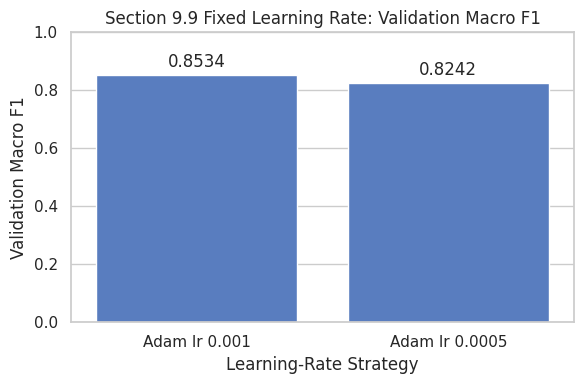

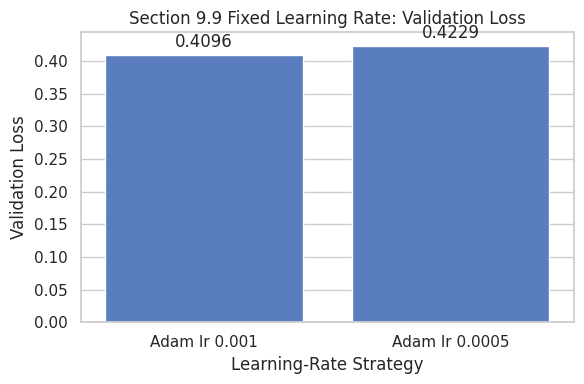

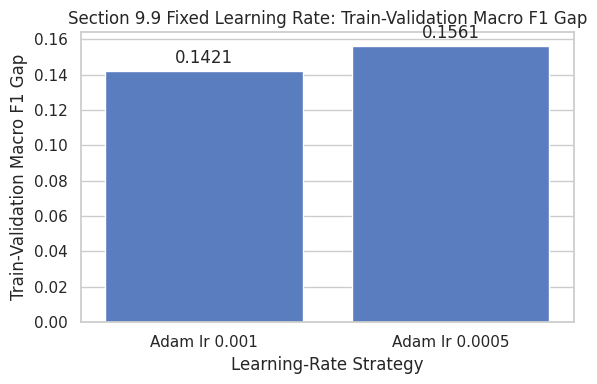

In [248]:
# Plot Stage 1 fixed learning-rate comparison

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_lr_stage1_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.9 Fixed Learning Rate: Validation Macro F1")
plt.xlabel("Learning-Rate Strategy")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_lr_stage1_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.9 Fixed Learning Rate: Validation Loss")
plt.xlabel("Learning-Rate Strategy")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.show()


plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=section9_lr_stage1_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.9 Fixed Learning Rate: Train-Validation Macro F1 Gap")
plt.xlabel("Learning-Rate Strategy")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.tight_layout()
plt.show()

**Section 9.9 Stage 1 Interpretation**

The fixed learning-rate comparison shows that Adam learning rate 0.001 performs better than 0.0005. It achieved higher validation macro F1, lower validation loss, higher validation accuracy, and a smaller train-validation macro F1 gap.

The lower learning rate of 0.0005 appears to learn more slowly within the 20-epoch training budget and does not improve validation performance.

Therefore, Adam learning rate 0.001 is selected as the base learning rate for the ReduceLROnPlateau checks in Stage 2.

In [250]:
# Stage 2: ReduceLROnPlateau comparison
# Use Adam lr 0.001 from Stage 1 as the base learning rate.

selected_base_learning_rate = 0.001

# Remove old Section 9.9 Stage 2 results if this cell is rerun
section9_experiment_results = [
    row for row in section9_experiment_results
    if row.get("experiment_group") != "Learning Rate Stage 2"
]

for key in list(section9_experiment_outputs.keys()):
    if key.startswith("learning_rate_stage2__"):
        del section9_experiment_outputs[key]

reduce_lr_patience_configs = [2, 3, 4, 5]

for patience in reduce_lr_patience_configs:
    output_key = f"learning_rate_stage2__reduce_lr_patience_{patience}"

    reduce_lr_callback = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=patience,
        min_lr=1e-5,
        mode="min",
        verbose=1
    )

    print("=" * 80)
    print(f"Training Section 9.9 Stage 2 experiment: ReduceLROnPlateau patience {patience}")
    print("=" * 80)

    output = run_section9_learning_rate_experiment(
        experiment_group="Learning Rate Stage 2",
        experiment_name=f"ReduceLROnPlateau patience {patience}",
        controlled_change=(
            f"Adam lr starts at {selected_base_learning_rate}, "
            f"ReduceLROnPlateau patience set to {patience}, factor 0.5, min_lr 1e-5"
        ),
        learning_rate=selected_base_learning_rate,
        callbacks_extra=[reduce_lr_callback],
        reduce_lr_patience=patience,
        checkpoint_suffix=output_key
    )

    section9_experiment_outputs[output_key] = output
    section9_experiment_results.append(output["result_row"])

Training Section 9.9 Stage 2 experiment: ReduceLROnPlateau patience 2
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 488ms/step - accuracy: 0.4086 - loss: 1.0674 - val_accuracy: 0.4609 - val_loss: 0.9777 - learning_rate: 0.0010
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5541 - loss: 0.9603 - val_accuracy: 0.6957 - val_loss: 0.8635 - learning_rate: 0.0010
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6959 - loss: 0.7947 - val_accuracy: 0.7304 - val_loss: 0.7499 - learning_rate: 0.0010
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7351 - loss: 0.6572 - val_accuracy: 0.7652 - val_loss: 0.6945 - learning_rate: 0.0010
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8078 - loss: 0.5280 - val_accuracy: 0.7913 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8340 - loss: 0.4539 - val_accuracy: 0.8174 - val_loss: 0.5192 - learning_rate: 0.0010
Epoch 7/20
17/17 ━━━━━

In [251]:
# Display Stage 2 ReduceLROnPlateau comparison

section9_results_df = pd.DataFrame(section9_experiment_results)

section9_lr_stage2_results = section9_results_df[
    section9_results_df["experiment_group"] == "Learning Rate Stage 2"
].copy()

section9_lr_stage2_results = section9_lr_stage2_results.sort_values(
    "reduce_lr_patience"
)

display(section9_lr_stage2_results[section9_lr_columns].round(4))

,experiment_name,initial_learning_rate,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
30,ReduceLROnPlateau patience 2,0.001,13,0.4190,0.8609,0.8536,0.1322,0.8620,0.8333,0.8108,0.9167,0.8599,0.8417
31,ReduceLROnPlateau patience 3,0.001,17,0.4179,0.8870,0.8794,0.1166,0.8870,0.8710,0.8286,0.9388,0.8724,0.8840
32,ReduceLROnPlateau patience 4,0.001,8,0.4909,0.8174,0.8040,0.1559,0.8180,0.7619,0.7429,0.9072,0.7740,0.8383
33,ReduceLROnPlateau patience 5,0.001,7,0.4772,0.8609,0.8559,0.1005,0.8614,0.8364,0.8354,0.8958,0.7914,0.9312


In [252]:
# Display combined learning-rate strategy results

section9_lr_results = pd.concat(
    [
        section9_lr_stage1_results,
        section9_lr_stage2_results
    ],
    ignore_index=True
)

learning_rate_strategy_order = [
    "Adam lr 0.001",
    "Adam lr 0.0005",
    "ReduceLROnPlateau patience 2",
    "ReduceLROnPlateau patience 3",
    "ReduceLROnPlateau patience 4",
    "ReduceLROnPlateau patience 5"
]

section9_lr_results["experiment_name"] = pd.Categorical(
    section9_lr_results["experiment_name"],
    categories=learning_rate_strategy_order,
    ordered=True
)

section9_lr_results = section9_lr_results.sort_values("experiment_name")

display(section9_lr_results[section9_lr_columns].round(4))

,experiment_name,initial_learning_rate,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,Adam lr 0.001,0.0010,14,0.4096,0.8609,0.8534,0.1421,0.8616,0.8475,0.7945,0.9184,0.8069,0.9177
1,Adam lr 0.0005,0.0005,14,0.4229,0.8348,0.8242,0.1561,0.8372,0.8065,0.7397,0.9263,0.7783,0.8804
2,ReduceLROnPlateau patience 2,0.0010,13,0.4190,0.8609,0.8536,0.1322,0.8620,0.8333,0.8108,0.9167,0.8599,0.8417
3,ReduceLROnPlateau patience 3,0.0010,17,0.4179,0.8870,0.8794,0.1166,0.8870,0.8710,0.8286,0.9388,0.8724,0.8840
4,ReduceLROnPlateau patience 4,0.0010,8,0.4909,0.8174,0.8040,0.1559,0.8180,0.7619,0.7429,0.9072,0.7740,0.8383
5,ReduceLROnPlateau patience 5,0.0010,7,0.4772,0.8609,0.8559,0.1005,0.8614,0.8364,0.8354,0.8958,0.7914,0.9312


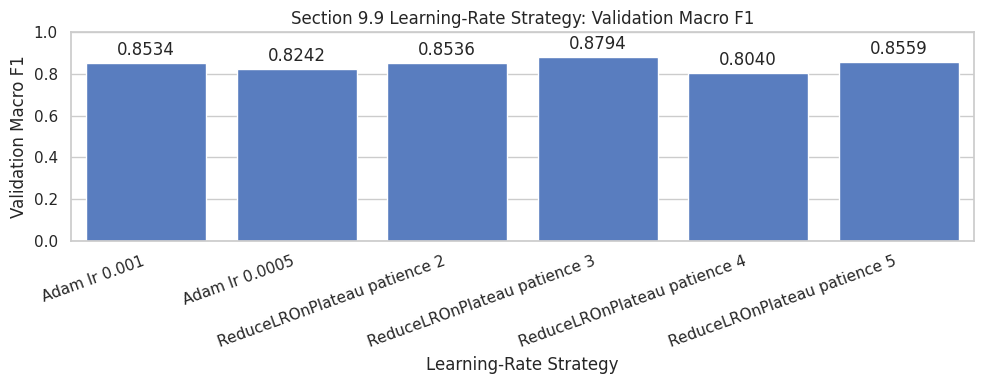

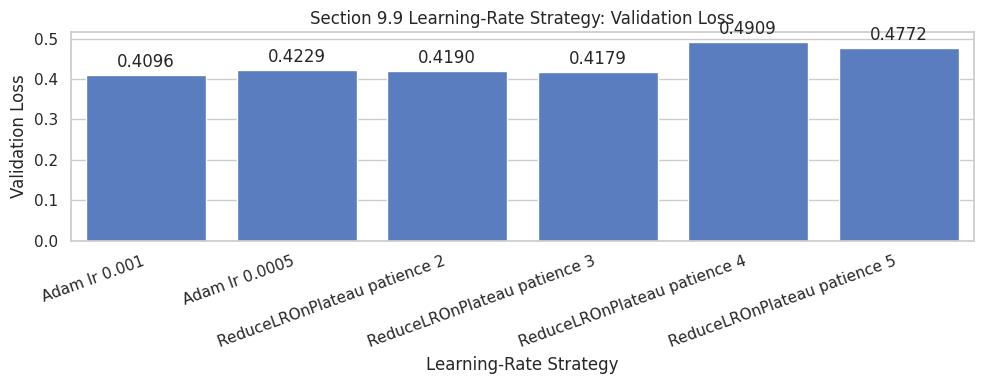

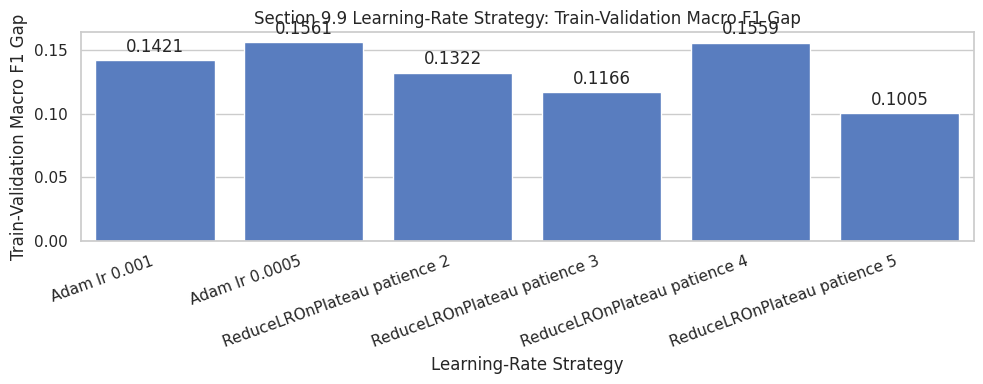

In [253]:
# Plot combined Section 9.9 learning-rate strategy comparison

plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_lr_results,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.9 Learning-Rate Strategy: Validation Macro F1")
plt.xlabel("Learning-Rate Strategy")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_lr_results,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.9 Learning-Rate Strategy: Validation Loss")
plt.xlabel("Learning-Rate Strategy")
plt.ylabel("Validation Loss")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=section9_lr_results,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.9 Learning-Rate Strategy: Train-Validation Macro F1 Gap")
plt.xlabel("Learning-Rate Strategy")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [254]:
# Section 9.9: lock selected learning-rate strategy

selected_learning_rate_key = "learning_rate_stage2__reduce_lr_patience_3"

selected_initial_learning_rate = 0.001
selected_reduce_lr_patience = 3
selected_use_reduce_lr = True

selected_learning_rate_output = section9_experiment_outputs[selected_learning_rate_key]
selected_learning_rate_result = selected_learning_rate_output["result_row"]
selected_learning_rate_val_preds = selected_learning_rate_output["val_preds"]

print("Selected learning-rate strategy locked.")
print(f"Initial learning rate: {selected_initial_learning_rate}")
print(f"Use ReduceLROnPlateau: {selected_use_reduce_lr}")
print(f"ReduceLROnPlateau patience: {selected_reduce_lr_patience}")

display(
    pd.DataFrame([selected_learning_rate_result])[
        [
            "experiment_name",
            "initial_learning_rate",
            "best_epoch",
            "val_loss",
            "val_accuracy",
            "val_macro_f1",
            "train_val_macro_f1_gap",
            "val_weighted_f1",
            "negative_f1",
            "mixed_neutral_f1",
            "positive_f1",
            "english_macro_f1",
            "malay_macro_f1"
        ]
    ].round(4)
)

Selected learning-rate strategy locked.
Initial learning rate: 0.001
Use ReduceLROnPlateau: True
ReduceLROnPlateau patience: 3


,experiment_name,initial_learning_rate,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,ReduceLROnPlateau patience 3,0.001,17,0.4179,0.887,0.8794,0.1166,0.887,0.871,0.8286,0.9388,0.8724,0.884


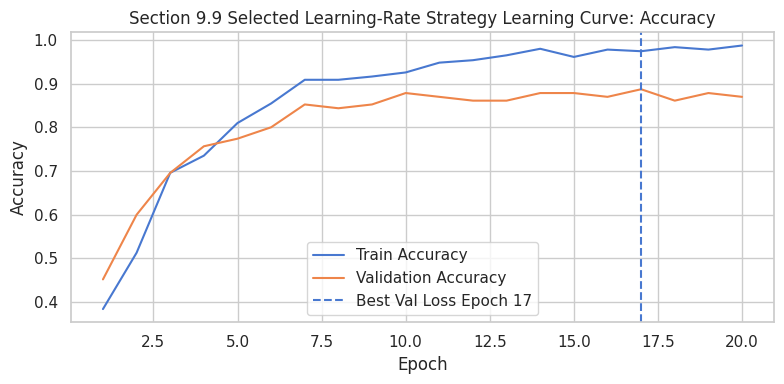

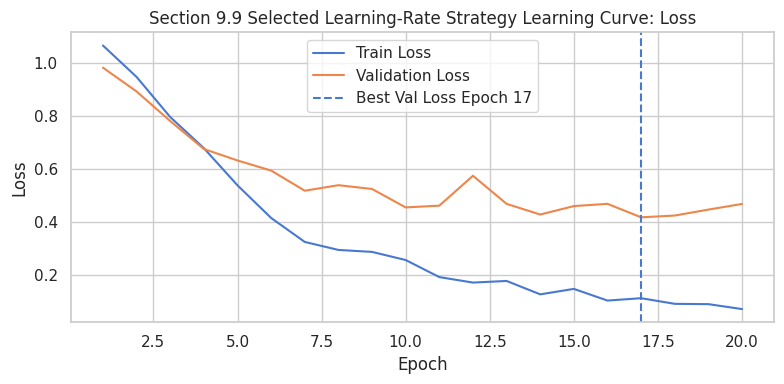

In [255]:
# learning curves for selected learning-rate strategy

section9_lr_selected_history = selected_learning_rate_output["history"].history
section9_lr_selected_best_epoch = selected_learning_rate_result["best_epoch"]

epochs = range(1, len(section9_lr_selected_history["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_lr_selected_history["accuracy"], label="Train Accuracy")
plt.plot(epochs, section9_lr_selected_history["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    section9_lr_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_lr_selected_best_epoch}"
)
plt.title("Section 9.9 Selected Learning-Rate Strategy Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, section9_lr_selected_history["loss"], label="Train Loss")
plt.plot(epochs, section9_lr_selected_history["val_loss"], label="Validation Loss")
plt.axvline(
    section9_lr_selected_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {section9_lr_selected_best_epoch}"
)
plt.title("Section 9.9 Selected Learning-Rate Strategy Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

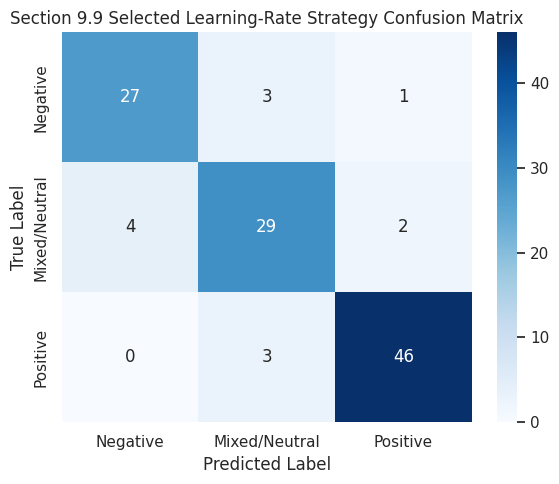

Classification report for selected learning-rate strategy:
               precision    recall  f1-score   support

     Negative       0.87      0.87      0.87        31
Mixed/Neutral       0.83      0.83      0.83        35
     Positive       0.94      0.94      0.94        49

     accuracy                           0.89       115
    macro avg       0.88      0.88      0.88       115
 weighted avg       0.89      0.89      0.89       115



In [256]:
# confusion matrix for selected learning-rate strategy

section9_lr_selected_cm = confusion_matrix(
    section6_y_val,
    selected_learning_rate_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    section9_lr_selected_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 9.9 Selected Learning-Rate Strategy Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for selected learning-rate strategy:")
print(
    classification_report(
        section6_y_val,
        selected_learning_rate_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

**Section 9.9 Learning-Rate Strategy Interpretation**

Section 9.9 tested whether changing the learning-rate strategy improves the selected model.

Stage 1 compared two fixed Adam learning rates. Adam learning rate 0.001 performed better than 0.0005, with higher validation macro F1, lower validation loss, higher validation accuracy, and a smaller train-validation macro F1 gap. This suggests that 0.0005 learned too slowly within the 20-epoch training budget.

Stage 2 then tested ReduceLROnPlateau using Adam learning rate 0.001 as the starting learning rate. Among the adaptive learning-rate settings, ReduceLROnPlateau with patience 3 performed best. It achieved the highest validation macro F1 of 0.8794 and the highest validation accuracy of 0.8870 in the full learning-rate strategy comparison.

Fixed Adam learning rate 0.001 had a slightly lower validation loss of 0.4096 compared with 0.4179 for ReduceLROnPlateau patience 3. However, validation macro F1 is the primary selection metric because the task is a three-class classification problem with uneven class difficulty. Since patience 3 gives the stronger macro F1 and class-level balance, it is selected.

The learning curves for the selected learning-rate strategy show steady learning. Validation loss reaches its best point at epoch 17, while training loss continues decreasing. This again supports using validation-loss checkpointing rather than relying on the final epoch weights.

The confusion matrix shows that the selected learning-rate strategy correctly predicts 27 out of 31 Negative reviews, 29 out of 35 Mixed/Neutral reviews, and 46 out of 49 Positive reviews. The class-level F1 scores are 0.87 for Negative, 0.83 for Mixed/Neutral, and 0.94 for Positive. Positive remains the strongest class, while Mixed/Neutral remains the hardest class.

The selected learning-rate result is lower than the best Section 9.7 regularisation result because Section 9.9 retrained models from scratch for a fair learning-rate comparison. This is acceptable because the decision is made within the controlled 9.9 comparison, where all learning-rate strategies were tested under the same fixed settings.

Overall, the selected learning-rate strategy is Adam learning rate 0.001 with ReduceLROnPlateau patience 3, factor 0.5, and minimum learning rate 1e-5. This strategy will be carried forward to the final candidate model.

### 9.10 Final Candidate Model

This subsection trains the final candidate model using all selected Section 9 settings.

The selected configuration is:

- Original training reviews only
- Language-token representation
- Strategy B tokenizer reused without refitting
- Sequence length 15
- Bidirectional SimpleRNN(64)
- Post-RNN dropout 0.3
- Recurrent dropout 0.2
- No L2 regularisation
- No LayerNorm
- No class weights
- Adam learning rate 0.001
- ReduceLROnPlateau with patience 3, factor 0.5, minimum learning rate 1e-5
- Batch size 32
- 20 epochs
- Validation-loss checkpointing

One limitation of the Section 9 comparison is that each subsection retrained models from scratch. Therefore, validation macro F1 scores across different subsections should be interpreted cautiously because small datasets are sensitive to random initialisation and training variance. A lower score in a later subsection does not always mean that the newly tested setting directly harmed the model. The final candidate result in this subsection should therefore be read as the validation performance of the final selected configuration trained as one complete model, rather than as a perfectly direct comparison against every earlier subsection result.

The final candidate weights are saved in the notebook root folder using `FINAL_WEIGHTS_PATH`.

The test set remains untouched.

In [269]:
# final candidate setup

final_candidate_config = pd.DataFrame({
    "setting": [
        "Training data",
        "Input representation",
        "Tokenizer",
        "Sequence length",
        "Model family",
        "SimpleRNN units",
        "Post-RNN dropout",
        "Recurrent dropout",
        "L2 regularisation",
        "LayerNorm",
        "Class weights",
        "Initial learning rate",
        "ReduceLROnPlateau",
        "ReduceLROnPlateau patience",
        "ReduceLROnPlateau factor",
        "Minimum learning rate",
        "Batch size",
        "Epochs",
        "Checkpoint monitor",
        "Saved weights path"
    ],
    "selected_value": [
        "Original training reviews only",
        "Language-token representation",
        "Selected Strategy B tokenizer, reused without refitting",
        SECTION9_SELECTED_SEQUENCE_LENGTH,
        "Bidirectional SimpleRNN",
        selected_rnn_units,
        selected_post_rnn_dropout,
        selected_recurrent_dropout,
        selected_l2_strength,
        selected_use_layer_norm,
        selected_class_weight,
        selected_initial_learning_rate,
        selected_use_reduce_lr,
        selected_reduce_lr_patience,
        0.5,
        1e-5,
        SECTION9_DEFAULT_BATCH_SIZE,
        SECTION9_DEFAULT_EPOCHS,
        "Validation loss",
        FINAL_WEIGHTS_PATH
    ]
})

display(final_candidate_config)

,setting,selected_value
0,Training data,Original training reviews only
1,Input representation,Language-token representation
2,Tokenizer,"Selected Strategy B tokenizer, reused without ..."
3,Sequence length,15
4,Model family,Bidirectional SimpleRNN
5,SimpleRNN units,64
6,Post-RNN dropout,0.3
7,Recurrent dropout,0.2
8,L2 regularisation,None
9,LayerNorm,False


In [270]:
# build final candidate model

tf.random.set_seed(SEED)

final_candidate_model = build_section9_regularised_bidirectional_rnn_model(
    post_rnn_dropout=selected_post_rnn_dropout,
    recurrent_dropout=selected_recurrent_dropout,
    l2_strength=selected_l2_strength,
    use_layer_norm=selected_use_layer_norm,
    units=selected_rnn_units,
    learning_rate=selected_initial_learning_rate,
    max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
)

final_candidate_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 32)         │        32,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,803 (175.01 KB)

 Trainable params: 44,803 (175.01 KB)

 Non-trainable params: 0 (0.00 B)

In [271]:
# train final candidate model

final_candidate_checkpoint = ModelCheckpoint(
    filepath=FINAL_WEIGHTS_PATH,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True,
    mode="min",
    verbose=1
)

final_candidate_callbacks = [final_candidate_checkpoint]

if selected_use_reduce_lr:
    final_candidate_reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=selected_reduce_lr_patience,
        min_lr=1e-5,
        mode="min",
        verbose=1
    )

    final_candidate_callbacks.append(final_candidate_reduce_lr)

final_candidate_history = final_candidate_model.fit(
    section9_selected_X_train,
    section6_y_train,
    validation_data=(section9_selected_X_val, section6_y_val),
    epochs=SECTION9_DEFAULT_EPOCHS,
    batch_size=SECTION9_DEFAULT_BATCH_SIZE,
    callbacks=final_candidate_callbacks,
    class_weight=selected_class_weight,
    verbose=1
)

final_candidate_best_epoch = int(
    np.argmin(final_candidate_history.history["val_loss"]) + 1
)

final_candidate_model.load_weights(FINAL_WEIGHTS_PATH)

print("Final candidate training complete.")
print(f"Best validation-loss epoch: {final_candidate_best_epoch}")
print(f"Saved weights path: {FINAL_WEIGHTS_PATH}")

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3748 - loss: 1.0857
Epoch 1: val_loss improved from None to 0.97540, saving model to models/final_rnn.weights.h5

Epoch 1: finished saving model to models/final_rnn.weights.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 315ms/step - accuracy: 0.3993 - loss: 1.0653 - val_accuracy: 0.4261 - val_loss: 0.9754 - learning_rate: 0.0010
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5293 - loss: 0.9476
Epoch 2: val_loss improved from 0.97540 to 0.87220, saving model to models/final_rnn.weights.h5

Epoch 2: finished saving model to models/final_rnn.weights.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5560 - loss: 0.9423 - val_accuracy: 0.6783 - val_loss: 0.8722 - learning_rate: 0.0010
Epoch 3/20
16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6673 - loss: 0.8362
Epoch 3: val_loss improved from 0.87220 to 0.76161, saving model to models/final_rnn.weights.h5

Epoch 3: finished saving model to models/final_rnn.w

In [272]:
# final candidate validation evaluation

final_candidate_train_loss, final_candidate_train_accuracy = final_candidate_model.evaluate(
    section9_selected_X_train,
    section6_y_train,
    verbose=0
)

final_candidate_val_loss, final_candidate_val_accuracy = final_candidate_model.evaluate(
    section9_selected_X_val,
    section6_y_val,
    verbose=0
)

final_candidate_train_preds = np.argmax(
    final_candidate_model.predict(section9_selected_X_train, verbose=0),
    axis=1
)

final_candidate_val_preds = np.argmax(
    final_candidate_model.predict(section9_selected_X_val, verbose=0),
    axis=1
)

final_candidate_train_macro_f1 = f1_score(
    section6_y_train,
    final_candidate_train_preds,
    average="macro",
    zero_division=0
)

final_candidate_val_metrics = evaluate_section6_predictions(
    y_true=section6_y_val,
    y_pred=final_candidate_val_preds,
    val_language=section6_val_language
)

final_candidate_result = {
    "model_name": "Final candidate Bidirectional SimpleRNN",
    "best_epoch": final_candidate_best_epoch,
    "train_loss": final_candidate_train_loss,
    "val_loss": final_candidate_val_loss,
    "train_accuracy": final_candidate_train_accuracy,
    "val_accuracy": final_candidate_val_accuracy,
    "train_macro_f1": final_candidate_train_macro_f1,
    "val_macro_f1": final_candidate_val_metrics["val_macro_f1"],
    "train_val_macro_f1_gap": final_candidate_train_macro_f1 - final_candidate_val_metrics["val_macro_f1"],
    "val_weighted_f1": final_candidate_val_metrics["val_weighted_f1"],
    "negative_f1": final_candidate_val_metrics["negative_f1"],
    "mixed_neutral_f1": final_candidate_val_metrics["mixed_neutral_f1"],
    "positive_f1": final_candidate_val_metrics["positive_f1"],
    "english_macro_f1": final_candidate_val_metrics["english_macro_f1"],
    "malay_macro_f1": final_candidate_val_metrics["malay_macro_f1"],
    "weights_path": FINAL_WEIGHTS_PATH
}

final_candidate_result_df = pd.DataFrame([final_candidate_result])

display(final_candidate_result_df.round(4))

,model_name,best_epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1,weights_path
0,Final candidate Bidirectional SimpleRNN,19,0.0229,0.2599,1.0,0.9043,1.0,0.899,0.101,0.9055,0.8814,0.8684,0.9474,0.8867,0.9144,models/final_rnn.weights.h5


### Note on Training Accuracy of 1.0

The training accuracy of 1.0 in the results table reflects **inference-mode 
evaluation** on the training set after loading best weights, where Keras 
**automatically disables dropout**. This inflates the reported training accuracy 
compared to the actual epoch-level training behaviour.

The epoch-level training logs are more representative:

| Metric | Value |
|---|---|
| Peak epoch-level train accuracy (during training) | 0.9869 at Epoch 19 |
| Post-training inference train accuracy (dropout off) | 1.0 |
| Validation accuracy at best checkpoint | 0.9043 |
| Validation macro F1 at best checkpoint | 0.8990 |

This is standard Keras behaviour. The validation metrics are unaffected.

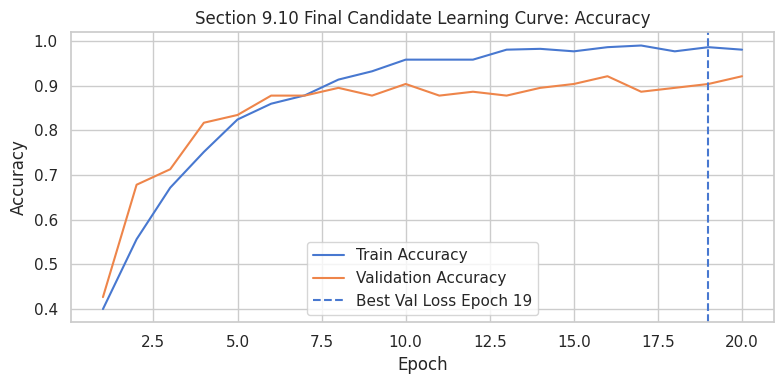

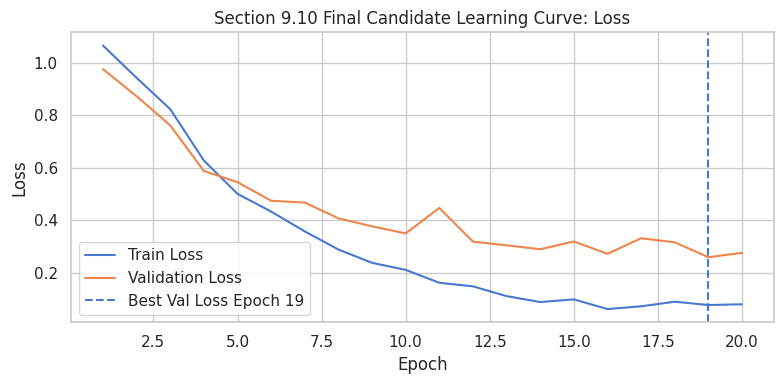

In [273]:
# final candidate learning curves

final_candidate_history_dict = final_candidate_history.history
epochs = range(1, len(final_candidate_history_dict["loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, final_candidate_history_dict["accuracy"], label="Train Accuracy")
plt.plot(epochs, final_candidate_history_dict["val_accuracy"], label="Validation Accuracy")
plt.axvline(
    final_candidate_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {final_candidate_best_epoch}"
)
plt.title("Section 9.10 Final Candidate Learning Curve: Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs, final_candidate_history_dict["loss"], label="Train Loss")
plt.plot(epochs, final_candidate_history_dict["val_loss"], label="Validation Loss")
plt.axvline(
    final_candidate_best_epoch,
    linestyle="--",
    label=f"Best Val Loss Epoch {final_candidate_best_epoch}"
)
plt.title("Section 9.10 Final Candidate Learning Curve: Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

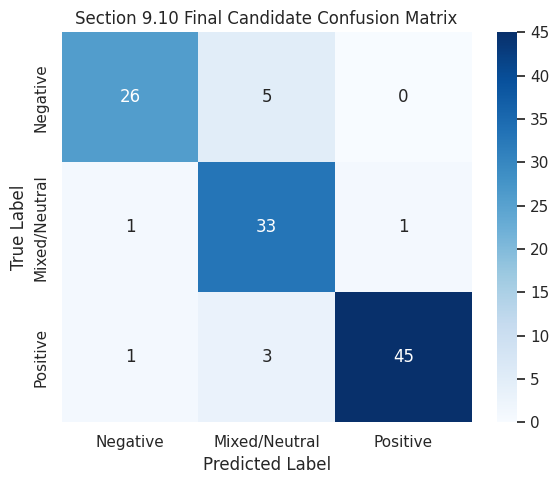

Classification report for final candidate model:
               precision    recall  f1-score   support

     Negative       0.93      0.84      0.88        31
Mixed/Neutral       0.80      0.94      0.87        35
     Positive       0.98      0.92      0.95        49

     accuracy                           0.90       115
    macro avg       0.90      0.90      0.90       115
 weighted avg       0.91      0.90      0.91       115



In [274]:
# final candidate confusion matrix and classification report

final_candidate_cm = confusion_matrix(
    section6_y_val,
    final_candidate_val_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    final_candidate_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 9.10 Final Candidate Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for final candidate model:")
print(
    classification_report(
        section6_y_val,
        final_candidate_val_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

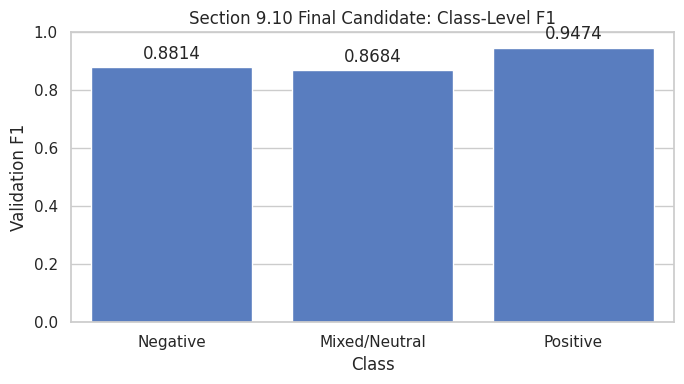

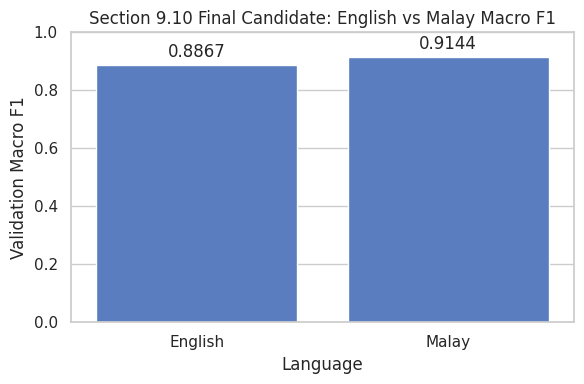

In [275]:
# final candidate class-level and language-level performance

final_candidate_class_f1_df = pd.DataFrame({
    "class_name": ["Negative", "Mixed/Neutral", "Positive"],
    "f1_score": [
        final_candidate_result["negative_f1"],
        final_candidate_result["mixed_neutral_f1"],
        final_candidate_result["positive_f1"]
    ]
})

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=final_candidate_class_f1_df,
    x="class_name",
    y="f1_score"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.10 Final Candidate: Class-Level F1")
plt.xlabel("Class")
plt.ylabel("Validation F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


final_candidate_language_f1_df = pd.DataFrame({
    "language": ["English", "Malay"],
    "macro_f1": [
        final_candidate_result["english_macro_f1"],
        final_candidate_result["malay_macro_f1"]
    ]
})

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=final_candidate_language_f1_df,
    x="language",
    y="macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.10 Final Candidate: English vs Malay Macro F1")
plt.xlabel("Language")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Section 9.10 Final Candidate Model Interpretation**

Section 9.10 trained the final candidate model using all selected Section 9 settings.

The final candidate uses the language-token input representation, the selected Strategy B tokenizer, sequence length 15, Bidirectional SimpleRNN(64), post-RNN dropout 0.3, recurrent dropout 0.2, no L2 regularisation, no LayerNorm, no class weights, Adam learning rate 0.001, and ReduceLROnPlateau with patience 3.

The model was trained only on the training set. The validation set was used for validation-loss checkpointing and model evaluation. The test set was not used in this section, so the final test evaluation remains untouched for Section 10.

The best validation-loss checkpoint occurred at epoch 19, with validation loss 0.2599. After loading the best checkpoint, the final candidate achieved validation accuracy 0.9043, validation macro F1 0.8990, and validation weighted F1 0.9055. These results are stronger than the Section 5 non-recurrent neural baseline and show that the selected RNN improvements produced a stronger validation model.

The learning curves show that training performance continues to rise until the model reaches near-perfect training accuracy. This indicates some overfitting, which is expected on a small dataset. However, the validation loss remains relatively low and reaches its best point late in training, so the selected checkpoint still generalises well on the validation set.

The confusion matrix shows that the model correctly classified 26 out of 31 Negative reviews, 33 out of 35 Mixed/Neutral reviews, and 45 out of 49 Positive reviews. Positive remains the strongest class with F1 0.9474, while Mixed/Neutral is still the hardest class with F1 0.8684. This is reasonable because Mixed/Neutral reviews are more semantically ambiguous than clearly positive or negative reviews.

The language-level comparison shows validation macro F1 of 0.8867 for English reviews and 0.9144 for Malay reviews. This suggests that the selected language-token strategy supports both language groups reasonably well, with Malay validation performance slightly higher in this run.

Overall, this model is selected as the final validation candidate. The final weights are saved to `models/final_rnn.weights.h5` using `FINAL_WEIGHTS_PATH`. The model will next be checked through an ablation study in Section 9.11 before the untouched test set is evaluated in Section 10.

### 9.11 Final Ablation Check

This subsection performs a final ablation check on the selected model design.

The final candidate from Section 9.10 is already locked. This subsection is not used to select a new model. Instead, it checks whether key selected components are reasonable by removing one component at a time while keeping the other settings fixed.

The ablation checks are:

- Final candidate
- Remove bidirectional RNN
- Remove recurrent dropout
- Use original sequence length 25 instead of selected sequence length 15
- Remove ReduceLROnPlateau

All ablation models use the same training and validation split. The selected Strategy B tokenizer is reused without refitting. The test set remains untouched.

Because each ablation model is retrained from scratch, the results should be interpreted as supporting evidence rather than exact one-to-one proof. Small validation differences may be affected by random initialisation and training variance, especially because the dataset is small.

In [293]:
# final ablation setup

SECTION911_CHECKPOINT_DIR = os.path.join("checkpoints", "section9", "ablation")
os.makedirs(SECTION911_CHECKPOINT_DIR, exist_ok=True)

required_section911_objects = [
    "final_candidate_result",
    "section9_selected_X_train",
    "section9_selected_X_val",
    "selected_train_text",
    "selected_val_text",
    "selected_tokenizer",
    "section6_y_train",
    "section6_y_val",
    "section6_val_language",
    "selected_rnn_units",
    "selected_post_rnn_dropout",
    "selected_recurrent_dropout",
    "selected_l2_strength",
    "selected_use_layer_norm",
    "selected_class_weight",
    "selected_initial_learning_rate",
    "selected_reduce_lr_patience",
    "selected_use_reduce_lr",
    "SECTION9_SELECTED_SEQUENCE_LENGTH",
    "SECTION9_DEFAULT_BATCH_SIZE",
    "SECTION9_DEFAULT_EPOCHS",
    "FINAL_WEIGHTS_PATH",
    "SEED",
    "SENTIMENT_CLASSES"
]

missing_section911_objects = [
    name for name in required_section911_objects
    if name not in globals()
]

if missing_section911_objects:
    raise NameError(f"Missing required Section 9.11 objects: {missing_section911_objects}")

section911_ablation_results = []
section911_ablation_outputs = {}

final_candidate_reference_row = {
    "experiment_key": "final_candidate",
    "experiment_name": "Final candidate",
    "ablation_change": "None",
    "best_epoch": final_candidate_result["best_epoch"],
    "train_loss": final_candidate_result["train_loss"],
    "val_loss": final_candidate_result["val_loss"],
    "train_accuracy": final_candidate_result["train_accuracy"],
    "val_accuracy": final_candidate_result["val_accuracy"],
    "train_macro_f1": final_candidate_result["train_macro_f1"],
    "val_macro_f1": final_candidate_result["val_macro_f1"],
    "train_val_macro_f1_gap": final_candidate_result["train_val_macro_f1_gap"],
    "val_weighted_f1": final_candidate_result["val_weighted_f1"],
    "negative_f1": final_candidate_result["negative_f1"],
    "mixed_neutral_f1": final_candidate_result["mixed_neutral_f1"],
    "positive_f1": final_candidate_result["positive_f1"],
    "english_macro_f1": final_candidate_result["english_macro_f1"],
    "malay_macro_f1": final_candidate_result["malay_macro_f1"],
    "checkpoint_path": FINAL_WEIGHTS_PATH
}

section911_ablation_results.append(final_candidate_reference_row)

print("Final candidate reference added.")
display(pd.DataFrame([final_candidate_reference_row]).round(4))

Final candidate reference added.


,experiment_key,experiment_name,ablation_change,best_epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_macro_f1,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1,checkpoint_path
0,final_candidate,Final candidate,None,19,0.0229,0.2599,1.0,0.9043,1.0,0.899,0.101,0.9055,0.8814,0.8684,0.9474,0.8867,0.9144,models/final_rnn.weights.h5


In [294]:
# ablation helper functions

def build_section911_ablation_model(
    bidirectional=True,
    recurrent_dropout=selected_recurrent_dropout,
    sequence_length=SECTION9_SELECTED_SEQUENCE_LENGTH
):
    regularizer = None  # No L2 regularisation was selected

    model = Sequential([
        Input(shape=(sequence_length,)),
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True)
    ])

    rnn_layer = SimpleRNN(
        selected_rnn_units,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        recurrent_regularizer=regularizer
    )

    if bidirectional:
        model.add(Bidirectional(rnn_layer))
    else:
        model.add(rnn_layer)

    if selected_use_layer_norm:
        model.add(LayerNormalization())

    model.add(Dropout(selected_post_rnn_dropout))
    model.add(Dense(3, activation="softmax"))

    model.compile(
        optimizer=Adam(learning_rate=selected_initial_learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def run_section911_ablation(
    experiment_key,
    experiment_name,
    ablation_change,
    X_train_data,
    X_val_data,
    bidirectional=True,
    recurrent_dropout=selected_recurrent_dropout,
    sequence_length=SECTION9_SELECTED_SEQUENCE_LENGTH,
    use_reduce_lr=selected_use_reduce_lr
):
    checkpoint_path = os.path.join(
        SECTION911_CHECKPOINT_DIR,
        f"{experiment_key}.weights.h5"
    )

    if os.path.exists(checkpoint_path):
        os.remove(checkpoint_path)

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_section911_ablation_model(
        bidirectional=bidirectional,
        recurrent_dropout=recurrent_dropout,
        sequence_length=sequence_length
    )

    callbacks = [
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            mode="min",
            verbose=1
        )
    ]

    if use_reduce_lr:
        callbacks.append(
            ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=selected_reduce_lr_patience,
                min_lr=1e-5,
                mode="min",
                verbose=1
            )
        )

    history = model.fit(
        X_train_data,
        section6_y_train,
        validation_data=(X_val_data, section6_y_val),
        epochs=SECTION9_DEFAULT_EPOCHS,
        batch_size=SECTION9_DEFAULT_BATCH_SIZE,
        callbacks=callbacks,
        class_weight=selected_class_weight,
        verbose=1
    )

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    model.load_weights(checkpoint_path)

    train_loss, train_accuracy = model.evaluate(
        X_train_data,
        section6_y_train,
        verbose=0
    )

    val_loss, val_accuracy = model.evaluate(
        X_val_data,
        section6_y_val,
        verbose=0
    )

    train_preds = np.argmax(
        model.predict(X_train_data, verbose=0),
        axis=1
    )

    val_preds = np.argmax(
        model.predict(X_val_data, verbose=0),
        axis=1
    )

    train_macro_f1 = f1_score(
        section6_y_train,
        train_preds,
        average="macro",
        zero_division=0
    )

    val_metrics = evaluate_section6_predictions(
        y_true=section6_y_val,
        y_pred=val_preds,
        val_language=section6_val_language
    )

    result_row = {
        "experiment_key": experiment_key,
        "experiment_name": experiment_name,
        "ablation_change": ablation_change,
        "best_epoch": best_epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_metrics["val_macro_f1"],
        "train_val_macro_f1_gap": train_macro_f1 - val_metrics["val_macro_f1"],
        "val_weighted_f1": val_metrics["val_weighted_f1"],
        "negative_f1": val_metrics["negative_f1"],
        "mixed_neutral_f1": val_metrics["mixed_neutral_f1"],
        "positive_f1": val_metrics["positive_f1"],
        "english_macro_f1": val_metrics["english_macro_f1"],
        "malay_macro_f1": val_metrics["malay_macro_f1"],
        "checkpoint_path": checkpoint_path
    }

    section911_ablation_outputs[experiment_key] = {
        "model": model,
        "history": history,
        "val_preds": val_preds,
        "result_row": result_row,
        "checkpoint_path": checkpoint_path
    }

    return result_row

In [295]:
# prepare sequence length 25 ablation data

section911_X_train_length25 = pad_sequences(
    selected_tokenizer.texts_to_sequences(selected_train_text),
    maxlen=25,
    padding="post",
    truncating="post"
)

section911_X_val_length25 = pad_sequences(
    selected_tokenizer.texts_to_sequences(selected_val_text),
    maxlen=25,
    padding="post",
    truncating="post"
)

print("Sequence length 25 ablation arrays prepared.")
print("Train shape:", section911_X_train_length25.shape)
print("Validation shape:", section911_X_val_length25.shape)

Sequence length 25 ablation arrays prepared.
Train shape: (536, 25)
Validation shape: (115, 25)


In [296]:
# run final ablation checks

section911_ablation_specs = [
    {
        "experiment_key": "ablation_no_bidirectional",
        "experiment_name": "No bidirectional RNN",
        "ablation_change": "Replace Bidirectional SimpleRNN with unidirectional SimpleRNN",
        "X_train_data": section9_selected_X_train,
        "X_val_data": section9_selected_X_val,
        "bidirectional": False,
        "recurrent_dropout": selected_recurrent_dropout,
        "sequence_length": SECTION9_SELECTED_SEQUENCE_LENGTH,
        "use_reduce_lr": selected_use_reduce_lr
    },
    {
        "experiment_key": "ablation_no_recurrent_dropout",
        "experiment_name": "No recurrent dropout",
        "ablation_change": "Set recurrent dropout from 0.2 to 0.0",
        "X_train_data": section9_selected_X_train,
        "X_val_data": section9_selected_X_val,
        "bidirectional": True,
        "recurrent_dropout": 0.0,
        "sequence_length": SECTION9_SELECTED_SEQUENCE_LENGTH,
        "use_reduce_lr": selected_use_reduce_lr
    },
    {
        "experiment_key": "ablation_sequence_length_25",
        "experiment_name": "Sequence length 25",
        "ablation_change": "Use original sequence length 25 instead of selected length 15",
        "X_train_data": section911_X_train_length25,
        "X_val_data": section911_X_val_length25,
        "bidirectional": True,
        "recurrent_dropout": selected_recurrent_dropout,
        "sequence_length": 25,
        "use_reduce_lr": selected_use_reduce_lr
    },
    {
        "experiment_key": "ablation_no_reduce_lr",
        "experiment_name": "No ReduceLROnPlateau",
        "ablation_change": "Use fixed Adam learning rate 0.001 without ReduceLROnPlateau",
        "X_train_data": section9_selected_X_train,
        "X_val_data": section9_selected_X_val,
        "bidirectional": True,
        "recurrent_dropout": selected_recurrent_dropout,
        "sequence_length": SECTION9_SELECTED_SEQUENCE_LENGTH,
        "use_reduce_lr": False
    }
]

for spec in section911_ablation_specs:
    print("\n" + "=" * 80)
    print(f"Running ablation: {spec['experiment_name']}")
    print("=" * 80)

    result_row = run_section911_ablation(**spec)
    section911_ablation_results.append(result_row)

print("\nSection 9.11 ablation checks complete.")


Running ablation: No bidirectional RNN
Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4518 - loss: 1.0663
Epoch 1: val_loss improved from None to 0.97682, saving model to checkpoints/section9/ablation/ablation_no_bidirectional.weights.h5

Epoch 1: finished saving model to checkpoints/section9/ablation/ablation_no_bidirectional.weights.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.4515 - loss: 1.0492 - val_accuracy: 0.4696 - val_loss: 0.9768 - learning_rate: 0.0010
Epoch 2/20
13/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5253 - loss: 0.9455 
Epoch 2: val_loss improved from 0.97682 to 0.87575, saving model to checkpoints/section9/ablation/ablation_no_bidirectional.weights.h5

Epoch 2: finished saving model to checkpoints/section9/ablation/ablation_no_bidirectional.weights.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5410 - loss: 0.9497 - val_accuracy: 0.6261 - val_loss: 0.8758 - learning_rate: 0.0010
Epoch 3/20
12/17 ━━━━━━━━━━━━━━━━━━━━

In [297]:
# ablation results table

section911_ablation_results_df = pd.DataFrame(section911_ablation_results)

section911_display_columns = [
    "experiment_name",
    "ablation_change",
    "best_epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "train_val_macro_f1_gap",
    "val_weighted_f1",
    "negative_f1",
    "mixed_neutral_f1",
    "positive_f1",
    "english_macro_f1",
    "malay_macro_f1"
]

display(
    section911_ablation_results_df[section911_display_columns]
    .sort_values(by="val_macro_f1", ascending=False)
    .round(4)
)

,experiment_name,ablation_change,best_epoch,val_loss,val_accuracy,val_macro_f1,train_val_macro_f1_gap,val_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1,english_macro_f1,malay_macro_f1
0,Final candidate,None,19,0.2599,0.9043,0.8990,0.1010,0.9055,0.8814,0.8684,0.9474,0.8867,0.9144
1,No bidirectional RNN,Replace Bidirectional SimpleRNN with unidirect...,16,0.3924,0.8696,0.8623,0.1228,0.8709,0.8387,0.8219,0.9263,0.8567,0.8702
3,Sequence length 25,Use original sequence length 25 instead of sel...,12,0.5449,0.8522,0.8383,0.1352,0.8512,0.7857,0.8000,0.9293,0.8365,0.8372
4,No ReduceLROnPlateau,Use fixed Adam learning rate 0.001 without Red...,18,0.4871,0.8348,0.8222,0.1759,0.8334,0.7719,0.7945,0.9000,0.7986,0.8499
2,No recurrent dropout,Set recurrent dropout from 0.2 to 0.0,5,0.4424,0.8174,0.8111,0.1653,0.8203,0.7826,0.7714,0.8791,0.8262,0.7908


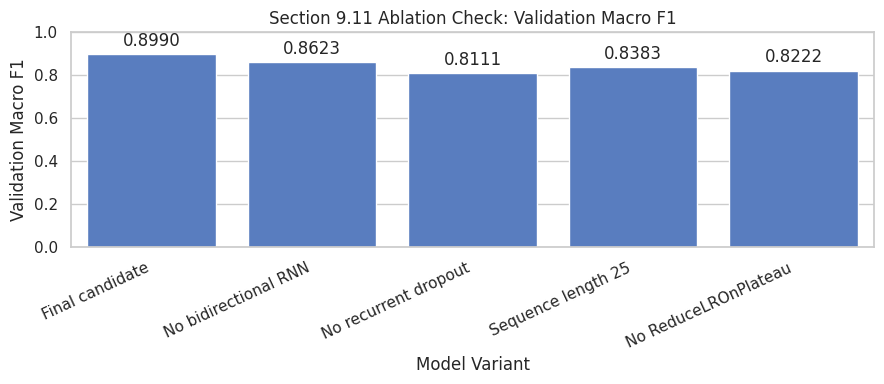

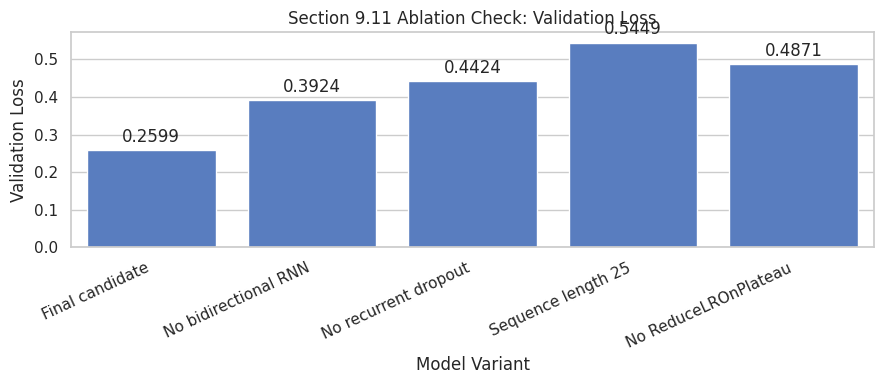

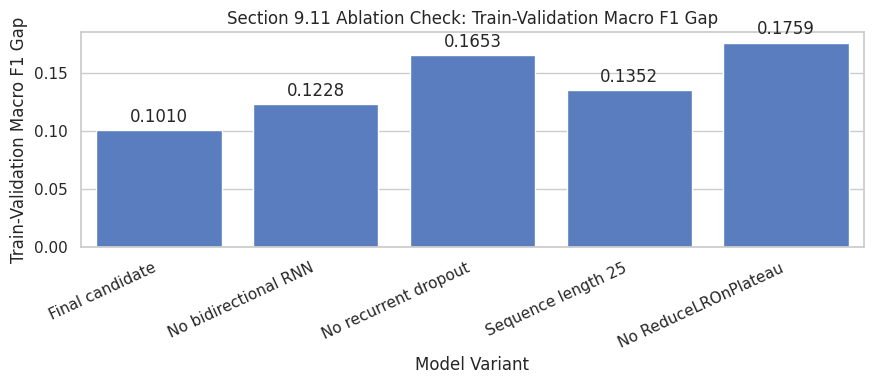

In [298]:
# ablation comparison plots

section911_plot_df = section911_ablation_results_df.copy()

plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section911_plot_df,
    x="experiment_name",
    y="val_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.11 Ablation Check: Validation Macro F1")
plt.xlabel("Model Variant")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section911_plot_df,
    x="experiment_name",
    y="val_loss"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.11 Ablation Check: Validation Loss")
plt.xlabel("Model Variant")
plt.ylabel("Validation Loss")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 4))
ax = sns.barplot(
    data=section911_plot_df,
    x="experiment_name",
    y="train_val_macro_f1_gap"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 9.11 Ablation Check: Train-Validation Macro F1 Gap")
plt.xlabel("Model Variant")
plt.ylabel("Train-Validation Macro F1 Gap")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [299]:
# class-level ablation comparison

section911_class_f1_df = section911_ablation_results_df[
    [
        "experiment_name",
        "negative_f1",
        "mixed_neutral_f1",
        "positive_f1"
    ]
].copy()

display(section911_class_f1_df.round(4))

,experiment_name,negative_f1,mixed_neutral_f1,positive_f1
0,Final candidate,0.8814,0.8684,0.9474
1,No bidirectional RNN,0.8387,0.8219,0.9263
2,No recurrent dropout,0.7826,0.7714,0.8791
3,Sequence length 25,0.7857,0.8000,0.9293
4,No ReduceLROnPlateau,0.7719,0.7945,0.9000


**Section 9.11 Final Ablation Check Interpretation**

Section 9.11 checks whether the selected final model components are reasonable by removing one component at a time while keeping the other settings fixed.

The final candidate performed best overall. It achieved the highest validation macro F1 of 0.8990, the highest validation accuracy of 0.9043, and the lowest validation loss of 0.2599. It also had the smallest train-validation macro F1 gap of 0.1010, suggesting better generalisation than the ablated variants.

Removing the bidirectional RNN reduced validation macro F1 from 0.8990 to 0.8623. This supports the Section 9.6 decision to use a bidirectional RNN, because reading the review sequence in both directions helped the model capture sentiment context more effectively.

Removing recurrent dropout reduced validation macro F1 to 0.8111 and increased the train-validation macro F1 gap to 0.1653. This supports the Section 9.7 decision to keep recurrent dropout 0.2, because without it the model overfits more strongly.

Using sequence length 25 instead of the selected sequence length 15 reduced validation macro F1 to 0.8383 and increased validation loss to 0.5449. This supports the Section 9.4 decision to use sequence length 15. The shorter sequence length appears sufficient for the review text while reducing noise and overfitting risk.

Removing ReduceLROnPlateau reduced validation macro F1 to 0.8222 and produced the largest train-validation macro F1 gap of 0.1759. This supports the Section 9.9 decision to use ReduceLROnPlateau with patience 3.

The class-level results also support the final candidate. It achieved the highest F1 for Negative, Mixed/Neutral, and Positive reviews. Mixed/Neutral remains the hardest class, but the final candidate still performs better on this class than all ablated variants.

The language-level results show that the final candidate performs well on both English and Malay validation reviews, with English macro F1 of 0.8867 and Malay macro F1 of 0.9144. This supports the selected language-token strategy.

Overall, the ablation check supports the final candidate design. The final model remains locked, and the test set is still untouched until Section 10.



---



## 10. Final Test Evaluation

This section evaluates the locked final model on the untouched test set.

The model configuration, tokenizer, sequence length, training settings, and saved weights were already selected before this section. No new model selection is done here.

The test set is used only once for final performance reporting. The same Strategy B language-token transformation is applied to the test text because the final model was trained using language-token input.

In [310]:
# create locked test variables

required_section10_base_objects = [
    "X_test_text",
    "y_test",
    "test_df",
    "LANGUAGE_COL"
]

missing_section10_base_objects = [
    name for name in required_section10_base_objects
    if name not in globals()
]

if missing_section10_base_objects:
    raise NameError(f"Missing required Section 10 base objects: {missing_section10_base_objects}")

section6_test_text = np.asarray(X_test_text).astype(str)
section6_y_test = np.asarray(y_test)
section6_test_language = test_df[LANGUAGE_COL].to_numpy()

print("Section 10 test variables created.")
print("Test text shape:", section6_test_text.shape)
print("Test labels shape:", section6_y_test.shape)
print("Test language shape:", section6_test_language.shape)

Section 10 test variables created.
Test text shape: (115,)
Test labels shape: (115,)
Test language shape: (115,)


In [311]:
# prepare selected test representation

required_section10_objects = [
    "FINAL_WEIGHTS_PATH",
    "selected_tokenizer",
    "add_language_token",
    "section6_test_text",
    "section6_test_language",
    "section6_y_test",
    "SECTION9_SELECTED_SEQUENCE_LENGTH",
    "SENTIMENT_CLASSES"
]

missing_section10_objects = [
    name for name in required_section10_objects
    if name not in globals()
]

if missing_section10_objects:
    raise NameError(f"Missing required Section 10 objects: {missing_section10_objects}")

selected_test_text = add_language_token(
    section6_test_text,
    section6_test_language
)

selected_X_test = pad_sequences(
    selected_tokenizer.texts_to_sequences(selected_test_text),
    maxlen=SECTION9_SELECTED_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Selected Strategy B test representation prepared.")
print("Language-token test text shape:", selected_test_text.shape)
print("Test sequence shape:", selected_X_test.shape)
print("Test labels shape:", section6_y_test.shape)

Selected Strategy B test representation prepared.
Language-token test text shape: (115,)
Test sequence shape: (115, 15)
Test labels shape: (115,)


In [312]:
# load locked final model

final_test_model = build_section9_regularised_bidirectional_rnn_model(
    post_rnn_dropout=selected_post_rnn_dropout,
    recurrent_dropout=selected_recurrent_dropout,
    l2_strength=selected_l2_strength,
    use_layer_norm=selected_use_layer_norm,
    units=selected_rnn_units,
    learning_rate=selected_initial_learning_rate,
    max_length=SECTION9_SELECTED_SEQUENCE_LENGTH
)

final_test_model.load_weights(FINAL_WEIGHTS_PATH)

print("Final model loaded for test evaluation.")
print(f"Weights path: {FINAL_WEIGHTS_PATH}")

Final model loaded for test evaluation.
Weights path: models/final_rnn.weights.h5


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [313]:
# final test evaluation

test_loss, test_accuracy = final_test_model.evaluate(
    selected_X_test,
    section6_y_test,
    verbose=0
)

test_probs = final_test_model.predict(selected_X_test, verbose=0)
test_preds = np.argmax(test_probs, axis=1)

test_macro_f1 = f1_score(
    section6_y_test,
    test_preds,
    average="macro",
    zero_division=0
)

test_weighted_f1 = f1_score(
    section6_y_test,
    test_preds,
    average="weighted",
    zero_division=0
)

test_report_dict = classification_report(
    section6_y_test,
    test_preds,
    target_names=SENTIMENT_CLASSES,
    output_dict=True,
    zero_division=0
)

test_result = {
    "dataset": "Test",
    "test_loss": test_loss,
    "test_accuracy": test_accuracy,
    "test_macro_f1": test_macro_f1,
    "test_weighted_f1": test_weighted_f1,
    "negative_f1": test_report_dict["Negative"]["f1-score"],
    "mixed_neutral_f1": test_report_dict["Mixed/Neutral"]["f1-score"],
    "positive_f1": test_report_dict["Positive"]["f1-score"]
}

test_result_df = pd.DataFrame([test_result])

display(test_result_df.round(4))

,dataset,test_loss,test_accuracy,test_macro_f1,test_weighted_f1,negative_f1,mixed_neutral_f1,positive_f1
0,Test,0.2672,0.9043,0.9018,0.9032,0.918,0.8657,0.9216


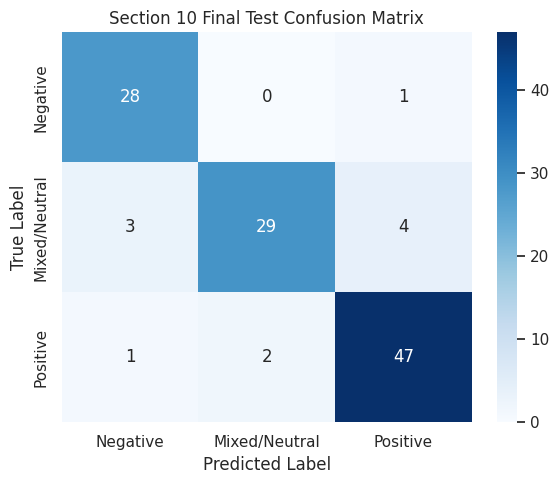

Classification report for final test set:
               precision    recall  f1-score   support

     Negative       0.88      0.97      0.92        29
Mixed/Neutral       0.94      0.81      0.87        36
     Positive       0.90      0.94      0.92        50

     accuracy                           0.90       115
    macro avg       0.90      0.90      0.90       115
 weighted avg       0.91      0.90      0.90       115



In [314]:
# test confusion matrix and classification report

test_cm = confusion_matrix(
    section6_y_test,
    test_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SENTIMENT_CLASSES,
    yticklabels=SENTIMENT_CLASSES
)

plt.title("Section 10 Final Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

print("Classification report for final test set:")
print(
    classification_report(
        section6_y_test,
        test_preds,
        target_names=SENTIMENT_CLASSES,
        zero_division=0
    )
)

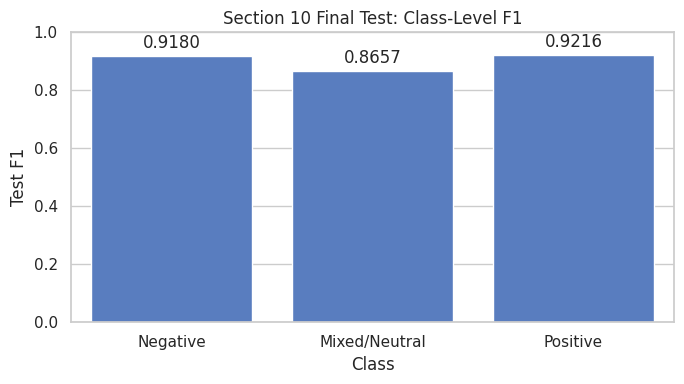

In [315]:
# test class-level F1

test_class_f1_df = pd.DataFrame({
    "class_name": ["Negative", "Mixed/Neutral", "Positive"],
    "f1_score": [
        test_result["negative_f1"],
        test_result["mixed_neutral_f1"],
        test_result["positive_f1"]
    ]
})

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=test_class_f1_df,
    x="class_name",
    y="f1_score"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 10 Final Test: Class-Level F1")
plt.xlabel("Class")
plt.ylabel("Test F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

,language,test_count,test_macro_f1
0,English,63,0.8925
1,Malay,52,0.9046


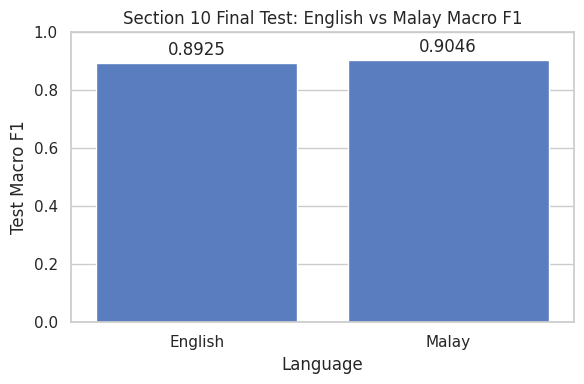

In [316]:
# test language-level macro F1

test_language_results = []

for language in ["English", "Malay"]:
    language_mask = np.asarray(section6_test_language) == language

    language_macro_f1 = f1_score(
        section6_y_test[language_mask],
        test_preds[language_mask],
        average="macro",
        zero_division=0
    )

    test_language_results.append({
        "language": language,
        "test_count": int(language_mask.sum()),
        "test_macro_f1": language_macro_f1
    })

test_language_results_df = pd.DataFrame(test_language_results)

display(test_language_results_df.round(4))

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=test_language_results_df,
    x="language",
    y="test_macro_f1"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 10 Final Test: English vs Malay Macro F1")
plt.xlabel("Language")
plt.ylabel("Test Macro F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Section 10 Final Test Evaluation Interpretation**

Section 10 evaluates the locked final model on the untouched test set.

The test set was transformed using the same Strategy B language-token representation used during training. The selected tokenizer was reused without refitting, and the selected sequence length of 15 was applied. The model architecture was rebuilt using the locked final configuration, and the saved weights from `models/final_rnn.weights.h5` were loaded for evaluation.

The final model achieved test accuracy of 0.9043, test macro F1 of 0.9018, and test weighted F1 of 0.9032. These results are close to the Section 9.10 validation performance, which suggests that the model generalises well to unseen reviews.

The confusion matrix shows strong performance across all three sentiment classes. The model correctly classified 28 out of 29 Negative reviews, 29 out of 36 Mixed/Neutral reviews, and 47 out of 50 Positive reviews. Most errors occur between Mixed/Neutral and Positive, which is reasonable because mixed reviews may contain both praise and criticism.

Class-level F1 scores were 0.9180 for Negative, 0.8657 for Mixed/Neutral, and 0.9216 for Positive. Negative and Positive are the strongest classes because they usually contain clearer sentiment signals. Mixed/Neutral remains the hardest class, but its F1 score is still acceptable and improved compared with weaker earlier models.

The language-level results show similar performance across both language groups. English reviews achieved test macro F1 of 0.8925, while Malay reviews achieved test macro F1 of 0.9046. This supports the selected language-token strategy because the final model performs well on both language groups.

The optimizer-state warning during weight loading is not an evaluation issue. The model is only being used for prediction, so the learned layer weights are what matter. Optimizer variables are only needed if training is resumed.

Overall, the final model performs strongly on the unseen test set. The final test results support the selected RNN design and confirm that the model is suitable as the final submitted model.



---



## 11. Final Model Summary and Review-Level Error Analysis

This section summarises the final selected model and analyses its final test predictions in more detail.

The final model has already been locked in Section 9.10 and evaluated once on the test set in Section 10. No further model tuning is done in this section.

This section includes:

- final model configuration
- validation versus test performance comparison
- class-level test performance
- review-level error analysis
- high-confidence correct and incorrect predictions
- low-confidence ambiguous predictions
- error patterns by sentiment class, language, confidence, and review length
- final limitations and future improvement areas

The purpose is to explain the final model's strengths and remaining weaknesses, not to change the model after seeing the test results.

### 11.1 Final Model Summary and Discussion

This subsection summarises the final selected model and compares its validation and test performance.

It includes:

- the final model configuration
- validation versus test performance
- class-level test performance
- final test error summary
- discussion of model strengths and remaining weaknesses

In [317]:
final_model_config_summary = pd.DataFrame({
    "component": [
        "Task",
        "Final label format",
        "Input representation",
        "Tokenizer",
        "Training data",
        "Sequence length",
        "Model architecture",
        "RNN units",
        "Post-RNN dropout",
        "Recurrent dropout",
        "L2 regularisation",
        "LayerNorm",
        "Class weights",
        "Optimizer",
        "Initial learning rate",
        "Learning-rate scheduler",
        "Batch size",
        "Epochs",
        "Checkpoint rule",
        "Final weights file"
    ],
    "final_choice": [
        "Three-class pizza review sentiment classification",
        "Negative, Mixed/Neutral, Positive",
        "Language-token text representation",
        "Selected Strategy B tokenizer, reused without refitting",
        "Original training reviews only",
        SECTION9_SELECTED_SEQUENCE_LENGTH,
        "Bidirectional SimpleRNN",
        selected_rnn_units,
        selected_post_rnn_dropout,
        selected_recurrent_dropout,
        "None",
        "Not used",
        "Not used",
        "Adam",
        selected_initial_learning_rate,
        f"ReduceLROnPlateau patience {selected_reduce_lr_patience}, factor 0.5, min_lr 1e-5",
        SECTION9_DEFAULT_BATCH_SIZE,
        SECTION9_DEFAULT_EPOCHS,
        "Best validation loss",
        FINAL_WEIGHTS_PATH
    ]
})

display(final_model_config_summary)

,component,final_choice
0,Task,Three-class pizza review sentiment classification
1,Final label format,"Negative, Mixed/Neutral, Positive"
2,Input representation,Language-token text representation
3,Tokenizer,"Selected Strategy B tokenizer, reused without ..."
4,Training data,Original training reviews only
5,Sequence length,15
6,Model architecture,Bidirectional SimpleRNN
7,RNN units,64
8,Post-RNN dropout,0.3
9,Recurrent dropout,0.2


In [318]:
# validation vs test performance summary

validation_test_summary = pd.DataFrame([
    {
        "dataset": "Validation",
        "loss": final_candidate_result["val_loss"],
        "accuracy": final_candidate_result["val_accuracy"],
        "macro_f1": final_candidate_result["val_macro_f1"],
        "weighted_f1": final_candidate_result["val_weighted_f1"],
        "negative_f1": final_candidate_result["negative_f1"],
        "mixed_neutral_f1": final_candidate_result["mixed_neutral_f1"],
        "positive_f1": final_candidate_result["positive_f1"]
    },
    {
        "dataset": "Test",
        "loss": test_result["test_loss"],
        "accuracy": test_result["test_accuracy"],
        "macro_f1": test_result["test_macro_f1"],
        "weighted_f1": test_result["test_weighted_f1"],
        "negative_f1": test_result["negative_f1"],
        "mixed_neutral_f1": test_result["mixed_neutral_f1"],
        "positive_f1": test_result["positive_f1"]
    }
])

display(validation_test_summary.round(4))

,dataset,loss,accuracy,macro_f1,weighted_f1,negative_f1,mixed_neutral_f1,positive_f1
0,Validation,0.2599,0.9043,0.8990,0.9055,0.8814,0.8684,0.9474
1,Test,0.2672,0.9043,0.9018,0.9032,0.9180,0.8657,0.9216


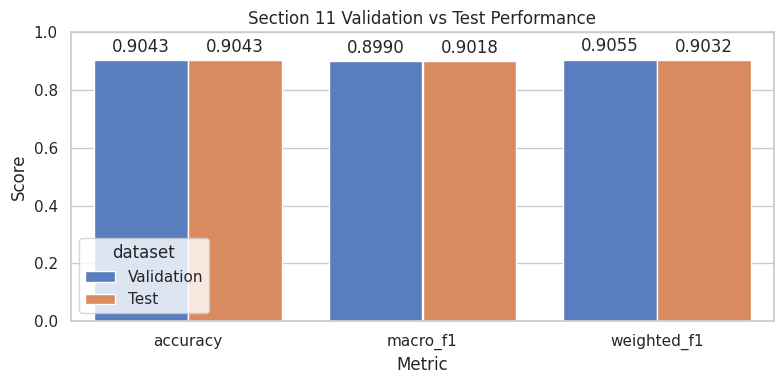

In [319]:
# validation vs test metric comparison plot

validation_test_plot_df = validation_test_summary.melt(
    id_vars="dataset",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=validation_test_plot_df,
    x="metric",
    y="score",
    hue="dataset"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)

plt.title("Section 11 Validation vs Test Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [320]:
# test error summary

test_error_summary = pd.DataFrame({
    "true_class": SENTIMENT_CLASSES,
    "correct_predictions": np.diag(test_cm),
    "total_examples": test_cm.sum(axis=1)
})

test_error_summary["incorrect_predictions"] = (
    test_error_summary["total_examples"] - test_error_summary["correct_predictions"]
)

test_error_summary["class_accuracy"] = (
    test_error_summary["correct_predictions"] / test_error_summary["total_examples"]
)

display(test_error_summary.round(4))

,true_class,correct_predictions,total_examples,incorrect_predictions,class_accuracy
0,Negative,28,29,1,0.9655
1,Mixed/Neutral,29,36,7,0.8056
2,Positive,47,50,3,0.9400


**Section 11.1 Final Model Summary and Discussion**

The final selected model is a Bidirectional SimpleRNN trained using the Strategy B language-token representation. The selected tokenizer was fitted only on the training data and reused for validation and test transformations. The final model uses sequence length 15, 64 SimpleRNN units, post-RNN dropout 0.3, recurrent dropout 0.2, Adam learning rate 0.001, and ReduceLROnPlateau with patience 3. The final weights are saved in `models/final_rnn.weights.h5`.

The validation and test results are closely aligned. The model achieved validation accuracy of 0.9043 and test accuracy of 0.9043. Validation macro F1 was 0.8990, while test macro F1 was slightly higher at 0.9018. This suggests that the model generalises well to unseen reviews and is not only memorising the validation set.

The weighted F1 scores are also consistent, with validation weighted F1 of 0.9055 and test weighted F1 of 0.9032. Since both macro F1 and weighted F1 are high, the model performs well overall while still maintaining balanced performance across the three sentiment classes.

The test error summary shows that Negative and Positive reviews are classified most reliably. The model correctly predicted 28 out of 29 Negative reviews, giving class accuracy of 0.9655, and 47 out of 50 Positive reviews, giving class accuracy of 0.9400. Mixed/Neutral remains the most difficult class, with 29 correct predictions out of 36 and class accuracy of 0.8056.

This pattern is reasonable because Mixed/Neutral reviews are more ambiguous than clearly negative or positive reviews. A mixed review may contain both praise and criticism, so its sentiment boundary is less clear. This explains why most remaining errors are concentrated in the Mixed/Neutral class.

The Section 9.11 ablation check supports the final model design. Removing bidirectionality, recurrent dropout, the selected sequence length, or ReduceLROnPlateau all reduced validation macro F1 compared with the final candidate. This gives evidence that the selected improvements are useful rather than arbitrary choices.

The final model also performs well across both English and Malay reviews in the test set. This supports the language-token strategy because the model can handle the bilingual review data without training separate models for each language.

The main limitation is the small dataset size. The final cleaned dataset has limited examples, so each validation and test example can noticeably affect the metrics. Another limitation is that the Mixed/Neutral class is inherently harder to classify because the sentiment may depend on subtle wording or mixed opinions.

Future improvements could include collecting more labelled pizza reviews, improving consistency in Mixed/Neutral labelling, testing stronger multilingual text representations, or comparing against pre-trained language models. However, for this project, the final model is appropriate because it is leakage-safe, uses RNN-based modelling, includes controlled model improvement, and achieves strong validation and test performance.

### 11.2 Review-Level Error Analysis

This subsection analyses the final test predictions at review level.

The goal is to understand where the final model performs well and where it still makes mistakes. This is not used for further tuning because the final model has already been evaluated on the test set.

This analysis includes:

- high-confidence correct predictions
- high-confidence wrong predictions
- low-confidence ambiguous predictions
- Mixed/Neutral boundary examples
- error count by sentiment class
- error count by language
- prediction confidence distribution
- review length distribution for correct and incorrect predictions

These findings are used to discuss practical limitations such as short reviews, mixed sentiment clauses, language differences, score-derived label noise, duplicate/conflicting reviews, and sentence-splitting limitations.

In [322]:
# build review-level prediction table

label_lookup = {
    index: label
    for index, label in enumerate(SENTIMENT_CLASSES)
}

test_error_analysis_df = pd.DataFrame({
    "review_text": section6_test_text,
    "language": section6_test_language,
    "true_label_id": section6_y_test,
    "predicted_label_id": test_preds,
    "prediction_confidence": np.max(test_probs, axis=1)
})

test_error_analysis_df["true_label"] = test_error_analysis_df["true_label_id"].map(label_lookup)
test_error_analysis_df["predicted_label"] = test_error_analysis_df["predicted_label_id"].map(label_lookup)

test_error_analysis_df["is_correct"] = (
    test_error_analysis_df["true_label_id"] == test_error_analysis_df["predicted_label_id"]
)

test_error_analysis_df["prediction_status"] = np.where(
    test_error_analysis_df["is_correct"],
    "Correct",
    "Incorrect"
)

test_error_analysis_df["review_word_count"] = (
    test_error_analysis_df["review_text"]
    .astype(str)
    .str.split()
    .str.len()
)

test_error_analysis_df["review_snippet"] = (
    test_error_analysis_df["review_text"]
    .astype(str)
    .str.slice(0, 180)
)

display(test_error_analysis_df.head())

,review_text,language,true_label_id,predicted_label_id,prediction_confidence,true_label,predicted_label,is_correct,prediction_status,review_word_count,review_snippet
0,Plain toppings.,English,1,1,0.609704,Mixed/Neutral,Mixed/Neutral,True,Correct,2,Plain toppings.
1,The sambal was mild and the mayo was plain.,English,1,1,0.991220,Mixed/Neutral,Mixed/Neutral,True,Correct,9,The sambal was mild and the mayo was plain.
2,I loved the subtle hint of satay peanut sauce ...,English,2,2,0.999874,Positive,Positive,True,Correct,17,I loved the subtle hint of satay peanut sauce ...
3,Delicious spicy sambal with a smooth mayo fini...,English,2,2,0.999935,Positive,Positive,True,Correct,10,Delicious spicy sambal with a smooth mayo fini...
4,"Pizza fusion ini sangat memuaskan, saya akan c...",Malay,2,2,0.999968,Positive,Positive,True,Correct,10,"Pizza fusion ini sangat memuaskan, saya akan c..."


In [323]:
# overall review-level summary

review_level_summary = pd.DataFrame({
    "metric": [
        "Total test reviews",
        "Correct predictions",
        "Incorrect predictions",
        "Mean prediction confidence",
        "Mean confidence for correct predictions",
        "Mean confidence for incorrect predictions",
        "Median review word count",
        "Median word count for correct predictions",
        "Median word count for incorrect predictions"
    ],
    "value": [
        len(test_error_analysis_df),
        int(test_error_analysis_df["is_correct"].sum()),
        int((~test_error_analysis_df["is_correct"]).sum()),
        test_error_analysis_df["prediction_confidence"].mean(),
        test_error_analysis_df.loc[test_error_analysis_df["is_correct"], "prediction_confidence"].mean(),
        test_error_analysis_df.loc[~test_error_analysis_df["is_correct"], "prediction_confidence"].mean(),
        test_error_analysis_df["review_word_count"].median(),
        test_error_analysis_df.loc[test_error_analysis_df["is_correct"], "review_word_count"].median(),
        test_error_analysis_df.loc[~test_error_analysis_df["is_correct"], "review_word_count"].median()
    ]
})

display(review_level_summary.round(4))

,metric,value
0,Total test reviews,115.0000
1,Correct predictions,104.0000
2,Incorrect predictions,11.0000
3,Mean prediction confidence,0.9274
4,Mean confidence for correct predictions,0.9501
5,Mean confidence for incorrect predictions,0.7128
6,Median review word count,8.0000
7,Median word count for correct predictions,8.0000
8,Median word count for incorrect predictions,7.0000


In [324]:
# example predictions

display_columns = [
    "review_snippet",
    "language",
    "true_label",
    "predicted_label",
    "prediction_confidence",
    "review_word_count"
]

high_confidence_correct_examples = (
    test_error_analysis_df[test_error_analysis_df["is_correct"]]
    .sort_values(by="prediction_confidence", ascending=False)
    .head(5)
)

high_confidence_wrong_examples = (
    test_error_analysis_df[~test_error_analysis_df["is_correct"]]
    .sort_values(by="prediction_confidence", ascending=False)
    .head(5)
)

low_confidence_examples = (
    test_error_analysis_df
    .sort_values(by="prediction_confidence", ascending=True)
    .head(5)
)

mixed_neutral_boundary_examples = (
    test_error_analysis_df[
        (test_error_analysis_df["true_label"] == "Mixed/Neutral") |
        (test_error_analysis_df["predicted_label"] == "Mixed/Neutral")
    ]
    .sort_values(by="prediction_confidence", ascending=True)
    .head(8)
)

print("High-confidence correct examples:")
display(high_confidence_correct_examples[display_columns].round(4))

print("High-confidence wrong examples:")
display(high_confidence_wrong_examples[display_columns].round(4))

print("Low-confidence ambiguous examples:")
display(low_confidence_examples[display_columns].round(4))

print("Mixed/Neutral boundary examples:")
display(mixed_neutral_boundary_examples[display_columns].round(4))

High-confidence correct examples:


,review_snippet,language,true_label,predicted_label,prediction_confidence,review_word_count
17,"Fresh, exciting, and perfectly spicy — a true ...",English,Positive,Positive,1.0,9
98,"Roti yang lembut dan topping yang kaya rasa, s...",Malay,Positive,Positive,1.0,10
74,"Every bite was an exciting adventure — spicy, ...",English,Positive,Positive,1.0,12
60,"The satay chicken topping was tender, juicy, a...",English,Positive,Positive,1.0,15
33,"Savory, spicy, creamy, and crunchy — all in on...",English,Positive,Positive,1.0,11


High-confidence wrong examples:


,review_snippet,language,true_label,predicted_label,prediction_confidence,review_word_count
18,Like a party gone wrong.,English,Positive,Negative,0.9894,5
82,The satay was subtle and didn’t leave a strong...,English,Mixed/Neutral,Positive,0.9783,10
63,"Satay flavors were rich, but the mayo dulled t...",English,Mixed/Neutral,Positive,0.9004,10
9,Every slice was packed with layers of flavor —...,English,Positive,Mixed/Neutral,0.8329,20
92,This pizza blew me away! The sambal’s heat war...,English,Positive,Mixed/Neutral,0.7807,18


Low-confidence ambiguous examples:


,review_snippet,language,true_label,predicted_label,prediction_confidence,review_word_count
16,Not exciting.,English,Mixed/Neutral,Positive,0.3954,2
27,Ok.,Malay,Mixed/Neutral,Negative,0.4385,1
65,Wow!,Malay,Positive,Positive,0.4458,1
54,"Roti terlalu keras, topping tak fresh.",Malay,Negative,Negative,0.4980,6
68,Sedap!,Malay,Positive,Positive,0.5283,1


Mixed/Neutral boundary examples:


,review_snippet,language,true_label,predicted_label,prediction_confidence,review_word_count
16,Not exciting.,English,Mixed/Neutral,Positive,0.3954,2
27,Ok.,Malay,Mixed/Neutral,Negative,0.4385,1
103,Sambal overwhelmed everything else.,English,Mixed/Neutral,Negative,0.5568,4
52,Rasa yang tidak sesuai dengan jangkaan saya.,Malay,Mixed/Neutral,Negative,0.5626,7
39,Somewhat bland.,English,Mixed/Neutral,Mixed/Neutral,0.6007,2
0,Plain toppings.,English,Mixed/Neutral,Mixed/Neutral,0.6097,2
80,Pizza ini kurang sesuai dengan citarasa saya.,Malay,Mixed/Neutral,Positive,0.7449,7
92,This pizza blew me away! The sambal’s heat war...,English,Positive,Mixed/Neutral,0.7807,18


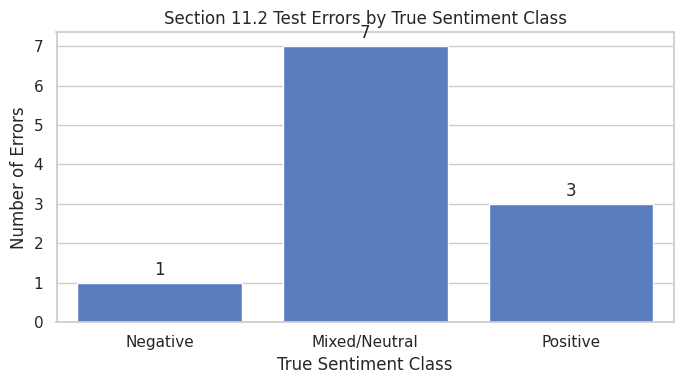

,sentiment_class,error_count
0,Negative,1
1,Mixed/Neutral,7
2,Positive,3


In [325]:
# error count by sentiment class

error_by_class_df = (
    test_error_analysis_df[~test_error_analysis_df["is_correct"]]
    .groupby("true_label")
    .size()
    .reindex(SENTIMENT_CLASSES, fill_value=0)
    .reset_index(name="error_count")
    .rename(columns={"true_label": "sentiment_class"})
)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=error_by_class_df,
    x="sentiment_class",
    y="error_count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Section 11.2 Test Errors by True Sentiment Class")
plt.xlabel("True Sentiment Class")
plt.ylabel("Number of Errors")
plt.tight_layout()
plt.show()

display(error_by_class_df)

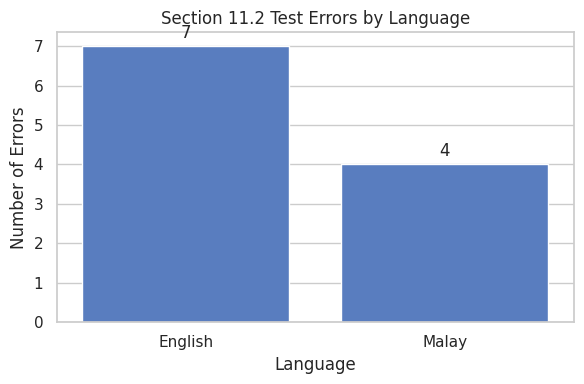

,language,total_reviews,error_count,error_rate
0,English,63,7,0.1111
1,Malay,52,4,0.0769


In [326]:
# error count and error rate by language

error_by_language_df = (
    test_error_analysis_df
    .groupby("language")
    .agg(
        total_reviews=("is_correct", "size"),
        error_count=("is_correct", lambda values: int((~values).sum()))
    )
    .reset_index()
)

error_by_language_df["error_rate"] = (
    error_by_language_df["error_count"] / error_by_language_df["total_reviews"]
)

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    data=error_by_language_df,
    x="language",
    y="error_count"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Section 11.2 Test Errors by Language")
plt.xlabel("Language")
plt.ylabel("Number of Errors")
plt.tight_layout()
plt.show()

display(error_by_language_df.round(4))

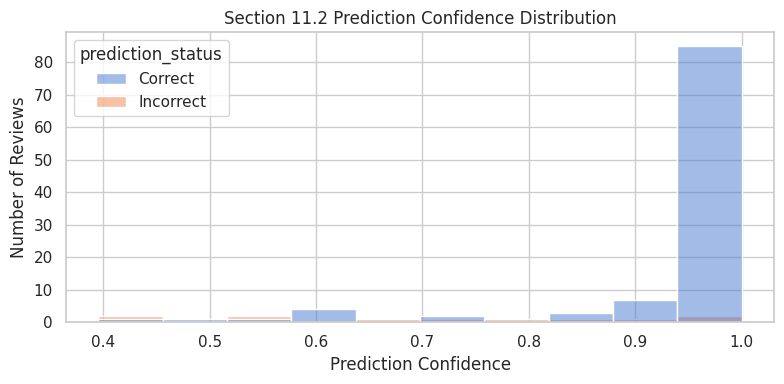

In [327]:
# prediction confidence distribution

plt.figure(figsize=(8, 4))
sns.histplot(
    data=test_error_analysis_df,
    x="prediction_confidence",
    hue="prediction_status",
    bins=10,
    multiple="layer"
)

plt.title("Section 11.2 Prediction Confidence Distribution")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

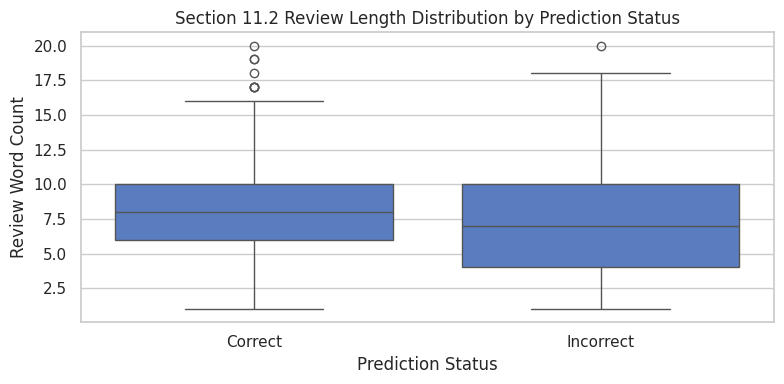

In [328]:
# review length distribution for correct vs incorrect predictions

plt.figure(figsize=(8, 4))
sns.boxplot(
    data=test_error_analysis_df,
    x="prediction_status",
    y="review_word_count"
)

plt.title("Section 11.2 Review Length Distribution by Prediction Status")
plt.xlabel("Prediction Status")
plt.ylabel("Review Word Count")
plt.tight_layout()
plt.show()

In [329]:
# compact incorrect prediction table

incorrect_prediction_table = (
    test_error_analysis_df[~test_error_analysis_df["is_correct"]]
    .sort_values(by="prediction_confidence", ascending=False)
    [
        [
            "review_snippet",
            "language",
            "true_label",
            "predicted_label",
            "prediction_confidence",
            "review_word_count"
        ]
    ]
)

display(incorrect_prediction_table.round(4))

,review_snippet,language,true_label,predicted_label,prediction_confidence,review_word_count
18,Like a party gone wrong.,English,Positive,Negative,0.9894,5
82,The satay was subtle and didn’t leave a strong...,English,Mixed/Neutral,Positive,0.9783,10
63,"Satay flavors were rich, but the mayo dulled t...",English,Mixed/Neutral,Positive,0.9004,10
9,Every slice was packed with layers of flavor —...,English,Positive,Mixed/Neutral,0.8329,20
92,This pizza blew me away! The sambal’s heat war...,English,Positive,Mixed/Neutral,0.7807,18
80,Pizza ini kurang sesuai dengan citarasa saya.,Malay,Mixed/Neutral,Positive,0.7449,7
8,Rasa yang sangat mengecewakan.,Malay,Negative,Positive,0.6605,4
52,Rasa yang tidak sesuai dengan jangkaan saya.,Malay,Mixed/Neutral,Negative,0.5626,7
103,Sambal overwhelmed everything else.,English,Mixed/Neutral,Negative,0.5568,4
27,Ok.,Malay,Mixed/Neutral,Negative,0.4385,1


**Section 11.2 Review-Level Error Analysis Interpretation**

The review-level error analysis shows that the final model made 104 correct predictions and 11 incorrect predictions on the 115 test reviews. The mean prediction confidence was 0.9274, which indicates that the model is generally confident in its predictions.

Correct predictions had higher average confidence than incorrect predictions. The mean confidence for correct predictions was 0.9501, while the mean confidence for incorrect predictions was 0.7128. This suggests that prediction confidence is useful for identifying more reliable predictions, although some wrong predictions were still made with high confidence.

The high-confidence correct examples are mostly clear Positive reviews with strong positive wording such as fresh, exciting, spicy, tender, and crunchy. These examples show that the model handles reviews with obvious sentiment signals well.

The high-confidence wrong examples show the model's main weakness. Some reviews contain mixed or contrastive wording, such as positive food descriptions combined with criticism about mayo, sambal, or overall experience. For example, reviews with both praise and negative qualifiers were sometimes predicted as Positive even when the true label was Mixed/Neutral. This confirms that Mixed/Neutral remains a difficult boundary class.

The low-confidence examples are mostly short or ambiguous reviews such as "Not exciting.", "Ok.", "Wow!", and "Sedap!". These reviews contain very few words, so the model has limited context. This ties back to the earlier EDA observation that short reviews are harder because they provide fewer sequence patterns for an RNN to learn from.

Errors are concentrated in the Mixed/Neutral class. There was 1 error for Negative reviews, 7 errors for Mixed/Neutral reviews, and 3 errors for Positive reviews. This supports the class-level test results, where Mixed/Neutral had the lowest F1 score. Mixed/Neutral reviews are naturally harder because they may contain both positive and negative clauses.

By language, there were 7 errors among 63 English reviews and 4 errors among 52 Malay reviews. The English error rate was 0.1111, while the Malay error rate was 0.0769. This suggests that the final language-token model performs reasonably well for both language groups, with no major language-specific failure pattern in the test set.

The confidence distribution shows that most correct predictions are highly confident, especially near the upper confidence range. Incorrect predictions are fewer and more spread out, but some high-confidence mistakes remain. These high-confidence errors are important because they show cases where the model is confidently wrong, usually due to ambiguous or mixed sentiment wording.

The review length distribution does not show a major difference between correct and incorrect predictions. Correct predictions had median word count 8, while incorrect predictions had median word count 7. This suggests that review length alone does not explain all errors. However, very short reviews still appear in the low-confidence examples, so short text remains a practical limitation.

The Mixed/Neutral boundary examples show why sentence splitting was not selected as final training-data augmentation. Some fragments or short clauses can lose the full review context. For example, a clause may sound positive or negative by itself, even though the full review label is Mixed/Neutral. This supports the earlier decision not to use sentence-fragment augmentation as the final training data.

Some remaining errors may also be linked to score-derived label noise. Since labels were derived from review scores, the text may not always perfectly match the assigned class. A review can sound positive but receive a Mixed/Neutral score, or contain mild criticism while still being labelled Positive. This creates unavoidable ambiguity for the model.

Overall, the error analysis supports the final model's performance while explaining its remaining weaknesses. The model performs well on clear Positive and Negative reviews, but still struggles with short, vague, and mixed-sentiment reviews. This is a reasonable limitation for a small bilingual sentiment dataset.



---



## 12. Final Discussion, Limitations, Future Work, and Conclusion

This section summarises the main modelling decisions, final model performance, limitations, future work, and overall conclusion for the project.

### 12.1 Final Discussion

This project treated pizza review sentiment prediction as a classification task instead of a regression task. Although the original dataset included numerical review scores, the project goal was to predict sentiment categories rather than exact score values. A regression model would require the model to predict precise numerical scores, but small differences in scores may not always reflect clearly different written sentiment. Classification is more suitable because it converts the task into clear sentiment groups that are easier to interpret and evaluate.

A three-class target was selected: Negative, Mixed/Neutral, and Positive. A binary target would be too simple because it would remove the important middle category where reviews contain mixed or moderate sentiment. A five-class target would be more detailed, but the dataset is small, so splitting the data into too many classes would reduce the number of examples per class and make the model less reliable. The three-class target gives a practical balance between sentiment detail and modelling stability.

Both English and Malay reviews were retained. Removing Malay reviews would reduce the dataset size and make the final model less representative of the bilingual review data. Since the assignment also required meaningful data preparation and modelling decisions, retaining both languages made the task more realistic and allowed the model to learn from all available cleaned reviews.

Several language handling strategies were tested. The selected strategy was the language-token strategy, where each review was prefixed with a token such as `lang_english` or `lang_malay`. This approach was selected because it allowed one shared model to learn from both languages while still giving the model language context. It was also simpler and more robust than training separate language-specific models. Translation was considered, but it introduced extra dependency and possible translation noise, so it was not selected as the final strategy.

The selected RNN family was based on controlled validation experiments. SimpleRNN performed better than the tested LSTM, GRU, stacked LSTM, and hybrid LSTM-GRU alternatives in the architecture comparison. Although LSTM and GRU models are usually stronger for longer sequences, this dataset contains short pizza reviews, so the simpler SimpleRNN was sufficient and easier to justify. The final model then improved on the SimpleRNN design by using a bidirectional RNN, which allows the model to read review context from both directions.

Engineered training data was also considered. Sentence-fragment augmentation was tested because the assignment required consideration of ways to engineer the given data to produce more training data. However, the sentence-fragment strategy was not selected because it reduced validation performance. This is likely because fragments inherited the parent review label even when individual clauses did not fully express the same sentiment. This was especially risky for Mixed/Neutral reviews, where one clause may sound positive while another sounds negative.

The final model used the following configuration:

- Input representation: Strategy B language-token text
- Tokenizer: selected Strategy B tokenizer, fitted only on training data
- Sequence length: 15
- Architecture: Bidirectional SimpleRNN
- RNN units: 64
- Post-RNN dropout: 0.3
- Recurrent dropout: 0.2
- L2 regularisation: not used
- LayerNorm: not used
- Class weights: not used
- Optimizer: Adam
- Initial learning rate: 0.001
- Learning-rate scheduler: ReduceLROnPlateau with patience 3
- Batch size: 32
- Epochs: 20
- Checkpoint rule: best validation loss
- Final weights file: `models/final_rnn.weights.h5`

The final validation result was strong, with validation accuracy of 0.9043, validation macro F1 of 0.8990, validation weighted F1 of 0.9055, and validation loss of 0.2599. The final untouched test result was also strong, with test accuracy of 0.9043, test macro F1 of 0.9018, test weighted F1 of 0.9032, and test loss of 0.2672.

The test results are close to the validation results, which suggests that the final model generalises well to unseen reviews. The final test class-level F1 scores were 0.9180 for Negative, 0.8657 for Mixed/Neutral, and 0.9216 for Positive. Negative and Positive reviews were classified most reliably, while Mixed/Neutral remained the hardest class.

The Section 9.11 ablation check supported the final design. Removing bidirectionality, recurrent dropout, the selected sequence length, or ReduceLROnPlateau all reduced validation macro F1 compared with the final candidate. This provides evidence that the final model improvements were meaningful rather than arbitrary.

### 12.2 Limitations

The first limitation is the small dataset size. After cleaning, the final dataset contained only 766 reviews. The validation and test sets each contained 115 reviews, so a small number of difficult examples could noticeably affect the final metrics. This also explains why retraining from scratch could produce some variation across Section 9 experiments.

The second limitation is that the labels were derived from review scores. This may introduce label noise because written review text does not always perfectly match the numerical score. A review can sound positive but receive a moderate score, or contain criticism while still receiving a high score. This makes the task harder for the model because some labels may be ambiguous.

The third limitation is the Mixed/Neutral class. Mixed/Neutral reviews are naturally harder to classify because they often contain both praise and criticism. For example, a review may compliment the flavour but criticise the sauce, texture, or overall balance. This explains why Mixed/Neutral had the lowest test F1 score.

The fourth limitation is short and vague reviews. Reviews such as "Ok.", "Wow!", or "Not exciting." provide very little context for the model. Since RNNs learn from token sequences, very short reviews contain fewer useful sequence patterns and can lead to lower confidence or wrong predictions.

The fifth limitation is the bilingual nature of the dataset. The language-token strategy helped the model handle both English and Malay reviews, but the tokenizer and RNN architecture are still relatively simple. The model may still struggle with informal phrasing, mixed-language expressions, slang, spelling variation, or short Malay phrases.

The sixth limitation is duplicate or conflicting review patterns. Similar review text can sometimes appear with different scores or sentiment labels. This can make the decision boundary less clear, especially when the same kind of wording appears across different classes.

The seventh limitation is sentence-fragment label noise. Sentence splitting was tested as engineered training data, but it was not selected because fragments may lose full-review context. Assigning the full review label to every fragment can be misleading, especially for Mixed/Neutral reviews.

The eighth limitation is that the model improvement process was sequential. Each subsection tested one major factor at a time, such as sequence length, capacity, bidirectionality, regularisation, class weights, and learning-rate strategy. This made the process controlled and easy to explain, but it did not test every possible interaction between all hyperparameters.

### 12.3 Future Work

Future work should first focus on collecting more labelled pizza reviews. A larger dataset would reduce sensitivity to individual validation and test examples and would make the model more robust.

Second, future work could improve label quality. Instead of deriving labels only from review scores, human-labelled sentiment categories could be used. This would reduce score-derived label noise and improve the reliability of the Mixed/Neutral class.

Third, the Mixed/Neutral class could be improved with clearer annotation rules. Borderline examples could be manually reviewed to decide whether they truly represent mixed sentiment, neutral sentiment, or weak positive/negative sentiment.

Fourth, future work could improve handling of short reviews. Short reviews may need additional metadata, phrase-level rules, or models with stronger semantic understanding. This could help reviews such as "Ok.", "Wow!", and "Not exciting.".

Fifth, stronger bilingual text representations could be tested. The current language-token method is simple and effective, but multilingual embeddings or pre-trained multilingual language models may capture English and Malay meaning more effectively.

Sixth, future work could test more advanced RNN-based models such as attention-based RNNs or stronger GRU/LSTM variants. These may help the model focus on important sentiment words in mixed reviews.

Seventh, engineered data could be improved with better fragment labelling. Instead of automatically assigning the parent review label to each fragment, fragments could be manually labelled or filtered so that only sentiment-clear fragments are added to training data.

Finally, future work could use cross-validation or repeated training runs to reduce the effect of random initialisation. This would give a more stable estimate of model performance, especially because the dataset is small.

### 12.4 Conclusion

Overall, this project built a leakage-safe RNN sentiment classifier for bilingual pizza reviews.

The workflow began with data understanding, score analysis, cleaning, and target creation. The project then compared language handling strategies, established an RNN baseline, tested different RNN families, and performed controlled model improvements. Model improvement included engineered training data, sequence length, model capacity, bidirectionality, regularisation, class weights, and learning-rate strategy. A final ablation check was then used to confirm that the selected design choices were useful.

The final model used a Strategy B language-token input, a Bidirectional SimpleRNN with 64 units, sequence length 15, post-RNN dropout 0.3, recurrent dropout 0.2, Adam learning rate 0.001, and ReduceLROnPlateau with patience 3. The best model weights were saved as `models/final_rnn.weights.h5`.

The final model achieved strong performance on the untouched test set, with test accuracy of 0.9043, test macro F1 of 0.9018, test weighted F1 of 0.9032, and test loss of 0.2672. The model performed especially well on Negative and Positive reviews, while Mixed/Neutral remained the most challenging class.

The project also showed clear evidence of controlled decision-making. Not every tested method was selected. For example, sentence-fragment augmentation, class weights, L2 regularisation, and LayerNorm were considered but not used because validation evidence did not justify them. This supports the reliability of the final modelling process.

In conclusion, the final model is suitable for this project because it uses the taught RNN approach, handles bilingual review text, avoids data leakage, includes controlled model improvement, provides review-level error analysis, and achieves strong final test performance.



---



## 13. References

IBM. (n.d.). What is sentiment analysis? https://www.ibm.com/topics/sentiment-analysis

DeepLearning.AI. (n.d.). Recurrent Neural Networks. https://www.deeplearning.ai/resources/natural-language-processing/

Olah, C. (2015). Understanding LSTM Networks. https://colah.github.io/posts/2015-08-Understanding-LSTMs/

Brownlee, J. (2017). How to use word embedding layers for deep learning with Keras. Machine Learning Mastery. https://machinelearningmastery.com/use-word-embedding-layers-deep-learning-keras/



---
*End of Notebook*

